## === WORKFLOW ===

**Phase 1 (GEE) → `04_export_modis_igbp.ipynb`:**
- Lade MODIS MCD12Q1 IGBP für alle Jahre 2001–2024
- Reproject zu 500m EPSG:3035, Clippe auf wildE-Grid
- Export als 24-Band GeoTIFF → `MODIS_IGBP_2001_2024_500m_wildE.tif`

**Phase 2 (Lokal) → `04_export_modis_igbp.ipynb`:**
- Download via PyDrive + Validierung gegen Grid-Referenz
- *(Kein combined TIF — alle Dateien werden in Phase 3 separat geladen)*

**Phase 3 (Lokal) — diese Datei:**

| Schritt | Beschreibung |
|---|---|
| **0** | Lade alle Daten (Woody, MBA, MODIS IGBP, Ecoregions — separat) |
| **1** | Pre-Fire Landcover (MODIS IGBP Jahr vor Brand) |
| **2a–d** | LC-Trajektorien (Major-Klasse, IGBP-Einzelklasse, LC×FireCount, LC×Ecoregion) |
| **2e** | Eco-Trajektorien (1 Fire) |
| **2f** | Eco × Fire Count |
| **2g** | Fire Statistics (vektorisiert) |
| **2h** | Recovery-%-Index (loss-relativ, Fire Freq 1–4, +10yr) |
| **2i** | Heatmap Ecoregion × LC (Fläche km²/%) |
| **3** | LC-Visualisierungen (Plots 1–5) |
| **3b** | Stat. Tests LC (Kruskal-Wallis + Dunn, europa-weit & pro Ecoregion) |
| **3c** | Eco-Visualisierungen (E1–E10) |
| **3d** | Stat. Tests Ecoregion (Kruskal-Wallis + Dunn) |
| **4** | CSV-Export + Abschlussmeldung |
| **★** | Schnelle Visualisierung aus CSV (eine Zelle, ganz am Ende) |


## Kurzübersicht

| Phase | Wo | Was |
|---|---|---|
| **Phase 1** | GEE | MODIS MCD12Q1 IGBP Export (2001–2024) → 24-Band GeoTIFF |
| **Phase 2** | Lokal | Download + Validierung `MODIS_IGBP_2001_2024_500m_wildE.tif` (kein combined TIF) |
| **Phase 3** | Lokal | Analyse → Plots 1–5 (LC), E1–E10 (Eco), Stat. Tests, CSV-Export |

→ Details siehe Workflow-Zelle oben · Phase 1+2 → `04_export_modis_igbp.ipynb`


# Phase 3: MODIS IGBP Land Cover Analysis


### Setup

In [1]:
# === CONFIGURATION & SETUP ===
# All imports, paths, constants, and output directories

import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

_workDir_remote = r"\\141.20.140.57\DAS_gsz1\_Biogeo\butzerfe\thesis"
_workDir_local  = r"D:\Seafile\Meine Bibliothek\uni\master\thesis"
workDir = _workDir_local
#workDir = _workDir_remote if os.path.exists(_workDir_remote) else _workDir_local
print(f"workDir: {workDir}")

# === TEMPORAL CONFIGURATION ===
years_woody    = list(range(1985, 2025))   # 40 bands (1985-2024)
years_burned   = list(range(2001, 2026))   # 25 years (2001-2025)
MBA_START_YEAR = 2000                      # First year in MBA raster (band index base)
band_structure = [
    "burned", "count", "doy_1", "doy_2", "doy_3", "doy_4",
    "doy_min", "doy_max", "doy_span", "month_first", "month_last", "season_length"
]
modis_years = list(range(2001, 2025))      # 24 bands (2001-2024)
rel_years   = list(range(-5, 11))          # trajectory window: -5 to +10

# === FILE PATHS ===
woody_path  = os.path.join(workDir, r"_Runs\02_Woody_Cover\woody_cover_500m_3035.tif")
burned_path = os.path.join(workDir, r"_Runs\01_Fire_Metrics\MBA_500m_3035_DOY_season\MBA_burned_metrics_yearly_season_500m_mosaic.tif")

ecoregion_raster_path = os.path.join(workDir, r"_Runs\03_Ecoregions_EEA\ecoregions_500m_3035_MBA.tif")
ecoregion_attr_path   = os.path.join(workDir, r"_Runs\03_Ecoregions_EEA\ecoregions_attributes_with_colors.csv")

modis_path = os.path.join(workDir, r"_Runs\04_Landcover\MODIS_GEE_tiles\MODIS_IGBP_2001_2024_500m_wildE.tif")

# === EXCLUSIONS ===
LC_EXCLUDE  = {'Barren/Ice'}   # too rare / irrelevant for Europe
ECO_EXCLUDE = {'OUT'}          # "Outside" = outside EEA study area

# === PIXEL AREA ===
pixel_area_km2 = 0.25   # 500 m × 500 m
pixel_area_ha  = 25.0

# === COLOR DEFINITIONS ===
LC_COLORS = {
    'Forests':       '#228B22',
    'Shrublands':    '#8B4513',
    'Open Woodland': '#DAA520',
    'Grasslands':    '#90EE90',
    'Wetlands':      '#4682B4',
    'Croplands':     '#FFD700',
}


# === OUTPUT DIRECTORIES (09_Results) ===
results_base = os.path.join(workDir, "_Runs", "09_Results")

general_plots_dir = os.path.join(results_base, "General",        "plots")
general_csv_dir   = os.path.join(results_base, "General",        "csv")
eco_plots_dir     = os.path.join(results_base, "Ecoregions",     "plots")
eco_csv_dir       = os.path.join(results_base, "Ecoregions",     "csv")
lc_plots_dir      = os.path.join(results_base, "Landcover",      "plots")
lc_csv_dir        = os.path.join(results_base, "Landcover",      "csv")
lcxeco_plots_dir  = os.path.join(results_base, "LC_x_Ecoregion", "plots")
lcxeco_csv_dir    = os.path.join(results_base, "LC_x_Ecoregion", "csv")

for d in [general_plots_dir, general_csv_dir,
          eco_plots_dir, eco_csv_dir,
          lc_plots_dir, lc_csv_dir,
          lcxeco_plots_dir, lcxeco_csv_dir]:
    os.makedirs(d, exist_ok=True)

print("=" * 70)
print("WOODY COVER TRAJECTORY ANALYSIS")
print("=" * 70)
print(f"  Woody Cover : {years_woody[0]}-{years_woody[-1]}  ({len(years_woody)} bands)")
print(f"  MBA Burned  : {years_burned[0]}-{years_burned[-1]}  ({len(years_burned)} years × {len(band_structure)} metrics)")
print(f"  MODIS IGBP  : {modis_years[0]}-{modis_years[-1]}  ({len(modis_years)} bands)")
print(f"\n  Output:")
print(f"    General:        {general_plots_dir}")
print(f"    Ecoregions:     {eco_plots_dir}")
print(f"    Landcover:      {lc_plots_dir}")
print(f"    LC×Ecoregion:   {lcxeco_plots_dir}")

workDir: D:\Seafile\Meine Bibliothek\uni\master\thesis
WOODY COVER TRAJECTORY ANALYSIS
  Woody Cover : 1985-2024  (40 bands)
  MBA Burned  : 2001-2025  (25 years × 12 metrics)
  MODIS IGBP  : 2001-2024  (24 bands)

  Output:
    General:        D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\plots
    Ecoregions:     D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\plots
    Landcover:      D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Landcover\plots
    LC×Ecoregion:   D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots


In [2]:
# ============================================================
# CACHE SETTINGS & LOADER
# ============================================================
import pickle
import colorsys
import matplotlib.colors as mcolors

LOAD_FROM_CACHE = True    # skip computation steps and load results directly
SAVE_CACHE      = True    # save results at the end for future use

cache_dir  = os.path.join(workDir, "_Runs", "09_Results", "_cache")
os.makedirs(cache_dir, exist_ok=True)
cache_file = os.path.join(cache_dir, "calculations.pickle")

SKIP_TO_VISUALIZATION = False

if LOAD_FROM_CACHE and os.path.exists(cache_file):
    print("Loading cached results...")
    try:
        with open(cache_file, 'rb') as f:
            cache_data = pickle.load(f)

        # ── 1. Trajectory result dicts ───────────────────────────────────────
        eco_results           = cache_data.get('eco_results', {})
        eco_firecount_results = cache_data.get('eco_firecount_results', {})
        lc_eco_results        = cache_data.get('lc_eco_results', {})
        lc_major_results      = cache_data.get('lc_major_results', {})
        lc_firecount_results  = cache_data.get('lc_firecount_results', {})
        lc_detail_results     = cache_data.get('lc_detail_results', {})

        print(f"  Trajectory dicts:      eco={len(eco_results)}, eco_fc={len(eco_firecount_results)}, "
              f"lc={len(lc_major_results)}, lc_fc={len(lc_firecount_results)}, lc_eco={len(lc_eco_results)}")

        # ── 2. Fire statistics DataFrames (from Step 2g) ─────────────────────
        burned_area_total  = cache_data.get('burned_area_total',  pd.DataFrame())
        burned_area_eco    = cache_data.get('burned_area_eco',    pd.DataFrame())
        fire_stats_summary = cache_data.get('fire_stats_summary', pd.DataFrame())
        fire_count_eco     = cache_data.get('fire_count_eco',     pd.DataFrame())
        season_stats       = cache_data.get('season_stats',       pd.DataFrame())
        season_by_fc       = cache_data.get('season_by_fc',       {})

        print(f"  Fire stats DFs:        burned_total={len(burned_area_total)}, "
              f"burned_eco={len(burned_area_eco)}, fire_summary={len(fire_stats_summary)}")
        print(f"  season_by_fc:          {sorted(season_by_fc.keys()) if season_by_fc else '(not in cache yet)'}")

        # ── 2b. fire_counts (benötigt von Step 2g) ───────────────────────────
        fire_counts = cache_data.get('fire_counts', None)
        if fire_counts is None:
            print("  fire_counts nicht im Cache — berechne aus Burned-Raster...")
            with rasterio.open(burned_path) as src:
                _burned_bands = [
                    1 + (year - MBA_START_YEAR) * len(band_structure)
                    for year in years_burned
                ]
                _burned_tmp = src.read(_burned_bands)
            fire_counts = np.sum(_burned_tmp == 1, axis=0)
            del _burned_tmp
            print(f"  fire_counts berechnet: {fire_counts.shape}, max={fire_counts.max()}")
        else:
            print(f"  fire_counts aus Cache: {fire_counts.shape}, max={fire_counts.max()}")

        # MBA raster bands — loaded on demand by Eco Vis chunk (E6/E7)
        mba_count  = None
        mba_season = None

        # ── 3. Ecoregion lookup tables (CSV + raster, fast <1s) ──────────────
        ecoregion_df = pd.read_csv(ecoregion_attr_path)
        eco_mapping  = {
            int(row['NUMERIC_ID']): {
                'code':      row['code'],
                'name':      row['name'],
                'hex_color': row['hex_color']
            }
            for _, row in ecoregion_df.iterrows()
        }

        with rasterio.open(ecoregion_raster_path) as src:
            eco_raster = src.read(1)

        unique_eco_ids = np.array([
            eid for eid in np.unique(eco_raster[eco_raster > 0]).astype(int)
            if eco_mapping[eid]['code'] not in ECO_EXCLUDE
        ])

        # Maske: Pixel die zu einer gültigen (nicht-OUT) Ökoregion gehören
        _out_eco_ids = {
            eid for eid in np.unique(eco_raster[eco_raster > 0]).astype(int)
            if eco_mapping[eid]['code'] in ECO_EXCLUDE
        }
        valid_eco_mask = (eco_raster > 0) & ~np.isin(eco_raster, list(_out_eco_ids))

        print(f"  Ecoregion lookups:     eco_mapping={len(eco_mapping)}, "
              f"unique_eco_ids={len(unique_eco_ids)}")

        # ── 4. Helper variables ──────────────────────────────────────────────
        POST_FIRE_YEARS   = list(range(0, 11))
        post_fire_indices = list(range(5, 16))

        recovery_plots_dir = os.path.join(eco_plots_dir, "recovery_normalized")
        os.makedirs(recovery_plots_dir, exist_ok=True)

        # ── 5. Helper functions ──────────────────────────────────────────────
        def _is_excluded(eco_code):
            """Returns True if the ecoregion should be excluded from plots."""
            if eco_code in ECO_EXCLUDE:
                return True
            name = eco_results.get(eco_code, {}).get('name', '')
            return any(ex.lower() in name.lower() or ex.lower() == eco_code.lower()
                       for ex in ECO_EXCLUDE)

        ALL_ECO_CODES = sorted(c for c in eco_results.keys() if not _is_excluded(c))
        n_eco_total   = len(ALL_ECO_CODES)
        n_cols        = 3
        n_rows        = int(np.ceil(n_eco_total / n_cols))

        def get_eco_color(eco_code):
            """Returns the hex color for a given ecoregion code."""
            return eco_results.get(eco_code, {}).get('hex_color', '#808080')

        def get_eco_name(eco_code):
            """Returns the full name for a given ecoregion code."""
            return eco_results.get(eco_code, {}).get('name', eco_code)

        def intensify_color(hex_color, fc_val):
            """Darkens a color by reducing HSV brightness based on fire count."""
            rgb = mcolors.to_rgb(hex_color)
            h, s, v = colorsys.rgb_to_hsv(*rgb)
            v_scale = {1: 1.0, 2: 0.82, 3: 0.65, 4: 0.50}
            return colorsys.hsv_to_rgb(h, s, v * v_scale.get(fc_val, 1.0))

        def plot_recovery_panel(ax, traj, color):
            """Plots a normalized recovery trajectory on ax. Returns False if invalid."""
            fire_year_cover = traj[5]
            if fire_year_cover <= 0 or np.isnan(fire_year_cover):
                return False
            traj_post = traj[post_fire_indices] / fire_year_cover
            ax.plot(POST_FIRE_YEARS, traj_post, marker='o', linewidth=2.5, color=color)
            ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5,
                       alpha=0.7, label='Fire Year (= 1.0)')
            ax.set_xlabel('Years After First Fire', fontsize=9)
            ax.set_ylabel('Norm. Woody Cover', fontsize=9)
            ax.set_xlim(-0.3, 10.3)
            ax.set_ylim(0.5, 1.5)
            ax.set_xticks(POST_FIRE_YEARS)
            ax.legend(fontsize=7, loc='lower right')
            ax.grid(True, alpha=0.3)
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)
            return True

        print(f"  ALL_ECO_CODES:         {ALL_ECO_CODES}")
        print(f"\n{'='*70}")
        print(f"CACHE LOADED — skip to visualizations.")
        print(f"{'='*70}")
        SKIP_TO_VISUALIZATION = True

    except Exception as e:
        print(f"Cache error: {e}")
        import traceback; traceback.print_exc()
        print("Falling back to full computation...")
        SKIP_TO_VISUALIZATION = False
else:
    if LOAD_FROM_CACHE:
        print("Cache file not found. Running full computation...")
    SKIP_TO_VISUALIZATION = False

Loading cached results...
  Trajectory dicts:      eco=11, eco_fc=11, lc=6, lc_fc=6, lc_eco=11
  Fire stats DFs:        burned_total=25, burned_eco=275, fire_summary=11
  season_by_fc:          [1, 2, 3, 4]
  fire_counts aus Cache: (9660, 10483), max=22
  Ecoregion lookups:     eco_mapping=11, unique_eco_ids=11
  ALL_ECO_CODES:         ['Alpine', 'Anatolian', 'Arctic', 'Atlantic', 'BlackSea', 'Boreal', 'Continental', 'Mediterranean', 'Pannonian', 'Steppic']

CACHE LOADED — skip to visualizations.


In [12]:
# ============================================================
# CACHE SAVE (run after full computation)
# ============================================================

if SAVE_CACHE:
    print("\n" + "="*70)
    print("SAVING RESULTS TO CACHE")
    print("="*70)

    cache_data = {
        # Trajectory result dicts
        'eco_results':           eco_results,
        'eco_firecount_results': eco_firecount_results,
        'lc_eco_results':        lc_eco_results,
        'lc_major_results':      lc_major_results,
        'lc_firecount_results':  lc_firecount_results,
        'lc_detail_results':     lc_detail_results,
        # Fire statistics DataFrames (Step 2g)
        'burned_area_total':     burned_area_total,
        'burned_area_eco':       burned_area_eco,
        'fire_stats_summary':    fire_stats_summary,
        'fire_count_eco':        fire_count_eco,
        'season_stats':          season_stats,
        'season_by_fc':          {k: {'n': v['n'], 'mean': v['mean'],
                                      'values': v['values']}
                                  for k, v in season_by_fc.items()},
        # fire_counts Raster (benötigt von Step 2g)
        'fire_counts':           fire_counts,
    }

    try:
        with open(cache_file, 'wb') as f:
            pickle.dump(cache_data, f)
        print(f"Cache saved: {cache_file}")
        print(f"\n  Next session:")
        print(f"    1. Set LOAD_FROM_CACHE=True")
        print(f"    2. Run Config + Cache cells")
        print(f"    3. Skip to visualization chunks!")
    except Exception as e:
        print(f"Error saving cache: {e}")


SAVING RESULTS TO CACHE
Cache saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\_cache\calculations.pickle

  Next session:
    1. Set LOAD_FROM_CACHE=True
    2. Run Config + Cache cells
    3. Skip to visualization chunks!


In [89]:
# === SCHRITT 0: LADE ALLE DATEN ===

print("\n0. LADE DATEN")
print("-" * 70)

# --- Grid-Eigenschaften aus woody_path (Referenz-Raster) ---
with rasterio.open(woody_path) as src:
    nodata    = src.nodata
    transform = src.transform
    crs       = src.crs
    height    = src.height
    width     = src.width

# --- Lade Woody Cover (alle 40 Jahre, 1985–2024) ---
print("Lade Woody Cover (1985-2024)...")
with rasterio.open(woody_path) as src:
    woody = src.read()   # Shape: (40, H, W)

print(f"  ✓ Woody Cover: {woody.shape}")

# --- Lade Burned Area: "burned"-Band pro Jahr (2001-2025) ---
# Band-Index basiert auf MBA_START_YEAR (2000), da das Raster ab Jahr 2000 vorliegt
print(f"Lade Burned Area ({years_burned[0]}-{years_burned[-1]})...")
with rasterio.open(burned_path) as src:
    burned_band_indices = [
        1 + (year - MBA_START_YEAR) * len(band_structure)
        for year in years_burned
    ]
    burned = src.read(burned_band_indices)   # Shape: (25, H, W)

print(f"  ✓ Burned Area: {burned.shape}")

# --- Lade MODIS IGBP (alle 24 Jahre, 2001–2024) ---
print("Lade MODIS IGBP (2001-2024)...")
with rasterio.open(modis_path) as src:
    modis_igbp = src.read()   # Shape: (24, H, W)

print(f"  ✓ MODIS IGBP: {modis_igbp.shape}")

# --- Lade Ecoregion-Raster & Attribute ---
print("Lade Ecoregion-Raster...")
with rasterio.open(ecoregion_raster_path) as src:
    eco_raster = src.read(1)

ecoregion_df = pd.read_csv(ecoregion_attr_path)

eco_mapping = {}
for _, row in ecoregion_df.iterrows():
    eco_mapping[row['NUMERIC_ID']] = {
        'code':      row['code'],
        'name':      row['name'],
        'hex_color': row['hex_color']
    }

unique_eco_ids = np.array([
    eid for eid in np.unique(eco_raster[eco_raster > 0]).astype(int)
    if eco_mapping[eid]['code'] not in ECO_EXCLUDE
])
print(f"  ✓ Ecoregions: {len(unique_eco_ids)} Regionen (exkl. {ECO_EXCLUDE})")
print(f"\n✓ Alle Daten geladen!")



0. LADE DATEN
----------------------------------------------------------------------
Lade Woody Cover (1985-2024)...
  ✓ Woody Cover: (40, 9660, 10483)
Lade Burned Area (2001-2025)...
  ✓ Burned Area: (25, 9660, 10483)
Lade MODIS IGBP (2001-2024)...
  ✓ MODIS IGBP: (24, 9660, 10483)
Lade Ecoregion-Raster...
  ✓ Ecoregions: 11 Regionen (exkl. {'OUT'})

✓ Alle Daten geladen!


In [90]:
# === SCHRITT 1: BESTIMME PRE-FIRE LANDCOVER PRO PIXEL ===
# Für jedes Pixel das MODIS IGBP Landcover VOR dem ersten Brand verwenden

print("\n1. BESTIMME PRE-FIRE LANDCOVER PRO PIXEL")
print("-" * 70)

# IGBP Klassen-Definition
igbp_classes = {
    1: "Evergreen Needleleaf Forests",
    2: "Evergreen Broadleaf Forests",
    3: "Deciduous Needleleaf Forests",
    4: "Deciduous Broadleaf Forests",
    5: "Mixed Forests",
    6: "Closed Shrublands",
    7: "Open Shrublands",
    8: "Woody Savannas",
    9: "Savannas",
    10: "Grasslands",
    11: "Permanent Wetlands",
    12: "Cropland",
    13: "Urban and Built-up Lands",
    14: "Cropland/Natural Vegetation Mosaics",
    15: "Permanent Snow and Ice",
    16: "Barren",
    17: "Water Bodies"
}

# Lookup-Array für Major-Klassen (Index = IGBP Code, Wert = Major-Klassen-ID)
MAJOR_LC_NAMES = ['', 'Forests', 'Shrublands', 'Open Woodland', 'Grasslands',
                  'Wetlands', 'Croplands', 'Urban', 'Barren/Ice', 'Water', 'Other']
igbp_to_major_id = np.array([
    0,   # 0: NoData
    1,   # 1: Evergreen Needleleaf → Forests
    1,   # 2: Evergreen Broadleaf → Forests
    1,   # 3: Deciduous Needleleaf → Forests
    1,   # 4: Deciduous Broadleaf → Forests
    1,   # 5: Mixed Forests → Forests
    2,   # 6: Closed Shrublands → Shrublands
    2,   # 7: Open Shrublands → Shrublands
    3,   # 8: Woody Savannas → Open Woodland
    3,   # 9: Savannas → Open Woodland
    4,   # 10: Grasslands
    5,   # 11: Wetlands
    6,   # 12: Cropland → Croplands
    7,   # 13: Urban
    6,   # 14: Cropland/Veg Mosaic → Croplands
    8,   # 15: Snow/Ice → Barren/Ice
    8,   # 16: Barren → Barren/Ice
    9,   # 17: Water
], dtype=np.uint8)

# --- Berechne Anzahl Brände pro Pixel ---
fire_counts = np.sum(burned == 1, axis=0)
has_fire = fire_counts > 0

# --- Bestimme erstes Brandjahr-Index pro Pixel (vektorisiert) ---
first_fire_idx = np.argmax(burned == 1, axis=0)  # Index in years_burned

# --- Berechne MODIS-Index für Pre-Fire LC (vektorisiert) ---
print("Berechne Pre-Fire Landcover Zuordnung (vektorisiert)...")

# Brandjahr pro Pixel → MODIS-Ziel-Jahr = Brandjahr - 1
fire_year_values = np.array(years_burned)[first_fire_idx]  # shape: (H, W)
target_years = fire_year_values - 1

# Clippe auf MODIS-Verfügbarkeit [2001, 2024]
modis_idx = np.clip(target_years - modis_years[0], 0, len(modis_years) - 1)

# Extrahiere MODIS LC per Fancy Indexing
rows, cols = np.where(has_fire)
pre_fire_lc = np.zeros((height, width), dtype=np.uint8)
pre_fire_lc[rows, cols] = modis_igbp[modis_idx[rows, cols], rows, cols]

# Filtere ungültige Werte (nur 1-17 behalten)
invalid = (pre_fire_lc < 1) | (pre_fire_lc > 17)
pre_fire_lc[invalid] = 0

# --- Erstelle Major-Klassen-ID Raster (vektorisiert via Lookup) ---
pre_fire_lc_major_id = igbp_to_major_id[pre_fire_lc]  # shape: (H, W), dtype: uint8

# --- Barren/Ice ausschließen (Major ID 8) ---
pre_fire_lc_major_id[pre_fire_lc_major_id == 8] = 0

# Statistik
unique_lc, lc_counts = np.unique(pre_fire_lc[pre_fire_lc > 0], return_counts=True)
print(f"\n✓ Pre-Fire Landcover zugeordnet für {np.sum(pre_fire_lc > 0):,} gebrannte Pixel")
print(f"\nVerteilung der Pre-Fire IGBP Klassen:")
for lc, cnt in zip(unique_lc, lc_counts):
    pct = cnt / lc_counts.sum() * 100
    print(f"  {lc:2d} ({igbp_classes.get(lc, '?'):40s}): {cnt:>8,} Pixel ({pct:.1f}%)")

# Major-Klassen Statistik
unique_major, major_counts = np.unique(pre_fire_lc_major_id[pre_fire_lc_major_id > 0], return_counts=True)
print(f"\nVerteilung der Major Landcover-Klassen (exkl. Barren/Ice):")
for mid, cnt in zip(unique_major, major_counts):
    pct = cnt / major_counts.sum() * 100
    print(f"  {MAJOR_LC_NAMES[mid]:20s}: {cnt:>8,} Pixel ({pct:.1f}%)")



1. BESTIMME PRE-FIRE LANDCOVER PRO PIXEL
----------------------------------------------------------------------
Berechne Pre-Fire Landcover Zuordnung (vektorisiert)...

✓ Pre-Fire Landcover zugeordnet für 4,300,774 gebrannte Pixel

Verteilung der Pre-Fire IGBP Klassen:
   1 (Evergreen Needleleaf Forests            ):   45,746 Pixel (1.1%)
   2 (Evergreen Broadleaf Forests             ):    6,240 Pixel (0.1%)
   3 (Deciduous Needleleaf Forests            ):       93 Pixel (0.0%)
   4 (Deciduous Broadleaf Forests             ):   54,896 Pixel (1.3%)
   5 (Mixed Forests                           ):   74,072 Pixel (1.7%)
   6 (Closed Shrublands                       ):    1,647 Pixel (0.0%)
   7 (Open Shrublands                         ):   14,483 Pixel (0.3%)
   8 (Woody Savannas                          ):  202,348 Pixel (4.7%)
   9 (Savannas                                ):  246,406 Pixel (5.7%)
  10 (Grasslands                              ): 1,064,163 Pixel (24.7%)
  11 (Permanent W

In [29]:
# === HILFSFUNKTIONEN: TRAJEKTORIE-BERECHNUNG ===
# Wird von Eco- UND LC-Analyse genutzt → muss vor beiden stehen

def calc_trajectory(woody, burned, mask, years_woody, years_burned, nodata, 
                    rel_years=range(-5, 11)):
    """
    Berechnet Pre-/Post-Fire Woody Cover Trajektorie für maskierte Pixel.
    Verwendet NUR Pixel mit GENAU 1 Brandereignis.
    """
    single_fire_mask = (fire_counts == 1) & mask
    n_pixels = np.sum(single_fire_mask)
    if n_pixels < 30:
        return None

    offset = years_burned[0] - years_woody[0]  # 2001 - 1985 = 16

    y_all, x_all = np.where(single_fire_mask)
    fire_idx_subset = first_fire_idx[y_all, x_all]

    trajectory, trajectory_std, trajectory_n = [], [], []

    for rel_year in rel_years:
        woody_band_idx = fire_idx_subset + rel_year + offset - 1
        valid = (woody_band_idx >= 0) & (woody_band_idx < len(years_woody))

        if np.sum(valid) == 0:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)
            trajectory_n.append(0)
            continue

        values = woody[woody_band_idx[valid], y_all[valid], x_all[valid]].astype(float)
        values = values[(values != nodata) & (~np.isnan(values))]

        if len(values) > 0:
            trajectory.append(np.nanmean(values))
            trajectory_std.append(np.nanstd(values))
            trajectory_n.append(len(values))
        else:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)
            trajectory_n.append(0)

    return {'trajectory': trajectory, 'std': trajectory_std,
            'n_per_year': trajectory_n, 'n_pixels': int(n_pixels)}


def calc_trajectory_by_fire_count(woody, burned, mask, years_woody, years_burned,
                                   nodata, fire_count_value, rel_years=range(-5, 11)):
    """
    Berechnet Trajektorie für Pixel mit bestimmter Brandanzahl.
    """
    specific_mask = (fire_counts == fire_count_value) & mask
    n_pixels = np.sum(specific_mask)
    if n_pixels < 30:
        return None

    offset = years_burned[0] - years_woody[0]

    y_all, x_all = np.where(specific_mask)
    fire_idx_subset = first_fire_idx[y_all, x_all]

    trajectory, trajectory_std = [], []

    for rel_year in rel_years:
        woody_band_idx = fire_idx_subset + rel_year + offset - 1
        valid = (woody_band_idx >= 0) & (woody_band_idx < len(years_woody))

        if np.sum(valid) == 0:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)
            continue

        values = woody[woody_band_idx[valid], y_all[valid], x_all[valid]].astype(float)
        values = values[(values != nodata) & (~np.isnan(values))]

        if len(values) > 0:
            trajectory.append(np.nanmean(values))
            trajectory_std.append(np.nanstd(values))
        else:
            trajectory.append(np.nan)
            trajectory_std.append(np.nan)

    return {'trajectory': trajectory, 'std': trajectory_std, 'n_pixels': int(n_pixels)}


rel_years = list(range(-5, 11))  # -5 bis +10 Jahre relativ zum Brand

# Major-Klassen für spätere LC-Analyse vorbereiten
SKIP_MAJOR_IDS = {0, 7, 9, 10}  # NoData, Urban, Water, Other
major_classes_present = sorted(set(
    int(mid) for mid in unique_major if mid not in SKIP_MAJOR_IDS
))
print(f"✓ Trajektorie-Funktionen geladen. {len(major_classes_present)} Major LC Klassen vorhanden: "
      f"{[MAJOR_LC_NAMES[m] for m in major_classes_present]}")


✓ Trajektorie-Funktionen geladen. 6 Major LC Klassen vorhanden: ['Forests', 'Shrublands', 'Open Woodland', 'Grasslands', 'Wetlands', 'Croplands']


In [28]:
# === SCHRITT 2: BERECHNE TRAJEKTORIEN NACH LANDCOVER ===

print("\n2. BERECHNE TRAJEKTORIEN NACH LANDCOVER")
print("-" * 70)
print(f"Analysiere {len(major_classes_present)} Major LC Klassen: "
      f"{[MAJOR_LC_NAMES[m] for m in major_classes_present]}")

# === 2a: Trajektorien nach IGBP Major-Klasse (1 Fire) ===
print("\n2a. Trajektorien nach IGBP Major-Klasse (1 Fire Event)...")

lc_major_results = {}

for major_id in tqdm(major_classes_present, desc="Major LC Klassen"):
    lc_name = MAJOR_LC_NAMES[major_id]
    mask = (pre_fire_lc_major_id == major_id)
    result = calc_trajectory(woody, burned, mask, years_woody, years_burned, nodata, rel_years)
    if result is not None:
        lc_major_results[lc_name] = result
        print(f"  ✓ {lc_name}: {result['n_pixels']:,} Pixel")
    else:
        print(f"  ✗ {lc_name}: zu wenige Pixel (<30)")

# === 2b: Trajektorien nach IGBP Einzelklasse (1 Fire) ===
print("\n2b. Trajektorien nach IGBP Einzelklasse (1 Fire Event)...")

lc_detail_results = {}

for lc_code in tqdm(unique_lc, desc="IGBP Klassen"):
    if lc_code in [13, 15, 16, 17]:  # Skip Urban, Ice, Barren, Water
        continue
    mask = (pre_fire_lc == lc_code)
    result = calc_trajectory(woody, burned, mask, years_woody, years_burned, nodata, rel_years)
    if result is not None:
        lc_detail_results[int(lc_code)] = result
        print(f"  ✓ {lc_code} ({igbp_classes[lc_code]}): {result['n_pixels']:,} Pixel")

# === 2c: Trajektorien nach Landcover × Fire Count ===
print("\n2c. Trajektorien nach Landcover × Fire Count...")

lc_firecount_results = {}

for major_id in tqdm(major_classes_present, desc="LC × Fire Count"):
    lc_name = MAJOR_LC_NAMES[major_id]
    mask = (pre_fire_lc_major_id == major_id)
    lc_firecount_results[lc_name] = {}
    for fc in range(1, 5):
        result = calc_trajectory_by_fire_count(
            woody, burned, mask, years_woody, years_burned, nodata, fc, rel_years
        )
        if result is not None:
            lc_firecount_results[lc_name][fc] = result
            print(f"  ✓ {lc_name} × {fc} Fire(s): {result['n_pixels']:,} Pixel")

# === 2d: Trajektorien nach Landcover × Ecoregion (1 Fire) ===
print("\n2d. Trajektorien nach Landcover × Ecoregion (1 Fire)...")

lc_eco_results = {}

for eco_id in tqdm(unique_eco_ids, desc="LC × Ecoregion"):
    eco_code = eco_mapping[eco_id]['code']
    eco_mask = (eco_raster == eco_id)
    lc_eco_results[eco_code] = {}
    for major_id in major_classes_present:
        lc_name = MAJOR_LC_NAMES[major_id]
        mask = (pre_fire_lc_major_id == major_id) & eco_mask
        result = calc_trajectory(woody, burned, mask, years_woody, years_burned, nodata, rel_years)
        if result is not None:
            lc_eco_results[eco_code][lc_name] = result

print(f"\n✓ Alle LC-Trajektorien berechnet!")



2. BERECHNE TRAJEKTORIEN NACH LANDCOVER
----------------------------------------------------------------------
Analysiere 6 Major LC Klassen: ['Forests', 'Shrublands', 'Open Woodland', 'Grasslands', 'Wetlands', 'Croplands']

2a. Trajektorien nach IGBP Major-Klasse (1 Fire Event)...


Major LC Klassen:  17%|█▋        | 1/6 [00:23<01:55, 23.16s/it]

  ✓ Forests: 157,654 Pixel


Major LC Klassen:  33%|███▎      | 2/6 [00:24<00:40, 10.05s/it]

  ✓ Shrublands: 12,943 Pixel


...

  ✓ Wetlands × 4 Fire(s): 998 Pixel
  ✓ Croplands × 1 Fire(s): 1,466,288 Pixel
  ✓ Croplands × 2 Fire(s): 570,652 Pixel
  ✓ Croplands × 3 Fire(s): 251,808 Pixel


LC × Fire Count: 100%|██████████| 6/6 [00:16<00:00,  2.69s/it]


  ✓ Croplands × 4 Fire(s): 116,801 Pixel

2d. Trajektorien nach Landcover × Ecoregion (1 Fire)...


LC × Ecoregion: 100%|██████████| 11/11 [00:32<00:00,  2.94s/it]


✓ Alle LC-Trajektorien berechnet!


In [17]:
# === SCHRITT 2e: TRAJEKTORIEN PRO ECOREGION (1 Fire) ===

print("\n2e. Trajektorien pro Ecoregion (1 Fire Event)...")

eco_results = {}

for eco_id in tqdm(unique_eco_ids, desc="Ecoregions (1 Fire)"):
    eco_code = eco_mapping[eco_id]['code']
    eco_name = eco_mapping[eco_id]['name']
    eco_color = eco_mapping[eco_id]['hex_color']
    eco_mask = (eco_raster == eco_id)
    
    result = calc_trajectory(
        woody, burned, eco_mask, years_woody, years_burned, nodata, rel_years
    )
    
    if result is not None:
        eco_results[eco_code] = {
            **result,
            'name': eco_name,
            'hex_color': eco_color,
            'eco_id': int(eco_id)
        }
        print(f"  ✓ {eco_code} ({eco_name}): {result['n_pixels']:,} Pixel")
    else:
        print(f"  ✗ {eco_code} ({eco_name}): zu wenige Pixel (<30)")

print(f"\n✓ {len(eco_results)} Ecoregion-Trajektorien berechnet")


2e. Trajektorien pro Ecoregion (1 Fire Event)...


Ecoregions (1 Fire):   9%|▉         | 1/11 [00:00<00:06,  1.63it/s]

  ✓ Anatolian (Anatolian Bio-geographical Region): 74,752 Pixel


Ecoregions (1 Fire):  18%|█▊        | 2/11 [00:01<00:05,  1.80it/s]

  ✓ BlackSea (Black Sea Bio-geographical Region): 8,331 Pixel


...

  ✓ Atlantic (Atlantic Bio-geographical Region): 37,725 Pixel


Ecoregions (1 Fire):  91%|█████████ | 10/11 [00:08<00:00,  1.43it/s]

  ✓ Outside (outside Europe): 165,297 Pixel


Ecoregions (1 Fire): 100%|██████████| 11/11 [00:09<00:00,  1.21it/s]

  ✓ Arctic (Arctic Bio-geographical Region): 915 Pixel

✓ 11 Ecoregion-Trajektorien berechnet


In [18]:
# === SCHRITT 2f: TRAJEKTORIEN PRO ECOREGION × FIRE COUNT ===

print("\n2f. Trajektorien pro Ecoregion × Fire Count...")

eco_firecount_results = {}

for eco_id in tqdm(unique_eco_ids, desc="Ecoregion × Fire Count"):
    eco_code = eco_mapping[eco_id]['code']
    eco_mask = (eco_raster == eco_id)
    
    eco_firecount_results[eco_code] = {}
    
    for fc in range(1, 5):
        result = calc_trajectory_by_fire_count(
            woody, burned, eco_mask, years_woody, years_burned, nodata, fc, rel_years
        )
        if result is not None:
            eco_firecount_results[eco_code][fc] = result
            print(f"  ✓ {eco_code} × {fc} Fire(s): {result['n_pixels']:,} Pixel")

print(f"\n✓ Ecoregion × Fire Count Trajektorien berechnet")


2f. Trajektorien pro Ecoregion × Fire Count...


Ecoregion × Fire Count:   0%|          | 0/11 [00:00<?, ?it/s]

  ✓ Anatolian × 1 Fire(s): 74,752 Pixel
  ✓ Anatolian × 2 Fire(s): 27,558 Pixel
  ✓ Anatolian × 3 Fire(s): 14,773 Pixel


Ecoregion × Fire Count:   9%|▉         | 1/11 [00:01<00:18,  1.89s/it]

  ✓ Anatolian × 4 Fire(s): 9,543 Pixel
  ✓ BlackSea × 1 Fire(s): 8,331 Pixel
  ✓ BlackSea × 2 Fire(s): 2,991 Pixel
  ✓ BlackSea × 3 Fire(s): 1,651 Pixel


...

  ✓ Atlantic × 4 Fire(s): 454 Pixel
  ✓ Outside × 1 Fire(s): 165,297 Pixel
  ✓ Outside × 2 Fire(s): 62,643 Pixel
  ✓ Outside × 3 Fire(s): 37,404 Pixel


Ecoregion × Fire Count:  91%|█████████ | 10/11 [00:23<00:02,  2.05s/it]

  ✓ Outside × 4 Fire(s): 24,587 Pixel
  ✓ Arctic × 1 Fire(s): 915 Pixel


Ecoregion × Fire Count: 100%|██████████| 11/11 [00:24<00:00,  2.20s/it]


✓ Ecoregion × Fire Count Trajektorien berechnet


In [19]:
# === SCHRITT 2g: FIRE STATISTICS (vektorisiert) ===
# Fire Season Length, Fire Count, Burned Area – alles ohne Python-Loops über Pixel

print("\n2g. FIRE STATISTICS (vektorisiert)")
print("-" * 70)

import time
stats_start = time.time()

# === Lade MBA season_length und count Bänder ===
print("Lade MBA Fire Count & Season Length Bänder...")

with rasterio.open(burned_path) as src:
    # "count" = Index 1 in band_structure, "season_length" = Index 11
    count_band_indices  = [1 + (year - MBA_START_YEAR) * len(band_structure) + 1  for year in years_burned]
    season_band_indices = [1 + (year - MBA_START_YEAR) * len(band_structure) + 11 for year in years_burned]

    mba_count  = src.read(count_band_indices)     # (n_years, H, W)
    mba_season = src.read(season_band_indices)    # (n_years, H, W)

print(f"  ✓ MBA Count: {mba_count.shape}")
print(f"  ✓ MBA Season Length: {mba_season.shape}")

# === Pixelfläche ===
pixel_area_km2 = 0.25   # 500m × 500m
pixel_area_ha  = 25.0

# =========================================================
# BURNED AREA TOTAL – DataFrame ['Year', 'Burned_km2']
# → Plots E4, CSV 7
# =========================================================
print("\nBerechne Burned Area (gesamt)...")

rows_total = []
for yr_idx, year in enumerate(years_burned):
    n_burned = int(np.sum(mba_count[yr_idx] > 0))
    rows_total.append({'Year': year, 'Burned_km2': n_burned * pixel_area_km2})

burned_area_total = pd.DataFrame(rows_total)
print(f"  ✓ burned_area_total: {len(burned_area_total)} Jahre | "
      f"Ø {burned_area_total['Burned_km2'].mean():,.0f} km²/yr")

# =========================================================
# BURNED AREA PRO ECOREGION
# → DataFrame ['Year', 'Ecoregion', 'Burned_km2', 'Burned_Fraction']
# → Plots E5, CSV 8
# =========================================================
print("Berechne Burned Area pro Ecoregion...")

rows_eco = []
for yr_idx, year in enumerate(years_burned):
    burned_mask = (mba_count[yr_idx] > 0)
    for eco_id in unique_eco_ids:
        eco_code     = eco_mapping[eco_id]['code']
        eco_mask     = (eco_raster == eco_id)
        eco_total_px = int(np.sum(eco_mask))
        eco_burned_px = int(np.sum(burned_mask & eco_mask))
        rows_eco.append({
            'Year':            year,
            'Ecoregion':       eco_code,
            'Burned_km2':      eco_burned_px * pixel_area_km2,
            'Burned_Fraction': eco_burned_px / eco_total_px if eco_total_px > 0 else 0.0,
        })

burned_area_eco = pd.DataFrame(rows_eco)
print(f"  ✓ burned_area_eco: {len(burned_area_eco)} Eco×Jahr Einträge")

# =========================================================
# FIRE STATS SUMMARY PRO ECOREGION
# → DataFrame ['Ecoregion', 'Season_Length_*', 'Fire_Count_*']
# → Plots E6a, E7a, CSV 11
# =========================================================
print("Berechne Fire Stats Summary pro Ecoregion...")

stats_rows = []
for eco_id in unique_eco_ids:
    eco_code = eco_mapping[eco_id]['code']
    eco_mask = (eco_raster == eco_id)

    s_vals = mba_season[:, eco_mask].flatten().astype(float)
    c_vals = mba_count[:, eco_mask].flatten().astype(float)
    s_vals = s_vals[(s_vals > 0) & np.isfinite(s_vals)]
    c_vals = c_vals[(c_vals > 0) & np.isfinite(c_vals)]

    if len(s_vals) > 0 and len(c_vals) > 0:
        stats_rows.append({
            'Ecoregion':          eco_code,
            'Season_Length_Min':  float(s_vals.min()),
            'Season_Length_Max':  float(s_vals.max()),
            'Season_Length_Mean': float(s_vals.mean()),
            'Season_Length_Std':  float(s_vals.std()),
            'Fire_Count_Min':     float(c_vals.min()),
            'Fire_Count_Max':     float(c_vals.max()),
            'Fire_Count_Mean':    float(c_vals.mean()),
            'Fire_Count_Std':     float(c_vals.std()),
        })

fire_stats_summary = pd.DataFrame(stats_rows)
# Alias für CSV 10 (fire_season_length_by_ecoregion.csv)
season_stats = fire_stats_summary.copy()

print(f"  ✓ fire_stats_summary: {len(fire_stats_summary)} Ecoregionen")
print(f"  {fire_stats_summary[['Ecoregion','Season_Length_Mean','Fire_Count_Mean']].to_string(index=False)}")

# =========================================================
# SEASON LENGTH × FIRE COUNT – dict für Plot E8
# =========================================================
print("\nBerechne Season Length × Fire Count...")

count_flat  = mba_count.flatten()     # uint16 behalten – kein float64-Blowup
season_flat = mba_season.flatten()    # uint16 behalten
valid_mask  = (count_flat > 0) & (season_flat > 0)
count_valid  = count_flat[valid_mask].astype(np.int32)
season_valid = season_flat[valid_mask].astype(np.float32)  # erst jetzt, nach Filter

season_by_fc = {}
for fc_val in np.unique(count_valid):
    fc_mask = (count_valid == fc_val)
    vals = season_valid[fc_mask]
    season_by_fc[int(fc_val)] = {
        'values': vals,
        'n':      int(len(vals)),
        'mean':   float(vals.mean()),
    }

print(f"  ✓ season_by_fc: Fire-Count-Werte = {sorted(season_by_fc.keys())}")
for k, v in sorted(season_by_fc.items()):
    print(f"    {k} Fire(s): n={v['n']:,}, mean season = {v['mean']:.2f} Monate")

# =========================================================
# FIRE COUNT VERTEILUNG PRO ECOREGION
# → DataFrame ['Ecoregion', 'Fire_Count', 'N_Pixels', 'Area_km2']
# → CSV 9
# =========================================================
print("\nBerechne Fire Count Verteilung pro Ecoregion...")

fc_rows = []
for eco_id in unique_eco_ids:
    eco_code = eco_mapping[eco_id]['code']
    eco_mask = (eco_raster == eco_id)
    for fc_val in range(0, int(fire_counts.max()) + 1):
        n_px = int(np.sum((fire_counts == fc_val) & eco_mask))
        if n_px > 0:
            fc_rows.append({
                'Ecoregion':  eco_code,
                'Fire_Count': fc_val,
                'N_Pixels':   n_px,
                'Area_km2':   n_px * pixel_area_km2,
            })

fire_count_eco = pd.DataFrame(fc_rows)
print(f"  ✓ fire_count_eco: {len(fire_count_eco)} Zeilen")

# === ABSCHLUSS ===
stats_elapsed = time.time() - stats_start
print(f"\n✓ Schritt 2g abgeschlossen ({stats_elapsed:.1f}s)")
print(f"  burned_area_total:  {len(burned_area_total)} Jahre")
print(f"  burned_area_eco:    {len(burned_area_eco)} Eco×Jahr Einträge")
print(f"  fire_stats_summary: {len(fire_stats_summary)} Ecoregionen")
print(f"  season_by_fc:       {sorted(season_by_fc.keys())}")
print(f"  fire_count_eco:     {len(fire_count_eco)} Zeilen")



2g. FIRE STATISTICS (vektorisiert)
----------------------------------------------------------------------
Lade MBA Fire Count & Season Length Bänder...
  ✓ MBA Count: (25, 9660, 10483)
  ✓ MBA Season Length: (25, 9660, 10483)

Berechne Burned Area (gesamt)...
  ✓ burned_area_total: 25 Jahre | Ø 77,784 km²/yr
Berechne Burned Area pro Ecoregion...
  ✓ burned_area_eco: 275 Eco×Jahr Einträge
Berechne Fire Stats Summary pro Ecoregion...
  ✓ fire_stats_summary: 11 Ecoregionen
      Ecoregion  Season_Length_Mean  Fire_Count_Mean
    Anatolian            1.224774         1.048305
     BlackSea            1.025747         1.011661
      Steppic            1.041079         1.015806
  Continental            1.041948         1.014640
       Alpine            1.030403         1.009731
       Boreal            1.008240         1.006211
Mediterranean            1.022932         1.006066
    Pannonian            1.009350         1.004947
     Atlantic            1.010919         1.005570
      Outsid

In [ ]:
# === SCHRITT 2h: HELPER & KONSTANTEN FÜR RECOVERY-ANALYSE ===
# (Plots werden in Sektion 4.2c erzeugt)

import colorsys
import matplotlib.colors as mcolors

print("\n2h. RECOVERY-ANALYSE: Definitionen")
print("-" * 70)

POST_FIRE_YEARS   = list(range(0, 11))
post_fire_indices = list(range(5, 16))

recovery_plots_dir = os.path.join(eco_plots_dir, "recovery_normalized")
os.makedirs(recovery_plots_dir, exist_ok=True)

def _is_excluded(eco_code):
    if eco_code in ECO_EXCLUDE:
        return True
    name = eco_results.get(eco_code, {}).get('name', '')
    return any(ex.lower() in name.lower() or ex.lower() == eco_code.lower()
               for ex in ECO_EXCLUDE)

ALL_ECO_CODES = sorted(c for c in eco_results.keys() if not _is_excluded(c))
n_eco_total   = len(ALL_ECO_CODES)
n_cols        = 3
n_rows        = int(np.ceil(n_eco_total / n_cols))

print(f"  Ecoregions (exkl. {ECO_EXCLUDE}): {ALL_ECO_CODES}")

def get_eco_color(eco_code):
    return eco_results.get(eco_code, {}).get('hex_color', '#808080')

def get_eco_name(eco_code):
    return eco_results.get(eco_code, {}).get('name', eco_code)

def intensify_color(hex_color, fc_val):
    rgb = mcolors.to_rgb(hex_color)
    h, s, v = colorsys.rgb_to_hsv(*rgb)
    v_scale = {1: 1.0, 2: 0.82, 3: 0.65, 4: 0.50}
    return colorsys.hsv_to_rgb(h, s, v * v_scale.get(fc_val, 1.0))

def plot_recovery_panel(ax, traj, color):
    fire_year_cover = traj[5]
    if fire_year_cover <= 0 or np.isnan(fire_year_cover):
        return False
    traj_post = traj[post_fire_indices] / fire_year_cover
    ax.plot(POST_FIRE_YEARS, traj_post, 
            #marker='o', 
            linewidth=2.5, color=color)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5,
               alpha=0.7, label='Pre-Fire Baseline')
    ax.set_xlabel('Years After First Fire', fontsize=9)
    ax.set_ylabel('Norm. Woody Cover', fontsize=9)
    ax.set_xlim(-0.3, 10.3)
    ax.set_ylim(0.5, 1.5)
    ax.set_xticks(POST_FIRE_YEARS)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    return True

print(f"  ✓ Helper-Funktionen definiert, {n_eco_total} Ecoregionen")


2h. RECOVERY-ANALYSE: Definitionen
----------------------------------------------------------------------
  Ecoregions (exkl. {'OUT'}): ['Alpine', 'Anatolian', 'Arctic', 'Atlantic', 'BlackSea', 'Boreal', 'Continental', 'Mediterranean', 'Pannonian', 'Steppic']
  ✓ Helper-Funktionen definiert, 10 Ecoregionen


# HIER BEGINNT VIS

## General Plotting

### Yearly Distribution of Burned Area / Fire Events

In [40]:
import pickle
import os

print("\nPlot Burned Area by Year...")

burned_area_year_cache = os.path.join(general_csv_dir, "burned_area_per_year.pkl")

# --- Try loading from cache ---
if os.path.exists(burned_area_year_cache):
    print("  Loading burned_area_per_year from cache...")
    with open(burned_area_year_cache, "rb") as f:
        burned_area_per_year = pickle.load(f)
    years_valid = list(burned_area_per_year.keys())
    burned_area_values = list(burned_area_per_year.values())
else:
    print("  Calculating burned_area_per_year from DOY bands...")
    burned_area_per_year = {}
    for year in years_burned:
        if year < 2001:
            continue
        base_idx = 1 + (year - MBA_START_YEAR) * len(band_structure)
        doy_band_indices = [
            base_idx + 2,  # doy_1
            base_idx + 3,  # doy_2
            base_idx + 4,  # doy_3
            base_idx + 5,  # doy_4
        ]
        with rasterio.open(burned_path) as src:
            doy_bands = src.read(doy_band_indices)
        # Alle Brandereignisse im Jahr zählen (jedes Pixel pro Band > 0)
        burned_pixels = (doy_bands > 0) & valid_eco_mask
        burned_area_km2 = burned_pixels.sum() * pixel_area_km2
        burned_area_per_year[year] = burned_area_km2
    with open(burned_area_year_cache, "wb") as f:
        pickle.dump(burned_area_per_year, f)
    print(f"  ✓ burned_area_per_year saved to {burned_area_year_cache}")
    years_valid = list(burned_area_per_year.keys())
    burned_area_values = list(burned_area_per_year.values())

total_burned = sum(burned_area_values)
mean_val = total_burned / len(burned_area_values)
max_idx = burned_area_values.index(max(burned_area_values))
min_idx = burned_area_values.index(min(burned_area_values))
peak_year = years_valid[max_idx]
lowest_year = years_valid[min_idx]

fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(len(years_valid))

# Normalize for colormap
normalized = (burned_area_values - min(burned_area_values)) / (max(burned_area_values) - min(burned_area_values))
colors = plt.cm.YlOrRd(normalized)

bars = ax.bar(x_pos, burned_area_values, color=colors, edgecolor='black', linewidth=1.2, alpha=0.85)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=0)

ax.axhline(y=mean_val, color='darkred', linestyle='--', linewidth=1.5)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Burned Area (km²)', fontsize=12, fontweight='bold')
ax.set_title('Annual Burned Area by Year\n(All Fires 2001–2025, including Intra- & Inter-Annual)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(years_valid, fontsize=11, rotation=45, ha='right')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(burned_area_values) * 1.1)

stats_text = (f"Total Burned Area: {total_burned:,.0f} km²\n"
              f"Yearly Mean: {mean_val:,.0f} km²\n"
              f"Peak Year: {peak_year} ({max(burned_area_values):,.0f} km²)\n"
              f"Lowest Year: {lowest_year} ({min(burned_area_values):,.0f} km²)")
ax.text(0.8, 0.97, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(general_plots_dir, "burned_area_year_distribution.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ burned_area_year_distribution.png")


Plot Burned Area by Year...
  Calculating burned_area_per_year from DOY bands...
  ✓ burned_area_per_year saved to D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\burned_area_per_year.pkl
  ✓ burned_area_year_distribution.png


Fire Year Distribution Plots (2001–2025, intra- & inter-annual) — Gesamt & Stratifiziert nach Ecoregion & Land Cover

In [42]:
print("\nPlot Fire Year Distribution (All Fire Events)...")

year_csv = os.path.join(general_csv_dir, "fire_year_distribution.csv")

# --- Try loading from cache ---
if os.path.exists(year_csv):
    print("  Loading fire year distribution from cache...")
    year_df = pd.read_csv(year_csv)
    year_counts = year_df['Fire_Events'].values
    years = year_df['Year'].values
else:
    print("  Computing fire year distribution from DOY bands...")

    fire_events_per_year = []
    valid_years = []
    for year in years_burned:
        base_idx = 1 + (year - MBA_START_YEAR) * len(band_structure)
        doy_band_indices = [
            base_idx + 2,  # doy_1
            base_idx + 3,  # doy_2
            base_idx + 4,  # doy_3
            base_idx + 5,  # doy_4
        ]
        with rasterio.open(burned_path) as src:
            doy_bands = src.read(doy_band_indices)
        fire_events = ((doy_bands > 0) & valid_eco_mask).sum()
        fire_events_per_year.append(fire_events)
        valid_years.append(year)

    year_df = pd.DataFrame({
        'Year': valid_years,
        'Fire_Events': fire_events_per_year,
        'Percent': (np.array(fire_events_per_year) / np.sum(fire_events_per_year) * 100).round(2)
    })
    year_df.to_csv(year_csv, index=False)
    print(f"    ✓ Saved to cache: {year_csv}")
    year_counts = year_df['Fire_Events'].values
    years = year_df['Year'].values

total_events = year_counts.sum()
mean_events = year_counts.mean()
max_idx = np.argmax(year_counts)
min_idx = np.argmin(year_counts)
peak_year = years[max_idx]
lowest_year = years[min_idx]

fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(len(years))

# Normalize for colormap
normalized = (year_counts - year_counts.min()) / (year_counts.max() - year_counts.min())
colors = plt.cm.YlOrRd(normalized)

bars = ax.bar(x_pos, year_counts, color=colors, edgecolor='black', linewidth=1.2, alpha=0.85)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=mean_events, color='darkred', linestyle='--', linewidth=1.5)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Fire Events', fontsize=12, fontweight='bold')
ax.set_title('Temporal Distribution of Fire Events by Year\n(All Fires 2001–2025, including Intra- & Inter-Annual)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(years, fontsize=11, rotation=45, ha='right')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, year_counts.max() * 1.1)

stats_text = (f"Total Fire Events: {total_events:,}\n"
              f"Yearly Mean: {mean_events:,.0f}\n"
              f"Peak Year: {peak_year} ({year_counts[max_idx]:,})\n"
              f"Lowest Year: {lowest_year} ({year_counts[min_idx]:,})")
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(general_plots_dir, "fire_year_distribution.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ fire_year_distribution.png")


Plot Fire Year Distribution (All Fire Events)...
  Computing fire year distribution from DOY bands...
    ✓ Saved to cache: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\fire_year_distribution.csv
  ✓ fire_year_distribution.png


### Monthly Distribution of Burned Area / Fire Events

In [3]:
# =====================================================
# Fire Month Distribution (All Fire Events)
# =====================================================
print("\nPlot Fire Month Distribution (All Fire Events)...")

month_csv = os.path.join(general_csv_dir, "fire_month_distribution.csv")

# --- Try loading from cache ---
if os.path.exists(month_csv):
    print("  Loading fire month distribution from cache...")
    month_df = pd.read_csv(month_csv)
    month_counts = month_df['Fire_Events'].values
else:
    print("  Computing fire month distribution from DOY bands...")
    
    # --- Load DOY bands (doy_1, doy_2, doy_3, doy_4) for all years ---
    doy_band_indices = []
    for year in years_burned:
        base_idx = 1 + (year - MBA_START_YEAR) * len(band_structure)
        doy_band_indices.extend([
            base_idx + 2,  # doy_1
            base_idx + 3,  # doy_2
            base_idx + 4,  # doy_3
            base_idx + 5,  # doy_4
        ])

    with rasterio.open(burned_path) as src:
        doy_all = src.read(doy_band_indices)

    print(f"    ✓ DOY bands loaded: {doy_all.shape}")

    # --- Convert DOY to Month ---
    def doy_to_month(doy):
        doy = np.asarray(doy, dtype=np.float32)
        if np.isscalar(doy):
            if doy == 0:
                return 0
            return int((doy - 1) // 30.44 + 1)
        else:
            result = np.zeros_like(doy, dtype=np.uint8)
            valid = doy > 0
            result[valid] = ((doy[valid] - 1) // 30.44 + 1).astype(np.uint8)
            return result

    # --- Count fire events per month ---
    month_counts = np.zeros(12, dtype=np.int64)
    for i in range(doy_all.shape[0]):
        doy_band = doy_all[i]
        months = doy_to_month(doy_band)
        months[~valid_eco_mask] = 0
        for m in range(1, 13):
            month_counts[m - 1] += np.sum(months == m)

    print(f"    Fire events per month: {dict(zip(range(1, 13), month_counts))}")
    
    # Save to CSV for future use
    months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_df = pd.DataFrame({
        'Month': months_abbr,
        'Month_Num': range(1, 13),
        'Fire_Events': month_counts,
        'Percent': (month_counts / month_counts.sum() * 100).round(2)
    })
    month_df.to_csv(month_csv, index=False)
    print(f"    ✓ Saved to cache: {month_csv}")

# --- Bar Chart (same code for both cache/fresh) ---
month_counts = month_df['Fire_Events'].values
months_abbr = month_df['Month'].values
total_events = month_counts.sum()

fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(12)

# Normalize month_counts to [0, 1] for colormap
# Max fire count → 1 (red), Min fire count → 0 (green)
normalized = (month_counts - month_counts.min()) / (month_counts.max() - month_counts.min())
colors = plt.cm.YlOrRd(normalized)  # 0=green, 0.5=yellow, 1=red

bars = ax.bar(x_pos, month_counts, color=colors, edgecolor='black', linewidth=1.2, alpha=0.85)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    
ax.axhline(y=month_counts.mean(), color='darkred', linestyle='--', linewidth=1.5)


ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Fire Events', fontsize=12, fontweight='bold')
ax.set_title('Temporal Distribution of Fire Events by Month\n(All Fires 2001–2025, including Intra- & Inter-Annual)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(months_abbr, fontsize=11)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, month_counts.max() * 1.1)

# Y-Achse: Tausender mit Komma
#ax.ticklabel_format(axis='y', style='plain')
#ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))


max_month = months_abbr[np.argmax(month_counts)]
min_month = months_abbr[np.argmin(month_counts)]
stats_text = (f"Total Fire Events: {total_events:,}\n"
              f"Monthly Mean: {total_events / 12:,.0f}\n"
              f"Peak Month: {max_month} ({month_counts.max():,})\n"
              f"Lowest Month: {min_month} ({month_counts.min():,})")
ax.text(0.835, 0.97, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(general_plots_dir, "fire_month_distribution.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ fire_month_distribution.png")



Plot Fire Month Distribution (All Fire Events)...
  Loading fire month distribution from cache...
  ✓ fire_month_distribution.png


In [4]:
# =====================================================
# Burned Area by Month (All Fire Events) — mit Cache
# =====================================================

print("\nPlot Burned Area by Month...")

burned_area_month_cache = os.path.join(general_csv_dir, "burned_area_per_month.pkl")

# --- Try loading from cache ---
if os.path.exists(burned_area_month_cache):
    print("  Loading burned_area_per_month from cache...")
    with open(burned_area_month_cache, "rb") as f:
        burned_area_per_month = pickle.load(f)

# --- If not cached, compute from DOY bands ---        
else:
    print("  Calculating burned_area_per_month from DOY bands...")
    doy_band_indices = []
    for year in years_burned:
        if year < 2001:
            continue
        base_idx = 1 + (year - MBA_START_YEAR) * len(band_structure)
        doy_band_indices.extend([
            base_idx + 2,  # doy_1
            base_idx + 3,  # doy_2
            base_idx + 4,  # doy_3
            base_idx + 5,  # doy_4
        ])
    with rasterio.open(burned_path) as src:
        doy_all = src.read(doy_band_indices)
    print(f"    ✓ DOY bands loaded: {doy_all.shape}")

    def doy_to_month(doy):
        doy = np.asarray(doy, dtype=np.float32)
        if np.isscalar(doy):
            if doy == 0:
                return 0
            return int((doy - 1) // 30.44 + 1)
        else:
            result = np.zeros_like(doy, dtype=np.uint8)
            valid = doy > 0
            result[valid] = ((doy[valid] - 1) // 30.44 + 1).astype(np.uint8)
            return result
    # --- Count burned area per month ---
    burned_area_per_month = np.zeros(12, dtype=np.float64)
    for i in range(doy_all.shape[0]):
        doy_band = doy_all[i]
        months = doy_to_month(doy_band)
        months[~valid_eco_mask] = 0  # OUT-Pixel ausschließen
        for m in range(1, 13):
            burned_pixels = (months == m)
            burned_area_per_month[m - 1] += burned_pixels.sum() * pixel_area_km2

    with open(burned_area_month_cache, "wb") as f:
        pickle.dump(burned_area_per_month, f)
    print(f"  ✓ burned_area_per_month saved to {burned_area_month_cache}")

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
total_burned = burned_area_per_month.sum()

fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(12)

# Normalize month_counts to [0, 1] for colormap
# Max fire count → 1 (red), Min fire count → 0 (green)
normalized = (burned_area_per_month - burned_area_per_month.min()) / (burned_area_per_month.max() - burned_area_per_month.min())
colors = plt.cm.YlOrRd(normalized)

bars = ax.bar(x_pos, burned_area_per_month, color=colors, edgecolor='black', linewidth=1.2, alpha=0.85)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

mean_val = burned_area_per_month.mean()
cumulative_val = burned_area_per_month.sum()

ax.axhline(y=mean_val, color='darkred', linestyle='--', linewidth=1.5)

ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Burned Area (km²)', fontsize=12, fontweight='bold')
ax.set_title('Temporal Distribution of Burned Area by Month\n(All Fires 2001–2025, including Intra- & Inter-Annual)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(months_abbr, fontsize=11)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, burned_area_per_month.max() * 1.1)

# Y-Achse: Tausender mit Komma
ax.ticklabel_format(axis='y', style='plain')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))


max_month = months_abbr[np.argmax(burned_area_per_month)]
min_month = months_abbr[np.argmin(burned_area_per_month)]
stats_text = (f"Total Burned Area: {total_burned:,.0f} km²\n"
              f"Monthly Mean: {total_burned / 12:,.0f} km²\n"
              f"Peak Month: {max_month} ({burned_area_per_month.max():,.0f} km²)\n"
              f"Lowest Month: {min_month} ({burned_area_per_month.min():,.0f} km²)")
ax.text(0.8, 0.97, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(general_plots_dir, "burned_area_month_distribution.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ burned_area_month_distribution.png")


Plot Burned Area by Month...
  Loading burned_area_per_month from cache...
  ✓ burned_area_month_distribution.png


### Panelplot Yearly & Monthly

In [46]:
import matplotlib.pyplot as plt

# Annahme: burned_area_values, years_valid, burned_area_per_month, months_abbr sind bereits geladen

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# --- Jahresplot ---
x_year = np.arange(len(years_valid))
normalized_year = (burned_area_values - min(burned_area_values)) / (max(burned_area_values) - min(burned_area_values))
colors_year = plt.cm.YlOrRd(normalized_year)
bars_year = axes[0].bar(x_year, burned_area_values, color=colors_year, edgecolor='black', linewidth=1.2, alpha=0.85)

for i, bar in enumerate(bars_year):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=45)

mean_val_year = sum(burned_area_values) / len(burned_area_values)
axes[0].axhline(y=mean_val_year, color='darkred', linestyle='--', linewidth=1.5)

axes[0].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Burned Area (km²)', fontsize=12, fontweight='bold')
axes[0].set_title('Annual Burned Area by Year\n(All Fires 2001–2025, incl. Intra- & Inter-Annual)',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(x_year)
axes[0].set_xticklabels(years_valid, fontsize=11, rotation=45, ha='right')
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(burned_area_values) * 1.1)
axes[0].ticklabel_format(axis='y', style='plain')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

total_burned_year = sum(burned_area_values)
max_year = years_valid[burned_area_values.index(max(burned_area_values))]
min_year = years_valid[burned_area_values.index(min(burned_area_values))]
stats_text_year = (f"Total Burned Area: {total_burned_year:,.0f} km²\n"
                   f"Yearly Mean: {mean_val_year:,.0f} km²\n"
                   f"Peak Year: {max_year} ({max(burned_area_values):,.0f} km²)\n"
                   f"Lowest Year: {min_year} ({min(burned_area_values):,.0f} km²)")
axes[0].text(0.73, 0.97, stats_text_year, transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# --- Monatsplot ---
x_month = np.arange(12)
normalized_month = (burned_area_per_month - min(burned_area_per_month)) / (max(burned_area_per_month) - min(burned_area_per_month))
colors_month = plt.cm.YlOrRd(normalized_month)
bars_month = axes[1].bar(x_month, burned_area_per_month, color=colors_month, edgecolor='black', linewidth=1.2, alpha=0.85)

for i, bar in enumerate(bars_month):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

mean_val_month = burned_area_per_month.mean()
axes[1].axhline(y=mean_val_month, color='darkred', linestyle='--', linewidth=1.5)

axes[1].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Burned Area (km²)', fontsize=12, fontweight='bold')
axes[1].set_title('Monthly Burned Area\n(All Fires 2001–2025, incl. Intra- & Inter-Annual)',
                  fontsize=13, fontweight='bold')
axes[1].set_xticks(x_month)
axes[1].set_xticklabels(months_abbr, fontsize=11)
axes[1].grid(True, axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, max(burned_area_per_month) * 1.1)
axes[1].ticklabel_format(axis='y', style='plain')
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

total_burned_month = burned_area_per_month.sum()
max_month = months_abbr[np.argmax(burned_area_per_month)]
min_month = months_abbr[np.argmin(burned_area_per_month)]
stats_text_month = (f"Total Burned Area: {total_burned_month:,.0f} km²\n"
                    f"Monthly Mean: {mean_val_month:,.0f} km²\n"
                    f"Peak Month: {max_month} ({burned_area_per_month.max():,.0f} km²)\n"
                    f"Lowest Month: {min_month} ({burned_area_per_month.min():,.0f} km²)")
axes[1].text(0.73, 0.97, stats_text_month, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(general_plots_dir, "burned_area_panelplot.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print("  ✓ burned_area_panelplot.png")

  ✓ burned_area_panelplot.png


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Annahme: year_counts, years, month_counts, months_abbr sind bereits geladen

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# --- Jahresplot ---
x_year = np.arange(len(years))
normalized_year = (year_counts - year_counts.min()) / (year_counts.max() - year_counts.min())
colors_year = plt.cm.YlOrRd(normalized_year)
bars_year = axes[0].bar(x_year, year_counts, color=colors_year, edgecolor='black', linewidth=1.2, alpha=0.85)

for i, bar in enumerate(bars_year):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=45)

mean_events_year = year_counts.mean()
axes[0].axhline(y=mean_events_year, color='darkred', linestyle='--', linewidth=1.5)

axes[0].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Fire Events', fontsize=12, fontweight='bold')
axes[0].set_title('Fire Events by Year\n(All Fires 2001–2025, incl. Intra- & Inter-Annual)',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(x_year)
axes[0].set_xticklabels(years, fontsize=11, rotation=45, ha='right')
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, year_counts.max() * 1.1)
axes[0].ticklabel_format(axis='y', style='plain')
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

total_events_year = year_counts.sum()
max_year = years[np.argmax(year_counts)]
min_year = years[np.argmin(year_counts)]
stats_text_year = (f"Total Fire Events: {total_events_year:,}\n"
                   f"Yearly Mean: {mean_events_year:,.0f}\n"
                   f"Peak Year: {max_year} ({year_counts.max():,})\n"
                   f"Lowest Year: {min_year} ({year_counts.min():,})")
axes[0].text(0.98, 0.97, stats_text_year, transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# --- Monatsplot ---
x_month = np.arange(12)
normalized_month = (month_counts - month_counts.min()) / (month_counts.max() - month_counts.min())
colors_month = plt.cm.YlOrRd(normalized_month)
bars_month = axes[1].bar(x_month, month_counts, color=colors_month, edgecolor='black', linewidth=1.2, alpha=0.85)

for i, bar in enumerate(bars_month):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

mean_events_month = month_counts.mean()
axes[1].axhline(y=mean_events_month, color='darkred', linestyle='--', linewidth=1.5)

axes[1].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')  # Y-Achsenbeschriftung deaktivieren
axes[1].set_title('Fire Events by Month\n(All Fires 2001–2025, incl. Intra- & Inter-Annual)',
                  fontsize=13, fontweight='bold')
axes[1].set_xticks(x_month)
axes[1].set_xticklabels(months_abbr, fontsize=11)
axes[1].grid(True, axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, month_counts.max() * 1.1)

total_events_month = month_counts.sum()
max_month = months_abbr[np.argmax(month_counts)]
min_month = months_abbr[np.argmin(month_counts)]
stats_text_month = (f"Total Fire Events: {total_events_month:,}\n"
                    f"Monthly Mean: {mean_events_month:,.0f}\n"
                    f"Peak Month: {max_month} ({month_counts.max():,})\n"
                    f"Lowest Month: {min_month} ({month_counts.min():,})")
axes[1].text(0.98, 0.97, stats_text_month, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(general_plots_dir, "fire_events_panelplot.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print("  ✓ fire_events_panelplot.png")

  ✓ fire_events_panelplot.png


## Fire Month Distribution Stratified by Ecoregion and Land Cover Class

In [50]:
# =====================================================
# G4: Fire Month Distribution by Ecoregion (Panel)
# =====================================================
print("\nPlot G4: Fire Month Distribution by Ecoregion (Panel)...")

month_eco_csv = os.path.join(general_csv_dir, "fire_month_distribution_by_ecoregion.csv")

# --- Try loading from cache ---
if os.path.exists(month_eco_csv):
    print("  Loading fire month distribution by ecoregion from cache...")
    month_eco_df = pd.read_csv(month_eco_csv)
else:
    print("  Computing fire month distribution by ecoregion from DOY bands (block-wise)...")
    
    # --- Ensure eco_raster is loaded ---
    if not isinstance(globals().get('eco_raster'), np.ndarray):
        with rasterio.open(ecoregion_raster_path) as src:
            eco_raster = src.read(1)

    # --- Convert DOY to Month ---
    def doy_to_month(doy):
        doy = np.asarray(doy, dtype=np.float32)
        result = np.zeros_like(doy, dtype=np.uint8)
        valid = doy > 0
        result[valid] = ((doy[valid] - 1) // 30.44 + 1).astype(np.uint8)
        return result

    # --- Prepare band indices ---
    doy_band_indices = []
    for year in years_burned:
        base_idx = 1 + (year - MBA_START_YEAR) * len(band_structure)
        doy_band_indices.extend([
            base_idx + 2,  # doy_1
            base_idx + 3,  # doy_2
            base_idx + 4,  # doy_3
            base_idx + 5,  # doy_4
        ])

    # --- Count fire events per month per ecoregion (block-wise) ---
    month_counts_by_eco = {eco_id: np.zeros(12, dtype=np.int64) 
                           for eco_id in unique_eco_ids}

    print("  Processing raster in blocks...")
    with rasterio.open(burned_path) as src:
        # Iterate over blocks instead of loading entire array
        for ji, window in src.block_windows(1):
            # Read DOY bands for this block only
            doy_block = src.read(doy_band_indices, window=window)  # Much smaller
            eco_block = eco_raster[window.row_off:window.row_off+window.height,
                                    window.col_off:window.col_off+window.width]
            
            # Process all 100 DOY bands within this block
            for band_idx in range(doy_block.shape[0]):
                doy_band = doy_block[band_idx]
                months = doy_to_month(doy_band)
                
                # Count per ecoregion
                for eco_id in unique_eco_ids:
                    eco_mask = (eco_block == eco_id)
                    masked_months = months[eco_mask]
                    for m in range(1, 13):
                        month_counts_by_eco[eco_id][m - 1] += np.sum(masked_months == m)
            
            print(f"    ✓ Processed block {ji}")

    # --- Build DataFrame ---
    month_eco_rows = []
    months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    for eco_id in unique_eco_ids:
        eco_code = eco_mapping[eco_id]['code']
        month_counts = month_counts_by_eco[eco_id]
        
        for m in range(12):
            month_eco_rows.append({
                'Ecoregion': eco_code,
                'Month': months_abbr[m],
                'Month_Num': m + 1,
                'Fire_Events': month_counts[m]
            })
        
        print(f"    ✓ {eco_code}: {month_counts.sum():,} fire events")

    month_eco_df = pd.DataFrame(month_eco_rows)
    month_eco_df['Percent'] = month_eco_df.groupby('Ecoregion')['Fire_Events'].transform(
        lambda x: (x / x.sum() * 100).round(2) if x.sum() > 0 else 0
    )
    month_eco_df.to_csv(month_eco_csv, index=False)
    print(f"    ✓ Saved to cache: {month_eco_csv}")

# --- Plot: Panel with one bar chart per ecoregion ---
n_eco_g4 = len(ALL_ECO_CODES)
n_cols_g4 = 3
n_rows_g4 = int(np.ceil(n_eco_g4 / n_cols_g4))

fig, axes = plt.subplots(n_rows_g4, n_cols_g4, figsize=(16, 4.5 * n_rows_g4))
axes_flat = axes.flatten()

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for idx, eco_code in enumerate(ALL_ECO_CODES):
    ax = axes_flat[idx]
    eco_data = month_eco_df[month_eco_df['Ecoregion'] == eco_code]
    
    if len(eco_data) == 0:
        ax.axis('off')
        continue
    
    month_counts = eco_data['Fire_Events'].values
    total_fires = month_counts.sum()
    x_pos = np.arange(12)
    
    # Normalize colors: min=green, max=red for THIS ecoregion
    if month_counts.max() > 0:
        normalized = (month_counts - month_counts.min()) / (month_counts.max() - month_counts.min() + 1e-6)
    else:
        normalized = np.zeros(12)
    colors = plt.cm.RdYlGn_r(normalized)
    
    bars = ax.bar(x_pos, month_counts, color=colors, edgecolor='black', linewidth=1, alpha=0.85)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=45)
    
    # Title with color border and fire count
    eco_name = get_eco_name(eco_code)
    eco_color = get_eco_color(eco_code)
    ax.set_title(f'{eco_code}(n={total_fires:,} )', fontsize=10, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(eco_color)
        spine.set_linewidth(2)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax.set_ylabel('Fire Events', fontsize=9)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if month_counts.max() > 0:
        ax.set_ylim(0, month_counts.max() * 1.15)

    ax.ticklabel_format(axis='y', style='plain')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# Disable unused subplots
for idx in range(n_eco_g4, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Temporal Distribution of Fire Events by Month and Ecoregion\n(All Fires 2001–2025, including Intra- & Inter-Annual)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(eco_plots_dir, "fire_month_distribution_by_ecoregion_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ fire_month_distribution_by_ecoregion_panel.png")


Plot G4: Fire Month Distribution by Ecoregion (Panel)...
  Loading fire month distribution by ecoregion from cache...
  ✓ fire_month_distribution_by_ecoregion_panel.png


version including Overall Yearly Distribution plot

In [49]:
# --- Plot: Panel with one bar chart per ecoregion ---
n_eco_g4 = len(ALL_ECO_CODES)
n_cols_g4 = 3
n_rows_g4 = int(np.ceil((n_eco_g4 + 1) / n_cols_g4))  # +1 für den Fire Events by Month Plot

fig, axes = plt.subplots(n_rows_g4, n_cols_g4, figsize=(16, 4.5 * n_rows_g4))
axes_flat = axes.flatten()

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# --- Fire Events by Month (erster Subplot) ---
# Verwende die unstratifizierten Werte aus dem Referenzplot
month_counts = month_df['Fire_Events'].values  # Korrekte unstratifizierte Werte
x_month = np.arange(12)
normalized_month = (month_counts - month_counts.min()) / (month_counts.max() - month_counts.min())
colors_month = plt.cm.RdYlGn_r(normalized_month)
bars_month = axes_flat[0].bar(x_month, month_counts, color=colors_month, edgecolor='black', linewidth=1, alpha=0.85)

# Add value labels on bars
for bar in bars_month:
    height = bar.get_height()
    if height > 0:
        axes_flat[0].text(bar.get_x() + bar.get_width()/2., height,
                          f'{int(height):,}',
                          ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=45)

# Title with color border and fire count (wie bei Ecoregions)
total_fires = month_counts.sum()
axes_flat[0].set_title(f'Overall (n={total_fires:,})', fontsize=10, fontweight='bold')
for spine in axes_flat[0].spines.values():
    spine.set_edgecolor('black')  # Standardfarbe für den Overall-Plot
    spine.set_linewidth(2)

axes_flat[0].set_xticks(x_month)
axes_flat[0].set_xticklabels(months_abbr, fontsize=8, rotation=45)
axes_flat[0].set_ylabel('Fire Events', fontsize=9)
axes_flat[0].grid(True, axis='y', alpha=0.2, linestyle='--')
axes_flat[0].set_ylim(0, month_counts.max() * 1.15)
axes_flat[0].ticklabel_format(axis='y', style='plain')
axes_flat[0].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# --- Ecoregion Plots (ab dem zweiten Subplot) ---
for idx, eco_code in enumerate(ALL_ECO_CODES):
    ax = axes_flat[idx + 1]  # +1, da der erste Subplot für Fire Events by Month reserviert ist
    eco_data = month_eco_df[month_eco_df['Ecoregion'] == eco_code]

    if len(eco_data) == 0:
        ax.axis('off')
        continue

    month_counts = eco_data['Fire_Events'].values
    total_fires = month_counts.sum()
    x_pos = np.arange(12)

    # Normalize colors: min=green, max=red for THIS ecoregion
    if month_counts.max() > 0:
        normalized = (month_counts - month_counts.min()) / (month_counts.max() - month_counts.min() + 1e-6)
    else:
        normalized = np.zeros(12)
    colors = plt.cm.RdYlGn_r(normalized)

    bars = ax.bar(x_pos, month_counts, color=colors, edgecolor='black', linewidth=1, alpha=0.85)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=45)

    # Title with color border and fire count
    eco_name = get_eco_name(eco_code)
    eco_color = get_eco_color(eco_code)
    ax.set_title(f'{eco_code}(n={total_fires:,} )', fontsize=10, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(eco_color)
        spine.set_linewidth(2)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)

    # Y-Achsenbeschriftung nur für den ersten Subplot jeder Zeile anzeigen
    if (idx + 1) % n_cols_g4 == 0:
        ax.set_ylabel('Fire Events', fontsize=9)
    else:
        ax.set_ylabel('')

    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if month_counts.max() > 0:
        ax.set_ylim(0, month_counts.max() * 1.15)

    ax.ticklabel_format(axis='y', style='plain')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# Disable unused subplots
for idx in range(n_eco_g4 + 1, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Temporal Distribution of Fire Events by Month and Ecoregion\n(All Fires 2001–2025, including Intra- & Inter-Annual)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(eco_plots_dir, "fire_month_distribution_by_ecoregion_panel_overall.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ fire_month_distribution_by_ecoregion_panel_overall.png")

  ✓ fire_month_distribution_by_ecoregion_panel_overall.png


### Monthly Burned Area Distribution Stratified

#### 1) by Ecoregion

In [10]:
# =====================================================
# G4b: Burned Area Month Distribution by Ecoregion (Panel)
# =====================================================
print("\nPlot G4b: Burned Area Month Distribution by Ecoregion (Panel)...")

ba_month_eco_csv = os.path.join(eco_csv_dir, "burned_area_month_distribution_by_ecoregion.csv")

# --- Try loading from cache ---
if os.path.exists(ba_month_eco_csv):
    print("  Loading burned area month distribution by ecoregion from cache...")
    ba_month_eco_df = pd.read_csv(ba_month_eco_csv)
elif 'month_eco_df' in dir() and len(month_eco_df) > 0:
    # Derive from G4 fire event counts (same pixels, just scaled)
    print("  Deriving burned area from G4 fire event counts...")
    ba_month_eco_df = month_eco_df.copy()
    ba_month_eco_df['Burned_km2'] = ba_month_eco_df['Fire_Events'] * pixel_area_km2
    ba_month_eco_df['Percent'] = ba_month_eco_df.groupby('Ecoregion')['Burned_km2'].transform(
        lambda x: (x / x.sum() * 100).round(2) if x.sum() > 0 else 0
    )
    ba_month_eco_df.to_csv(ba_month_eco_csv, index=False)
    print(f"    ✓ Saved to cache: {ba_month_eco_csv}")
else:
    print("  Computing burned area month distribution by ecoregion from DOY bands (block-wise)...")

    if not isinstance(globals().get('eco_raster'), np.ndarray):
        with rasterio.open(ecoregion_raster_path) as src:
            eco_raster = src.read(1)

    def doy_to_month(doy):
        doy = np.asarray(doy, dtype=np.float32)
        result = np.zeros_like(doy, dtype=np.uint8)
        valid = doy > 0
        result[valid] = ((doy[valid] - 1) // 30.44 + 1).astype(np.uint8)
        return result

    doy_band_indices = []
    for year in years_burned:
        base_idx = 1 + (year - MBA_START_YEAR) * len(band_structure)
        doy_band_indices.extend([
            base_idx + 2,  # doy_1
            base_idx + 3,  # doy_2
            base_idx + 4,  # doy_3
            base_idx + 5,  # doy_4
        ])

    area_by_eco = {eco_id: np.zeros(12, dtype=np.float64) for eco_id in unique_eco_ids}

    print("  Processing raster in blocks...")
    with rasterio.open(burned_path) as src:
        for ji, window in src.block_windows(1):
            doy_block = src.read(doy_band_indices, window=window)
            eco_block = eco_raster[window.row_off:window.row_off+window.height,
                                    window.col_off:window.col_off+window.width]
            for band_idx in range(doy_block.shape[0]):
                doy_band = doy_block[band_idx]
                months = doy_to_month(doy_band)
                for eco_id in unique_eco_ids:
                    eco_mask = (eco_block == eco_id)
                    masked_months = months[eco_mask]
                    for m in range(1, 13):
                        area_by_eco[eco_id][m - 1] += np.sum(masked_months == m) * pixel_area_km2
            print(f"    ✓ Processed block {ji}")

    months_abbr_tmp = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ba_month_eco_rows = []
    for eco_id in unique_eco_ids:
        eco_code = eco_mapping[eco_id]['code']
        area_vals = area_by_eco[eco_id]
        for m in range(12):
            ba_month_eco_rows.append({
                'Ecoregion': eco_code,
                'Month': months_abbr_tmp[m],
                'Month_Num': m + 1,
                'Burned_km2': area_vals[m]
            })
        print(f"    ✓ {eco_code}: {area_vals.sum():,.0f} km² total")

    ba_month_eco_df = pd.DataFrame(ba_month_eco_rows)
    ba_month_eco_df['Percent'] = ba_month_eco_df.groupby('Ecoregion')['Burned_km2'].transform(
        lambda x: (x / x.sum() * 100).round(2) if x.sum() > 0 else 0
    )
    ba_month_eco_df.to_csv(ba_month_eco_csv, index=False)
    print(f"    ✓ Saved to cache: {ba_month_eco_csv}")

# --- Plot ---
n_eco_g4b = len(ALL_ECO_CODES)
n_cols_g4b = 3
n_rows_g4b = int(np.ceil(n_eco_g4b / n_cols_g4b))

fig, axes = plt.subplots(n_rows_g4b, n_cols_g4b, figsize=(16, 4.5 * n_rows_g4b))
axes_flat = axes.flatten()

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for idx, eco_code in enumerate(ALL_ECO_CODES):
    ax = axes_flat[idx]
    eco_data = ba_month_eco_df[ba_month_eco_df['Ecoregion'] == eco_code]

    if len(eco_data) == 0:
        ax.axis('off')
        continue

    area_vals = eco_data['Burned_km2'].values
    total_area = area_vals.sum()
    x_pos = np.arange(12)

    if area_vals.max() > 0:
        normalized = (area_vals - area_vals.min()) / (area_vals.max() - area_vals.min() + 1e-6)
    else:
        normalized = np.zeros(12)
    colors = plt.cm.RdYlGn_r(normalized)

    bars = ax.bar(x_pos, area_vals, color=colors, edgecolor='black', linewidth=1, alpha=0.85)

    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:,.0f}',
                    ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=45)

    eco_color = get_eco_color(eco_code)
    ax.set_title(f'{eco_code} ({total_area:,.0f} km²)', fontsize=10, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(eco_color)
        spine.set_linewidth(2)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax.set_ylabel('Burned Area (km²)', fontsize=9)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if area_vals.max() > 0:
        ax.set_ylim(0, area_vals.max() * 1.15)

    ax.ticklabel_format(axis='y', style='plain')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

for idx in range(n_eco_g4b, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Temporal Distribution of Burned Area by Month and Ecoregion\n(All Fires 2001–2025, including Intra- & Inter-Annual)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(eco_plots_dir, "burned_area_month_distribution_by_ecoregion_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ burned_area_month_distribution_by_ecoregion_panel.png")


Plot G4b: Burned Area Month Distribution by Ecoregion (Panel)...
  Loading burned area month distribution by ecoregion from cache...
  ✓ burned_area_month_distribution_by_ecoregion_panel.png


##### including Overall Monthly Distribution plot

In [11]:
# --- Plot: Panel with one bar chart per ecoregion (inkl. Overall) ---
n_eco_g4b = len(ALL_ECO_CODES)
n_cols_g4b = 3
n_rows_g4b = int(np.ceil((n_eco_g4b + 1) / n_cols_g4b))  # +1 für den Overall-Plot

fig, axes = plt.subplots(n_rows_g4b, n_cols_g4b, figsize=(16, 4.5 * n_rows_g4b))
axes_flat = axes.flatten()

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# --- Overall Burned Area by Month (erster Subplot) ---
area_overall = burned_area_per_month  # unstratifiziert, numpy array (12,)
x_month = np.arange(12)
normalized_month = (area_overall - area_overall.min()) / (area_overall.max() - area_overall.min())
colors_month = plt.cm.RdYlGn_r(normalized_month)
bars_month = axes_flat[0].bar(x_month, area_overall, color=colors_month, edgecolor='black', linewidth=1, alpha=0.85)

for bar in bars_month:
    height = bar.get_height()
    if height > 0:
        axes_flat[0].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:,.0f}',
                          ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=45)

total_area_overall = area_overall.sum()
axes_flat[0].set_title(f'Overall ({total_area_overall:,.0f} km²)', fontsize=10, fontweight='bold')
for spine in axes_flat[0].spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

axes_flat[0].set_xticks(x_month)
axes_flat[0].set_xticklabels(months_abbr, fontsize=8, rotation=45)
axes_flat[0].set_ylabel('Burned Area (km²)', fontsize=9)
axes_flat[0].grid(True, axis='y', alpha=0.2, linestyle='--')
axes_flat[0].set_ylim(0, area_overall.max() * 1.15)
axes_flat[0].ticklabel_format(axis='y', style='plain')
axes_flat[0].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# --- Ecoregion Plots (ab dem zweiten Subplot) ---
for idx, eco_code in enumerate(ALL_ECO_CODES):
    ax = axes_flat[idx + 1]
    eco_data = ba_month_eco_df[ba_month_eco_df['Ecoregion'] == eco_code]

    if len(eco_data) == 0:
        ax.axis('off')
        continue

    area_vals = eco_data['Burned_km2'].values
    total_area = area_vals.sum()
    x_pos = np.arange(12)

    if area_vals.max() > 0:
        normalized = (area_vals - area_vals.min()) / (area_vals.max() - area_vals.min() + 1e-6)
    else:
        normalized = np.zeros(12)
    colors = plt.cm.RdYlGn_r(normalized)

    bars = ax.bar(x_pos, area_vals, color=colors, edgecolor='black', linewidth=1, alpha=0.85)

    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:,.0f}',
                    ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=45)

    eco_color = get_eco_color(eco_code)
    ax.set_title(f'{eco_code} ({total_area:,.0f} km²)', fontsize=10, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(eco_color)
        spine.set_linewidth(2)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)

    if (idx + 1) % n_cols_g4b == 0:
        ax.set_ylabel('Burned Area (km²)', fontsize=9)
    else:
        ax.set_ylabel('')

    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if area_vals.max() > 0:
        ax.set_ylim(0, area_vals.max() * 1.15)

    ax.ticklabel_format(axis='y', style='plain')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

for idx in range(n_eco_g4b + 1, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Temporal Distribution of Burned Area by Month and Ecoregion\n(All Fires 2001–2025, including Intra- & Inter-Annual)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(eco_plots_dir, "burned_area_month_distribution_by_ecoregion_panel_overall.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ burned_area_month_distribution_by_ecoregion_panel_overall.png")

  ✓ burned_area_month_distribution_by_ecoregion_panel_overall.png


#### 2) by Land Cover

In [53]:
# =====================================================
# G5: Fire Month Distribution by Landcover (Panel)
# =====================================================
print("\nPlot G5: Fire Month Distribution by Landcover (Panel)...")

month_lc_csv = os.path.join(general_csv_dir, "fire_month_distribution_by_landcover.csv")

# --- Try loading from cache ---
if os.path.exists(month_lc_csv):
    print("  Loading fire month distribution by landcover from cache...")
    month_lc_df = pd.read_csv(month_lc_csv)
else:
    print("  Computing fire month distribution by landcover from DOY bands (block-wise)...")
    
    # --- Ensure pre_fire_lc_major_id is available ---
    if not isinstance(globals().get('pre_fire_lc_major_id'), np.ndarray):
        print("  Computing pre-fire landcover...")
        if not isinstance(globals().get('burned'), np.ndarray):
            with rasterio.open(burned_path) as src:
                burned = src.read([1 + (yr - MBA_START_YEAR) * len(band_structure)
                                   for yr in years_burned])
        if not isinstance(globals().get('modis_igbp'), np.ndarray):
            with rasterio.open(modis_path) as src:
                modis_igbp = src.read()
        
        _igbp_map = np.array([0,1,1,1,1,1,2,2,3,3,4,5,6,7,6,8,8,9], dtype=np.uint8)
        _fc_arr = np.sum(burned == 1, axis=0)
        _hf = _fc_arr > 0
        first_fire_idx = np.argmax(burned == 1, axis=0)
        _fy = np.array(years_burned)[first_fire_idx]
        _mi = np.clip(_fy - 1 - modis_years[0], 0, len(modis_years) - 1)
        _h, _w = modis_igbp.shape[1:]
        _plc = np.zeros((_h, _w), dtype=np.uint8)
        _r, _c = np.where(_hf)
        _plc[_r, _c] = modis_igbp[_mi[_r, _c], _r, _c]
        _plc[(_plc < 1) | (_plc > 17)] = 0
        pre_fire_lc_major_id = _igbp_map[_plc]
        pre_fire_lc_major_id[pre_fire_lc_major_id == 8] = 0

    # --- Convert DOY to Month ---
    def doy_to_month(doy):
        doy = np.asarray(doy, dtype=np.float32)
        result = np.zeros_like(doy, dtype=np.uint8)
        valid = doy > 0
        result[valid] = ((doy[valid] - 1) // 30.44 + 1).astype(np.uint8)
        return result

    # --- Prepare band indices ---
    doy_band_indices = []
    for year in years_burned:
        base_idx = 1 + (year - MBA_START_YEAR) * len(band_structure)
        doy_band_indices.extend([
            base_idx + 2,  # doy_1
            base_idx + 3,  # doy_2
            base_idx + 4,  # doy_3
            base_idx + 5,  # doy_4
        ])

    # --- Count fire events per month per LC class (block-wise) ---
    _LC_TO_ID = {'Forests': 1, 'Shrublands': 2, 'Open Woodland': 3,
                 'Grasslands': 4, 'Wetlands': 5, 'Croplands': 6}
    _lc_ids_to_process = [1, 2, 3, 4, 5, 6]
    month_counts_by_lc = {lc_id: np.zeros(12, dtype=np.int64) 
                          for lc_id in _lc_ids_to_process}

    print("  Processing raster in blocks...")
    with rasterio.open(burned_path) as src:
        for ji, window in src.block_windows(1):
            doy_block = src.read(doy_band_indices, window=window)
            lc_block = pre_fire_lc_major_id[window.row_off:window.row_off+window.height,
                                            window.col_off:window.col_off+window.width]
            valid_block = valid_eco_mask[window.row_off:window.row_off+window.height,
                                         window.col_off:window.col_off+window.width]
            
            for band_idx in range(doy_block.shape[0]):
                doy_band = doy_block[band_idx]
                months = doy_to_month(doy_band)
                months[~valid_block] = 0  # OUT-Pixel ausschließen
                
                for lc_id in _lc_ids_to_process:
                    lc_mask = (lc_block == lc_id)
                    masked_months = months[lc_mask]
                    for m in range(1, 13):
                        month_counts_by_lc[lc_id][m - 1] += np.sum(masked_months == m)
            
            print(f"    ✓ Processed block {ji}")

    # --- Build DataFrame ---
    month_lc_rows = []
    months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    _id_to_lc = {v: k for k, v in _LC_TO_ID.items()}

    for lc_id in _lc_ids_to_process:
        lc_class = _id_to_lc[lc_id]
        month_counts = month_counts_by_lc[lc_id]
        
        for m in range(12):
            month_lc_rows.append({
                'Landcover': lc_class,
                'Month': months_abbr[m],
                'Month_Num': m + 1,
                'Fire_Events': month_counts[m]
            })
        
        print(f"    ✓ {lc_class}: {month_counts.sum():,} fire events")

    month_lc_df = pd.DataFrame(month_lc_rows)
    month_lc_df['Percent'] = month_lc_df.groupby('Landcover')['Fire_Events'].transform(
        lambda x: (x / x.sum() * 100).round(2) if x.sum() > 0 else 0
    )
    month_lc_df.to_csv(month_lc_csv, index=False)
    print(f"    ✓ Saved to cache: {month_lc_csv}")

# --- Plot: Panel with one bar chart per LC class ---
lc_classes_g5 = sorted(LC_COLORS.keys())
n_lc_g5 = len(lc_classes_g5)
n_cols_g5 = 3
n_rows_g5 = int(np.ceil(n_lc_g5 / n_cols_g5))

fig, axes = plt.subplots(n_rows_g5, n_cols_g5, figsize=(16, 4.5 * n_rows_g5))
axes_flat = axes.flatten()

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for idx, lc_class in enumerate(lc_classes_g5):
    ax = axes_flat[idx]
    lc_data = month_lc_df[month_lc_df['Landcover'] == lc_class]
    
    if len(lc_data) == 0:
        ax.axis('off')
        continue
    
    month_counts = lc_data['Fire_Events'].values
    total_fires = month_counts.sum()
    x_pos = np.arange(12)
    
    if month_counts.max() > 0:
        normalized = (month_counts - month_counts.min()) / (month_counts.max() - month_counts.min() + 1e-6)
    else:
        normalized = np.zeros(12)
    colors = plt.cm.RdYlGn_r(normalized)
    
    bars = ax.bar(x_pos, month_counts, color=colors, edgecolor='black', linewidth=1, alpha=0.85)
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontsize=5, fontweight='bold', rotation=45)
    
    lc_color = LC_COLORS.get(lc_class, '#808080')
    ax.set_title(f'{lc_class} (n={total_fires:,})', fontsize=10, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(lc_color)
        spine.set_linewidth(2)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax.set_ylabel('Fire Events', fontsize=9)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if month_counts.max() > 0:
        ax.set_ylim(0, month_counts.max() * 1.15)

# Disable unused subplots
for idx in range(n_lc_g5, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Temporal Distribution of Fire Events by Month and Pre-Fire Land Cover\n(All Fires 2001–2025, including Intra- & Inter-Annual)\n',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(lc_plots_dir, "fire_month_distribution_by_landcover_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ fire_month_distribution_by_landcover_panel.png")


Plot G5: Fire Month Distribution by Landcover (Panel)...
  Computing fire month distribution by landcover from DOY bands (block-wise)...
  Computing pre-fire landcover...
  Processing raster in blocks...
    ✓ Processed block (0, 0)
    ✓ Processed block (0, 1)
    ✓ Processed block (0, 2)
    ✓ Processed block (0, 3)
    ✓ Processed block (0, 4)
    ✓ Processed block (0, 5)
    ✓ Processed block (0, 6)
    ✓ Processed block (0, 7)
    ✓ Processed block (0, 8)
    ✓ Processed block (0, 9)
    ✓ Processed block (0, 10)
    ✓ Processed block (0, 11)
    ✓ Processed block (0, 12)
    ✓ Processed block (0, 13)
    ✓ Processed block (0, 14)
    ✓ Processed block (0, 15)
    ✓ Processed block (0, 16)
    ✓ Processed block (0, 17)
    ✓ Processed block (0, 18)
    ✓ Processed block (0, 19)
    ✓ Processed block (0, 20)
    ✓ Processed block (1, 0)
    ✓ Processed block (1, 1)
    ✓ Processed block (1, 2)
    ✓ Processed block (1, 3)
    ✓ Processed block (1, 4)
    ✓ Processed block (1, 5)
 

overall version

In [54]:
# --- Plot: Panel mit einem Balkendiagramm pro Landcover-Klasse und einem Gesamtplot ---
lc_classes_g5 = sorted(LC_COLORS.keys())
n_lc_g5 = len(lc_classes_g5)
n_cols_g5 = 3
n_rows_g5 = int(np.ceil((n_lc_g5 + 1) / n_cols_g5))  # +1 für den Gesamtplot

fig, axes = plt.subplots(n_rows_g5, n_cols_g5, figsize=(16, 4.5 * n_rows_g5))
axes_flat = axes.flatten()

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# --- Gesamtverteilung der Feuerereignisse (erster Subplot) ---
month_counts_overall = month_lc_df.groupby('Month_Num')['Fire_Events'].sum().values
x_month = np.arange(12)
normalized_month = (month_counts_overall - month_counts_overall.min()) / (month_counts_overall.max() - month_counts_overall.min())
colors_month = plt.cm.RdYlGn_r(normalized_month)
bars_month = axes_flat[0].bar(x_month, month_counts_overall, color=colors_month, edgecolor='black', linewidth=1, alpha=0.85)

# Wertbeschriftungen auf den Balken hinzufügen
for bar in bars_month:
    height = bar.get_height()
    if height > 0:
        axes_flat[0].text(bar.get_x() + bar.get_width()/2., height,
                          f'{int(height):,}',
                          ha='center', va='bottom', fontsize=5, fontweight='bold', rotation=45)

# Titel mit Rahmen und Gesamtzahl der Feuerereignisse
total_fires_overall = month_counts_overall.sum()
axes_flat[0].set_title(f'Overall (n={total_fires_overall:,})', fontsize=10, fontweight='bold')
for spine in axes_flat[0].spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

axes_flat[0].set_xticks(x_month)
axes_flat[0].set_xticklabels(months_abbr, fontsize=8, rotation=45)
axes_flat[0].set_ylabel('Fire Events', fontsize=9)
axes_flat[0].grid(True, axis='y', alpha=0.2, linestyle='--')
axes_flat[0].set_ylim(0, month_counts_overall.max() * 1.15)
axes_flat[0].ticklabel_format(axis='y', style='plain')
axes_flat[0].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# --- Landcover-Plots (ab dem zweiten Subplot) ---
for idx, lc_class in enumerate(lc_classes_g5):
    ax = axes_flat[idx + 1]  # +1, da der erste Subplot für die Gesamtverteilung reserviert ist
    lc_data = month_lc_df[month_lc_df['Landcover'] == lc_class]

    if len(lc_data) == 0:
        ax.axis('off')
        continue

    month_counts = lc_data['Fire_Events'].values
    total_fires = month_counts.sum()
    x_pos = np.arange(12)

    # Farben normalisieren: min=hell, max=dunkel für diese Landcover-Klasse
    if month_counts.max() > 0:
        normalized = (month_counts - month_counts.min()) / (month_counts.max() - month_counts.min() + 1e-6)
    else:
        normalized = np.zeros(12)
    colors = plt.cm.RdYlGn_r(normalized)

    bars = ax.bar(x_pos, month_counts, color=colors, edgecolor='black', linewidth=1, alpha=0.85)

    # Wertbeschriftungen auf den Balken hinzufügen
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontsize=5, fontweight='bold', rotation=45)

    # Titel mit farbigem Rahmen und Anzahl der Feuerereignisse
    lc_color = LC_COLORS.get(lc_class, '#808080')
    ax.set_title(f'{lc_class} (n={total_fires:,})', fontsize=10, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(lc_color)
        spine.set_linewidth(2)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax.set_ylabel('Fire Events', fontsize=9)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if month_counts.max() > 0:
        ax.set_ylim(0, month_counts.max() * 1.15)

# Nicht verwendete Subplots deaktivieren
for idx in range(n_lc_g5 + 1, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Temporal Distribution of Fire Events by Month and Pre-Fire Land Cover\n(All Fires 2001–2025, including Intra- & Inter-Annual)\n',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(lc_plots_dir, "fire_month_distribution_by_landcover_panel_overall.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ fire_month_distribution_by_landcover_panel_overall.png")

  ✓ fire_month_distribution_by_landcover_panel_overall.png


In [15]:
# =====================================================
# G5b: Burned Area Month Distribution by Landcover (Panel)
# =====================================================
print("\nPlot G5b: Burned Area Month Distribution by Landcover (Panel)...")

ba_month_lc_csv = os.path.join(lc_csv_dir, "burned_area_month_distribution_by_landcover.csv")

# --- Try loading from cache ---
if os.path.exists(ba_month_lc_csv):
    print("  Loading burned area month distribution by landcover from cache...")
    ba_month_lc_df = pd.read_csv(ba_month_lc_csv)
elif 'month_lc_df' in dir() and len(month_lc_df) > 0:
    print("  Deriving burned area from G5 fire event counts...")
    ba_month_lc_df = month_lc_df.copy()
    ba_month_lc_df['Burned_km2'] = ba_month_lc_df['Fire_Events'] * pixel_area_km2
    ba_month_lc_df['Percent'] = ba_month_lc_df.groupby('Landcover')['Burned_km2'].transform(
        lambda x: (x / x.sum() * 100).round(2) if x.sum() > 0 else 0
    )
    ba_month_lc_df.to_csv(ba_month_lc_csv, index=False)
    print(f"    ✓ Saved to cache: {ba_month_lc_csv}")
else:
    print("  Computing burned area month distribution by landcover from DOY bands (block-wise)...")

    if not isinstance(globals().get('pre_fire_lc_major_id'), np.ndarray):
        print("  Computing pre-fire landcover...")
        if not isinstance(globals().get('burned'), np.ndarray):
            with rasterio.open(burned_path) as src:
                burned = src.read([1 + (yr - MBA_START_YEAR) * len(band_structure)
                                   for yr in years_burned])
        if not isinstance(globals().get('modis_igbp'), np.ndarray):
            with rasterio.open(modis_path) as src:
                modis_igbp = src.read()

        _igbp_map = np.array([0,1,1,1,1,1,2,2,3,3,4,5,6,7,6,8,8,9], dtype=np.uint8)
        _fc_arr = np.sum(burned == 1, axis=0)
        _hf = _fc_arr > 0
        first_fire_idx = np.argmax(burned == 1, axis=0)
        _fy = np.array(years_burned)[first_fire_idx]
        _mi = np.clip(_fy - 1 - modis_years[0], 0, len(modis_years) - 1)
        _h, _w = modis_igbp.shape[1:]
        _plc = np.zeros((_h, _w), dtype=np.uint8)
        _r, _c = np.where(_hf)
        _plc[_r, _c] = modis_igbp[_mi[_r, _c], _r, _c]
        _plc[(_plc < 1) | (_plc > 17)] = 0
        pre_fire_lc_major_id = _igbp_map[_plc]
        pre_fire_lc_major_id[pre_fire_lc_major_id == 8] = 0

    def doy_to_month(doy):
        doy = np.asarray(doy, dtype=np.float32)
        result = np.zeros_like(doy, dtype=np.uint8)
        valid = doy > 0
        result[valid] = ((doy[valid] - 1) // 30.44 + 1).astype(np.uint8)
        return result

    doy_band_indices = []
    for year in years_burned:
        base_idx = 1 + (year - MBA_START_YEAR) * len(band_structure)
        doy_band_indices.extend([
            base_idx + 2,  # doy_1
            base_idx + 3,  # doy_2
            base_idx + 4,  # doy_3
            base_idx + 5,  # doy_4
        ])

    _LC_TO_ID = {'Forests': 1, 'Shrublands': 2, 'Open Woodland': 3,
                 'Grasslands': 4, 'Wetlands': 5, 'Croplands': 6}
    _lc_ids_to_process = [1, 2, 3, 4, 5, 6]
    area_by_lc = {lc_id: np.zeros(12, dtype=np.float64) for lc_id in _lc_ids_to_process}

    print("  Processing raster in blocks...")
    with rasterio.open(burned_path) as src:
        for ji, window in src.block_windows(1):
            doy_block = src.read(doy_band_indices, window=window)
            lc_block = pre_fire_lc_major_id[window.row_off:window.row_off+window.height,
                                            window.col_off:window.col_off+window.width]
            valid_block = valid_eco_mask[window.row_off:window.row_off+window.height,
                                         window.col_off:window.col_off+window.width]


            for band_idx in range(doy_block.shape[0]):
                doy_band = doy_block[band_idx]
                months = doy_to_month(doy_band)
                months[~valid_block] = 0  # OUT-Pixel ausschließen
                for lc_id in _lc_ids_to_process:
                    lc_mask = (lc_block == lc_id)
                    masked_months = months[lc_mask]
                    for m in range(1, 13):
                        area_by_lc[lc_id][m - 1] += np.sum(masked_months == m) * pixel_area_km2
            print(f"    ✓ Processed block {ji}")

    months_abbr_tmp = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    _id_to_lc = {v: k for k, v in _LC_TO_ID.items()}
    ba_month_lc_rows = []
    for lc_id in _lc_ids_to_process:
        lc_class = _id_to_lc[lc_id]
        area_vals = area_by_lc[lc_id]
        for m in range(12):
            ba_month_lc_rows.append({
                'Landcover': lc_class,
                'Month': months_abbr_tmp[m],
                'Month_Num': m + 1,
                'Burned_km2': area_vals[m]
            })
        print(f"    ✓ {lc_class}: {area_vals.sum():,.0f} km² total")

    ba_month_lc_df = pd.DataFrame(ba_month_lc_rows)
    ba_month_lc_df['Percent'] = ba_month_lc_df.groupby('Landcover')['Burned_km2'].transform(
        lambda x: (x / x.sum() * 100).round(2) if x.sum() > 0 else 0
    )
    ba_month_lc_df.to_csv(ba_month_lc_csv, index=False)
    print(f"    ✓ Saved to cache: {ba_month_lc_csv}")

# --- Plot ---
lc_classes_g5b = sorted(LC_COLORS.keys())
n_lc_g5b = len(lc_classes_g5b)
n_cols_g5b = 3
n_rows_g5b = int(np.ceil(n_lc_g5b / n_cols_g5b))

fig, axes = plt.subplots(n_rows_g5b, n_cols_g5b, figsize=(16, 4.5 * n_rows_g5b))
axes_flat = axes.flatten()

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for idx, lc_class in enumerate(lc_classes_g5b):
    ax = axes_flat[idx]
    lc_data = ba_month_lc_df[ba_month_lc_df['Landcover'] == lc_class]

    if len(lc_data) == 0:
        ax.axis('off')
        continue

    area_vals = lc_data['Burned_km2'].values
    total_area = area_vals.sum()
    x_pos = np.arange(12)

    if area_vals.max() > 0:
        normalized = (area_vals - area_vals.min()) / (area_vals.max() - area_vals.min() + 1e-6)
    else:
        normalized = np.zeros(12)
    colors = plt.cm.RdYlGn_r(normalized)

    bars = ax.bar(x_pos, area_vals, color=colors, edgecolor='black', linewidth=1, alpha=0.85)

    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:,.0f}',
                    ha='center', va='bottom', fontsize=5, fontweight='bold', rotation=45)

    lc_color = LC_COLORS.get(lc_class, '#808080')
    ax.set_title(f'{lc_class} ({total_area:,.0f} km²)', fontsize=10, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(lc_color)
        spine.set_linewidth(2)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax.set_ylabel('Burned Area (km²)', fontsize=9)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if area_vals.max() > 0:
        ax.set_ylim(0, area_vals.max() * 1.15)

    ax.ticklabel_format(axis='y', style='plain')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

for idx in range(n_lc_g5b, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Temporal Distribution of Burned Area by Month and Pre-Fire Land Cover\n(All Fires 2001–2025, including Intra- & Inter-Annual)\n',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(lc_plots_dir, "burned_area_month_distribution_by_landcover_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ burned_area_month_distribution_by_landcover_panel.png")


Plot G5b: Burned Area Month Distribution by Landcover (Panel)...
  Computing burned area month distribution by landcover from DOY bands (block-wise)...
  Processing raster in blocks...
    ✓ Processed block (0, 0)
    ✓ Processed block (0, 1)
    ✓ Processed block (0, 2)
    ✓ Processed block (0, 3)
    ✓ Processed block (0, 4)
    ✓ Processed block (0, 5)
    ✓ Processed block (0, 6)
    ✓ Processed block (0, 7)
    ✓ Processed block (0, 8)
    ✓ Processed block (0, 9)
    ✓ Processed block (0, 10)
    ✓ Processed block (0, 11)
    ✓ Processed block (0, 12)
    ✓ Processed block (0, 13)
    ✓ Processed block (0, 14)
    ✓ Processed block (0, 15)
    ✓ Processed block (0, 16)
    ✓ Processed block (0, 17)
    ✓ Processed block (0, 18)
    ✓ Processed block (0, 19)
    ✓ Processed block (0, 20)
    ✓ Processed block (1, 0)
    ✓ Processed block (1, 1)
    ✓ Processed block (1, 2)
    ✓ Processed block (1, 3)
    ✓ Processed block (1, 4)
    ✓ Processed block (1, 5)
    ✓ Processed bloc

inkluding overall version

In [16]:
# --- Plot (inkl. Overall) ---
lc_classes_g5b = sorted(LC_COLORS.keys())
n_lc_g5b = len(lc_classes_g5b)
n_cols_g5b = 3
n_rows_g5b = int(np.ceil((n_lc_g5b + 1) / n_cols_g5b))  # +1 für Overall

fig, axes = plt.subplots(n_rows_g5b, n_cols_g5b, figsize=(16, 4.5 * n_rows_g5b))
axes_flat = axes.flatten()

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# --- Overall Burned Area by Month (erster Subplot) ---
area_overall = burned_area_per_month  # unstratifiziert, numpy array (12,)
x_month = np.arange(12)
normalized_month = (area_overall - area_overall.min()) / (area_overall.max() - area_overall.min())
colors_month = plt.cm.RdYlGn_r(normalized_month)
bars_month = axes_flat[0].bar(x_month, area_overall, color=colors_month, edgecolor='black', linewidth=1, alpha=0.85)

for bar in bars_month:
    height = bar.get_height()
    if height > 0:
        axes_flat[0].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:,.0f}',
                          ha='center', va='bottom', fontsize=5, fontweight='bold', rotation=45)

total_area_overall = area_overall.sum()
axes_flat[0].set_title(f'Overall ({total_area_overall:,.0f} km²)', fontsize=10, fontweight='bold')
for spine in axes_flat[0].spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

axes_flat[0].set_xticks(x_month)
axes_flat[0].set_xticklabels(months_abbr, fontsize=8, rotation=45)
axes_flat[0].set_ylabel('Burned Area (km²)', fontsize=9)
axes_flat[0].grid(True, axis='y', alpha=0.2, linestyle='--')
axes_flat[0].set_ylim(0, area_overall.max() * 1.15)
axes_flat[0].ticklabel_format(axis='y', style='plain')
axes_flat[0].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# --- LC-Klassen (ab dem zweiten Subplot) ---
for idx, lc_class in enumerate(lc_classes_g5b):
    ax = axes_flat[idx + 1]
    lc_data = ba_month_lc_df[ba_month_lc_df['Landcover'] == lc_class]

    if len(lc_data) == 0:
        ax.axis('off')
        continue

    area_vals = lc_data['Burned_km2'].values
    total_area = area_vals.sum()
    x_pos = np.arange(12)

    if area_vals.max() > 0:
        normalized = (area_vals - area_vals.min()) / (area_vals.max() - area_vals.min() + 1e-6)
    else:
        normalized = np.zeros(12)
    colors = plt.cm.RdYlGn_r(normalized)

    bars = ax.bar(x_pos, area_vals, color=colors, edgecolor='black', linewidth=1, alpha=0.85)

    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:,.0f}',
                    ha='center', va='bottom', fontsize=5, fontweight='bold', rotation=45)

    lc_color = LC_COLORS.get(lc_class, '#808080')
    ax.set_title(f'{lc_class} ({total_area:,.0f} km²)', fontsize=10, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(lc_color)
        spine.set_linewidth(2)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax.set_ylabel('Burned Area (km²)', fontsize=9)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if area_vals.max() > 0:
        ax.set_ylim(0, area_vals.max() * 1.15)

    ax.ticklabel_format(axis='y', style='plain')
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

for idx in range(n_lc_g5b + 1, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Temporal Distribution of Burned Area by Month and Pre-Fire Land Cover\n(All Fires 2001–2025, including Intra- & Inter-Annual)\n',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(lc_plots_dir, "burned_area_month_distribution_by_landcover_panel_overall.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ burned_area_month_distribution_by_landcover_panel_overall.png")

  ✓ burned_area_month_distribution_by_landcover_panel_overall.png


## Monthly Distribution — LC × Ecoregion (Stacked Bars)

In [12]:
# =====================================================
# LC×Eco: Monthly Fire Event / Burned Area Data
# =====================================================
print("\nComputing monthly fire distribution by LC × Ecoregion...")

month_lcxeco_csv = os.path.join(lcxeco_csv_dir, "fire_month_distribution_by_lcxeco.csv")
ba_month_lcxeco_csv = os.path.join(lcxeco_csv_dir, "burned_area_month_distribution_by_lcxeco.csv")

# --- Try loading from cache ---
if os.path.exists(month_lcxeco_csv):
    print("  Loading fire month distribution by LC×Eco from cache...")
    month_lcxeco_df = pd.read_csv(month_lcxeco_csv)
else:
    print("  Computing fire month distribution by LC×Eco from DOY bands (block-wise)...")

    # --- Ensure pre_fire_lc_major_id is available ---
    if not isinstance(globals().get('pre_fire_lc_major_id'), np.ndarray):
        print("  Computing pre-fire landcover...")
        if not isinstance(globals().get('burned'), np.ndarray):
            with rasterio.open(burned_path) as src:
                burned = src.read([1 + (yr - MBA_START_YEAR) * len(band_structure)
                                   for yr in years_burned])
        if not isinstance(globals().get('modis_igbp'), np.ndarray):
            with rasterio.open(modis_path) as src:
                modis_igbp = src.read()
        _igbp_map = np.array([0,1,1,1,1,1,2,2,3,3,4,5,6,7,6,8,8,9], dtype=np.uint8)
        _fc_arr = np.sum(burned == 1, axis=0)
        _hf = _fc_arr > 0
        first_fire_idx = np.argmax(burned == 1, axis=0)
        _fy = np.array(years_burned)[first_fire_idx]
        _mi = np.clip(_fy - 1 - modis_years[0], 0, len(modis_years) - 1)
        _h, _w = modis_igbp.shape[1:]
        _plc = np.zeros((_h, _w), dtype=np.uint8)
        _r, _c = np.where(_hf)
        _plc[_r, _c] = modis_igbp[_mi[_r, _c], _r, _c]
        _plc[(_plc < 1) | (_plc > 17)] = 0
        pre_fire_lc_major_id = _igbp_map[_plc]
        pre_fire_lc_major_id[pre_fire_lc_major_id == 8] = 0

    # --- Convert DOY to Month ---
    def doy_to_month(doy):
        doy = np.asarray(doy, dtype=np.float32)
        result = np.zeros_like(doy, dtype=np.uint8)
        valid = doy > 0
        result[valid] = ((doy[valid] - 1) // 30.44 + 1).astype(np.uint8)
        return result

    # --- Prepare band indices ---
    doy_band_indices = []
    for year in years_burned:
        base_idx = 1 + (year - MBA_START_YEAR) * len(band_structure)
        doy_band_indices.extend([
            base_idx + 2,  # doy_1
            base_idx + 3,  # doy_2
            base_idx + 4,  # doy_3
            base_idx + 5,  # doy_4
        ])

    # --- Init count dict: (eco_id, lc_id) -> 12-element array ---
    _LC_TO_ID = {'Forests': 1, 'Shrublands': 2, 'Open Woodland': 3,
                 'Grasslands': 4, 'Wetlands': 5, 'Croplands': 6}
    _lc_ids_to_process = [1, 2, 3, 4, 5, 6]
    _id_to_lc = {v: k for k, v in _LC_TO_ID.items()}

    month_counts_by_lcxeco = {}
    for eco_id in unique_eco_ids:
        for lc_id in _lc_ids_to_process:
            month_counts_by_lcxeco[(eco_id, lc_id)] = np.zeros(12, dtype=np.int64)

    print("  Processing raster in blocks...")
    with rasterio.open(burned_path) as src:
        for ji, window in src.block_windows(1):
            doy_block = src.read(doy_band_indices, window=window)
            eco_block = eco_raster[window.row_off:window.row_off+window.height,
                                   window.col_off:window.col_off+window.width]
            lc_block = pre_fire_lc_major_id[window.row_off:window.row_off+window.height,
                                            window.col_off:window.col_off+window.width]
            valid_block = valid_eco_mask[window.row_off:window.row_off+window.height,
                                         window.col_off:window.col_off+window.width]

            for band_idx in range(doy_block.shape[0]):
                doy_band = doy_block[band_idx]
                months = doy_to_month(doy_band)
                months[~valid_block] = 0  # OUT-Pixel ausschließen

                for eco_id in unique_eco_ids:
                    eco_mask = (eco_block == eco_id)
                    for lc_id in _lc_ids_to_process:
                        combined_mask = eco_mask & (lc_block == lc_id)
                        masked_months = months[combined_mask]
                        for m in range(1, 13):
                            month_counts_by_lcxeco[(eco_id, lc_id)][m - 1] += np.sum(masked_months == m)

            print(f"    ✓ Processed block {ji}")

    # --- Build DataFrame ---
    months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    rows = []
    for eco_id in unique_eco_ids:
        eco_code = eco_mapping[eco_id]['code']
        for lc_id in _lc_ids_to_process:
            lc_class = _id_to_lc[lc_id]
            mc = month_counts_by_lcxeco[(eco_id, lc_id)]
            for m in range(12):
                rows.append({
                    'Ecoregion': eco_code,
                    'Landcover': lc_class,
                    'Month': months_abbr[m],
                    'Month_Num': m + 1,
                    'Fire_Events': mc[m]
                })

    month_lcxeco_df = pd.DataFrame(rows)
    month_lcxeco_df.to_csv(month_lcxeco_csv, index=False)
    print(f"  ✓ Saved to cache: {month_lcxeco_csv}")

# --- Derive burned area ---
if os.path.exists(ba_month_lcxeco_csv):
    print("  Loading burned area month distribution by LC×Eco from cache...")
    ba_month_lcxeco_df = pd.read_csv(ba_month_lcxeco_csv)
else:
    ba_month_lcxeco_df = month_lcxeco_df.copy()
    ba_month_lcxeco_df['Burned_km2'] = ba_month_lcxeco_df['Fire_Events'] * pixel_area_km2
    ba_month_lcxeco_df.to_csv(ba_month_lcxeco_csv, index=False)
    print(f"  ✓ Saved to cache: {ba_month_lcxeco_csv}")

# --- Quick sanity check ---
total_events = month_lcxeco_df['Fire_Events'].sum()
print(f"\n  Total fire events (LC×Eco): {total_events:,}")
for eco_code in ALL_ECO_CODES:
    eco_sum = month_lcxeco_df[month_lcxeco_df['Ecoregion'] == eco_code]['Fire_Events'].sum()
    print(f"    {eco_code}: {eco_sum:,}")
print(f"  ---")
for lc_class in sorted(LC_COLORS.keys()):
    lc_sum = month_lcxeco_df[month_lcxeco_df['Landcover'] == lc_class]['Fire_Events'].sum()
    print(f"    {lc_class}: {lc_sum:,}")


Computing monthly fire distribution by LC × Ecoregion...
  Computing fire month distribution by LC×Eco from DOY bands (block-wise)...
  Computing pre-fire landcover...
  Processing raster in blocks...
    ✓ Processed block (0, 0)
    ✓ Processed block (0, 1)
    ✓ Processed block (0, 2)
    ✓ Processed block (0, 3)
    ✓ Processed block (0, 4)
    ✓ Processed block (0, 5)
    ✓ Processed block (0, 6)
    ✓ Processed block (0, 7)
    ✓ Processed block (0, 8)
    ✓ Processed block (0, 9)
    ✓ Processed block (0, 10)
    ✓ Processed block (0, 11)
    ✓ Processed block (0, 12)
    ✓ Processed block (0, 13)
    ✓ Processed block (0, 14)
    ✓ Processed block (0, 15)
    ✓ Processed block (0, 16)
    ✓ Processed block (0, 17)
    ✓ Processed block (0, 18)
    ✓ Processed block (0, 19)
    ✓ Processed block (0, 20)
    ✓ Processed block (1, 0)
    ✓ Processed block (1, 1)
    ✓ Processed block (1, 2)
    ✓ Processed block (1, 3)
    ✓ Processed block (1, 4)
    ✓ Processed block (1, 5)
    

In [13]:
# =====================================================
# LC×Eco Plot 1: Monthly Distribution by Ecoregion — LC-stacked bars
# (Fire Events + Burned Area, each with Overall subplot)
# =====================================================
from matplotlib.patches import Patch

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
lc_classes_sorted = sorted(LC_COLORS.keys())

for metric, y_col, y_label, fname_prefix, title_metric, fmt_func in [
    ('Fire_Events', 'Fire_Events', 'Fire Events', 'fire_month',
     'Fire Events', lambda v: f'{int(v):,}'),
    ('Burned_km2', 'Burned_km2', 'Burned Area (km²)', 'burned_area_month',
     'Burned Area', lambda v: f'{v:,.0f}'),
]:
    # Use appropriate source dataframe
    src_df = ba_month_lcxeco_df if y_col == 'Burned_km2' else month_lcxeco_df

    n_eco = len(ALL_ECO_CODES)
    n_cols_p = 3
    n_rows_p = int(np.ceil((n_eco + 1) / n_cols_p))  # +1 for Overall

    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 4.5 * n_rows_p))
    axes_flat = axes.flatten()
    x_pos = np.arange(12)

    # ---- Overall (first subplot) ----
    ax0 = axes_flat[0]
    overall_pivot = src_df.pivot_table(
        index='Month_Num', columns='Landcover', values=y_col,
        aggfunc='sum', fill_value=0
    ).reindex(range(1, 13), fill_value=0)
    # Ensure consistent column order
    overall_pivot = overall_pivot.reindex(columns=lc_classes_sorted, fill_value=0)

    bottom = np.zeros(12)
    for lc_class in lc_classes_sorted:
        vals = overall_pivot[lc_class].values if lc_class in overall_pivot.columns else np.zeros(12)
        ax0.bar(x_pos, vals, bottom=bottom, color=LC_COLORS.get(lc_class, '#808080'),
                edgecolor='black', linewidth=0.5, width=0.7)
        bottom += vals

    total_val = src_df[y_col].sum()
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    ax0.set_xticks(x_pos)
    ax0.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax0.set_ylabel(y_label, fontsize=9)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')
    ax0.set_ylim(0, bottom.max() * 1.15)
    ax0.ticklabel_format(axis='y', style='plain')
    ax0.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    # ---- Per-ecoregion subplots ----
    for idx, eco_code in enumerate(ALL_ECO_CODES):
        ax = axes_flat[idx + 1]
        eco_data = src_df[src_df['Ecoregion'] == eco_code]

        if eco_data.empty:
            ax.axis('off')
            continue

        pivot = eco_data.pivot_table(
            index='Month_Num', columns='Landcover', values=y_col,
            aggfunc='sum', fill_value=0
        ).reindex(range(1, 13), fill_value=0)
        pivot = pivot.reindex(columns=lc_classes_sorted, fill_value=0)

        bottom = np.zeros(12)
        for lc_class in lc_classes_sorted:
            vals = pivot[lc_class].values if lc_class in pivot.columns else np.zeros(12)
            ax.bar(x_pos, vals, bottom=bottom, color=LC_COLORS.get(lc_class, '#808080'),
                   edgecolor='black', linewidth=0.5, width=0.7)
            bottom += vals

        total_eco = eco_data[y_col].sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{eco_code} ({total_eco:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{eco_code} (n={int(total_eco):,})', fontsize=10, fontweight='bold')

        eco_color = get_eco_color(eco_code)
        for spine in ax.spines.values():
            spine.set_edgecolor(eco_color)
            spine.set_linewidth(2)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
        ax.set_ylabel(y_label, fontsize=9)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')
        if bottom.max() > 0:
            ax.set_ylim(0, bottom.max() * 1.15)
        ax.ticklabel_format(axis='y', style='plain')
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    # Hide unused subplots
    for idx in range(n_eco + 1, len(axes_flat)):
        axes_flat[idx].axis('off')

    # Legend
    handles = [Patch(facecolor=LC_COLORS[lc], edgecolor='black', label=lc)
               for lc in lc_classes_sorted]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=len(lc_classes_sorted), fontsize=9, frameon=True)

    plt.suptitle(f'Monthly Distribution of {title_metric} by Ecoregion (LC-stratified)\n'
                 f'(All Fires 2001–2025, including Intra- & Inter-Annual)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.04)

    out_name = f"{fname_prefix}_lcxeco_by_ecoregion_panel_overall.png"
    plt.savefig(os.path.join(lcxeco_plots_dir, out_name), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ {out_name}")

  ✓ fire_month_lcxeco_by_ecoregion_panel_overall.png
  ✓ burned_area_month_lcxeco_by_ecoregion_panel_overall.png


In [14]:
# =====================================================
# LC×Eco Plot 2: Monthly Distribution by Landcover — Ecoregion-stacked bars
# (Fire Events + Burned Area, each with Overall subplot)
# =====================================================

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
lc_classes_sorted = sorted(LC_COLORS.keys())

# Build eco color dict for consistent stacking
eco_color_dict = {eco_code: get_eco_color(eco_code) for eco_code in ALL_ECO_CODES}

for metric, y_col, y_label, fname_prefix, title_metric in [
    ('Fire_Events', 'Fire_Events', 'Fire Events', 'fire_month',
     'Fire Events'),
    ('Burned_km2', 'Burned_km2', 'Burned Area (km²)', 'burned_area_month',
     'Burned Area'),
]:
    src_df = ba_month_lcxeco_df if y_col == 'Burned_km2' else month_lcxeco_df

    n_lc = len(lc_classes_sorted)
    n_cols_p = 3
    n_rows_p = int(np.ceil((n_lc + 1) / n_cols_p))  # +1 for Overall

    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 4.5 * n_rows_p))
    axes_flat = axes.flatten()
    x_pos = np.arange(12)

    # ---- Overall (first subplot) ----
    ax0 = axes_flat[0]
    overall_pivot = src_df.pivot_table(
        index='Month_Num', columns='Ecoregion', values=y_col,
        aggfunc='sum', fill_value=0
    ).reindex(range(1, 13), fill_value=0)
    overall_pivot = overall_pivot.reindex(columns=ALL_ECO_CODES, fill_value=0)

    bottom = np.zeros(12)
    for eco_code in ALL_ECO_CODES:
        vals = overall_pivot[eco_code].values if eco_code in overall_pivot.columns else np.zeros(12)
        ax0.bar(x_pos, vals, bottom=bottom, color=eco_color_dict.get(eco_code, '#808080'),
                edgecolor='black', linewidth=0.5, width=0.7)
        bottom += vals

    total_val = src_df[y_col].sum()
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    ax0.set_xticks(x_pos)
    ax0.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax0.set_ylabel(y_label, fontsize=9)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')
    ax0.set_ylim(0, bottom.max() * 1.15)
    ax0.ticklabel_format(axis='y', style='plain')
    ax0.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    # ---- Per-LC subplots ----
    for idx, lc_class in enumerate(lc_classes_sorted):
        ax = axes_flat[idx + 1]
        lc_data = src_df[src_df['Landcover'] == lc_class]

        if lc_data.empty:
            ax.axis('off')
            continue

        pivot = lc_data.pivot_table(
            index='Month_Num', columns='Ecoregion', values=y_col,
            aggfunc='sum', fill_value=0
        ).reindex(range(1, 13), fill_value=0)
        pivot = pivot.reindex(columns=ALL_ECO_CODES, fill_value=0)

        bottom = np.zeros(12)
        for eco_code in ALL_ECO_CODES:
            vals = pivot[eco_code].values if eco_code in pivot.columns else np.zeros(12)
            ax.bar(x_pos, vals, bottom=bottom, color=eco_color_dict.get(eco_code, '#808080'),
                   edgecolor='black', linewidth=0.5, width=0.7)
            bottom += vals

        total_lc = lc_data[y_col].sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{lc_class} ({total_lc:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{lc_class} (n={int(total_lc):,})', fontsize=10, fontweight='bold')

        lc_color = LC_COLORS.get(lc_class, '#808080')
        for spine in ax.spines.values():
            spine.set_edgecolor(lc_color)
            spine.set_linewidth(2)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
        ax.set_ylabel(y_label, fontsize=9)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')
        if bottom.max() > 0:
            ax.set_ylim(0, bottom.max() * 1.15)
        ax.ticklabel_format(axis='y', style='plain')
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    # Hide unused subplots
    for idx in range(n_lc + 1, len(axes_flat)):
        axes_flat[idx].axis('off')

    # Legend
    handles = [Patch(facecolor=eco_color_dict[ec], edgecolor='black', label=ec)
               for ec in ALL_ECO_CODES]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=min(len(ALL_ECO_CODES), 6), fontsize=9, frameon=True)

    plt.suptitle(f'Monthly Distribution of {title_metric} by Pre-Fire Land Cover (Ecoregion-stratified)\n'
                 f'(All Fires 2001–2025, including Intra- & Inter-Annual)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.04)

    out_name = f"{fname_prefix}_lcxeco_by_landcover_panel_overall.png"
    plt.savefig(os.path.join(lcxeco_plots_dir, out_name), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ {out_name}")

  ✓ fire_month_lcxeco_by_landcover_panel_overall.png
  ✓ burned_area_month_lcxeco_by_landcover_panel_overall.png


### Monthly Distribution — Percentage-based LC × Ecoregion

In [17]:
# =====================================================
# Monthly Percentage Plots — LC×Eco
# Eco-panels with LC-stacked % + LC-panels with Eco-stacked %
# =====================================================
from matplotlib.patches import Patch

months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
lc_classes_sorted = sorted(LC_COLORS.keys())
eco_color_dict = {eco_code: get_eco_color(eco_code) for eco_code in ALL_ECO_CODES}

# ─────────────────────────────────────────────────
# PART A: Eco-panels with LC-stacked (%)
# ─────────────────────────────────────────────────
for metric, y_col, fname_prefix, title_metric in [
    ('Fire_Events', 'Fire_Events', 'fire_month', 'Fire Events'),
    ('Burned_km2', 'Burned_km2', 'burned_area_month', 'Burned Area'),
]:
    src_df = ba_month_lcxeco_df if y_col == 'Burned_km2' else month_lcxeco_df

    n_eco = len(ALL_ECO_CODES)
    n_cols_p = 3
    n_rows_p = int(np.ceil((n_eco + 1) / n_cols_p))

    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 4.5 * n_rows_p))
    axes_flat = axes.flatten()
    x_pos = np.arange(12)

    # ---- Overall (first subplot) ----
    ax0 = axes_flat[0]
    overall_pivot = src_df.pivot_table(
        index='Month_Num', columns='Landcover', values=y_col,
        aggfunc='sum', fill_value=0
    ).reindex(range(1, 13), fill_value=0)
    overall_pivot = overall_pivot.reindex(columns=lc_classes_sorted, fill_value=0)
    row_totals = overall_pivot.sum(axis=1).replace(0, np.nan)
    overall_pct = overall_pivot.div(row_totals, axis=0) * 100

    bottom = np.zeros(12)
    for lc_class in lc_classes_sorted:
        vals = overall_pct[lc_class].fillna(0).values
        ax0.bar(x_pos, vals, bottom=bottom, color=LC_COLORS.get(lc_class, '#808080'),
                edgecolor='black', linewidth=0.5, width=0.7)
        bottom += vals

    total_val = src_df[y_col].sum()
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    ax0.set_xticks(x_pos)
    ax0.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax0.set_ylabel('%', fontsize=9)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')
    ax0.set_ylim(0, 105)

    # ---- Per-ecoregion subplots ----
    for idx, eco_code in enumerate(ALL_ECO_CODES):
        ax = axes_flat[idx + 1]
        eco_data = src_df[src_df['Ecoregion'] == eco_code]
        if eco_data.empty:
            ax.axis('off')
            continue

        pivot = eco_data.pivot_table(
            index='Month_Num', columns='Landcover', values=y_col,
            aggfunc='sum', fill_value=0
        ).reindex(range(1, 13), fill_value=0)
        pivot = pivot.reindex(columns=lc_classes_sorted, fill_value=0)
        row_totals = pivot.sum(axis=1).replace(0, np.nan)
        pct = pivot.div(row_totals, axis=0) * 100

        bottom = np.zeros(12)
        for lc_class in lc_classes_sorted:
            vals = pct[lc_class].fillna(0).values
            ax.bar(x_pos, vals, bottom=bottom, color=LC_COLORS.get(lc_class, '#808080'),
                   edgecolor='black', linewidth=0.5, width=0.7)
            bottom += vals

        total_eco = eco_data[y_col].sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{eco_code} ({total_eco:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{eco_code} (n={int(total_eco):,})', fontsize=10, fontweight='bold')
        eco_color = get_eco_color(eco_code)
        for spine in ax.spines.values():
            spine.set_edgecolor(eco_color)
            spine.set_linewidth(2)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
        ax.set_ylabel('%', fontsize=9)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')
        ax.set_ylim(0, 105)

    for idx in range(n_eco + 1, len(axes_flat)):
        axes_flat[idx].axis('off')

    handles = [Patch(facecolor=LC_COLORS[lc], edgecolor='black', label=lc)
               for lc in lc_classes_sorted]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=len(lc_classes_sorted), fontsize=9, frameon=True)
    plt.suptitle(f'Monthly Distribution of {title_metric} by Ecoregion (LC-stratified, %)\n'
                 f'(All Fires 2001–2025, including Intra- & Inter-Annual)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.04)
    out_name = f"{fname_prefix}_lcxeco_by_ecoregion_panel_overall_pct.png"
    plt.savefig(os.path.join(lcxeco_plots_dir, out_name), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ {out_name}")

# ─────────────────────────────────────────────────
# PART B: LC-panels with Eco-stacked (%)
# ─────────────────────────────────────────────────
for metric, y_col, fname_prefix, title_metric in [
    ('Fire_Events', 'Fire_Events', 'fire_month', 'Fire Events'),
    ('Burned_km2', 'Burned_km2', 'burned_area_month', 'Burned Area'),
]:
    src_df = ba_month_lcxeco_df if y_col == 'Burned_km2' else month_lcxeco_df

    n_lc = len(lc_classes_sorted)
    n_cols_p = 3
    n_rows_p = int(np.ceil((n_lc + 1) / n_cols_p))

    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 4.5 * n_rows_p))
    axes_flat = axes.flatten()
    x_pos = np.arange(12)

    # ---- Overall (first subplot) ----
    ax0 = axes_flat[0]
    overall_pivot = src_df.pivot_table(
        index='Month_Num', columns='Ecoregion', values=y_col,
        aggfunc='sum', fill_value=0
    ).reindex(range(1, 13), fill_value=0)
    overall_pivot = overall_pivot.reindex(columns=ALL_ECO_CODES, fill_value=0)
    row_totals = overall_pivot.sum(axis=1).replace(0, np.nan)
    overall_pct = overall_pivot.div(row_totals, axis=0) * 100

    bottom = np.zeros(12)
    for eco_code in ALL_ECO_CODES:
        vals = overall_pct[eco_code].fillna(0).values
        ax0.bar(x_pos, vals, bottom=bottom, color=eco_color_dict.get(eco_code, '#808080'),
                edgecolor='black', linewidth=0.5, width=0.7)
        bottom += vals

    total_val = src_df[y_col].sum()
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    ax0.set_xticks(x_pos)
    ax0.set_xticklabels(months_abbr, fontsize=8, rotation=45)
    ax0.set_ylabel('%', fontsize=9)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')
    ax0.set_ylim(0, 105)

    # ---- Per-LC subplots ----
    for idx, lc_class in enumerate(lc_classes_sorted):
        ax = axes_flat[idx + 1]
        lc_data = src_df[src_df['Landcover'] == lc_class]
        if lc_data.empty:
            ax.axis('off')
            continue

        pivot = lc_data.pivot_table(
            index='Month_Num', columns='Ecoregion', values=y_col,
            aggfunc='sum', fill_value=0
        ).reindex(range(1, 13), fill_value=0)
        pivot = pivot.reindex(columns=ALL_ECO_CODES, fill_value=0)
        row_totals = pivot.sum(axis=1).replace(0, np.nan)
        pct = pivot.div(row_totals, axis=0) * 100

        bottom = np.zeros(12)
        for eco_code in ALL_ECO_CODES:
            vals = pct[eco_code].fillna(0).values
            ax.bar(x_pos, vals, bottom=bottom, color=eco_color_dict.get(eco_code, '#808080'),
                   edgecolor='black', linewidth=0.5, width=0.7)
            bottom += vals

        total_lc = lc_data[y_col].sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{lc_class} ({total_lc:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{lc_class} (n={int(total_lc):,})', fontsize=10, fontweight='bold')
        lc_color = LC_COLORS.get(lc_class, '#808080')
        for spine in ax.spines.values():
            spine.set_edgecolor(lc_color)
            spine.set_linewidth(2)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(months_abbr, fontsize=8, rotation=45)
        ax.set_ylabel('%', fontsize=9)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')
        ax.set_ylim(0, 105)

    for idx in range(n_lc + 1, len(axes_flat)):
        axes_flat[idx].axis('off')

    handles = [Patch(facecolor=eco_color_dict[ec], edgecolor='black', label=ec)
               for ec in ALL_ECO_CODES]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=min(len(ALL_ECO_CODES), 6), fontsize=9, frameon=True)
    plt.suptitle(f'Monthly Distribution of {title_metric} by Pre-Fire Land Cover (Ecoregion-stratified, %)\n'
                 f'(All Fires 2001–2025, including Intra- & Inter-Annual)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.04)
    out_name = f"{fname_prefix}_lcxeco_by_landcover_panel_overall_pct.png"
    plt.savefig(os.path.join(lcxeco_plots_dir, out_name), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ {out_name}")

  ✓ fire_month_lcxeco_by_ecoregion_panel_overall_pct.png
  ✓ burned_area_month_lcxeco_by_ecoregion_panel_overall_pct.png
  ✓ fire_month_lcxeco_by_landcover_panel_overall_pct.png
  ✓ burned_area_month_lcxeco_by_landcover_panel_overall_pct.png


## Yearly Distribution — Stratified Panel Plots

In [18]:
# =====================================================
# Yearly Fire Event / Burned Area Data — by Eco × LC
# (DOY-based, consistent with monthly methodology)
# =====================================================
print("\nComputing yearly fire distribution by LC × Ecoregion...")

year_lcxeco_csv = os.path.join(lcxeco_csv_dir, "fire_year_distribution_by_lcxeco.csv")

if os.path.exists(year_lcxeco_csv):
    print("  Loading yearly fire distribution by LC×Eco from cache...")
    year_lcxeco_df = pd.read_csv(year_lcxeco_csv)
else:
    print("  Computing from DOY raster bands (block-wise)...")

    _LC_TO_ID = {'Forests': 1, 'Shrublands': 2, 'Open Woodland': 3,
                 'Grasslands': 4, 'Wetlands': 5, 'Croplands': 6}
    _lc_ids_to_process = [1, 2, 3, 4, 5, 6]
    _id_to_lc = {v: k for k, v in _LC_TO_ID.items()}

    # DOY band indices per year (doy_1..doy_4)
    doy_indices_by_year = {}
    for yr in years_burned:
        base_idx = 1 + (yr - MBA_START_YEAR) * len(band_structure)
        doy_indices_by_year[yr] = [base_idx + 2, base_idx + 3, base_idx + 4, base_idx + 5]

    # Init: (eco_id, lc_id, year) -> fire_event_count
    year_counts = {}
    for eco_id in unique_eco_ids:
        for lc_id in _lc_ids_to_process:
            for yr in years_burned:
                year_counts[(eco_id, lc_id, yr)] = 0

    print("  Processing raster in blocks...")
    with rasterio.open(burned_path) as src:
        for ji, window in src.block_windows(1):
            eco_block = eco_raster[window.row_off:window.row_off+window.height,
                                   window.col_off:window.col_off+window.width]
            lc_block = pre_fire_lc_major_id[window.row_off:window.row_off+window.height,
                                            window.col_off:window.col_off+window.width]
            valid_block = valid_eco_mask[window.row_off:window.row_off+window.height,
                                         window.col_off:window.col_off+window.width]

            for yr in years_burned:
                doy_bands = src.read(doy_indices_by_year[yr], window=window)
                # Count non-zero DOY entries per pixel = number of fire events that year
                fire_events = np.sum(doy_bands > 0, axis=0)
                fire_events[~valid_block] = 0

                for eco_id in unique_eco_ids:
                    eco_mask = (eco_block == eco_id)
                    for lc_id in _lc_ids_to_process:
                        combined = eco_mask & (lc_block == lc_id)
                        year_counts[(eco_id, lc_id, yr)] += int(fire_events[combined].sum())

            print(f"    ✓ Block {ji}")

    # Build DataFrame
    rows = []
    for eco_id in unique_eco_ids:
        eco_code = eco_mapping[eco_id]['code']
        for lc_id in _lc_ids_to_process:
            lc_class = _id_to_lc[lc_id]
            for yr in years_burned:
                fe = year_counts[(eco_id, lc_id, yr)]
                rows.append({
                    'Ecoregion': eco_code,
                    'Landcover': lc_class,
                    'Year': yr,
                    'Fire_Events': fe,
                    'Burned_km2': fe * pixel_area_km2
                })

    year_lcxeco_df = pd.DataFrame(rows)
    year_lcxeco_df.to_csv(year_lcxeco_csv, index=False)
    print(f"  ✓ Saved: {year_lcxeco_csv}")

# Aggregations for simple panel plots
year_eco_df = year_lcxeco_df.groupby(['Ecoregion', 'Year'], as_index=False).agg(
    {'Fire_Events': 'sum', 'Burned_km2': 'sum'})
year_lc_df = year_lcxeco_df.groupby(['Landcover', 'Year'], as_index=False).agg(
    {'Fire_Events': 'sum', 'Burned_km2': 'sum'})

# Quick check
print(f"\n  Total fire events (yearly LC×Eco): {year_lcxeco_df['Fire_Events'].sum():,}")
print(f"  Total burned area (yearly LC×Eco): {year_lcxeco_df['Burned_km2'].sum():,.0f} km²")
for eco_code in ALL_ECO_CODES:
    eco_sum = year_lcxeco_df[year_lcxeco_df['Ecoregion'] == eco_code]['Fire_Events'].sum()
    print(f"    {eco_code}: {eco_sum:,}")
print(f"  ---")
for lc_class in sorted(LC_COLORS.keys()):
    lc_sum = year_lcxeco_df[year_lcxeco_df['Landcover'] == lc_class]['Fire_Events'].sum()
    print(f"    {lc_class}: {lc_sum:,}")


Computing yearly fire distribution by LC × Ecoregion...
  Computing from DOY raster bands (block-wise)...
  Processing raster in blocks...
    ✓ Block (0, 0)
    ✓ Block (0, 1)
    ✓ Block (0, 2)
    ✓ Block (0, 3)
    ✓ Block (0, 4)
    ✓ Block (0, 5)
    ✓ Block (0, 6)
    ✓ Block (0, 7)
    ✓ Block (0, 8)
    ✓ Block (0, 9)
    ✓ Block (0, 10)
    ✓ Block (0, 11)
    ✓ Block (0, 12)
    ✓ Block (0, 13)
    ✓ Block (0, 14)
    ✓ Block (0, 15)
    ✓ Block (0, 16)
    ✓ Block (0, 17)
    ✓ Block (0, 18)
    ✓ Block (0, 19)
    ✓ Block (0, 20)
    ✓ Block (1, 0)
    ✓ Block (1, 1)
    ✓ Block (1, 2)
    ✓ Block (1, 3)
    ✓ Block (1, 4)
    ✓ Block (1, 5)
    ✓ Block (1, 6)
    ✓ Block (1, 7)
    ✓ Block (1, 8)
    ✓ Block (1, 9)
    ✓ Block (1, 10)
    ✓ Block (1, 11)
    ✓ Block (1, 12)
    ✓ Block (1, 13)
    ✓ Block (1, 14)
    ✓ Block (1, 15)
    ✓ Block (1, 16)
    ✓ Block (1, 17)
    ✓ Block (1, 18)
    ✓ Block (1, 19)
    ✓ Block (1, 20)
    ✓ Block (2, 0)
    ✓ Block (2, 1)
  

In [19]:
# =====================================================
# Yearly Simple Panel Plots — by Ecoregion + by Landcover
# (colormap-based bars, RdYlGn_r, same style as monthly)
# =====================================================

lc_classes_sorted = sorted(LC_COLORS.keys())
years_arr = np.array(years_burned)
x_pos = np.arange(len(years_burned))

for metric, y_col, y_label, title_metric in [
    ('Fire_Events', 'Fire_Events', 'Fire Events', 'Fire Events'),
    ('Burned_km2', 'Burned_km2', 'Burned Area (km²)', 'Burned Area'),
]:
    # ========== BY ECOREGION ==========
    n_eco = len(ALL_ECO_CODES)
    n_cols_p = 3
    n_rows_p = int(np.ceil((n_eco + 1) / n_cols_p))

    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(18, 4.5 * n_rows_p))
    axes_flat = axes.flatten()

    # Overall
    ax0 = axes_flat[0]
    overall = year_eco_df.groupby('Year')[y_col].sum().reindex(years_burned, fill_value=0)
    vals_o = overall.values.astype(float)
    if vals_o.max() > 0:
        norm_o = (vals_o - vals_o.min()) / (vals_o.max() - vals_o.min() + 1e-6)
    else:
        norm_o = np.zeros(len(vals_o))
    colors_o = plt.cm.RdYlGn_r(norm_o)
    ax0.bar(x_pos, vals_o, color=colors_o, edgecolor='black', linewidth=0.5, width=0.7)
    total_val = vals_o.sum()
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black'); spine.set_linewidth(2)
    ax0.set_xticks(x_pos[::2]); ax0.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
    ax0.set_ylabel(y_label, fontsize=9)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')
    if vals_o.max() > 0:
        ax0.set_ylim(0, vals_o.max() * 1.15)
    ax0.ticklabel_format(axis='y', style='plain')
    ax0.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    for idx, eco_code in enumerate(ALL_ECO_CODES):
        ax = axes_flat[idx + 1]
        eco_data = year_eco_df[year_eco_df['Ecoregion'] == eco_code]
        vals = eco_data.set_index('Year')[y_col].reindex(years_burned, fill_value=0).values.astype(float)
        if vals.max() > 0:
            norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-6)
        else:
            norm = np.zeros(len(vals))
        colors = plt.cm.RdYlGn_r(norm)
        ax.bar(x_pos, vals, color=colors, edgecolor='black', linewidth=0.5, width=0.7)
        total_e = vals.sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{eco_code} ({total_e:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{eco_code} (n={int(total_e):,})', fontsize=10, fontweight='bold')
        eco_color = get_eco_color(eco_code)
        for spine in ax.spines.values():
            spine.set_edgecolor(eco_color); spine.set_linewidth(2)
        ax.set_xticks(x_pos[::2]); ax.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
        ax.set_ylabel(y_label, fontsize=9)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')
        if vals.max() > 0:
            ax.set_ylim(0, vals.max() * 1.15)
        ax.ticklabel_format(axis='y', style='plain')
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    for idx in range(n_eco + 1, len(axes_flat)):
        axes_flat[idx].axis('off')
    plt.suptitle(f'Yearly Distribution of {title_metric} by Ecoregion\n(All Fires 2001–2025)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.subplots_adjust(top=0.93)
    fname = f"{'fire' if y_col == 'Fire_Events' else 'burned_area'}_year_distribution_by_ecoregion_panel_overall.png"
    plt.savefig(os.path.join(eco_plots_dir, fname), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ {fname}")

    # ========== BY LANDCOVER ==========
    n_lc = len(lc_classes_sorted)
    n_rows_p = int(np.ceil((n_lc + 1) / n_cols_p))

    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(18, 4.5 * n_rows_p))
    axes_flat = axes.flatten()

    ax0 = axes_flat[0]
    overall = year_lc_df.groupby('Year')[y_col].sum().reindex(years_burned, fill_value=0)
    vals_o = overall.values.astype(float)
    if vals_o.max() > 0:
        norm_o = (vals_o - vals_o.min()) / (vals_o.max() - vals_o.min() + 1e-6)
    else:
        norm_o = np.zeros(len(vals_o))
    colors_o = plt.cm.RdYlGn_r(norm_o)
    ax0.bar(x_pos, vals_o, color=colors_o, edgecolor='black', linewidth=0.5, width=0.7)
    total_val = vals_o.sum()
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black'); spine.set_linewidth(2)
    ax0.set_xticks(x_pos[::2]); ax0.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
    ax0.set_ylabel(y_label, fontsize=9)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')
    if vals_o.max() > 0:
        ax0.set_ylim(0, vals_o.max() * 1.15)
    ax0.ticklabel_format(axis='y', style='plain')
    ax0.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    for idx, lc_class in enumerate(lc_classes_sorted):
        ax = axes_flat[idx + 1]
        lc_data = year_lc_df[year_lc_df['Landcover'] == lc_class]
        vals = lc_data.set_index('Year')[y_col].reindex(years_burned, fill_value=0).values.astype(float)
        if vals.max() > 0:
            norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-6)
        else:
            norm = np.zeros(len(vals))
        colors = plt.cm.RdYlGn_r(norm)
        ax.bar(x_pos, vals, color=colors, edgecolor='black', linewidth=0.5, width=0.7)
        total_l = vals.sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{lc_class} ({total_l:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{lc_class} (n={int(total_l):,})', fontsize=10, fontweight='bold')
        lc_color = LC_COLORS.get(lc_class, '#808080')
        for spine in ax.spines.values():
            spine.set_edgecolor(lc_color); spine.set_linewidth(2)
        ax.set_xticks(x_pos[::2]); ax.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
        ax.set_ylabel(y_label, fontsize=9)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')
        if vals.max() > 0:
            ax.set_ylim(0, vals.max() * 1.15)
        ax.ticklabel_format(axis='y', style='plain')
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    for idx in range(n_lc + 1, len(axes_flat)):
        axes_flat[idx].axis('off')
    plt.suptitle(f'Yearly Distribution of {title_metric} by Pre-Fire Land Cover\n(All Fires 2001–2025)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.subplots_adjust(top=0.93)
    fname = f"{'fire' if y_col == 'Fire_Events' else 'burned_area'}_year_distribution_by_landcover_panel_overall.png"
    plt.savefig(os.path.join(lc_plots_dir, fname), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ {fname}")

  ✓ fire_year_distribution_by_ecoregion_panel_overall.png
  ✓ fire_year_distribution_by_landcover_panel_overall.png
  ✓ burned_area_year_distribution_by_ecoregion_panel_overall.png
  ✓ burned_area_year_distribution_by_landcover_panel_overall.png


In [20]:
# =====================================================
# Yearly LC×Eco Stacked Panel Plots
# Eco-panels (LC-stacked) + LC-panels (Eco-stacked)
# Both absolute and percentage versions
# =====================================================
from matplotlib.patches import Patch

lc_classes_sorted = sorted(LC_COLORS.keys())
eco_color_dict = {eco_code: get_eco_color(eco_code) for eco_code in ALL_ECO_CODES}
years_arr = np.array(years_burned)
x_pos = np.arange(len(years_burned))

for metric, y_col, y_label, title_metric in [
    ('Fire_Events', 'Fire_Events', 'Fire Events', 'Fire Events'),
    ('Burned_km2', 'Burned_km2', 'Burned Area (km²)', 'Burned Area'),
]:
    # ======== ECO PANELS, LC-STACKED (absolute) ========
    n_eco = len(ALL_ECO_CODES)
    n_cols_p = 3
    n_rows_p = int(np.ceil((n_eco + 1) / n_cols_p))

    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(18, 4.5 * n_rows_p))
    axes_flat = axes.flatten()

    ax0 = axes_flat[0]
    overall_pivot = year_lcxeco_df.pivot_table(
        index='Year', columns='Landcover', values=y_col, aggfunc='sum', fill_value=0
    ).reindex(years_burned, fill_value=0).reindex(columns=lc_classes_sorted, fill_value=0)

    bottom = np.zeros(len(years_burned))
    for lc_class in lc_classes_sorted:
        vals = overall_pivot[lc_class].values.astype(float)
        ax0.bar(x_pos, vals, bottom=bottom, color=LC_COLORS.get(lc_class, '#808080'),
                edgecolor='black', linewidth=0.3, width=0.7)
        bottom += vals
    total_val = year_lcxeco_df[y_col].sum()
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black'); spine.set_linewidth(2)
    ax0.set_xticks(x_pos[::2]); ax0.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
    ax0.set_ylabel(y_label, fontsize=9)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')
    if bottom.max() > 0:
        ax0.set_ylim(0, bottom.max() * 1.15)
    ax0.ticklabel_format(axis='y', style='plain')
    ax0.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    for idx, eco_code in enumerate(ALL_ECO_CODES):
        ax = axes_flat[idx + 1]
        eco_data = year_lcxeco_df[year_lcxeco_df['Ecoregion'] == eco_code]
        if eco_data.empty:
            ax.axis('off'); continue
        pivot = eco_data.pivot_table(index='Year', columns='Landcover', values=y_col,
                                     aggfunc='sum', fill_value=0
        ).reindex(years_burned, fill_value=0).reindex(columns=lc_classes_sorted, fill_value=0)
        bottom = np.zeros(len(years_burned))
        for lc_class in lc_classes_sorted:
            vals = pivot[lc_class].values.astype(float)
            ax.bar(x_pos, vals, bottom=bottom, color=LC_COLORS.get(lc_class, '#808080'),
                   edgecolor='black', linewidth=0.3, width=0.7)
            bottom += vals
        total_e = eco_data[y_col].sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{eco_code} ({total_e:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{eco_code} (n={int(total_e):,})', fontsize=10, fontweight='bold')
        eco_color = get_eco_color(eco_code)
        for spine in ax.spines.values():
            spine.set_edgecolor(eco_color); spine.set_linewidth(2)
        ax.set_xticks(x_pos[::2]); ax.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
        ax.set_ylabel(y_label, fontsize=9)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')
        if bottom.max() > 0:
            ax.set_ylim(0, bottom.max() * 1.15)
        ax.ticklabel_format(axis='y', style='plain')
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    for idx in range(n_eco + 1, len(axes_flat)):
        axes_flat[idx].axis('off')
    handles_lc = [Patch(facecolor=LC_COLORS[lc], edgecolor='black', label=lc) for lc in lc_classes_sorted]
    fig.legend(handles=handles_lc, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=len(lc_classes_sorted), fontsize=9, frameon=True)
    plt.suptitle(f'Yearly Distribution of {title_metric} by Ecoregion (LC-stratified)\n(All Fires 2001–2025)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.subplots_adjust(top=0.93, bottom=0.04)
    out = f"{'fire' if y_col == 'Fire_Events' else 'burned_area'}_year_lcxeco_by_ecoregion_panel_overall.png"
    plt.savefig(os.path.join(lcxeco_plots_dir, out), dpi=300, bbox_inches='tight')
    plt.close(); print(f"  ✓ {out}")

    # ======== ECO PANELS, LC-STACKED (percentage) ========
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(18, 4.5 * n_rows_p))
    axes_flat = axes.flatten()

    ax0 = axes_flat[0]
    row_totals = overall_pivot.sum(axis=1).replace(0, np.nan)
    overall_pct = overall_pivot.div(row_totals, axis=0) * 100
    bottom = np.zeros(len(years_burned))
    for lc_class in lc_classes_sorted:
        vals = overall_pct[lc_class].fillna(0).values
        ax0.bar(x_pos, vals, bottom=bottom, color=LC_COLORS.get(lc_class, '#808080'),
                edgecolor='black', linewidth=0.3, width=0.7)
        bottom += vals
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black'); spine.set_linewidth(2)
    ax0.set_xticks(x_pos[::2]); ax0.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
    ax0.set_ylabel('%', fontsize=9); ax0.set_ylim(0, 105)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')

    for idx, eco_code in enumerate(ALL_ECO_CODES):
        ax = axes_flat[idx + 1]
        eco_data = year_lcxeco_df[year_lcxeco_df['Ecoregion'] == eco_code]
        if eco_data.empty:
            ax.axis('off'); continue
        pivot = eco_data.pivot_table(index='Year', columns='Landcover', values=y_col,
                                     aggfunc='sum', fill_value=0
        ).reindex(years_burned, fill_value=0).reindex(columns=lc_classes_sorted, fill_value=0)
        rt = pivot.sum(axis=1).replace(0, np.nan)
        pct = pivot.div(rt, axis=0) * 100
        bottom = np.zeros(len(years_burned))
        for lc_class in lc_classes_sorted:
            vals = pct[lc_class].fillna(0).values
            ax.bar(x_pos, vals, bottom=bottom, color=LC_COLORS.get(lc_class, '#808080'),
                   edgecolor='black', linewidth=0.3, width=0.7)
            bottom += vals
        total_e = eco_data[y_col].sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{eco_code} ({total_e:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{eco_code} (n={int(total_e):,})', fontsize=10, fontweight='bold')
        eco_color = get_eco_color(eco_code)
        for spine in ax.spines.values():
            spine.set_edgecolor(eco_color); spine.set_linewidth(2)
        ax.set_xticks(x_pos[::2]); ax.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
        ax.set_ylabel('%', fontsize=9); ax.set_ylim(0, 105)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')

    for idx in range(n_eco + 1, len(axes_flat)):
        axes_flat[idx].axis('off')
    fig.legend(handles=handles_lc, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=len(lc_classes_sorted), fontsize=9, frameon=True)
    plt.suptitle(f'Yearly Distribution of {title_metric} by Ecoregion (LC-stratified, %)\n(All Fires 2001–2025)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.subplots_adjust(top=0.93, bottom=0.04)
    out = f"{'fire' if y_col == 'Fire_Events' else 'burned_area'}_year_lcxeco_by_ecoregion_panel_overall_pct.png"
    plt.savefig(os.path.join(lcxeco_plots_dir, out), dpi=300, bbox_inches='tight')
    plt.close(); print(f"  ✓ {out}")

    # ======== LC PANELS, ECO-STACKED (absolute) ========
    n_lc = len(lc_classes_sorted)
    n_rows_p = int(np.ceil((n_lc + 1) / n_cols_p))

    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(18, 4.5 * n_rows_p))
    axes_flat = axes.flatten()

    ax0 = axes_flat[0]
    overall_pivot2 = year_lcxeco_df.pivot_table(
        index='Year', columns='Ecoregion', values=y_col, aggfunc='sum', fill_value=0
    ).reindex(years_burned, fill_value=0).reindex(columns=ALL_ECO_CODES, fill_value=0)
    bottom = np.zeros(len(years_burned))
    for eco_code in ALL_ECO_CODES:
        vals = overall_pivot2[eco_code].values.astype(float)
        ax0.bar(x_pos, vals, bottom=bottom, color=eco_color_dict.get(eco_code, '#808080'),
                edgecolor='black', linewidth=0.3, width=0.7)
        bottom += vals
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black'); spine.set_linewidth(2)
    ax0.set_xticks(x_pos[::2]); ax0.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
    ax0.set_ylabel(y_label, fontsize=9)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')
    if bottom.max() > 0:
        ax0.set_ylim(0, bottom.max() * 1.15)
    ax0.ticklabel_format(axis='y', style='plain')
    ax0.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    for idx, lc_class in enumerate(lc_classes_sorted):
        ax = axes_flat[idx + 1]
        lc_data = year_lcxeco_df[year_lcxeco_df['Landcover'] == lc_class]
        if lc_data.empty:
            ax.axis('off'); continue
        pivot = lc_data.pivot_table(index='Year', columns='Ecoregion', values=y_col,
                                    aggfunc='sum', fill_value=0
        ).reindex(years_burned, fill_value=0).reindex(columns=ALL_ECO_CODES, fill_value=0)
        bottom = np.zeros(len(years_burned))
        for eco_code in ALL_ECO_CODES:
            vals = pivot[eco_code].values.astype(float)
            ax.bar(x_pos, vals, bottom=bottom, color=eco_color_dict.get(eco_code, '#808080'),
                   edgecolor='black', linewidth=0.3, width=0.7)
            bottom += vals
        total_l = lc_data[y_col].sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{lc_class} ({total_l:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{lc_class} (n={int(total_l):,})', fontsize=10, fontweight='bold')
        lc_color = LC_COLORS.get(lc_class, '#808080')
        for spine in ax.spines.values():
            spine.set_edgecolor(lc_color); spine.set_linewidth(2)
        ax.set_xticks(x_pos[::2]); ax.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
        ax.set_ylabel(y_label, fontsize=9)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')
        if bottom.max() > 0:
            ax.set_ylim(0, bottom.max() * 1.15)
        ax.ticklabel_format(axis='y', style='plain')
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

    for idx in range(n_lc + 1, len(axes_flat)):
        axes_flat[idx].axis('off')
    handles_eco = [Patch(facecolor=eco_color_dict[ec], edgecolor='black', label=ec) for ec in ALL_ECO_CODES]
    fig.legend(handles=handles_eco, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=min(len(ALL_ECO_CODES), 6), fontsize=9, frameon=True)
    plt.suptitle(f'Yearly Distribution of {title_metric} by Pre-Fire Land Cover (Ecoregion-stratified)\n(All Fires 2001–2025)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.subplots_adjust(top=0.93, bottom=0.04)
    out = f"{'fire' if y_col == 'Fire_Events' else 'burned_area'}_year_lcxeco_by_landcover_panel_overall.png"
    plt.savefig(os.path.join(lcxeco_plots_dir, out), dpi=300, bbox_inches='tight')
    plt.close(); print(f"  ✓ {out}")

    # ======== LC PANELS, ECO-STACKED (percentage) ========
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(18, 4.5 * n_rows_p))
    axes_flat = axes.flatten()

    ax0 = axes_flat[0]
    rt = overall_pivot2.sum(axis=1).replace(0, np.nan)
    overall_pct2 = overall_pivot2.div(rt, axis=0) * 100
    bottom = np.zeros(len(years_burned))
    for eco_code in ALL_ECO_CODES:
        vals = overall_pct2[eco_code].fillna(0).values
        ax0.bar(x_pos, vals, bottom=bottom, color=eco_color_dict.get(eco_code, '#808080'),
                edgecolor='black', linewidth=0.3, width=0.7)
        bottom += vals
    if y_col == 'Burned_km2':
        ax0.set_title(f'Overall ({total_val:,.0f} km²)', fontsize=10, fontweight='bold')
    else:
        ax0.set_title(f'Overall (n={int(total_val):,})', fontsize=10, fontweight='bold')
    for spine in ax0.spines.values():
        spine.set_edgecolor('black'); spine.set_linewidth(2)
    ax0.set_xticks(x_pos[::2]); ax0.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
    ax0.set_ylabel('%', fontsize=9); ax0.set_ylim(0, 105)
    ax0.grid(True, axis='y', alpha=0.2, linestyle='--')

    for idx, lc_class in enumerate(lc_classes_sorted):
        ax = axes_flat[idx + 1]
        lc_data = year_lcxeco_df[year_lcxeco_df['Landcover'] == lc_class]
        if lc_data.empty:
            ax.axis('off'); continue
        pivot = lc_data.pivot_table(index='Year', columns='Ecoregion', values=y_col,
                                    aggfunc='sum', fill_value=0
        ).reindex(years_burned, fill_value=0).reindex(columns=ALL_ECO_CODES, fill_value=0)
        rt = pivot.sum(axis=1).replace(0, np.nan)
        pct = pivot.div(rt, axis=0) * 100
        bottom = np.zeros(len(years_burned))
        for eco_code in ALL_ECO_CODES:
            vals = pct[eco_code].fillna(0).values
            ax.bar(x_pos, vals, bottom=bottom, color=eco_color_dict.get(eco_code, '#808080'),
                   edgecolor='black', linewidth=0.3, width=0.7)
            bottom += vals
        total_l = lc_data[y_col].sum()
        if y_col == 'Burned_km2':
            ax.set_title(f'{lc_class} ({total_l:,.0f} km²)', fontsize=10, fontweight='bold')
        else:
            ax.set_title(f'{lc_class} (n={int(total_l):,})', fontsize=10, fontweight='bold')
        lc_color = LC_COLORS.get(lc_class, '#808080')
        for spine in ax.spines.values():
            spine.set_edgecolor(lc_color); spine.set_linewidth(2)
        ax.set_xticks(x_pos[::2]); ax.set_xticklabels(years_arr[::2], fontsize=7, rotation=45)
        ax.set_ylabel('%', fontsize=9); ax.set_ylim(0, 105)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--')

    for idx in range(n_lc + 1, len(axes_flat)):
        axes_flat[idx].axis('off')
    fig.legend(handles=handles_eco, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=min(len(ALL_ECO_CODES), 6), fontsize=9, frameon=True)
    plt.suptitle(f'Yearly Distribution of {title_metric} by Pre-Fire Land Cover (Ecoregion-stratified, %)\n(All Fires 2001–2025)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.subplots_adjust(top=0.93, bottom=0.04)
    out = f"{'fire' if y_col == 'Fire_Events' else 'burned_area'}_year_lcxeco_by_landcover_panel_overall_pct.png"
    plt.savefig(os.path.join(lcxeco_plots_dir, out), dpi=300, bbox_inches='tight')
    plt.close(); print(f"  ✓ {out}")

  ✓ fire_year_lcxeco_by_ecoregion_panel_overall.png
  ✓ fire_year_lcxeco_by_ecoregion_panel_overall_pct.png
  ✓ fire_year_lcxeco_by_landcover_panel_overall.png
  ✓ fire_year_lcxeco_by_landcover_panel_overall_pct.png
  ✓ burned_area_year_lcxeco_by_ecoregion_panel_overall.png
  ✓ burned_area_year_lcxeco_by_ecoregion_panel_overall_pct.png
  ✓ burned_area_year_lcxeco_by_landcover_panel_overall.png
  ✓ burned_area_year_lcxeco_by_landcover_panel_overall_pct.png


#### Burned Area per Year (absolute and relative) — stratified by Ecoregion and Landcover (Panel)

In [ ]:
# =====================================================
# C3: Burned Area per Landcover × Ecoregion (Panel Plot)
# =====================================================
print("\nPlot C3: Burned Area per Landcover × Ecoregion (Panel)...")

# Ensure MAJOR_LC_NAMES is defined locally if not in scope
if 'MAJOR_LC_NAMES' not in dir():
    MAJOR_LC_NAMES = ['', 'Forests', 'Shrublands', 'Open Woodland', 'Grasslands',
                      'Wetlands', 'Croplands', 'Urban', 'Barren/Ice', 'Water', 'Other']

# Compute burned_area_lc_by_eco (stratified by ecoregion and landcover)
RECOMPUTE_C3 = False  # Set to True to recompute

# Define cache file path
cache_file = os.path.join(lcxeco_csv_dir, "burned_area_lc_by_eco.pkl")

if RECOMPUTE_C3 or not os.path.exists(cache_file):
    print("  Computing Burned Area per Landcover × Ecoregion...")

    rows_lc_eco = []

    with rasterio.open(burned_path) as src:
        burned_band_indices = [
            1 + (year - MBA_START_YEAR) * len(band_structure)
            for year in years_burned
        ]
        burned_bands = src.read(burned_band_indices)

    for eco_id in unique_eco_ids:
        # eco_id sollte eine Zahl sein, z.B. 3, nicht 'Alpine'
        if eco_id not in eco_mapping:
            print(f"Warnung: eco_id {eco_id} nicht in eco_mapping!")
            continue
        eco_code = eco_mapping[eco_id]['code']
        if _is_excluded(eco_code):
            continue

        eco_mask = (eco_raster == eco_id)

        # For each landcover class
        for lc_id in range(1, len(MAJOR_LC_NAMES)):
            # Skip Urban (7) and Water (9)
            if lc_id in {7, 9}:
                continue

            lc_name = MAJOR_LC_NAMES[lc_id]
            combined_mask = eco_mask & (pre_fire_lc_major_id == lc_id)

            if combined_mask.sum() == 0:
                continue

            eco_lc_area_km2 = combined_mask.sum() * pixel_area_km2

            # For each year
            for year_idx, year in enumerate(years_burned):
                burned_pixels = (burned_bands[year_idx] == 1) & combined_mask
                burned_km2 = burned_pixels.sum() * pixel_area_km2
                burned_frac = burned_km2 / eco_lc_area_km2 if eco_lc_area_km2 > 0 else 0

                rows_lc_eco.append({
                    'Year': year,
                    'Ecoregion': eco_code,
                    'Landcover': lc_name,
                    'Burned_km2': burned_km2,
                    'Burned_Fraction': burned_frac
                })

    burned_area_annual_lc_by_eco = pd.DataFrame(rows_lc_eco)
    print(f"  ✓ burned_area_annual_lc_by_eco: {len(burned_area_annual_lc_by_eco)} Ecoregion×Landcover×Year entries")

    # Save to cache
    with open(cache_file, 'wb') as f:
        pickle.dump(burned_area_annual_lc_by_eco, f)
    print(f"  ✓ Saved to cache: {cache_file}")
else:
    print("  Loading burned_area_annual_lc_by_eco from cache...")
    with open(cache_file, 'rb') as f:
        burned_area_annual_lc_by_eco = pickle.load(f)
    print(f"  ℹ burned_area_annual_lc_by_eco loaded: {len(burned_area_annual_lc_by_eco)} rows")

# Panel Plot 1: Absolute Values (km²)
if len(burned_area_annual_lc_by_eco) > 0:
    print("\n  Creating panel plots (absolute + percentage)...")

    # Filter from 2001 onwards
    df_panel = burned_area_annual_lc_by_eco[
        (burned_area_annual_lc_by_eco['Year'] >= 2001)
    ].copy()

    # Grid layout
    n_eco_panel = len(ALL_ECO_CODES)
    n_cols_panel = 3
    n_rows_panel = int(np.ceil(n_eco_panel / n_cols_panel))

    # ────── ABSOLUTE VALUES ──────
    fig, axes = plt.subplots(n_rows_panel, n_cols_panel, figsize=(18, 4 * n_rows_panel))
    axes_flat = axes.flatten()

    for idx, eco_code in enumerate(ALL_ECO_CODES):
        ax = axes_flat[idx]

        # Filter data for this ecoregion
        eco_data = df_panel[df_panel['Ecoregion'] == eco_code].copy()

        if len(eco_data) == 0:
            ax.axis('off')
            continue

        # Pivot: rows=Years, columns=Landcover
        pivot = eco_data.pivot_table(
            index='Year', columns='Landcover', values='Burned_km2', fill_value=0)

        # Sort columns alphabetically (reverse for stacking)
        pivot = pivot[sorted(pivot.columns)[::-1]]

        # Plot stacked bar chart
        colors_list = [LC_COLORS.get(col, '#808080') for col in pivot.columns]
        pivot.plot(kind='bar', stacked=True, ax=ax, color=colors_list,
                   width=0.7, edgecolor='black', linewidth=0.5, legend=False)

        # Styling
        eco_color = get_eco_color(eco_code)
        for spine in ax.spines.values():
            spine.set_edgecolor(eco_color)
            spine.set_linewidth(2)

        ax.set_title(f'{eco_code}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('Burned Area (km²)', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')

        # X-axis labels: every 2 years
        x_labels = [str(int(year)) if i % 2 == 0 else '' for i, year in enumerate(pivot.index)]
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)

    # Single legend below all plots
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles[::-1], labels[::-1], title='Landcover',
               loc='lower center', ncol=6, fontsize=10,
               bbox_to_anchor=(0.5, -0.02))

    # Hide unused subplots
    for idx in range(n_eco_panel, len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.suptitle('Annual Burned Area per Landcover × Ecoregion (Absolute Values)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12, hspace=0.35)
    plt.savefig(os.path.join(lcxeco_plots_dir, "burned_area_annual_lc_by_ecoregion_absolute.png"),
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ burned_area_annual_lc_by_ecoregion_absolute.png")

    # ────── PERCENTAGE VALUES ──────
    fig, axes = plt.subplots(n_rows_panel, n_cols_panel, figsize=(18, 4 * n_rows_panel))
    axes_flat = axes.flatten()

    for idx, eco_code in enumerate(ALL_ECO_CODES):
        ax = axes_flat[idx]

        # Filter data for this ecoregion
        eco_data = df_panel[df_panel['Ecoregion'] == eco_code].copy()

        if len(eco_data) == 0:
            ax.axis('off')
            continue

        # Pivot: rows=Years, columns=Landcover, values=percentage
        pivot = eco_data.pivot_table(
            index='Year', columns='Landcover', values='Burned_Fraction', fill_value=0) * 100

        # Sort columns alphabetically (reverse for stacking)
        pivot = pivot[sorted(pivot.columns)[::-1]]

        # Plot stacked bar chart
        colors_list = [LC_COLORS.get(col, '#808080') for col in pivot.columns]
        pivot.plot(kind='bar', stacked=True, ax=ax, color=colors_list,
                   width=0.7, edgecolor='black', linewidth=0.5, legend=False)

        # Styling
        eco_color = get_eco_color(eco_code)
        for spine in ax.spines.values():
            spine.set_edgecolor(eco_color)
            spine.set_linewidth(2)

        ax.set_title(f'{eco_code}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('Burned Area (% of Landcover)', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')

        # X-axis labels: every 2 years
        x_labels = [str(int(year)) if i % 2 == 0 else '' for i, year in enumerate(pivot.index)]
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)

    # Single legend below all plots
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles[::-1], labels[::-1], title='Landcover',
               loc='lower center', ncol=6, fontsize=10,
               bbox_to_anchor=(0.5, -0.02))

    # Hide unused subplots
    for idx in range(n_eco_panel, len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.suptitle('Annual Burned Area per Landcover × Ecoregion (% of Landcover Area)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12, hspace=0.35)
    plt.savefig(os.path.join(lcxeco_plots_dir, "burned_area_annual_lc_by_ecoregion_percentage.png"),
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ burned_area_annual_lc_by_ecoregion_percentage.png")

    print(f"\n✓ L7 complete — 2 panel plots(ecoregion-stratified landcover burned area)")
else:
    print("\n  ⚠ burned_area_annual_lc_by_eco empty — skipping L7")

## Trajectory Plotting

### Ecoregions

In [21]:
# ============================================================
# 4.2a  ECOREGION — Trajectory Plots (E1–E3)
#   + Standard Error bands  + LOESS smoothed curves (span=0.75)
# ============================================================
from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess

print("=" * 70)
print("4.2a  ECOREGION TRAJECTORY PLOTS  (SE + LOESS)")
print("=" * 70)

# Unterordner für Trajektorienplots
trajectories_dir = os.path.join(eco_plots_dir, "trajectories")
os.makedirs(trajectories_dir, exist_ok=True)

# Helper: compute SE and LOESS for a trajectory
def _se_and_loess(traj, std, n_pixels, x=None, span=0.75):
    """Return (se_array, loess_x, loess_y)."""
    traj = np.asarray(traj, dtype=float)
    std  = np.asarray(std, dtype=float)
    se   = std / np.sqrt(max(n_pixels, 1))
    if x is None:
        x = np.arange(len(traj))
    x = np.asarray(x, dtype=float)
    valid = ~np.isnan(traj)
    if valid.sum() >= 4:
        lo = sm_lowess(traj[valid], x[valid], frac=span, return_sorted=True)
        loess_x, loess_y = lo[:, 0], lo[:, 1]
    else:
        loess_x, loess_y = x, traj
    return se, loess_x, loess_y

# =====================================================
# E1: All Ecoregion Trajectories (1 Fire) — combined
# =====================================================
print("\nPlot E1: All Ecoregion Trajectories (1 Fire)...")

fig, ax = plt.subplots(figsize=(14, 8))

for eco_code in sorted(ALL_ECO_CODES):
    data = eco_results[eco_code]
    color = data["hex_color"]
    traj = np.array(data["trajectory"])
    se, lx, ly = _se_and_loess(traj, data["std"], data["n_pixels"],
                                x=rel_years)

    ax.plot(rel_years, traj, linewidth=2.5,
            label=f"{eco_code} (n={data['n_pixels']:,})",
            color=color, alpha=0.9)
    ax.fill_between(rel_years, traj - se, traj + se,
                    alpha=0.15, color=color)
    ax.plot(lx, ly, linestyle='--', linewidth=1.3, color=color, alpha=0.55)

ax.axvline(x=0, color="red", linestyle="--", linewidth=1.8, alpha=0.6, label="Fire Year")
ax.axvline(x=1, color="red", linestyle="--", linewidth=1.8, alpha=0.6)

ax.set_xlabel("Years Relative to Fire Event", fontsize=12)
ax.set_ylabel("Woody Cover (%)", fontsize=12)
ax.set_xlim(-5.5, 10.5)
ax.grid(True, alpha=0.3)
ax.set_title(
    "Post-Fire Woody Cover Trajectories by Ecoregion\n(Single Fire Events Only)",
    fontsize=14, fontweight="bold", pad=20)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(os.path.join(trajectories_dir, "eco_trajectories_1fire_all.png"),
            dpi=300, bbox_inches="tight")
plt.close()
print("  ✓ eco_trajectories_1fire_all.png")

# =====================================================
# E2: Subplots per Ecoregion (1-4 Fires, separate panels)
# =====================================================
print("\nPlot E2: Subplots per Ecoregion (1-4 Fires)...")

panel_cfgs = [
    (1, "eco_trajectories_1fire_panel.png", "Single Fire Events"),
    (2, "eco_trajectories_2fires_panel.png", "2 Fire Events"),
    (3, "eco_trajectories_3fires_panel.png", "3 Fire Events"),
    (4, "eco_trajectories_4fires_panel.png", "4 Fire Events"),
]

for fc_val, out_name, panel_label in panel_cfgs:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes_flat = np.atleast_1d(axes).ravel()

    for i, eco_code in enumerate(ALL_ECO_CODES):
        ax = axes_flat[i]
        color = get_eco_color(eco_code)

        if fc_val == 1:
            data = eco_results.get(eco_code)
        else:
            data = eco_firecount_results.get(eco_code, {}).get(fc_val)

        if data is None:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{eco_code}\nno data", ha="center", va="center",
                    fontsize=9, color="lightgray", transform=ax.transAxes)
            continue

        traj = np.array(data["trajectory"])
        n_pixels = data["n_pixels"]
        if len(traj) < len(rel_years):
            ax.axis("off")
            ax.text(0.5, 0.5, f"{eco_code}\ninvalid trajectory", ha="center",
                    va="center", fontsize=9, color="lightgray", transform=ax.transAxes)
            continue

        se, lx, ly = _se_and_loess(traj, data["std"], n_pixels, x=rel_years)
        ax.plot(rel_years, traj, linewidth=2.3, color=color, alpha=0.95)
        ax.fill_between(rel_years, traj - se, traj + se, alpha=0.15, color=color)
        ax.plot(lx, ly, linestyle='--', linewidth=1.2, color=color, alpha=0.55)
        ax.axvline(x=0, color="red", linestyle="--", linewidth=1.6, alpha=0.6)
        ax.axvline(x=1, color="red", linestyle="--", linewidth=1.6, alpha=0.6)
        ax.set_title(f"{eco_code}(n={n_pixels:,})", fontsize=10, fontweight="bold")
        ax.set_xlabel("Years Relative to Fire", fontsize=9)
        ax.set_ylabel("Woody Cover (%)", fontsize=9)
        ax.set_xlim(-5.5, 10.5)
        ax.grid(True, alpha=0.3)
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2)

    for j in range(n_eco_total, len(axes_flat)):
        axes_flat[j].axis("off")

    plt.suptitle(f"Woody Cover Trajectories by Ecoregion\n({panel_label})",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.subplots_adjust(top=0.90)
    plt.savefig(os.path.join(trajectories_dir, out_name), dpi=300, bbox_inches="tight")
    plt.close()
    print(f"  ✓ {out_name}")

# =====================================================
# E3: Ecoregion x Fire Count (combined panel style)
# =====================================================
print("\nPlot E3: Ecoregion x Fire Count...")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes_flat = np.atleast_1d(axes).ravel()

for i, eco_code in enumerate(ALL_ECO_CODES):
    ax = axes_flat[i]
    base_color = get_eco_color(eco_code)
    n_per_fc = {}
    has_any = False

    for fc_val in [1, 2, 3, 4]:
        data = (eco_results.get(eco_code) if fc_val == 1
                else eco_firecount_results.get(eco_code, {}).get(fc_val))
        if data is None:
            continue
        traj = np.array(data["trajectory"])
        if len(traj) < len(rel_years):
            continue

        fc_color = intensify_color(base_color, fc_val)
        se, lx, ly = _se_and_loess(traj, data["std"], data["n_pixels"],
                                    x=rel_years)
        ax.plot(rel_years, traj, linewidth=2.0, color=fc_color,
                label=f"{fc_val} Fire(s)", alpha=0.95)
        ax.fill_between(rel_years, traj - se, traj + se,
                        alpha=0.12, color=fc_color)
        ax.plot(lx, ly, linestyle='--', linewidth=1.2, color=fc_color, alpha=0.5)
        n_per_fc[fc_val] = data["n_pixels"]
        has_any = True

    if not has_any:
        ax.axis("off")
        ax.text(0.5, 0.5, f"{eco_code}\nno data", ha="center", va="center",
                fontsize=9, color="lightgray", transform=ax.transAxes)
        continue

    ax.axvline(x=0, color="red", linestyle="--", linewidth=1.6, alpha=0.6, label="Fire Year")
    ax.axvline(x=1, color="red", linestyle="--", linewidth=1.6, alpha=0.6)
    n_str = "  ".join([f"n{k}={v:,}" for k, v in sorted(n_per_fc.items())])
    ax.set_title(f"{eco_code}\n{n_str}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Years Relative to Fire", fontsize=9)
    ax.set_ylabel("Woody Cover (%)", fontsize=9)
    ax.set_xlim(-5.5, 10.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="lower right")
    for spine in ax.spines.values():
        spine.set_edgecolor(base_color); spine.set_linewidth(2)

for j in range(n_eco_total, len(axes_flat)):
    axes_flat[j].axis("off")

plt.suptitle("Woody Cover Trajectories by Ecoregion\nAll Inter-Annual Fire Counts",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.subplots_adjust(top=0.90)
plt.savefig(os.path.join(trajectories_dir, "eco_trajectories_by_fire_count.png"),
            dpi=300, bbox_inches="tight")
plt.close()
print("  ✓ eco_trajectories_by_fire_count.png")

# --- CSV Exports ---
print("\nSaving Trajectory CSVs...")

rows = []
for eco_code in ALL_ECO_CODES:
    data = eco_results[eco_code]
    for i, ry in enumerate(rel_years):
        rows.append({
            "Ecoregion": eco_code, "Ecoregion_Name": data["name"],
            "N_Pixels": data["n_pixels"], "Rel_Year": ry,
            "Woody_Cover_Mean": data["trajectory"][i],
            "Woody_Cover_Std": data["std"][i],
        })
pd.DataFrame(rows).to_csv(
    os.path.join(eco_csv_dir, "trajectories_by_ecoregion_1fire.csv"), index=False)
print("  ✓ trajectories_by_ecoregion_1fire.csv")

rows = []
for eco_code, fc_data in eco_firecount_results.items():
    if _is_excluded(eco_code): continue
    for fc, data in fc_data.items():
        for i, ry in enumerate(rel_years):
            rows.append({
                "Ecoregion": eco_code, "Fire_Count": fc,
                "N_Pixels": data["n_pixels"], "Rel_Year": ry,
                "Woody_Cover_Mean": data["trajectory"][i],
                "Woody_Cover_Std": data["std"][i],
            })
pd.DataFrame(rows).to_csv(
    os.path.join(eco_csv_dir, "trajectories_by_ecoregion_x_firecount.csv"), index=False)
print("  ✓ trajectories_by_ecoregion_x_firecount.csv")

print("\n✓ 4.2a complete")

4.2a  ECOREGION TRAJECTORY PLOTS  (SE + LOESS)

Plot E1: All Ecoregion Trajectories (1 Fire)...
  ✓ eco_trajectories_1fire_all.png

Plot E2: Subplots per Ecoregion (1-4 Fires)...
  ✓ eco_trajectories_1fire_panel.png
  ✓ eco_trajectories_2fires_panel.png
  ✓ eco_trajectories_3fires_panel.png
  ✓ eco_trajectories_4fires_panel.png

Plot E3: Ecoregion x Fire Count...
  ✓ eco_trajectories_by_fire_count.png

Saving Trajectory CSVs...
  ✓ trajectories_by_ecoregion_1fire.csv
  ✓ trajectories_by_ecoregion_x_firecount.csv

✓ 4.2a complete


In [24]:
# ============================================================
# 4.2b  ECOREGION — Fire Statistics (E5–E7)
# ============================================================
print("=" * 70)
print("4.2b  ECOREGION FIRE STATISTICS")
print("=" * 70)

# Load MBA bands on demand (for E6/E7 plots)
if mba_count is None:
    print("Loading MBA season/count bands...")
    with rasterio.open(burned_path) as src:
        count_band_indices  = [1 + (yr - MBA_START_YEAR) * len(band_structure) + 1
                               for yr in years_burned]
        season_band_indices = [1 + (yr - MBA_START_YEAR) * len(band_structure) + 11
                               for yr in years_burned]
        mba_count  = src.read(count_band_indices)
        mba_season = src.read(season_band_indices)
    print(f"  mba_count={mba_count.shape}, mba_season={mba_season.shape}")

    if not season_by_fc:
        count_flat  = mba_count.flatten()
        season_flat = mba_season.flatten()
        valid_mask  = (count_flat > 0) & (season_flat > 0)
        count_valid  = count_flat[valid_mask].astype(np.int32)
        season_valid = season_flat[valid_mask].astype(np.float32)
        season_by_fc = {}
        for fc_val in np.unique(count_valid):
            fc_mask = (count_valid == fc_val)
            vals = season_valid[fc_mask]
            season_by_fc[int(fc_val)] = {
                'values': vals, 'n': int(len(vals)), 'mean': float(vals.mean()),
            }
        print(f"  season_by_fc reconstructed: {sorted(season_by_fc.keys())}")

4.2b  ECOREGION FIRE STATISTICS
Loading MBA season/count bands...
  mba_count=(25, 9660, 10483), mba_season=(25, 9660, 10483)


In [6]:
# =====================================================
# E5: Burned Area per Ecoregion (gestapelte Barplots)
# =====================================================
if len(burned_area_eco) > 0:
    print("\nPlot E5: Burned Area per Ecoregion (stacked bars)...")
    
    # Filter ab 2001 und entferne "Outside"
    burned_area_eco_2001 = burned_area_eco[
        (burned_area_eco['Year'] >= 2001) & 
        (burned_area_eco['Ecoregion'] != 'Outside')
    ].copy()
    pivot_abs = burned_area_eco_2001.pivot_table(
        index='Year', columns='Ecoregion', values='Burned_km2', fill_value=0)
    pivot_pct = burned_area_eco_2001.pivot_table(
        index='Year', columns='Ecoregion', values='Burned_Fraction', fill_value=0) * 100
    
    # Spalten alphabetisch sortieren, dann umkehren (für Stacking: Z-A von unten nach oben)
    pivot_abs = pivot_abs[sorted(pivot_abs.columns)[::-1]]
    pivot_pct = pivot_pct[sorted(pivot_pct.columns)[::-1]]
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Farbschema
    colors = {eco: get_eco_color(eco) for eco in sorted(pivot_abs.columns, reverse=True)}
    colors_list = [colors.get(col, '#808080') for col in pivot_abs.columns]
    
    # Plot 1: Absolute Werte (gestapelt)
    pivot_abs.plot(kind='bar', stacked=True, ax=axes[0], color=colors_list, 
                   width=0.7, edgecolor='black', linewidth=0.5, legend=False)
    
    axes[0].set_xlabel('Year', fontsize=12)
    axes[0].set_ylabel('Burned Area (km²)', fontsize=12)
    axes[0].set_title('Annual Burned Area per Ecoregion (absolute, stacked)',
                      fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # X-Achsen-Label: nur jedes 2. Jahr anzeigen
    x_labels = [str(int(year)) if i % 2 == 0 else '' for i, year in enumerate(pivot_abs.index)]
    axes[0].set_xticklabels(x_labels, rotation=45, ha='right')
    
    # Plot 2: Prozentuale Werte (gestapelt)
    pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors_list, 
                   width=0.7, edgecolor='black', linewidth=0.5, legend=False)
    
    axes[1].set_xlabel('Year', fontsize=12)
    axes[1].set_ylabel('Burned Area (% of Ecoregion)', fontsize=12)
    axes[1].set_title('Annual Burned Area per Ecoregion (% of Ecoregion area, stacked)',
                      fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # X-Achsen-Label: nur jedes 2. Jahr anzeigen
    axes[1].set_xticklabels(x_labels, rotation=45, ha='right')
    
    # Legend in alphabetischer Reihenfolge (A-Z)
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles[::-1], labels[::-1], title='Ecoregion',
                   bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    # axes[1].legend(handles[::-1], labels[::-1], title='Ecoregion',
    #                bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    
    #plt.suptitle('Annual Burned Area by Ecoregion (2001–2025)', 
    #             fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(os.path.join(eco_plots_dir, "burned_area_annual_by_ecoregion.png"),
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ burned_area_annual_by_ecoregion.png")
else:
    print("\n  ⚠ burned_area_eco empty — skipping E5")


Plot E5: Burned Area per Ecoregion (stacked bars)...
  ✓ burned_area_annual_by_ecoregion.png



Plot E6: Fire Season Length (2 Subplots)...


TypeError: 'NoneType' object is not subscriptable

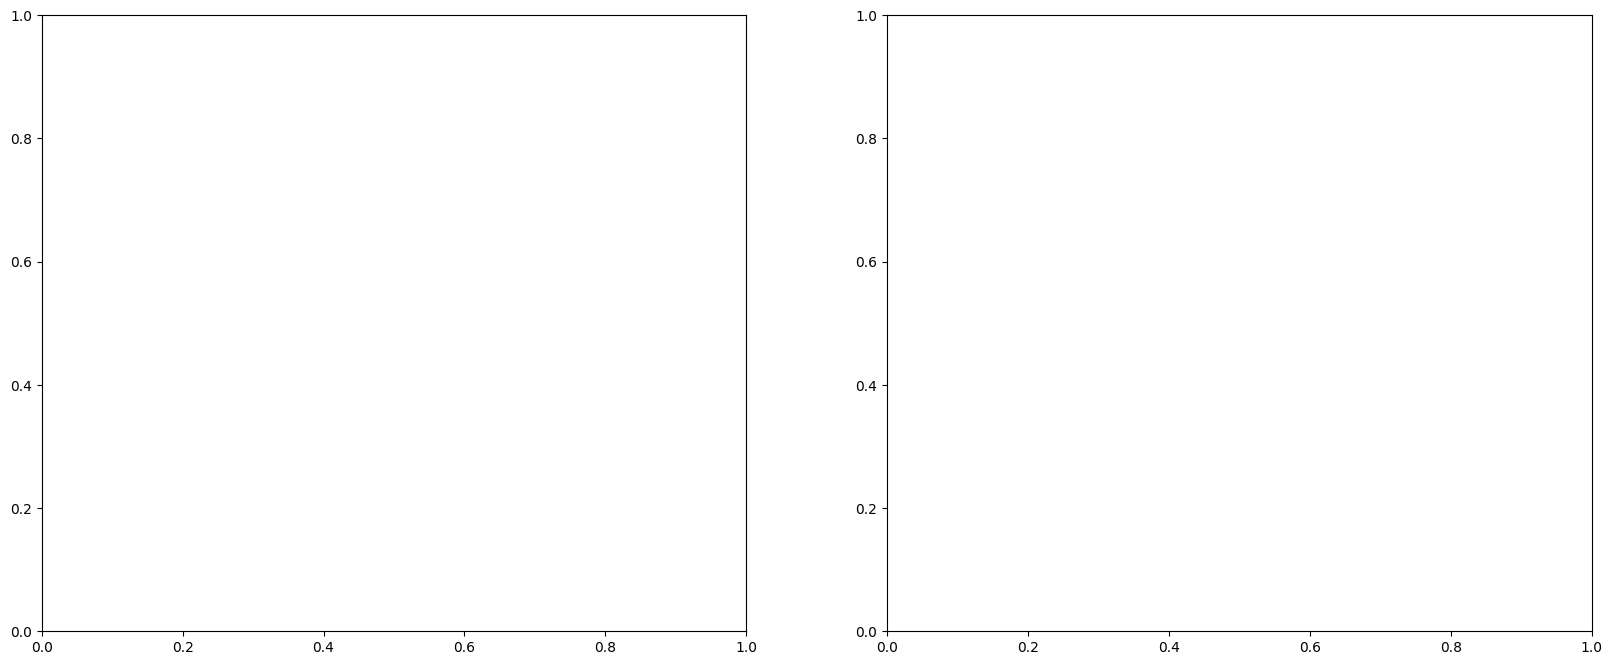

In [7]:

# =====================================================
# E6: Fire Season Length (2 Subplots)
# =====================================================
if len(fire_stats_summary) > 0:
    print("\nPlot E6: Fire Season Length (2 Subplots)...")

    ECO_PLOT_ORDER = sorted([
        eco for eco in fire_stats_summary['Ecoregion'].values if eco != 'Outside'])
    ECO_REV = ECO_PLOT_ORDER[::-1]
    y_pos_e6 = np.arange(len(ECO_PLOT_ORDER))
    n_ecos_e6 = len(ECO_PLOT_ORDER)
    eco_code_to_id = {v['code']: k for k, v in eco_mapping.items()}

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # E6a) Heatmap Frequency
    ax = axes[0]
    hm_season = np.full((n_ecos_e6, 12), np.nan)
    for i, eco_code in enumerate(ECO_PLOT_ORDER):
        eco_id = eco_code_to_id.get(eco_code)
        if eco_id is None:
            continue
        vals = mba_season[:, eco_raster == eco_id].flatten()
        vals = vals[(vals > 0) & (~np.isnan(vals))]
        if len(vals) == 0:
            continue
        uv, cn = np.unique(vals.astype(int), return_counts=True)
        total = len(vals)
        for u, c in zip(uv, cn):
            if 1 <= u <= 12:
                hm_season[i, u - 1] = c / total * 100

    cmap_s = plt.cm.YlOrRd.copy()
    cmap_s.set_bad(color='white')
    im = ax.imshow(np.ma.masked_invalid(hm_season), cmap=cmap_s, aspect='auto',
                   vmin=0, vmax=100, origin='upper')
    for ri in range(n_ecos_e6):
        for cj in range(12):
            val = hm_season[ri, cj]
            if not np.isnan(val) and val > 0:
                tc = 'white' if val > 60 else 'black'
                ax.text(cj, ri, f"{val:.2f}%", ha='center', va='center', fontsize=6, color=tc)
    ax.set_xticks(range(12))
    ax.set_xticklabels(range(1, 13))
    ax.set_yticks(range(n_ecos_e6))
    ax.set_yticklabels(ECO_PLOT_ORDER)
    ax.set_xlabel('Fire Season Length (Months)', fontsize=11)
    ax.set_title('Season Length Frequency\n(% of pixel-years per ecoregion)',
                 fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='%', shrink=0.8)

        # E6b) Temporal Trend Heatmap — Einheitlicher YlOrRd Gradient
    ax = axes[1]
    years_2001 = np.array(years_burned)[np.array(years_burned) >= 2001]
    idx_2001 = np.where(np.array(years_burned) >= 2001)[0]
    
    # Erstelle Matrix für max season length
    hm_temporal_season = np.full((n_ecos_e6, len(years_2001)), np.nan)
    for i, eco_code in enumerate(ECO_PLOT_ORDER):
        eco_id = eco_code_to_id.get(eco_code)
        if eco_id is None:
            continue
        for j, idx in enumerate(idx_2001):
            v = mba_season[idx, eco_raster == eco_id].flatten()
            v = v[(v > 0) & (~np.isnan(v))]
            if len(v) > 0:
                hm_temporal_season[i, j] = float(np.max(v))
    
    # Globale Normalisierung [0, 12] → [0, 1]
    hm_temporal_season_norm = np.full_like(hm_temporal_season, np.nan)
    for i in range(n_ecos_e6):
        for j in range(len(years_2001)):
            if not np.isnan(hm_temporal_season[i, j]):
                val = hm_temporal_season[i, j]
                # Normalisiere global: 1 → 0.083, 12 → 1.0
                hm_temporal_season_norm[i, j] = max(0, min(1, (val - 1) / 11))
    
    # Verwende einheitlichen YlOrRd colormap
    cmap_seasonal = plt.cm.YlOrRd
    im_s = ax.imshow(np.ma.masked_invalid(hm_temporal_season_norm), cmap=cmap_seasonal, 
                     aspect='auto', vmin=0, vmax=1, origin='upper')
    
    # Beschriftungen (ganzzahlig)
    for i in range(n_ecos_e6):
        for j in range(len(years_2001)):
            val = hm_temporal_season[i, j]
            if not np.isnan(val):
                tc = 'white' if hm_temporal_season_norm[i, j] > 0.6 else 'black'
                ax.text(j, i, f'{int(val)}', ha='center', va='center', 
                       fontsize=7, color=tc, fontweight='bold')
    
    ax.set_xticks(np.arange(0, len(years_2001), 2))
    ax.set_xticklabels(years_2001[::2], rotation=45)
    ax.set_yticks(range(n_ecos_e6))
    ax.set_yticklabels(ECO_PLOT_ORDER)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Ecoregion', fontsize=11)
    ax.set_title('Temporal Trend: Fire Season Length Maximum\nper Ecoregion and Year',
                 fontsize=12, fontweight='bold')
    
    # Colorbar mit benutzerdefinierten Ticks für 1-12 Monate
    cbar = plt.colorbar(im_s, ax=ax, label='Season Length (Months)', shrink=0.8)
    # Setze Ticks für 1-12 Monate
    ticks_s = np.linspace(0, 1, 12)
    cbar.set_ticks(ticks_s)
    cbar.set_ticklabels([str(i) for i in range(1, 13)])
    
    #plt.suptitle('Fire Season Length Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(eco_plots_dir, "fire_season_length_analysis.png"),
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ fire_season_length_analysis.png")

    # # E6b) Temporal Trend Heatmap (Maximum pro Jahr pro Ecoregion) eco-farbgradient
    # ax = axes[1]
    # years_2001 = np.array(years_burned)[np.array(years_burned) >= 2001]
    # idx_2001 = np.where(np.array(years_burned) >= 2001)[0]
    
    # # Erstelle Matrix für max season length
    # hm_temporal_season = np.full((n_ecos_e6, len(years_2001)), np.nan)
    # for i, eco_code in enumerate(ECO_PLOT_ORDER):
    #     eco_id = eco_code_to_id.get(eco_code)
    #     if eco_id is None:
    #         continue
    #     for j, idx in enumerate(idx_2001):
    #         v = mba_season[idx, eco_raster == eco_id].flatten()
    #         v = v[(v > 0) & (~np.isnan(v))]
    #         if len(v) > 0:
    #             hm_temporal_season[i, j] = float(np.max(v))
    
    # # Normalisiere pro Ecoregion auf [0, 1]
    # hm_temporal_season_norm = np.full_like(hm_temporal_season, np.nan)
    # for i in range(n_ecos_e6):
    #     row = hm_temporal_season[i, :]
    #     valid = row[~np.isnan(row)]
    #     if len(valid) > 0:
    #         row_min, row_max = valid.min(), valid.max()
    #         if row_max > row_min:
    #             hm_temporal_season_norm[i, :] = (row - row_min) / (row_max - row_min)
    #         else:
    #             hm_temporal_season_norm[i, :] = 0.5
    
    # # Erstelle Farb-Matrix (RGB) — Interpolation von Weiß zu Ecoregion-Farbe
    # from matplotlib.colors import to_rgb
    # color_matrix = np.ones((*hm_temporal_season_norm.shape, 3))
    
    # for i, eco_code in enumerate(ECO_PLOT_ORDER):
    #     eco_color_hex = get_eco_color(eco_code)
    #     eco_color_rgb = to_rgb(eco_color_hex)
        
    #     for j in range(len(years_2001)):
    #         if not np.isnan(hm_temporal_season_norm[i, j]):
    #             val = hm_temporal_season_norm[i, j]
    #             # Interpolation: Weiß (1,1,1) → Eco-Farbe
    #             color_matrix[i, j, :] = [
    #                 1 - val * (1 - eco_color_rgb[0]),
    #                 1 - val * (1 - eco_color_rgb[1]),
    #                 1 - val * (1 - eco_color_rgb[2])
    #             ]
    
    # ax.imshow(color_matrix, aspect='auto', origin='upper')
    
    # # Beschriftungen (ganzzahlig)
    # for i in range(n_ecos_e6):
    #     for j in range(len(years_2001)):
    #         val = hm_temporal_season[i, j]
    #         if not np.isnan(val):
    #             tc = 'white' if hm_temporal_season_norm[i, j] > 0.6 else 'black'
    #             ax.text(j, i, f'{int(val)}', ha='center', va='center', 
    #                    fontsize=7, color=tc, fontweight='bold')
    
    # ax.set_xticks(np.arange(0, len(years_2001), 2))
    # ax.set_xticklabels(years_2001[::2], rotation=45)
    # ax.set_yticks(range(n_ecos_e6))
    # ax.set_yticklabels(ECO_PLOT_ORDER)
    # ax.set_xlabel('Year', fontsize=11)
    # ax.set_ylabel('Ecoregion', fontsize=11)
    # ax.set_title('Temporal Trend: Fire Season Length Maximum\nper Ecoregion and Year',
    #             fontsize=12, fontweight='bold')

    # plt.suptitle('Fire Season Length Analysis', fontsize=15, fontweight='bold')
    # plt.tight_layout()
    # plt.savefig(os.path.join(eco_plots_dir, "fire_season_length_analysis.png"),
    #             dpi=300, bbox_inches='tight')
    # plt.close()
    # print(f"  ✓ fire_season_length_analysis.png")



Plot E7: Fire Count (2 Subplots)...


TypeError: 'NoneType' object is not subscriptable

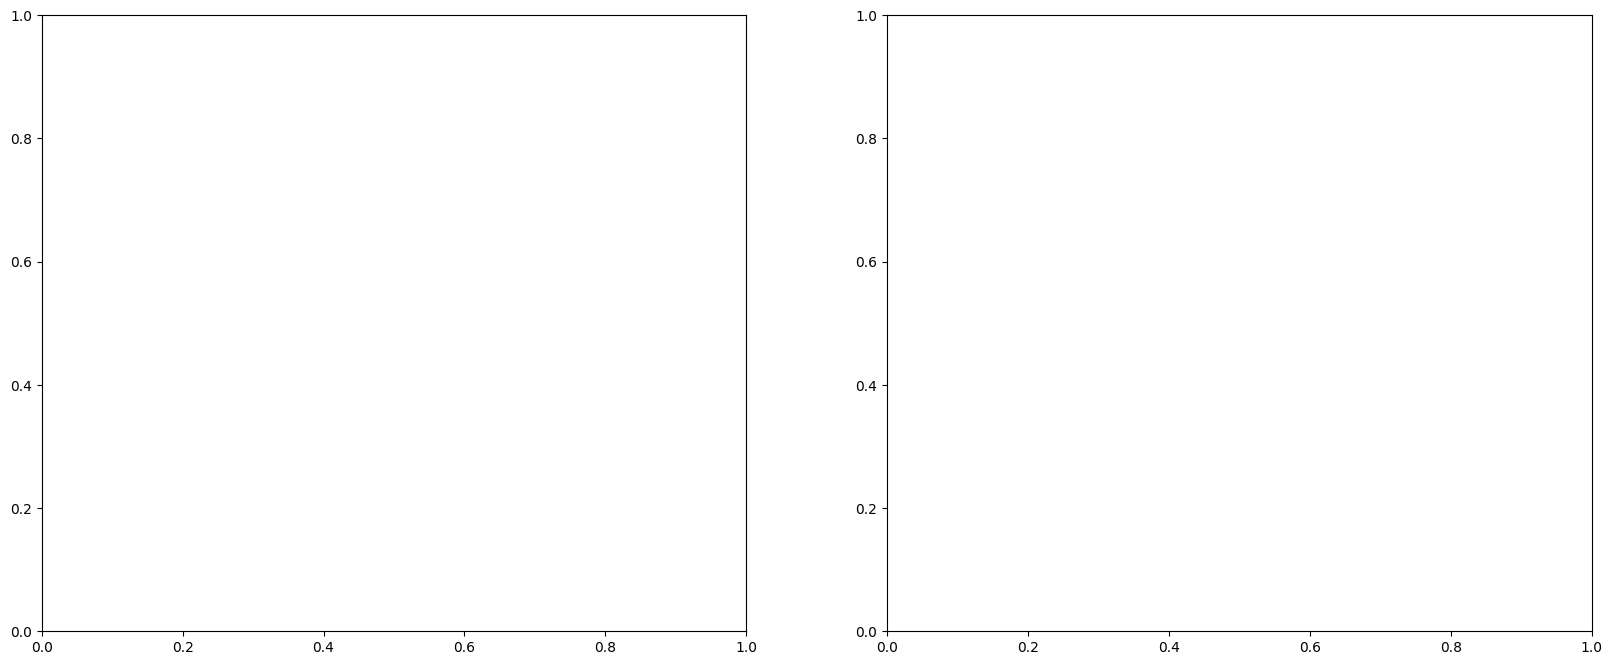

In [8]:

# =====================================================
# E7: Fire Count (2 Subplots)
# =====================================================
if len(fire_stats_summary) > 0:
    print("\nPlot E7: Fire Count (2 Subplots)...")

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # E7a) Heatmap Frequency
    ax = axes[0]
    hm_count = np.full((n_ecos_e6, 4), np.nan)
    for i, eco_code in enumerate(ECO_PLOT_ORDER):
        eco_id = eco_code_to_id.get(eco_code)
        if eco_id is None:
            continue
        vals = mba_count[:, eco_raster == eco_id].flatten()
        vals = vals[(vals > 0) & (~np.isnan(vals))]
        if len(vals) == 0:
            continue
        uv, cn = np.unique(vals.astype(int), return_counts=True)
        total = len(vals)
        for u, c in zip(uv, cn):
            if 1 <= u <= 4:
                hm_count[i, u - 1] = c / total * 100

    cmap_c = plt.cm.YlOrRd.copy()
    cmap_c.set_bad(color='white')
    im2 = ax.imshow(np.ma.masked_invalid(hm_count), cmap=cmap_c, aspect='auto',
                    vmin=0, vmax=100, origin='upper')
    for ri in range(n_ecos_e6):
        for cj in range(4):
            val = hm_count[ri, cj]
            if not np.isnan(val) and val > 0:
                tc = 'white' if val > 60 else 'black'
                ax.text(cj, ri, f"{val:.2f}%", ha='center', va='center', fontsize=8, color=tc)
    ax.set_xticks(range(4))
    ax.set_xticklabels(range(1, 5))
    ax.set_yticks(range(n_ecos_e6))
    ax.set_yticklabels(ECO_PLOT_ORDER)
    ax.set_xlabel('Number of Fire Events', fontsize=11)
    ax.set_title('Fire Count Frequency\n(% of pixel-years per ecoregion)',
                 fontsize=12, fontweight='bold')
    plt.colorbar(im2, ax=ax, label='%', shrink=0.8)

        # E7b) Temporal Trend Heatmap — Einheitlicher YlOrRd Gradient
    ax = axes[1]
    
    # Erstelle Matrix für max fire count
    hm_temporal_count = np.full((n_ecos_e6, len(years_2001)), np.nan)
    for i, eco_code in enumerate(ECO_PLOT_ORDER):
        eco_id = eco_code_to_id.get(eco_code)
        if eco_id is None:
            continue
        for j, idx in enumerate(idx_2001):
            v = mba_count[idx, eco_raster == eco_id].flatten()
            v = v[(v > 0) & (~np.isnan(v))]
            if len(v) > 0:
                hm_temporal_count[i, j] = float(np.max(v))
    
    # Globale Normalisierung [1, 4] → [0, 1]
    hm_temporal_count_norm = np.full_like(hm_temporal_count, np.nan)
    for i in range(n_ecos_e6):
        for j in range(len(years_2001)):
            if not np.isnan(hm_temporal_count[i, j]):
                val = hm_temporal_count[i, j]
                # Normalisiere global: 1 → 0.0, 4 → 1.0
                hm_temporal_count_norm[i, j] = max(0, min(1, (val - 1) / 3))
    
    # Verwende einheitlichen YlOrRd colormap
    cmap_counts = plt.cm.YlOrRd
    im_c = ax.imshow(np.ma.masked_invalid(hm_temporal_count_norm), cmap=cmap_counts, 
                     aspect='auto', vmin=0, vmax=1, origin='upper')
    
    # Beschriftungen (ganzzahlig)
    for i in range(n_ecos_e6):
        for j in range(len(years_2001)):
            val = hm_temporal_count[i, j]
            if not np.isnan(val):
                tc = 'white' if hm_temporal_count_norm[i, j] > 0.6 else 'black'
                ax.text(j, i, f'{int(val)}', ha='center', va='center', 
                       fontsize=7, color=tc, fontweight='bold')
    
    ax.set_xticks(np.arange(0, len(years_2001), 2))
    ax.set_xticklabels(years_2001[::2], rotation=45)
    ax.set_yticks(range(n_ecos_e6))
    ax.set_yticklabels(ECO_PLOT_ORDER)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Ecoregion', fontsize=11)
    ax.set_title('Temporal Trend: Fire Count Maximum\nper Ecoregion and Year',
                 fontsize=12, fontweight='bold')
    
    # Colorbar mit benutzerdefinierten Ticks für 1-4 Fire Events
    cbar = plt.colorbar(im_c, ax=ax, label='Fire Count', shrink=0.8)
    # Setze Ticks für 1-4 Fire Events: 0.0, 0.333, 0.667, 1.0
    ticks_c = [0, 1/3, 2/3, 1.0]
    cbar.set_ticks(ticks_c)
    cbar.set_ticklabels(['1', '2', '3', '4'])
    
    #plt.suptitle('Fire Count Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(eco_plots_dir, "fire_count_analysis.png"),
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ fire_count_analysis.png")

#     # E7b) Temporal Trend Heatmap (Maximum pro Jahr pro Ecoregion) eco-farbgradient
#     ax = axes[1]
    
#     # Erstelle Matrix für max fire count
#     hm_temporal_count = np.full((n_ecos_e6, len(years_2001)), np.nan)
#     for i, eco_code in enumerate(ECO_PLOT_ORDER):
#         eco_id = eco_code_to_id.get(eco_code)
#         if eco_id is None:
#             continue
#         for j, idx in enumerate(idx_2001):
#             v = mba_count[idx, eco_raster == eco_id].flatten()
#             v = v[(v > 0) & (~np.isnan(v))]
#             if len(v) > 0:
#                 hm_temporal_count[i, j] = float(np.max(v))
    
#     # GLOBALE Normalisierung für Fire Count 1-4 (nicht pro Reihe!)
#     hm_temporal_count_norm = np.full_like(hm_temporal_count, np.nan)
#     for i in range(n_ecos_e6):
#         for j in range(len(years_2001)):
#             if not np.isnan(hm_temporal_count[i, j]):
#                 val = hm_temporal_count[i, j]
#                 # Normalisiere global: 1 → 0, 2 → 0.333, 3 → 0.667, 4 → 1.0
#                 hm_temporal_count_norm[i, j] = max(0, min(1, (val - 1) / 3))
    
#     # Erstelle Farb-Matrix (RGB) — Interpolation von Weiß zu Ecoregion-Farbe
#     color_matrix_c = np.ones((*hm_temporal_count_norm.shape, 3))
    
#     for i, eco_code in enumerate(ECO_PLOT_ORDER):
#         eco_color_hex = get_eco_color(eco_code)
#         eco_color_rgb = to_rgb(eco_color_hex)
        
#         for j in range(len(years_2001)):
#             if not np.isnan(hm_temporal_count_norm[i, j]):
#                 val = hm_temporal_count_norm[i, j]
#                 # Interpolation: Weiß (1,1,1) → Eco-Farbe
#                 color_matrix_c[i, j, :] = [
#                     1 - val * (1 - eco_color_rgb[0]),
#                     1 - val * (1 - eco_color_rgb[1]),
#                     1 - val * (1 - eco_color_rgb[2])
#                 ]
    
#     ax.imshow(color_matrix_c, aspect='auto', origin='upper')
    
#     # Beschriftungen (ganzzahlig)
#     for i in range(n_ecos_e6):
#         for j in range(len(years_2001)):
#             val = hm_temporal_count[i, j]
#             if not np.isnan(val):
#                 tc = 'white' if hm_temporal_count_norm[i, j] > 0.6 else 'black'
#                 ax.text(j, i, f'{int(val)}', ha='center', va='center', 
#                        fontsize=7, color=tc, fontweight='bold')
    
#     ax.set_xticks(np.arange(0, len(years_2001), 2))
#     ax.set_xticklabels(years_2001[::2], rotation=45)
#     ax.set_yticks(range(n_ecos_e6))
#     ax.set_yticklabels(ECO_PLOT_ORDER)
#     ax.set_xlabel('Year', fontsize=11)
#     ax.set_ylabel('Ecoregion', fontsize=11)
#     ax.set_title('Temporal Trend: Fire Count Maximum\nper Ecoregion and Year',
#                 fontsize=12, fontweight='bold')
    
#     plt.suptitle('Fire Count Analysis', fontsize=15, fontweight='bold')
#     plt.tight_layout()
#     plt.savefig(os.path.join(eco_plots_dir, "fire_count_analysis.png"),
#                 dpi=300, bbox_inches='tight')
#     plt.close()
#     print(f"  ✓ fire_count_analysis.png")
# else:
#     print("\n  ⚠ fire_stats_summary empty — skipping E6/E7")


# --- CSV Exports ---
print("\nSaving Fire Stats CSVs...")

if len(burned_area_eco) > 0:
    burned_area_eco.to_csv(os.path.join(eco_csv_dir, "burned_area_by_ecoregion.csv"), index=False)
    print(f"  ✓ burned_area_by_ecoregion.csv")

if len(fire_count_eco) > 0:
    fire_count_eco.to_csv(os.path.join(eco_csv_dir, "fire_count_distribution_by_ecoregion.csv"), index=False)
    print(f"  ✓ fire_count_distribution_by_ecoregion.csv")

if len(fire_stats_summary) > 0:
    fire_stats_summary.to_csv(os.path.join(eco_csv_dir, "fire_statistics_summary_per_ecoregion.csv"), index=False)
    season_stats.to_csv(os.path.join(eco_csv_dir, "fire_season_length_by_ecoregion.csv"), index=False)
    print(f"  ✓ fire_statistics_summary_per_ecoregion.csv")
    print(f"  ✓ fire_season_length_by_ecoregion.csv")

print("\n✓ 4.2b complete")

### Ecoregion Recovery

In [22]:
# ============================================================
# 4.2c  ECOREGION — Recovery Plots (E8–E10)
# ============================================================
print("=" * 70)
print("4.2c  ECOREGION RECOVERY PLOTS")
print("=" * 70)


# =====================================================
# E8: Recovery Normalized Panels (per fire count 1–4 + combined)
# =====================================================
print("\nPlot E8: Recovery Normalized Panels...")

all_recovery_rows = []

for fc_val in [1, 2, 3, 4]:
    if fc_val == 1:
        source   = {c: d for c, d in eco_results.items() if not _is_excluded(c)}
        fc_label = "1_interannual_fire"
        fc_title = "1 Fire Year  (inter-annual Fire Count = 1)"
    else:
        source = {ec: fd[fc_val]
                  for ec, fd in eco_firecount_results.items()
                  if fc_val in fd and not _is_excluded(ec)}
        fc_label = f"{fc_val}_interannual_fires"
        fc_title = f"{fc_val} Fire Years  (inter-annual Fire Count = {fc_val})"

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes_flat = axes.flatten()

    for i, eco_code in enumerate(ALL_ECO_CODES):
        ax    = axes_flat[i]
        color = get_eco_color(eco_code)

        if eco_code not in source:
            ax.axis('off')
            ax.text(0.5, 0.5, f"{eco_code}\nno data",
                    ha='center', va='center', fontsize=9, color='lightgray',
                    transform=ax.transAxes)
            continue

        data     = source[eco_code]
        traj     = np.array(data['trajectory'])
        n_pixels = data['n_pixels']
        if len(traj) < 16:
            ax.axis('off'); continue

        fire_year_cover = traj[5]
        if fire_year_cover <= 0 or np.isnan(fire_year_cover):
            ax.axis('off'); continue

        ok = plot_recovery_panel(ax, traj, color)
        if ok:
            ax.set_title(f"{eco_code}  (n={n_pixels:,})", fontsize=10, fontweight='bold')
            for yr, idx in zip(POST_FIRE_YEARS, post_fire_indices):
                all_recovery_rows.append({
                    'Fire_Count_Interannual': fc_val,
                    'Ecoregion':             eco_code,
                    'Year_Relative':         yr,
                    'Cover_Normalized':      round(float(traj[idx]) / fire_year_cover, 4),
                    'Cover_Absolute':        round(float(traj[idx]), 2),
                    'N_Pixels':              n_pixels,
                })

    for j in range(n_eco_total, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(f'Post-Fire Woody Cover Recovery by Ecoregion\n{fc_title}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.subplots_adjust(top=0.88)
    plt.savefig(os.path.join(recovery_plots_dir,
                f"eco_recovery_normalized_{fc_label}_panel.png"),
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ eco_recovery_normalized_{fc_label}_panel.png")

# Combined plot: all fire counts per ecoregion
print("\n  Creating combined recovery plot...")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes_flat = axes.flatten()

for i, eco_code in enumerate(ALL_ECO_CODES):
    ax         = axes_flat[i]
    base_color = get_eco_color(eco_code)
    n_per_fc   = {}
    has_any    = False

    for fc_val in [1, 2, 3, 4]:
        data = eco_results.get(eco_code) if fc_val == 1 \
               else eco_firecount_results.get(eco_code, {}).get(fc_val)
        if data is None: continue
        traj = np.array(data['trajectory'])
        if len(traj) < 16: continue
        fire_year_cover = traj[5]
        if fire_year_cover <= 0 or np.isnan(fire_year_cover): continue

        traj_post = traj[post_fire_indices] / fire_year_cover
        fc_color  = intensify_color(base_color, fc_val)
        ax.plot(POST_FIRE_YEARS, traj_post, 
                #marker='o', 
                linewidth=2,
                color=fc_color, label=f'{fc_val} Fire(s)', alpha=0.9)
        n_per_fc[fc_val] = data['n_pixels']
        has_any = True

    if not has_any:
        ax.axis('off')
        ax.text(0.5, 0.5, f"{eco_code}\nno data",
                ha='center', va='center', fontsize=9, color='lightgray',
                transform=ax.transAxes)
        continue

    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.6,
               label='Fire Year (= 1.0)')
    n_str = '  '.join([f"n{k}={v:,}" for k, v in sorted(n_per_fc.items())])
    ax.set_title(f"{eco_code}\n{n_str}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Years After First Fire', fontsize=9)
    ax.set_ylabel('Norm. Woody Cover', fontsize=9)
    ax.set_xlim(-0.3, 10.3); ax.set_ylim(0.5, 1.5)
    ax.set_xticks(POST_FIRE_YEARS)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor(base_color); spine.set_linewidth(2)

for j in range(n_eco_total, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Post-Fire Woody Cover Recovery by Ecoregion\n'
             'All Inter-Annual Fire Counts  (Year 0 = Fire Year = 1.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.90)
plt.savefig(os.path.join(recovery_plots_dir, "eco_recovery_normalized_combined_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ eco_recovery_normalized_combined_panel.png")

# =====================================================
# E9: Recovery Heatmap (pre-fire normalized)
# =====================================================
print("\nPlot E9: Recovery Heatmap (pre-fire normalized)...")

YEARS_AFTER   = list(range(0, 11))
post_fire_idx = list(range(5, 16))
pre_fire_idx  = list(range(0, 5))

eco_codes_hm = [c for c in ALL_ECO_CODES if c in eco_results]
n_years_hm   = len(YEARS_AFTER)
n_eco_hm     = len(eco_codes_hm)
hm_matrix    = np.full((n_years_hm, n_eco_hm), np.nan)
hm_n_pixels  = {}

for j, eco_code in enumerate(eco_codes_hm):
    data = eco_results[eco_code]
    traj = np.array(data['trajectory'])
    if len(traj) < 16: continue
    pre_fire_mean = np.nanmean(traj[pre_fire_idx])
    if pre_fire_mean <= 0 or np.isnan(pre_fire_mean): continue
    for i, idx in enumerate(post_fire_idx):
        hm_matrix[i, j] = traj[idx] / pre_fire_mean
    hm_n_pixels[eco_code] = data['n_pixels']

fig, ax = plt.subplots(figsize=(max(10, n_years_hm * 1.1), max(6, n_eco_hm * 0.8)))
cmap_hm = plt.cm.RdYlGn
vmin, vmax = 0.5, 1.3
norm_hm = plt.Normalize(vmin=vmin, vmax=vmax)
im = ax.imshow(hm_matrix.T, aspect='auto', cmap=cmap_hm, norm=norm_hm,
               origin='upper', interpolation='nearest')
ax.set_xticks(np.arange(n_years_hm))
ax.set_xticklabels([f'+{yr}' for yr in YEARS_AFTER], fontsize=9)
ax.set_xlabel('Years After Fire', fontsize=11)
ax.set_yticks(np.arange(n_eco_hm))
ax.set_yticklabels([f"{c}  (n={hm_n_pixels.get(c, 0):,})" for c in eco_codes_hm], fontsize=9)
ax.set_ylabel('Ecoregion', fontsize=11)

for i in range(n_eco_hm):
    for j in range(n_years_hm):
        val = hm_matrix[j, i]
        if not np.isnan(val):
            tc = 'white' if (val < 0.7 or val > 1.2) else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=tc, fontweight='bold')

ax.axvline(x=0.5, color='black', linewidth=2, alpha=0.6, linestyle='--')
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Norm. Woody Cover (Pre-Fire = 1.0)', fontsize=10)
cbar.ax.set_ylim(vmin, vmax)
cbar.ax.axhline(y=1.0, color='black', linewidth=1.5, linestyle='--')
cbar.ax.text(1.05, 1.0, '1.0', va='center', ha='left', fontsize=8,
             transform=cbar.ax.get_yaxis_transform())
ax.set_title('Post-Fire Woody Cover Recovery by Ecoregion\n'
             '(Single Fire Events — Pre-Fire Mean = 1.0)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(recovery_plots_dir,
            "eco_recovery_heatmap_prefire_normalized.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ eco_recovery_heatmap_prefire_normalized.png")

# # =====================================================
# # E10: Recovery Rates Heatmap (1, 3, 5, 10 years)
# # =====================================================
# print("\nPlot E10: Recovery Rates Heatmap...")

# eco_recovery_rows = []
# for eco_code, data in eco_results.items():
#     if _is_excluded(eco_code): continue
#     traj = np.array(data['trajectory'])
#     pre_fire = np.nanmean(traj[:5])
#     fire_year_val = traj[5]
#     loss = pre_fire - fire_year_val
#     for years_after in [1, 3, 5, 10]:
#         idx = 5 + years_after
#         if idx < len(traj):
#             rec_val = traj[idx]
#             rec_pct = ((rec_val - fire_year_val) / loss * 100) if loss > 0 else np.nan
#         else:
#             rec_val = np.nan; rec_pct = np.nan
#         eco_recovery_rows.append({
#             'Ecoregion': eco_code, 'Years_After': years_after,
#             'Pre_Fire_Cover': pre_fire, 'Fire_Year_Cover': fire_year_val,
#             'Woody_Loss': loss, 'Recovery_Cover': rec_val,
#             'Recovery_Percent': rec_pct, 'N_Pixels': data['n_pixels']
#         })

# df_eco_recovery = pd.DataFrame(eco_recovery_rows)
# pivot_rec = df_eco_recovery.pivot_table(
#     index='Ecoregion', columns='Years_After', values='Recovery_Percent')

# fig, ax = plt.subplots(figsize=(10, 8))
# sns.heatmap(pivot_rec, cmap='RdYlGn', annot=True, fmt='.0f', ax=ax,
#             center=100, linewidths=0.5, cbar_kws={'label': 'Recovery (% of Loss)'})
# ax.set_title('Woody Cover Recovery by Ecoregion\n(% of Immediate Loss Recovered)',
#              fontsize=13, fontweight='bold')
# ax.set_xlabel('Years After Fire'); ax.set_ylabel('Ecoregion')
# plt.tight_layout()
# plt.savefig(os.path.join(eco_plots_dir, "eco_recovery_heatmap.png"),
#             dpi=300, bbox_inches='tight')
# plt.close()
# print(f"  ✓ eco_recovery_heatmap.png")

# =====================================================
# E11:All Ecoregion Recovery Trajectories (1 Fire) — combined
# =====================================================
print("\nPlot E11: All Ecoregion Recovery Trajectories (1 Fire)...")

fig, ax = plt.subplots(figsize=(14, 8))

for eco_code in sorted(ALL_ECO_CODES):
    data = eco_results.get(eco_code)
    if data is None:
        continue
    
    traj = np.array(data['trajectory'])
    if len(traj) < 16:
        continue
    
    fire_year_cover = traj[5]
    if fire_year_cover <= 0 or np.isnan(fire_year_cover):
        continue
    
    # Normalized recovery trajectory
    traj_post = traj[post_fire_indices] / fire_year_cover
    color = get_eco_color(eco_code)
    eco_name = get_eco_name(eco_code)
    
    ax.plot(
        POST_FIRE_YEARS,
        traj_post,
        #marker='o',
        linewidth=2.5,
        label=f"{eco_code} - {eco_name} (n={data['n_pixels']:,})",
        color=color,
        alpha=0.9,
    )

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.8, alpha=0.7, label='Fire Year (= 1.0)')

ax.set_xlabel('Years After Fire', fontsize=12)
ax.set_ylabel('Normalized Woody Cover', fontsize=12)
ax.set_xlim(-0.3, 10.3)
ax.set_xticks(POST_FIRE_YEARS)
ax.grid(True, alpha=0.3)

ax.set_title(
    "Post-Fire Woody Cover Recovery by Ecoregion\n(Single Fire Events Only — Pre-Fire Mean = 1.0)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.subplots_adjust(top=0.88)

plt.savefig(
    os.path.join(recovery_plots_dir, "eco_recovery_normalized_all_1fire.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.close()
print("  ✓ eco_recovery_normalized_all_1fire.png")


# --- CSV Exports ---
print("\nSaving Recovery CSVs...")

recovery_norm_df = pd.DataFrame(all_recovery_rows)
recovery_norm_df.to_csv(os.path.join(eco_csv_dir, "eco_recovery_normalized_all_firecounts.csv"), index=False)
print(f"  ✓ eco_recovery_normalized_all_firecounts.csv")

hm_df = pd.DataFrame(hm_matrix, index=[f'+{yr}' for yr in YEARS_AFTER], columns=eco_codes_hm)
hm_df.index.name = 'Year_After_Fire'
hm_df.to_csv(os.path.join(eco_csv_dir, "eco_recovery_heatmap_prefire_normalized.csv"))
print(f"  ✓ eco_recovery_heatmap_prefire_normalized.csv")

#df_eco_recovery.to_csv(os.path.join(eco_csv_dir, "recovery_summary_by_ecoregion.csv"), index=False)
#print(f"  ✓ recovery_summary_by_ecoregion.csv")

print("\n✓ 4.2c complete")

4.2c  ECOREGION RECOVERY PLOTS

Plot E8: Recovery Normalized Panels...


  ✓ eco_recovery_normalized_1_interannual_fire_panel.png
  ✓ eco_recovery_normalized_2_interannual_fires_panel.png
  ✓ eco_recovery_normalized_3_interannual_fires_panel.png
  ✓ eco_recovery_normalized_4_interannual_fires_panel.png

  Creating combined recovery plot...
  ✓ eco_recovery_normalized_combined_panel.png

Plot E9: Recovery Heatmap (pre-fire normalized)...
  ✓ eco_recovery_heatmap_prefire_normalized.png

Plot E11: All Ecoregion Recovery Trajectories (1 Fire)...
  ✓ eco_recovery_normalized_all_1fire.png

Saving Recovery CSVs...
  ✓ eco_recovery_normalized_all_firecounts.csv
  ✓ eco_recovery_heatmap_prefire_normalized.csv

✓ 4.2c complete


### Landcover Trajectories

In [23]:
# ============================================================
# 4.3a  LANDCOVER — Trajectory Plots (L1–L3)
#   + Standard Error bands  + LOESS smoothed curves (span=0.75)
# ============================================================
print("=" * 70)
print("4.3a  LANDCOVER TRAJECTORY PLOTS  (SE + LOESS)")
print("=" * 70)

lc_trajectories_dir = os.path.join(lc_plots_dir, "trajectories")
os.makedirs(lc_trajectories_dir, exist_ok=True)

ALL_LC_CLASSES = sorted([lc for lc in lc_major_results.keys() if lc not in LC_EXCLUDE])
n_lc_total     = len(ALL_LC_CLASSES)
n_cols_lc      = 3
n_rows_lc      = int(np.ceil(n_lc_total / n_cols_lc))

# =====================================================
# L1: All LC Trajectories (1 Fire) — combined
# =====================================================
print("\nPlot L1: All LC Trajectories (1 Fire)...")

fig, ax = plt.subplots(figsize=(14, 8))

for lc_class in ALL_LC_CLASSES:
    data  = lc_major_results[lc_class]
    color = LC_COLORS.get(lc_class, '#808080')
    traj  = np.array(data['trajectory'])
    se, lx, ly = _se_and_loess(traj, data['std'], data['n_pixels'], x=rel_years)

    ax.plot(rel_years, traj, linewidth=2.5,
            label=f"{lc_class} (n={data['n_pixels']:,})",
            color=color, alpha=0.9)
    ax.fill_between(rel_years, traj - se, traj + se, alpha=0.15, color=color)
    ax.plot(lx, ly, linestyle='--', linewidth=1.3, color=color, alpha=0.55)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.8, alpha=0.6, label='Fire Year')
ax.axvline(x=1, color='red', linestyle='--', linewidth=1.8, alpha=0.6)
ax.set_xlabel('Years Relative to Fire Event', fontsize=12)
ax.set_ylabel('Woody Cover (%)', fontsize=12)
ax.set_xlim(-5.5, 10.5)
ax.grid(True, alpha=0.3)
ax.set_title('Post-Fire Woody Cover Trajectories by Land Cover\n'
             '(Single Fire Events Only)', fontsize=14, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.savefig(os.path.join(lc_trajectories_dir, "lc_trajectories_1fire_all.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print("  ✓ lc_trajectories_1fire_all.png")

# =====================================================
# L2: Subplots per LC class (1-4 Fires, separate panels)
# =====================================================
print("\nPlot L2: Subplots per LC class (1-4 Fires)...")

lc_panel_cfgs = [
    (1, "lc_trajectories_1fire_panel.png",  "Single Fire Events"),
    (2, "lc_trajectories_2fires_panel.png", "2 Fire Events"),
    (3, "lc_trajectories_3fires_panel.png", "3 Fire Events"),
    (4, "lc_trajectories_4fires_panel.png", "4 Fire Events"),
]

for fc_val, out_name, panel_label in lc_panel_cfgs:
    fig, axes = plt.subplots(n_rows_lc, n_cols_lc, figsize=(16, 5 * n_rows_lc))
    axes_flat = np.atleast_1d(axes).ravel()

    for i, lc_class in enumerate(ALL_LC_CLASSES):
        ax    = axes_flat[i]
        color = LC_COLORS.get(lc_class, '#808080')

        if fc_val == 1:
            data = lc_major_results.get(lc_class)
        else:
            data = lc_firecount_results.get(lc_class, {}).get(fc_val)

        if data is None:
            ax.axis('off')
            ax.text(0.5, 0.5, f"{lc_class}\nno data", ha='center', va='center',
                    fontsize=9, color='lightgray', transform=ax.transAxes)
            continue

        traj     = np.array(data['trajectory'])
        n_pixels = data['n_pixels']
        if len(traj) < len(rel_years):
            ax.axis('off')
            ax.text(0.5, 0.5, f"{lc_class}\ninvalid", ha='center', va='center',
                    fontsize=9, color='lightgray', transform=ax.transAxes)
            continue

        se, lx, ly = _se_and_loess(traj, data['std'], n_pixels, x=rel_years)
        ax.plot(rel_years, traj, linewidth=2.3, color=color, alpha=0.95)
        ax.fill_between(rel_years, traj - se, traj + se, alpha=0.15, color=color)
        ax.plot(lx, ly, linestyle='--', linewidth=1.2, color=color, alpha=0.55)
        ax.axvline(x=0, color='red', linestyle='--', linewidth=1.6, alpha=0.6)
        ax.axvline(x=1, color='red', linestyle='--', linewidth=1.6, alpha=0.6)
        ax.set_title(f"{lc_class} (n={n_pixels:,})", fontsize=10, fontweight='bold')
        ax.set_xlabel('Years Relative to Fire', fontsize=9)
        ax.set_ylabel('Woody Cover (%)', fontsize=9)
        ax.set_xlim(-5.5, 10.5)
        ax.grid(True, alpha=0.3)
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2)

    for j in range(n_lc_total, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(f'Woody Cover Trajectories by Land Cover\n({panel_label})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.subplots_adjust(top=0.90)
    plt.savefig(os.path.join(lc_trajectories_dir, out_name), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ {out_name}")

# =====================================================
# L3: LC × Fire Count (combined panel style)
# =====================================================
print("\nPlot L3: LC × Fire Count...")

fig, axes = plt.subplots(n_rows_lc, n_cols_lc, figsize=(16, 5 * n_rows_lc))
axes_flat = np.atleast_1d(axes).ravel()

for i, lc_class in enumerate(ALL_LC_CLASSES):
    ax         = axes_flat[i]
    base_color = LC_COLORS.get(lc_class, '#808080')
    n_per_fc   = {}
    has_any    = False

    for fc_val in [1, 2, 3, 4]:
        data = (lc_major_results.get(lc_class) if fc_val == 1
                else lc_firecount_results.get(lc_class, {}).get(fc_val))
        if data is None:
            continue
        traj = np.array(data['trajectory'])
        if len(traj) < len(rel_years):
            continue

        fc_color = intensify_color(base_color, fc_val)
        se, lx, ly = _se_and_loess(traj, data['std'], data['n_pixels'],
                                    x=rel_years)
        ax.plot(rel_years, traj, linewidth=2.0, color=fc_color,
                label=f"{fc_val} Fire(s)", alpha=0.95)
        ax.fill_between(rel_years, traj - se, traj + se,
                        alpha=0.12, color=fc_color)
        ax.plot(lx, ly, linestyle='--', linewidth=1.2, color=fc_color, alpha=0.5)
        n_per_fc[fc_val] = data['n_pixels']
        has_any = True

    if not has_any:
        ax.axis('off')
        ax.text(0.5, 0.5, f"{lc_class}\nno data", ha='center', va='center',
                fontsize=9, color='lightgray', transform=ax.transAxes)
        continue

    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.6, alpha=0.6,
               label='Fire Year')
    ax.axvline(x=1, color='red', linestyle='--', linewidth=1.6, alpha=0.6)
    n_str = '  '.join([f"n{k}={v:,}" for k, v in sorted(n_per_fc.items())])
    ax.set_title(f"{lc_class}\n{n_str}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Years Relative to Fire', fontsize=9)
    ax.set_ylabel('Woody Cover (%)', fontsize=9)
    ax.set_xlim(-5.5, 10.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')
    for spine in ax.spines.values():
        spine.set_edgecolor(base_color); spine.set_linewidth(2)

for j in range(n_lc_total, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Woody Cover Trajectories by Land Cover\n'
             'All Inter-Annual Fire Counts', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.90)
plt.savefig(os.path.join(lc_trajectories_dir, "lc_trajectories_by_fire_count.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print("  ✓ lc_trajectories_by_fire_count.png")

# --- CSV Exports ---
print("\nSaving LC Trajectory CSVs...")

rows = []
for lc_class in ALL_LC_CLASSES:
    data = lc_major_results[lc_class]
    for i, ry in enumerate(rel_years):
        rows.append({
            'Landcover': lc_class, 'N_Pixels': data['n_pixels'],
            'Rel_Year': ry,
            'Woody_Cover_Mean': data['trajectory'][i],
            'Woody_Cover_Std': data['std'][i],
        })
pd.DataFrame(rows).to_csv(
    os.path.join(lc_csv_dir, "trajectories_by_landcover_1fire.csv"), index=False)
print("  ✓ trajectories_by_landcover_1fire.csv")

rows = []
for lc_class, fc_data in sorted(lc_firecount_results.items()):
    if not fc_data or lc_class in LC_EXCLUDE:
        continue
    for fc, data in sorted(fc_data.items()):
        for i, ry in enumerate(rel_years):
            rows.append({
                'Landcover': lc_class, 'Fire_Count': fc,
                'N_Pixels': data['n_pixels'], 'Rel_Year': ry,
                'Woody_Cover_Mean': data['trajectory'][i],
                'Woody_Cover_Std': data['std'][i],
            })
pd.DataFrame(rows).to_csv(
    os.path.join(lc_csv_dir, "trajectories_by_landcover_x_firecount.csv"), index=False)
print("  ✓ trajectories_by_landcover_x_firecount.csv")

print("\n✓ 4.3a complete")

4.3a  LANDCOVER TRAJECTORY PLOTS  (SE + LOESS)

Plot L1: All LC Trajectories (1 Fire)...
  ✓ lc_trajectories_1fire_all.png

Plot L2: Subplots per LC class (1-4 Fires)...
  ✓ lc_trajectories_1fire_panel.png
  ✓ lc_trajectories_2fires_panel.png
  ✓ lc_trajectories_3fires_panel.png
  ✓ lc_trajectories_4fires_panel.png

Plot L3: LC × Fire Count...
  ✓ lc_trajectories_by_fire_count.png

Saving LC Trajectory CSVs...
  ✓ trajectories_by_landcover_1fire.csv
  ✓ trajectories_by_landcover_x_firecount.csv

✓ 4.3a complete


### Landcover Recovery

In [24]:
# ============================================================
# 4.3c  LANDCOVER — Recovery Plots (L8–L11)
# ============================================================
print("=" * 70)
print("4.3c  LANDCOVER RECOVERY PLOTS")
print("=" * 70)

lc_recovery_plots_dir = os.path.join(lc_plots_dir, "recovery_normalized")
os.makedirs(lc_recovery_plots_dir, exist_ok=True)

ALL_LC_CLASSES = sorted(lc_major_results.keys())
n_lc_total     = len(ALL_LC_CLASSES)
n_cols_lc      = 3
n_rows_lc      = int(np.ceil(n_lc_total / n_cols_lc))

# =====================================================
# L8: Recovery Normalized Panels (per fire count 1–4 + combined)
# =====================================================
print("\nPlot L8: Recovery Normalized Panels...")

all_lc_recovery_rows = []

for fc_val in [1, 2, 3, 4]:
    if fc_val == 1:
        source   = {lc: d for lc, d in lc_major_results.items()
                    if lc not in LC_EXCLUDE}
        fc_label = "1fire"
        fc_title = "1 Fire Year  (inter-annual Fire Count = 1)"
    else:
        source   = {lc: fd[fc_val]
                    for lc, fd in lc_firecount_results.items()
                    if fc_val in fd and lc not in LC_EXCLUDE}
        fc_label = f"{fc_val}fires"
        fc_title = f"{fc_val} Fire Years  (inter-annual Fire Count = {fc_val})"

    fig, axes = plt.subplots(n_rows_lc, n_cols_lc, figsize=(16, 5 * n_rows_lc))
    axes_flat = axes.flatten()

    for i, lc_class in enumerate(ALL_LC_CLASSES):
        ax    = axes_flat[i]
        color = LC_COLORS.get(lc_class, '#808080')

        if lc_class not in source:
            ax.axis('off')
            ax.text(0.5, 0.5, f"{lc_class}\nno data",
                    ha='center', va='center', fontsize=9, color='lightgray',
                    transform=ax.transAxes)
            continue

        data     = source[lc_class]
        traj     = np.array(data['trajectory'])
        n_pixels = data['n_pixels']
        if len(traj) < 16:
            ax.axis('off'); continue

        fire_year_cover = traj[5]
        if fire_year_cover <= 0 or np.isnan(fire_year_cover):
            ax.axis('off'); continue

        ok = plot_recovery_panel(ax, traj, color)
        if ok:
            ax.set_title(f"{lc_class}  (n={n_pixels:,})", fontsize=10, fontweight='bold')
            for spine in ax.spines.values():
                spine.set_edgecolor(color); spine.set_linewidth(2)
            for yr, idx in zip(POST_FIRE_YEARS, post_fire_indices):
                all_lc_recovery_rows.append({
                    'Fire_Count_Interannual': fc_val,
                    'Landcover':             lc_class,
                    'Year_Relative':         yr,
                    'Cover_Normalized':      round(float(traj[idx]) / fire_year_cover, 4),
                    'Cover_Absolute':        round(float(traj[idx]), 2),
                    'N_Pixels':              n_pixels,
                })

    for j in range(n_lc_total, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(f'Post-Fire Woody Cover Recovery by Land Cover\n{fc_title}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.subplots_adjust(top=0.88)
    plt.savefig(os.path.join(lc_recovery_plots_dir,
                f"lc_recovery_normalized_{fc_label}_panel.png"),
                dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ lc_recovery_normalized_{fc_label}_panel.png")

# Combined plot: all fire counts per LC class
print("\n  Creating combined LC recovery plot...")

fig, axes = plt.subplots(n_rows_lc, n_cols_lc, figsize=(16, 5 * n_rows_lc))
axes_flat = axes.flatten()

for i, lc_class in enumerate(ALL_LC_CLASSES):
    ax         = axes_flat[i]
    base_color = LC_COLORS.get(lc_class, '#808080')
    n_per_fc   = {}
    has_any    = False

    for fc_val in [1, 2, 3, 4]:
        data = lc_major_results.get(lc_class) if fc_val == 1 \
               else lc_firecount_results.get(lc_class, {}).get(fc_val)
        if data is None: continue
        traj = np.array(data['trajectory'])
        if len(traj) < 16: continue
        fire_year_cover = traj[5]
        if fire_year_cover <= 0 or np.isnan(fire_year_cover): continue

        traj_post = traj[post_fire_indices] / fire_year_cover
        fc_color  = intensify_color(base_color, fc_val)
        ax.plot(POST_FIRE_YEARS, traj_post,
                linewidth=2, color=fc_color, label=f'{fc_val} Fire(s)', alpha=0.9)
        n_per_fc[fc_val] = data['n_pixels']
        has_any = True

    if not has_any:
        ax.axis('off')
        ax.text(0.5, 0.5, f"{lc_class}\nno data",
                ha='center', va='center', fontsize=9, color='lightgray',
                transform=ax.transAxes)
        continue

    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.6,
               label='Fire Year (= 1.0)')
    n_str = '  '.join([f"n{k}={v:,}" for k, v in sorted(n_per_fc.items())])
    ax.set_title(f"{lc_class}\n{n_str}", fontsize=9, fontweight='bold')
    ax.set_xlabel('Years After First Fire', fontsize=9)
    ax.set_ylabel('Norm. Woody Cover', fontsize=9)
    ax.set_xlim(-0.3, 10.3); ax.set_ylim(0.5, 1.5)
    ax.set_xticks(POST_FIRE_YEARS)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor(base_color); spine.set_linewidth(2)

for j in range(n_lc_total, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Post-Fire Woody Cover Recovery by Land Cover\n'
             'All Inter-Annual Fire Counts  (Year 0 = Fire Year = 1.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.90)
plt.savefig(os.path.join(lc_recovery_plots_dir,
            "lc_recovery_normalized_combined_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ lc_recovery_normalized_combined_panel.png")

# =====================================================
# L9: Recovery Heatmap (pre-fire normalized)
# =====================================================
print("\nPlot L9: Recovery Heatmap (pre-fire normalized)...")

YEARS_AFTER_LC = list(range(0, 11))
post_lc_idx    = list(range(5, 16))
pre_lc_idx     = list(range(0, 5))

lc_codes_hm  = [c for c in ALL_LC_CLASSES if c in lc_major_results]
n_years_lc   = len(YEARS_AFTER_LC)
n_lc_hm      = len(lc_codes_hm)
hm_lc_matrix = np.full((n_years_lc, n_lc_hm), np.nan)
hm_lc_pixels = {}

for j, lc_class in enumerate(lc_codes_hm):
    data = lc_major_results[lc_class]
    traj = np.array(data['trajectory'])
    if len(traj) < 16: continue
    pre_fire_mean = np.nanmean(traj[pre_lc_idx])
    if pre_fire_mean <= 0 or np.isnan(pre_fire_mean): continue
    for i, idx in enumerate(post_lc_idx):
        hm_lc_matrix[i, j] = traj[idx] / pre_fire_mean
    hm_lc_pixels[lc_class] = data['n_pixels']

fig, ax = plt.subplots(figsize=(max(10, n_years_lc * 1.1), max(4, n_lc_hm * 0.8)))
cmap_lchm = plt.cm.RdYlGn
vmin_lc, vmax_lc = 0.5, 1.3
norm_lc = plt.Normalize(vmin=vmin_lc, vmax=vmax_lc)
im = ax.imshow(hm_lc_matrix.T, aspect='auto', cmap=cmap_lchm, norm=norm_lc,
               origin='upper', interpolation='nearest')
ax.set_xticks(np.arange(n_years_lc))
ax.set_xticklabels([f'+{yr}' for yr in YEARS_AFTER_LC], fontsize=9)
ax.set_xlabel('Years After Fire', fontsize=11)
ax.set_yticks(np.arange(n_lc_hm))
ax.set_yticklabels(
    [f"{c}  (n={hm_lc_pixels.get(c, 0):,})" for c in lc_codes_hm], fontsize=9)
ax.set_ylabel('Land Cover', fontsize=11)

for i in range(n_lc_hm):
    for j in range(n_years_lc):
        val = hm_lc_matrix[j, i]
        if not np.isnan(val):
            tc = 'white' if (val < 0.7 or val > 1.2) else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=tc, fontweight='bold')

ax.axvline(x=0.5, color='black', linewidth=2, alpha=0.6, linestyle='--')
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider_lc = make_axes_locatable(ax)
cax_lc = divider_lc.append_axes("right", size="3%", pad=0.1)
cbar_lc = plt.colorbar(im, cax=cax_lc)
cbar_lc.set_label('Norm. Woody Cover (Pre-Fire = 1.0)', fontsize=10)
cbar_lc.ax.set_ylim(vmin_lc, vmax_lc)
cbar_lc.ax.axhline(y=1.0, color='black', linewidth=1.5, linestyle='--')
cbar_lc.ax.text(1.05, 1.0, '1.0', va='center', ha='left', fontsize=8,
                transform=cbar_lc.ax.get_yaxis_transform())
ax.set_title('Post-Fire Woody Cover Recovery by Land Cover\n'
             '(Single Fire Events — Pre-Fire Mean = 1.0)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(lc_recovery_plots_dir,
            "lc_recovery_heatmap_prefire_normalized.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ lc_recovery_heatmap_prefire_normalized.png")

# =====================================================
# L11: All LC Recovery Trajectories (1 Fire) — combined
# =====================================================
print("\nPlot L11: All LC Recovery Trajectories (1 Fire)...")

fig, ax = plt.subplots(figsize=(12, 7))

for lc_class in sorted(ALL_LC_CLASSES):
    data = lc_major_results.get(lc_class)
    if data is None: continue
    traj = np.array(data['trajectory'])
    if len(traj) < 16: continue
    fire_year_cover = traj[5]
    if fire_year_cover <= 0 or np.isnan(fire_year_cover): continue

    traj_post = traj[post_fire_indices] / fire_year_cover
    color     = LC_COLORS.get(lc_class, '#808080')
    ax.plot(POST_FIRE_YEARS, traj_post,
            linewidth=2.5,
            label=f"{lc_class} (n={data['n_pixels']:,})",
            color=color, alpha=0.9)

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.8, alpha=0.7,
           label='Fire Year (= 1.0)')
ax.set_xlabel('Years After Fire', fontsize=12)
ax.set_ylabel('Normalized Woody Cover', fontsize=12)
ax.set_xlim(-0.3, 10.3)
ax.set_xticks(POST_FIRE_YEARS)
ax.grid(True, alpha=0.3)
ax.set_title('Post-Fire Woody Cover Recovery by Land Cover\n'
             '(Single Fire Events Only — Fire Year = 1.0)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(os.path.join(lc_recovery_plots_dir,
            "lc_recovery_normalized_all_1fire.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print("  ✓ lc_recovery_normalized_all_1fire.png")

# --- CSV Exports ---
print("\nSaving LC Recovery CSVs...")

lc_rec_df = pd.DataFrame(all_lc_recovery_rows)
lc_rec_df.to_csv(os.path.join(lc_csv_dir,
    "lc_recovery_normalized_all_firecounts.csv"), index=False)
print(f"  ✓ lc_recovery_normalized_all_firecounts.csv")

hm_lc_df = pd.DataFrame(
    hm_lc_matrix,
    index=[f'+{yr}' for yr in YEARS_AFTER_LC],
    columns=lc_codes_hm)
hm_lc_df.index.name = 'Year_After_Fire'
hm_lc_df.to_csv(os.path.join(lc_csv_dir,
    "lc_recovery_heatmap_prefire_normalized.csv"))
print(f"  ✓ lc_recovery_heatmap_prefire_normalized.csv")

print("\n✓ 4.3c complete")

4.3c  LANDCOVER RECOVERY PLOTS

Plot L8: Recovery Normalized Panels...
  ✓ lc_recovery_normalized_1fire_panel.png
  ✓ lc_recovery_normalized_2fires_panel.png
  ✓ lc_recovery_normalized_3fires_panel.png
  ✓ lc_recovery_normalized_4fires_panel.png

  Creating combined LC recovery plot...
  ✓ lc_recovery_normalized_combined_panel.png

Plot L9: Recovery Heatmap (pre-fire normalized)...
  ✓ lc_recovery_heatmap_prefire_normalized.png

Plot L11: All LC Recovery Trajectories (1 Fire)...
  ✓ lc_recovery_normalized_all_1fire.png

Saving LC Recovery CSVs...
  ✓ lc_recovery_normalized_all_firecounts.csv
  ✓ lc_recovery_heatmap_prefire_normalized.csv

✓ 4.3c complete


### LC × Ecoregion Trajectories

In [25]:
# ============================================================
# 4.4a  LC × ECOREGION — Trajectory Plots
#   + Standard Error bands  + LOESS smoothed curves (span=0.75)
# ============================================================
print("=" * 70)
print("4.4a  LC × ECOREGION TRAJECTORY PLOTS  (SE + LOESS)")
print("=" * 70)

lcxeco_trajectories_dir = os.path.join(lcxeco_plots_dir, "trajectories")
os.makedirs(lcxeco_trajectories_dir, exist_ok=True)

# Collect all LC classes present across all ecoregions
_all_lc_in_lcxeco_traj = sorted({
    lc for eco_lc in lc_eco_results.values() for lc in eco_lc
    if lc not in LC_EXCLUDE
})

# =====================================================
# C-T1: Panel per Ecoregion — LC class lines overlaid (1 Fire)
# =====================================================
print("\nPlot C-T1: Panel per Ecoregion (LC lines)...")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes_flat = np.atleast_1d(axes).ravel()

for i, eco_code in enumerate(ALL_ECO_CODES):
    ax        = axes_flat[i]
    eco_color = get_eco_color(eco_code)
    lc_data   = lc_eco_results.get(eco_code, {})
    has_any   = False

    for lc_class in _all_lc_in_lcxeco_traj:
        data = lc_data.get(lc_class)
        if data is None:
            continue
        traj = np.array(data['trajectory'])
        if len(traj) < len(rel_years):
            continue

        lc_color = LC_COLORS.get(lc_class, '#808080')
        se, lx, ly = _se_and_loess(traj, data['std'], data['n_pixels'],
                                    x=rel_years)
        ax.plot(rel_years, traj, linewidth=2.0, color=lc_color,
                label=f"{lc_class} (n={data['n_pixels']:,})", alpha=0.9)
        ax.fill_between(rel_years, traj - se, traj + se,
                        alpha=0.12, color=lc_color)
        ax.plot(lx, ly, linestyle='--', linewidth=1.2, color=lc_color, alpha=0.5)
        has_any = True

    if not has_any:
        ax.axis('off')
        ax.text(0.5, 0.5, f"{eco_code}\nno data", ha='center', va='center',
                fontsize=9, color='lightgray', transform=ax.transAxes)
        continue

    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.6, alpha=0.6,
               label='Fire Year')
    ax.axvline(x=1, color='red', linestyle='--', linewidth=1.6, alpha=0.6)
    ax.set_title(eco_code, fontsize=10, fontweight='bold')
    ax.set_xlabel('Years Relative to Fire', fontsize=9)
    ax.set_ylabel('Woody Cover (%)', fontsize=9)
    ax.set_xlim(-5.5, 10.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')
    for spine in ax.spines.values():
        spine.set_edgecolor(eco_color); spine.set_linewidth(2)

for j in range(n_eco_total, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Post-Fire Woody Cover Trajectories — LC Classes per Ecoregion\n'
             '(Single Fire Events Only)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.90)
plt.savefig(os.path.join(lcxeco_trajectories_dir,
            "lcxeco_trajectories_1fire_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print("  ✓ lcxeco_trajectories_1fire_panel.png")

# =====================================================
# C-T2: Panel per LC class — Ecoregion lines overlaid (1 Fire)
# =====================================================
print("\nPlot C-T2: Panel per LC class (Ecoregion lines)...")

n_cols_ct2 = min(3, len(_all_lc_in_lcxeco_traj))
n_rows_ct2 = int(np.ceil(len(_all_lc_in_lcxeco_traj) / n_cols_ct2))

fig, axes = plt.subplots(n_rows_ct2, n_cols_ct2,
                         figsize=(16, 5 * n_rows_ct2))
axes_flat = np.atleast_1d(axes).ravel()

for lc_idx, lc_class in enumerate(_all_lc_in_lcxeco_traj):
    ax       = axes_flat[lc_idx]
    lc_color = LC_COLORS.get(lc_class, '#808080')
    has_any  = False

    for eco_code in sorted(ALL_ECO_CODES):
        data = lc_eco_results.get(eco_code, {}).get(lc_class)
        if data is None:
            continue
        traj = np.array(data['trajectory'])
        if len(traj) < len(rel_years):
            continue

        eco_color = get_eco_color(eco_code)
        se, lx, ly = _se_and_loess(traj, data['std'], data['n_pixels'],
                                    x=rel_years)
        ax.plot(rel_years, traj, linewidth=2.0, color=eco_color,
                label=f"{eco_code} (n={data['n_pixels']:,})", alpha=0.9)
        ax.fill_between(rel_years, traj - se, traj + se,
                        alpha=0.12, color=eco_color)
        ax.plot(lx, ly, linestyle='--', linewidth=1.2, color=eco_color, alpha=0.5)
        has_any = True

    if not has_any:
        ax.axis('off')
        ax.text(0.5, 0.5, f"{lc_class}\nno data", ha='center', va='center',
                fontsize=9, color='lightgray', transform=ax.transAxes)
        continue

    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.6, alpha=0.6,
               label='Fire Year')
    ax.axvline(x=1, color='red', linestyle='--', linewidth=1.6, alpha=0.6)
    ax.set_title(lc_class, fontsize=11, fontweight='bold')
    ax.set_xlabel('Years Relative to Fire', fontsize=9)
    ax.set_ylabel('Woody Cover (%)', fontsize=9)
    ax.set_xlim(-5.5, 10.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')
    for spine in ax.spines.values():
        spine.set_edgecolor(lc_color); spine.set_linewidth(2)

for j in range(len(_all_lc_in_lcxeco_traj), len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Post-Fire Woody Cover Trajectories — All Ecoregions per LC Class\n'
             '(Single Fire Events Only)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.90)
plt.savefig(os.path.join(lcxeco_trajectories_dir,
            "lcxeco_trajectories_1fire_by_lc.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print("  ✓ lcxeco_trajectories_1fire_by_lc.png")

# --- CSV Export ---
print("\nSaving LC×Eco Trajectory CSV...")

rows = []
for eco_code in ALL_ECO_CODES:
    lc_data = lc_eco_results.get(eco_code, {})
    for lc_class in _all_lc_in_lcxeco_traj:
        data = lc_data.get(lc_class)
        if data is None:
            continue
        for i, ry in enumerate(rel_years):
            rows.append({
                'Ecoregion': eco_code, 'Landcover': lc_class,
                'N_Pixels': data['n_pixels'], 'Rel_Year': ry,
                'Woody_Cover_Mean': data['trajectory'][i],
                'Woody_Cover_Std': data['std'][i],
            })
pd.DataFrame(rows).to_csv(
    os.path.join(lcxeco_csv_dir, "trajectories_by_ecoregion_x_landcover.csv"),
    index=False)
print("  ✓ trajectories_by_ecoregion_x_landcover.csv")

print("\n✓ 4.4a complete")

4.4a  LC × ECOREGION TRAJECTORY PLOTS  (SE + LOESS)

Plot C-T1: Panel per Ecoregion (LC lines)...
  ✓ lcxeco_trajectories_1fire_panel.png

Plot C-T2: Panel per LC class (Ecoregion lines)...
  ✓ lcxeco_trajectories_1fire_by_lc.png

Saving LC×Eco Trajectory CSV...
  ✓ trajectories_by_ecoregion_x_landcover.csv

✓ 4.4a complete


### LC × Ecoregion Recovery

In [26]:
# ============================================================
# 4.4c  LC × ECOREGION — Recovery Plots (C-R8, C-R9, C-R11)
# ============================================================
print("=" * 70)
print("4.4c  LC × ECOREGION RECOVERY PLOTS")
print("=" * 70)

lcxeco_recovery_plots_dir = os.path.join(lcxeco_plots_dir, "recovery_normalized")
os.makedirs(lcxeco_recovery_plots_dir, exist_ok=True)

# Collect all LC classes present across all ecoregions
_all_lc_in_lcxeco = sorted({
    lc for eco_lc in lc_eco_results.values() for lc in eco_lc
})

# =====================================================
# C-R8: Recovery Panel per Ecoregion
#        Each axis = one ecoregion, lines = LC classes
#        (Single Fire Events — from lc_eco_results)
# =====================================================
print("\nPlot C-R8: Recovery Panel per Ecoregion (LC lines)...")

all_lcxeco_recovery_rows = []

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes_flat = axes.flatten()

for i, eco_code in enumerate(ALL_ECO_CODES):
    ax        = axes_flat[i]
    eco_color = get_eco_color(eco_code)
    lc_data   = lc_eco_results.get(eco_code, {})
    has_any   = False

    for lc_class in sorted(_all_lc_in_lcxeco):
        data = lc_data.get(lc_class)
        if data is None: continue
        traj = np.array(data['trajectory'])
        if len(traj) < 16: continue
        fire_year_cover = traj[5]
        if fire_year_cover <= 0 or np.isnan(fire_year_cover): continue

        traj_post = traj[post_fire_indices] / fire_year_cover
        lc_color  = LC_COLORS.get(lc_class, '#808080')
        ax.plot(POST_FIRE_YEARS, traj_post,
                linewidth=2, color=lc_color,
                label=f"{lc_class} (n={data['n_pixels']:,})", alpha=0.9)
        has_any = True

        for yr, idx in zip(POST_FIRE_YEARS, post_fire_indices):
            all_lcxeco_recovery_rows.append({
                'Ecoregion':        eco_code,
                'Landcover':        lc_class,
                'Year_Relative':    yr,
                'Cover_Normalized': round(float(traj[idx]) / fire_year_cover, 4),
                'Cover_Absolute':   round(float(traj[idx]), 2),
                'N_Pixels':         data['n_pixels'],
            })

    if not has_any:
        ax.axis('off')
        ax.text(0.5, 0.5, f"{eco_code}\nno data",
                ha='center', va='center', fontsize=9, color='lightgray',
                transform=ax.transAxes)
        continue

    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.6,
               label='Fire Year (= 1.0)')
    ax.set_title(eco_code, fontsize=10, fontweight='bold')
    ax.set_xlabel('Years After First Fire', fontsize=9)
    ax.set_ylabel('Norm. Woody Cover', fontsize=9)
    ax.set_xlim(-0.3, 10.3); ax.set_ylim(0.5, 1.5)
    ax.set_xticks(POST_FIRE_YEARS)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor(eco_color); spine.set_linewidth(2)

for j in range(n_eco_total, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Post-Fire Woody Cover Recovery by Ecoregion\n'
             'LC Classes per Panel  (Single Fire Events — Fire Year = 1.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.90)
plt.savefig(os.path.join(lcxeco_recovery_plots_dir,
            "lcxeco_recovery_normalized_1fire_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ lcxeco_recovery_normalized_1fire_panel.png")

# =====================================================
# C-R9: Recovery Heatmap per LC class
#        Rows = Ecoregions, Cols = Years After Fire
#        One subplot per LC class in a grid figure
# =====================================================
print("\nPlot C-R9: Recovery Heatmap per LC class (pre-fire normalized)...")

pre_lcxeco_idx  = list(range(0, 5))
post_lcxeco_idx = list(range(5, 16))
YEARS_AFTER_CXE = list(range(0, 11))

eco_codes_cxe = [c for c in ALL_ECO_CODES if c in lc_eco_results]
n_eco_cxe     = len(eco_codes_cxe)
n_lc_cxe      = len(_all_lc_in_lcxeco)
n_years_cxe   = len(YEARS_AFTER_CXE)

n_cols_hm_cxe = min(3, n_lc_cxe)
n_rows_hm_cxe = int(np.ceil(n_lc_cxe / n_cols_hm_cxe))

fig, axes = plt.subplots(
    n_rows_hm_cxe, n_cols_hm_cxe,
    figsize=(n_years_cxe * 1.1 * n_cols_hm_cxe,
             max(4, n_eco_cxe * 0.7) * n_rows_hm_cxe))

axes_flat_hm = np.atleast_1d(axes).ravel()
cmap_cxe  = plt.cm.RdYlGn
vmin_cxe, vmax_cxe = 0.5, 1.3
norm_cxe  = plt.Normalize(vmin=vmin_cxe, vmax=vmax_cxe)

for lc_idx, lc_class in enumerate(_all_lc_in_lcxeco):
    ax = axes_flat_hm[lc_idx]
    lc_color = LC_COLORS.get(lc_class, '#808080')

    hm_cxe = np.full((n_years_cxe, n_eco_cxe), np.nan)
    for j, eco_code in enumerate(eco_codes_cxe):
        data = lc_eco_results.get(eco_code, {}).get(lc_class)
        if data is None: continue
        traj = np.array(data['trajectory'])
        if len(traj) < 16: continue
        pre_mean = np.nanmean(traj[pre_lcxeco_idx])
        if pre_mean <= 0 or np.isnan(pre_mean): continue
        for k, idx in enumerate(post_lcxeco_idx):
            hm_cxe[k, j] = traj[idx] / pre_mean

    im = ax.imshow(hm_cxe.T, aspect='auto', cmap=cmap_cxe, norm=norm_cxe,
                   origin='upper', interpolation='nearest')
    ax.set_xticks(np.arange(n_years_cxe))
    ax.set_xticklabels([f'+{yr}' for yr in YEARS_AFTER_CXE], fontsize=8)
    ax.set_xlabel('Years After Fire', fontsize=9)
    ax.set_yticks(np.arange(n_eco_cxe))
    ax.set_yticklabels(eco_codes_cxe, fontsize=8)
    ax.set_ylabel('Ecoregion', fontsize=9)

    for j in range(n_eco_cxe):
        for k in range(n_years_cxe):
            val = hm_cxe[k, j]
            if not np.isnan(val):
                tc = 'white' if (val < 0.7 or val > 1.2) else 'black'
                ax.text(k, j, f'{val:.2f}', ha='center', va='center',
                        fontsize=7, color=tc, fontweight='bold')

    ax.axvline(x=0.5, color='black', linewidth=1.5, alpha=0.6, linestyle='--')
    for spine in ax.spines.values():
        spine.set_edgecolor(lc_color); spine.set_linewidth(2)
    ax.set_title(lc_class, fontsize=11, fontweight='bold', 
                 #color=lc_color
                 )

    plt.colorbar(im, ax=ax, label='Norm. Cover (Pre=1.0)', shrink=0.8)

for j in range(n_lc_cxe, len(axes_flat_hm)):
    axes_flat_hm[j].axis('off')

plt.suptitle('Post-Fire Woody Cover Recovery — LC × Ecoregion Heatmaps\n'
             '(Single Fire Events — Pre-Fire Mean = 1.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(lcxeco_recovery_plots_dir,
            "lcxeco_recovery_heatmap_prefire_normalized.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ lcxeco_recovery_heatmap_prefire_normalized.png")


# =====================================================
# C-R10: Recovery Heatmap per Ecoregion  (inverted)
#         Rows = LC classes, Cols = Years After Fire
#         One subplot per Ecoregion in a grid figure
# =====================================================
print("\nPlot C-R10: Recovery Heatmap per Ecoregion (pre-fire normalized)...")

n_cols_hm_eco = n_cols
n_rows_hm_eco = int(np.ceil(n_eco_cxe / n_cols_hm_eco))

fig, axes = plt.subplots(
    n_rows_hm_eco, n_cols_hm_eco,
    figsize=(n_years_cxe * 1.1 * n_cols_hm_eco,
             max(4, n_lc_cxe * 0.7) * n_rows_hm_eco))

axes_flat_eco = np.atleast_1d(axes).ravel()

for eco_idx, eco_code in enumerate(eco_codes_cxe):
    ax        = axes_flat_eco[eco_idx]
    eco_color = get_eco_color(eco_code)

    hm_eco = np.full((n_years_cxe, n_lc_cxe), np.nan)
    for j, lc_class in enumerate(_all_lc_in_lcxeco):
        data = lc_eco_results.get(eco_code, {}).get(lc_class)
        if data is None: continue
        traj = np.array(data['trajectory'])
        if len(traj) < 16: continue
        pre_mean = np.nanmean(traj[pre_lcxeco_idx])
        if pre_mean <= 0 or np.isnan(pre_mean): continue
        for k, idx in enumerate(post_lcxeco_idx):
            hm_eco[k, j] = traj[idx] / pre_mean

    im = ax.imshow(hm_eco.T, aspect='auto', cmap=cmap_cxe, norm=norm_cxe,
                   origin='upper', interpolation='nearest')
    ax.set_xticks(np.arange(n_years_cxe))
    ax.set_xticklabels([f'+{yr}' for yr in YEARS_AFTER_CXE], fontsize=8)
    ax.set_xlabel('Years After Fire', fontsize=9)
    ax.set_yticks(np.arange(n_lc_cxe))
    ax.set_yticklabels(_all_lc_in_lcxeco, fontsize=8)
    ax.set_ylabel('Land Cover', fontsize=9)

    for j in range(n_lc_cxe):
        for k in range(n_years_cxe):
            val = hm_eco[k, j]
            if not np.isnan(val):
                tc = 'white' if (val < 0.7 or val > 1.2) else 'black'
                ax.text(k, j, f'{val:.2f}', ha='center', va='center',
                        fontsize=7, color=tc, fontweight='bold')

    ax.axvline(x=0.5, color='black', linewidth=1.5, alpha=0.6, linestyle='--')
    for spine in ax.spines.values():
        spine.set_edgecolor(eco_color); spine.set_linewidth(2)
    ax.set_title(eco_code, fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Norm. Cover (Pre=1.0)', shrink=0.8)

for j in range(n_eco_cxe, len(axes_flat_eco)):
    axes_flat_eco[j].axis('off')

plt.suptitle('Post-Fire Woody Cover Recovery — Ecoregion × LC Heatmaps\n'
             '(Single Fire Events — Pre-Fire Mean = 1.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join(lcxeco_recovery_plots_dir,
            "lcxeco_recovery_heatmap_prefire_normalized_by_eco.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ lcxeco_recovery_heatmap_prefire_normalized_by_eco.png")


# =====================================================
# C-R11: Panel per LC class — all ecoregion recovery
#         trajectories overlaid (1 Fire)
# =====================================================
print("\nPlot C-R11: Recovery Trajectories per LC class (all ecoregions)...")

n_cols_cr11 = min(3, n_lc_cxe)
n_rows_cr11 = int(np.ceil(n_lc_cxe / n_cols_cr11))

fig, axes = plt.subplots(n_rows_cr11, n_cols_cr11,
                         figsize=(16, 5 * n_rows_cr11))
axes_flat = np.atleast_1d(axes).ravel()

for lc_idx, lc_class in enumerate(_all_lc_in_lcxeco):
    ax       = axes_flat[lc_idx]
    lc_color = LC_COLORS.get(lc_class, '#808080')
    has_any  = False

    for eco_code in sorted(ALL_ECO_CODES):
        data = lc_eco_results.get(eco_code, {}).get(lc_class)
        if data is None: continue
        traj = np.array(data['trajectory'])
        if len(traj) < 16: continue
        fire_year_cover = traj[5]
        if fire_year_cover <= 0 or np.isnan(fire_year_cover): continue

        traj_post = traj[post_fire_indices] / fire_year_cover
        eco_color = get_eco_color(eco_code)
        eco_name  = get_eco_name(eco_code)
        ax.plot(POST_FIRE_YEARS, traj_post,
                linewidth=2,
                label=f"{eco_code} (n={data['n_pixels']:,})",
                color=eco_color, alpha=0.9)
        has_any = True

    if not has_any:
        ax.axis('off')
        ax.text(0.5, 0.5, f"{lc_class}\nno data",
                ha='center', va='center', fontsize=9, color='lightgray',
                transform=ax.transAxes)
        continue

    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.6,
               label='Fire Year (= 1.0)')
    ax.set_title(lc_class, fontsize=11, fontweight='bold', 
                 #color=lc_color
                 )
    ax.set_xlabel('Years After First Fire', fontsize=9)
    ax.set_ylabel('Norm. Woody Cover', fontsize=9)
    ax.set_xlim(-0.3, 10.3)
    ax.set_xticks(POST_FIRE_YEARS)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor(lc_color); spine.set_linewidth(2)

for j in range(n_lc_cxe, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Post-Fire Woody Cover Recovery — All Ecoregions per LC Class\n'
             '(Single Fire Events Only — Fire Year = 1.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(top=0.90)
plt.savefig(os.path.join(lcxeco_recovery_plots_dir,
            "lcxeco_recovery_normalized_all_1fire_by_lc.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print("  ✓ lcxeco_recovery_normalized_all_1fire_by_lc.png")

# --- CSV Exports ---
print("\nSaving LC×Eco Recovery CSVs...")

lcxeco_rec_df = pd.DataFrame(all_lcxeco_recovery_rows)
lcxeco_rec_df.to_csv(os.path.join(lcxeco_csv_dir,
    "lcxeco_recovery_normalized_1fire.csv"), index=False)
print(f"  ✓ lcxeco_recovery_normalized_1fire.csv")

print("\n✓ 4.4c complete")

4.4c  LC × ECOREGION RECOVERY PLOTS

Plot C-R8: Recovery Panel per Ecoregion (LC lines)...
  ✓ lcxeco_recovery_normalized_1fire_panel.png

Plot C-R9: Recovery Heatmap per LC class (pre-fire normalized)...
  ✓ lcxeco_recovery_heatmap_prefire_normalized.png

Plot C-R10: Recovery Heatmap per Ecoregion (pre-fire normalized)...
  ✓ lcxeco_recovery_heatmap_prefire_normalized_by_eco.png

Plot C-R11: Recovery Trajectories per LC class (all ecoregions)...
  ✓ lcxeco_recovery_normalized_all_1fire_by_lc.png

Saving LC×Eco Recovery CSVs...
  ✓ lcxeco_recovery_normalized_1fire.csv

✓ 4.4c complete


### Representative Trajectories

In [ ]:
# # =====================================================
# # C4: Representative Pixel Trajectories (1–4 Fire Events)
# # =====================================================
# print("\nPlot C4: Representative Pixel Trajectories by Fire Count...")

# pixel_traj_dir = os.path.join(lcxeco_plots_dir, "pixel_trajectories")
# os.makedirs(pixel_traj_dir, exist_ok=True)

# # --- Ensure raw rasters are available ---
# if not isinstance(globals().get('burned'), np.ndarray):
#     print("  Loading burned raster...")
#     with rasterio.open(burned_path) as src:
#         burned = src.read([1 + (yr - MBA_START_YEAR) * len(band_structure)
#                            for yr in years_burned])
#     print(f"    ✓ burned: {burned.shape}")

# if not isinstance(globals().get('woody'), np.ndarray):
#     print("  Loading woody raster...")
#     with rasterio.open(woody_path) as src:
#         woody = src.read()
#     print(f"    ✓ woody: {woody.shape}")

# with rasterio.open(woody_path) as src:
#     _nodata_val = src.nodata

# if isinstance(globals().get('fire_counts'), np.ndarray):
#     _fc_arr = fire_counts
# else:
#     _fc_arr = np.sum(burned == 1, axis=0)

# if not isinstance(globals().get('first_fire_idx'), np.ndarray):
#     first_fire_idx = np.argmax(burned == 1, axis=0)

# if not isinstance(globals().get('pre_fire_lc_major_id'), np.ndarray):
#     print("  Computing pre-fire landcover...")
#     if not isinstance(globals().get('modis_igbp'), np.ndarray):
#         with rasterio.open(modis_path) as src:
#             modis_igbp = src.read()
#     _igbp_map = np.array([0,1,1,1,1,1,2,2,3,3,4,5,6,7,6,8,8,9], dtype=np.uint8)
#     _hf = _fc_arr > 0
#     _fy = np.array(years_burned)[first_fire_idx]
#     _mi = np.clip(_fy - 1 - modis_years[0], 0, len(modis_years) - 1)
#     _h, _w = eco_raster.shape
#     _plc = np.zeros((_h, _w), dtype=np.uint8)
#     _r, _c = np.where(_hf)
#     _plc[_r, _c] = modis_igbp[_mi[_r, _c], _r, _c]
#     _plc[(_plc < 1) | (_plc > 17)] = 0
#     pre_fire_lc_major_id = _igbp_map[_plc]
#     pre_fire_lc_major_id[pre_fire_lc_major_id == 8] = 0
#     print(f"    ✓ pre_fire_lc_major_id computed")

# # --- Constants ---
# _LC_TO_ID = {'Forests': 1, 'Shrublands': 2, 'Open Woodland': 3,
#              'Grasslands': 4, 'Wetlands': 5, 'Croplands': 6}
# _ECO_TO_ID = {v['code']: k for k, v in eco_mapping.items()}
# _WD_OFFSET = years_burned[0] - years_woody[0]
# _PLOT_YEARS = list(range(2001, 2025))
# _N_PY = len(_PLOT_YEARS)

# # --- Find representative pixel (median woody cover at first fire) ---
# def _find_rep_pixel(eco_id, lc_id, fc):
#     mask = ((eco_raster == eco_id) &
#             (pre_fire_lc_major_id == lc_id) &
#             (_fc_arr == fc))
#     rs, cs = np.where(mask)
#     if len(rs) < 5:
#         return None
#     wi = first_fire_idx[rs, cs] + _WD_OFFSET
#     ok = (wi >= 0) & (wi < len(years_woody))
#     if ok.sum() < 5:
#         return None
#     rs, cs, wi = rs[ok], cs[ok], wi[ok]
#     vals = woody[wi, rs, cs].astype(float)
#     if _nodata_val is not None:
#         good = np.isfinite(vals) & (vals != _nodata_val)
#     else:
#         good = np.isfinite(vals)
#     if good.sum() < 5:
#         return None
#     rs, cs, vals = rs[good], cs[good], vals[good]
#     best = np.argmin(np.abs(vals - np.median(vals)))
#     return int(rs[best]), int(cs[best])

# # --- Build representative pixel dict ---
# print("  Selecting representative pixels...")
# _lc_classes = sorted(LC_COLORS.keys())
# rep_pixels = {}
# pixel_csv_rows = []

# for fc in [1, 2, 3, 4]:
#     n_found = 0
#     for eco_code in ALL_ECO_CODES:
#         eid = _ECO_TO_ID.get(eco_code)
#         if eid is None:
#             continue
#         for lc in _lc_classes:
#             lid = _LC_TO_ID.get(lc)
#             if lid is None:
#                 continue
#             px = _find_rep_pixel(eid, lid, fc)
#             if px is None:
#                 continue
#             r, c = px
#             fi = np.where(burned[:, r, c] == 1)[0]
#             fy_list = [years_burned[i] for i in fi]
#             wc = woody[_WD_OFFSET:_WD_OFFSET + _N_PY, r, c].astype(float)
#             if _nodata_val is not None:
#                 wc[wc == _nodata_val] = np.nan
#             rep_pixels[(eco_code, lc, fc)] = {
#                 'row': r, 'col': c, 'fire_years': fy_list, 'wc': wc}
#             pixel_csv_rows.append({
#                 'Ecoregion': eco_code, 'Landcover': lc, 'Fire_Count': fc,
#                 'Row': r, 'Col': c,
#                 'Fire_Years': ';'.join(map(str, fy_list))})
#             n_found += 1
#     print(f"    FC={fc}: {n_found}/{len(ALL_ECO_CODES)*len(_lc_classes)} pixels found")

# print(f"  ✓ {len(rep_pixels)} representative pixels selected")

# # --- Plot: one figure per fire count ---
# _n_eco = len(ALL_ECO_CODES)
# _n_lc  = len(_lc_classes)

# for fc in [1, 2, 3, 4]:
#     fig, axes = plt.subplots(
#         _n_eco, _n_lc,
#         figsize=(3.5 * _n_lc, 2.5 * _n_eco),
#         squeeze=False)

#     for i, eco_code in enumerate(ALL_ECO_CODES):
#         eco_col = get_eco_color(eco_code)
#         for j, lc in enumerate(_lc_classes):
#             ax  = axes[i, j]
#             pxd = rep_pixels.get((eco_code, lc, fc))

#             if pxd is None:
#                 ax.text(0.5, 0.5, 'no data', ha='center', va='center',
#                         fontsize=9, color='lightgray', transform=ax.transAxes)
#             else:
#                 ax.plot(_PLOT_YEARS, pxd['wc'], marker='o', ms=3, lw=1.5,
#                         color=LC_COLORS.get(lc, '#808080'), alpha=0.9)

#                 # Count how often each fire year appears (intra-annual repeats)
#                 from collections import Counter
#                 fy_counts = Counter(pxd['fire_years'])
#                 for fy, cnt in sorted(fy_counts.items()):
#                     if 2001 <= fy <= 2024:
#                         ax.axvline(x=fy, color='red', ls='--', lw=1.5, alpha=0.7)
#                         if cnt > 1:
#                             ax.text(fy, 0.97,
#                                     f'{cnt}x', color='red', fontsize=6,
#                                     fontweight='bold', ha='center', va='top',
#                                     transform=ax.get_xaxis_transform())

#             ax.set_xlim(2000, 2025)
#             ax.set_ylim(0, 100)
#             for sp in ax.spines.values():
#                 sp.set_edgecolor(eco_col)
#                 sp.set_linewidth(1.5)
#             ax.grid(True, alpha=0.2)
#             ax.tick_params(labelsize=7)

#             if i == 0:
#                 ax.set_title(lc, fontsize=10, fontweight='bold')
#             if j == 0:
#                 ax.set_ylabel(f'{eco_code}\nWoody (%)', fontsize=8)
#             else:
#                 ax.set_ylabel('')
#             if i == _n_eco - 1:
#                 ax.set_xticks([2005, 2010, 2015, 2020])
#                 ax.set_xticklabels(['05', '10', '15', '20'], fontsize=7)
#             else:
#                 ax.set_xticklabels([])

#     fc_str = f"{fc} Fire Event{'s' if fc > 1 else ''}"
#     fig.suptitle(
#         f'Representative Pixel Trajectories — {fc_str}\n'
#         f'Woody Cover (2001–2024) · Red lines = Fire Year',
#         fontsize=14, fontweight='bold')
#     plt.tight_layout()
#     plt.subplots_adjust(top=0.94)
#     out_name = f"pixel_trajectories_{fc}fires.png"
#     plt.savefig(os.path.join(pixel_traj_dir, out_name),
#                 dpi=300, bbox_inches='tight')
#     plt.close()
#     print(f"  ✓ {out_name}")

# # --- CSV ---
# if pixel_csv_rows:
#     pd.DataFrame(pixel_csv_rows).to_csv(
#         os.path.join(lcxeco_csv_dir, "representative_pixels.csv"), index=False)
#     print(f"  ✓ representative_pixels.csv")

# print(f"\n  ✓ C4 complete — {len(rep_pixels)} pixel trajectories")


Plot C4: Representative Pixel Trajectories by Fire Count...
  Selecting representative pixels...
    FC=1: 56/60 pixels found
    FC=2: 45/60 pixels found
    FC=3: 40/60 pixels found
    FC=4: 36/60 pixels found
  ✓ 177 representative pixels selected
  ✓ pixel_trajectories_1fires.png
  ✓ pixel_trajectories_2fires.png
  ✓ pixel_trajectories_3fires.png
  ✓ pixel_trajectories_4fires.png
  ✓ representative_pixels.csv

  ✓ C4 complete — 177 pixel trajectories


In [99]:
# =====================================================
# C2: LC Trajectories per Ecoregion (Panel)
# =====================================================
print("\nPlot C2: LC Trajectories per Ecoregion (Panel)...")

n_eco_c2 = len(ALL_ECO_CODES)
n_cols_c2 = 3
n_rows_c2 = int(np.ceil(n_eco_c2 / n_cols_c2))

fig, axes = plt.subplots(n_rows_c2, n_cols_c2, figsize=(16, 5 * n_rows_c2))
axes_flat = axes.flatten()

for idx, eco_code in enumerate(sorted(ALL_ECO_CODES)):
    ax = axes_flat[idx]
    lc_data = lc_eco_results.get(eco_code, {})
    
    if not lc_data:
        ax.axis('off')
        continue
    
    has_plot = False
    for lc_class, data in sorted(lc_data.items()):
        color = LC_COLORS.get(lc_class, '#808080')
        traj = np.array(data['trajectory'])
        ax.plot(rel_years, traj, marker='', linewidth=2.5,
                label=f"{lc_class} (n={data['n_pixels']:,})",
                color=color, alpha=0.9)
        has_plot = True
    
    if not has_plot:
        ax.axis('off')
        continue
    
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    eco_name = get_eco_name(eco_code)
    eco_color= ECO_COLORS.get

    ax.set_title(f'{eco_code}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Years Relative to Fire Event', fontsize=10)
    ax.set_ylabel('Woody Cover (%)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5.5, 10.5)

# Disable unused subplots
for idx in range(n_eco_c2, len(axes_flat)):
    axes_flat[idx].axis('off')

# plt.suptitle('Woody Cover Trajectories by Pre-Fire Land Cover (LC × Ecoregion Panel)',
#              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(lcxeco_plots_dir, "lc_trajectories_eco_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ lc_trajectories_eco_panel.png")


Plot C2: LC Trajectories per Ecoregion (Panel)...
  ✓ lc_trajectories_eco_panel.png


In [109]:
# =====================================================
# eco_trajectories_lc_panel: Trajectories per Landcover (Panel)
# =====================================================
print("\nPlot eco_trajectories_lc_panel: Woody Trajectories per Landcover (Panel)...")

# Get unique landcover classes from lc_eco_results
lc_classes_in_data = sorted(set(
    lc for eco_data in lc_eco_results.values() 
    for lc in eco_data.keys()
))

n_lc = len(lc_classes_in_data)
n_cols_lc = 3
n_rows_lc = int(np.ceil(n_lc / n_cols_lc))

fig, axes = plt.subplots(n_rows_lc, n_cols_lc, figsize=(16, 5 * n_rows_lc))
axes_flat = axes.flatten()

for idx, lc_class in enumerate(lc_classes_in_data):
    ax = axes_flat[idx]
    
    # Collect all ecoregion data for this landcover class
    has_plot = False
    total_pixels = 0
    for eco_code in sorted(ALL_ECO_CODES):
        eco_data = lc_eco_results.get(eco_code, {})
        
        if lc_class not in eco_data:
            continue
        
        data = eco_data[lc_class]
        color = get_eco_color(eco_code)
        traj = np.array(data['trajectory'])
        ax.plot(rel_years, traj, 
                #marker='o',
                linewidth=2.5,
                label=f"{eco_code} (n={data['n_pixels']:,})",
                color=color, alpha=0.9)
        total_pixels += data['n_pixels']
        has_plot = True
    
    if not has_plot:
        ax.axis('off')
        continue
    
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    lc_color = LC_COLORS.get(lc_class, '#808080')
    for spine in ax.spines.values():
        spine.set_edgecolor(lc_color)
        spine.set_linewidth(2)
    
    ax.set_title(f'{lc_class} (n={total_pixels:,})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Years Relative to Fire Event', fontsize=10)
    ax.set_ylabel('Woody Cover (%)', fontsize=10)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5.5, 10.5)

# Disable unused subplots
for idx in range(n_lc, len(axes_flat)):
    axes_flat[idx].axis('off')

# plt.suptitle('Woody Cover Trajectories by Ecoregion (Landcover × Ecoregion Panel)',
#              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig(os.path.join(lcxeco_plots_dir, "eco_trajectories_lc_panel.png"),
            dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ eco_trajectories_lc_panel.png")


Plot eco_trajectories_lc_panel: Woody Trajectories per Landcover (Panel)...
  ✓ eco_trajectories_lc_panel.png


---
## Deskriptive Statistiken

Flächenbilanz, Feuermetriken, Woody-Cover-Trend (1985–2024), Sen's Slope &amp; Mann–Kendall je Ecoregion × Landcover.

In [57]:
# ============================================================
# Deskriptive Statistiken — Ecoregion × Landcover (Full)
#   Following Ivey et al. 2024 methodology
#   Uses Hamed-Rao modified MK for temporal autocorrelation
# ============================================================
import pymannkendall as mk
import rasterio

print("=" * 70)
print("DESKRIPTIVE STATISTIKEN  (Ecoregion × Landcover, Full)")
print("=" * 70)

# --- Ensure igbp_to_major_id + MAJOR_LC_NAMES are defined ----------------
MAJOR_LC_NAMES = ['', 'Forests', 'Shrublands', 'Open Woodland', 'Grasslands',
                  'Wetlands', 'Croplands', 'Urban', 'Barren/Ice', 'Water', 'Other']
igbp_to_major_id = np.array([
    0, 1, 1, 1, 1, 1, 2, 2, 3, 3, 4, 5, 6, 7, 6, 8, 8, 9
], dtype=np.uint8)

# --- LC short names mapping --------------------------------
lc_shortnames = {
    'Overall': 'All',
    'Forests': 'Forest',
    'Shrublands': 'Shrub',
    'Open Woodland': 'Wood',
    'Grasslands': 'Grass',
    'Wetlands': 'Wet',
    'Croplands': 'Crop',
}

# --- Add pre_2012 codes to eco_mapping (if not already present) ----------
code_to_pre2012 = {
    'Alpine': 'ALP', 'Anatolian': 'ANA', 'Arctic': 'ARC',
    'Atlantic': 'ATL', 'BlackSea': 'BLS', 'Boreal': 'BOR',
    'Continental': 'CON', 'Mediterranean': 'MED', 'Pannonian': 'PAN',
    'Steppic': 'STE', 'OUT': 'OUT'
}

for eco_id, eco_info in eco_mapping.items():
    if 'pre_2012' not in eco_info:
        eco_info['pre_2012'] = code_to_pre2012.get(eco_info['code'], eco_info['code'])

# --- Only the 5 vegetated LC classes + Croplands -------------------------
_WANTED_LC = {'Forests', 'Shrublands', 'Open Woodland', 'Grasslands', 'Wetlands', 'Croplands'}
_desc_lc_ids = [lid for lid, name in enumerate(MAJOR_LC_NAMES) if name in _WANTED_LC]

# --- Background LC raster for ALL pixels (year 2001) ---------------------
_bg_lc = igbp_to_major_id[modis_igbp[0]]

# --- Load woody cover if not in memory -----------------------------------
if 'woody' not in dir() or woody is None:
    print("  Loading woody cover raster ...")
    with rasterio.open(woody_path) as src:
        woody = src.read()
    print(f"  ✓ woody: {woody.shape}")

eco_code_to_id = {v['code']: k for k, v in eco_mapping.items()}

desc_rows = []

for eco_code in ALL_ECO_CODES:
    eco_id   = eco_code_to_id[eco_code]
    eco_mask = (eco_raster == eco_id)
    pre_2012_code = eco_mapping[eco_id]['pre_2012']

    # groups: Overall + each LC class
    groups = [("Overall", eco_mask)]
    for lid in _desc_lc_ids:
        combined = eco_mask & (_bg_lc == lid)
        if np.any(combined):
            groups.append((MAJOR_LC_NAMES[lid], combined))

    for lc_label, mask in groups:
        n_pix = int(np.sum(mask))
        if n_pix == 0:
            continue

        area_km2_val = n_pix * pixel_area_km2
        area_million_km2 = area_km2_val / 1e6

        # --- Fire metrics ---
        fc   = fire_counts[mask]
        n_fire_pix      = int(np.sum(fc > 0))
        total_events    = int(np.sum(fc))
        burned_area_km2 = n_fire_pix * pixel_area_km2  # Unique pixels burned
        cum_burned_km2  = total_events * pixel_area_km2  # Total (cumulative)
        burned_area_pct = (cum_burned_km2 / area_km2_val * 100) if area_km2_val > 0 else 0.0

        # --- WC time series (mean per year) ---
        wc_ts = np.empty(40, dtype=np.float64)
        for t in range(40):
            wc_ts[t] = np.mean(woody[t][mask].astype(np.float64))

        wc_1985 = wc_ts[0]
        wc_2000 = wc_ts[15]
        wc_2024 = wc_ts[39]
        wc_25yr = np.mean(wc_ts[15:40])
        rel_inc = ((wc_2024 - wc_2000) / wc_2000 * 100) if wc_2000 > 0 else np.nan

        # --- Modified MK (Tau + variance-corrected p) ---
        try:
            mk_mod     = mk.hamed_rao_modification_test(wc_ts)
            mk_tau     = mk_mod.Tau
            mk_tau_p   = mk_mod.p
        except Exception:
            mk_tau     = np.nan
            mk_tau_p   = np.nan

        # --- Original MK (Sen's Slope + standard p) ---
        try:
            mk_orig    = mk.original_test(wc_ts)
            sens_slope = mk_orig.slope
            sens_p     = mk_orig.p
        except Exception:
            sens_slope = np.nan
            sens_p     = np.nan

        # Short LC name
        lc_short = lc_shortnames.get(lc_label, lc_label)
        eco_lulc = f"{pre_2012_code} {lc_short}"

        desc_rows.append({
            # Identifiers
            'Ecoregion_LULC':       eco_lulc,
            'Ecoregion_Code':       eco_code,
            'Ecoregion_Pre2012':    pre_2012_code,
            'Landcover':            lc_label,
            'Landcover_Short':      lc_short,
            
            # Area metrics
            'N_Pixels':             n_pix,
            'Area_km2':             round(area_km2_val, 2),
            'Area_Mio_km2':         round(area_million_km2, 4),
            
            # Fire metrics
            'N_Fire_Pixels':        n_fire_pix,
            'Total_Fire_Events':    total_events,
            'Burned_Area_km2':      round(burned_area_km2, 2),
            'Cum_Burned_km2':       round(cum_burned_km2, 2),
            'Burned_Area_perc':     round(burned_area_pct, 2),
            
            # Woody cover values
            'WC_1985':              round(wc_1985, 2),
            'WC_2000':              round(wc_2000, 2),
            'WC_2024':              round(wc_2024, 2),
            'WC_25yr_Mean':         round(wc_25yr, 2),
            'Rel_Increase_pct':     round(rel_inc, 2) if not np.isnan(rel_inc) else np.nan,
            
            # Mann-Kendall statistics (Modified for Tau)
            'MK_Tau':               round(mk_tau, 4),
            'Tau_p_value':          mk_tau_p,
            
            # Sen's Slope statistics (Original)
            'Sens_Slope':           round(sens_slope, 5),
            'Sens_p_value':         sens_p,
        })

    print(f"  ✓ {eco_code}")

desc_df = pd.DataFrame(desc_rows)


DESKRIPTIVE STATISTIKEN  (Ecoregion × Landcover, Full)
  ✓ Alpine
  ✓ Anatolian
  ✓ Arctic
  ✓ Atlantic
  ✓ BlackSea
  ✓ Boreal
  ✓ Continental
  ✓ Mediterranean
  ✓ Pannonian
  ✓ Steppic


In [56]:

# --- Display ---
display(desc_df.style.format({
    'Area_km2':         '{:,.1f}',
    'Area_Mio_km2':     '{:.4f}',
    'Burned_Area_km2':  '{:,.1f}',
    'Cum_Burned_km2':   '{:,.1f}',
    'Burned_Area_perc': '{:.2f}',
    'WC_1985':          '{:.1f}',
    'WC_2000':          '{:.1f}',
    'WC_2024':          '{:.1f}',
    'WC_25yr_Mean':     '{:.1f}',
    'Rel_Increase_pct': '{:.2f}',
    'MK_Tau':           '{:.3f}',
    'Tau_p_value':      '{:.2e}',
    'Sens_Slope':       '{:.3f}',
    'Sens_p_value':     '{:.2e}',
}).set_caption("Descriptive Statistics — Ecoregion × LULC (Full, for Excel filtering)"))


,Ecoregion_LULC,Ecoregion_Code,Ecoregion_Pre2012,Landcover,Landcover_Short,N_Pixels,Area_km2,Area_Mio_km2,N_Fire_Pixels,Total_Fire_Events,Burned_Area_km2,Cum_Burned_km2,Burned_Area_perc,WC_1985,WC_2000,WC_2024,WC_25yr_Mean,Rel_Increase_pct,MK_Tau,Tau_p_value,Sens_Slope,Sens_p_value
0,ALP All,Alpine,ALP,Overall,All,3792962,"948,240.5",0.9482,90399,166266,"22,599.8","41,566.5",4.38,27.3,39.8,45.6,43.2,14.52,0.974,2.09e-05,0.357,0.00e+00
1,ALP Forest,Alpine,ALP,Forests,Forest,1276120,"319,030.0",0.3190,10932,14074,"2,733.0","3,518.5",1.10,47.0,72.4,76.7,76.8,5.97,0.918,1.90e-04,0.591,0.00e+00
2,ALP Shrub,Alpine,ALP,Shrublands,Shrub,215296,"53,824.0",0.0538,93,94,23.2,23.5,0.04,14.3,17.0,23.2,18.4,36.36,0.751,3.13e-06,0.131,9.37e-12
3,ALP Woodland,Alpine,ALP,Open Woodland,Woodland,943257,"235,814.2",0.2358,17200,23141,"4,300.0","5,785.2",2.45,25.5,37.0,46.5,41.9,25.72,0.969,7.20e-06,0.480,0.00e+00
4,ALP Grass,Alpine,ALP,Grasslands,Grass,891796,"222,949.0",0.2229,29502,48927,"7,375.5","12,231.8",5.49,11.4,14.2,19.4,16.0,36.03,0.910,5.17e-08,0.134,2.22e-16
5,ALP Wetland,Alpine,ALP,Wetlands,Wetland,105796,"26,449.0",0.0264,78,86,19.5,21.5,0.08,18.4,22.4,25.9,23.9,16.02,0.479,5.88e-05,0.096,1.39e-05
6,ALP Cropland,Alpine,ALP,Croplands,Cropland,176233,"44,058.2",0.0441,31304,78494,"7,826.0","19,623.5",44.54,12.4,17.9,24.9,20.7,39.71,0.992,1.18e-06,0.277,0.00e+00
7,ANA All,Anatolian,ANA,Overall,All,1749268,"437,317.0",0.4373,152622,415608,"38,155.5","103,902.0",23.76,5.4,6.3,11.7,8.2,83.97,0.928,4.53e-05,0.129,0.00e+00
8,ANA Forest,Anatolian,ANA,Forests,Forest,2621,655.2,0.0007,6,8,1.5,2.0,0.31,52.8,69.3,77.4,74.5,11.70,0.939,3.16e-05,0.541,0.00e+00
9,ANA Shrub,Anatolian,ANA,Shrublands,Shrub,51260,"12,815.0",0.0128,2867,6144,716.8,"1,536.0",11.99,1.5,1.6,6.5,3.1,306.82,0.933,2.34e-04,0.078,0.00e+00


In [58]:

# --- CSV Export ---
desc_csv_path = os.path.join(general_csv_dir, "descriptive_statistics_eco_lc.csv")
desc_df.to_csv(desc_csv_path, index=False)
print(f"\n✓ Saved: {desc_csv_path}")
print(f"  Total rows: {len(desc_df)}")
print(f"  Total columns: {len(desc_df.columns)}")
print(f"\nColumns in CSV:")
for i, col in enumerate(desc_df.columns, 1):
    print(f"  {i:2d}. {col}")

# --- Excel Export ---
desc_excel_path = os.path.join(general_csv_dir, "descriptive_statistics_eco_lc.xlsx")
desc_df.to_excel(desc_excel_path, index=False)
print(f"\n✓ Saved: {desc_excel_path}")
print(f"  {len(desc_df)} rows  ({len(ALL_ECO_CODES)} ecoregions × "
      f"{len(desc_df) // len(ALL_ECO_CODES)} groups each)")


✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\descriptive_statistics_eco_lc.csv
  Total rows: 68
  Total columns: 22

Columns in CSV:
   1. Ecoregion_LULC
   2. Ecoregion_Code
   3. Ecoregion_Pre2012
   4. Landcover
   5. Landcover_Short
   6. N_Pixels
   7. Area_km2
   8. Area_Mio_km2
   9. N_Fire_Pixels
  10. Total_Fire_Events
  11. Burned_Area_km2
  12. Cum_Burned_km2
  13. Burned_Area_perc
  14. WC_1985
  15. WC_2000
  16. WC_2024
  17. WC_25yr_Mean
  18. Rel_Increase_pct
  19. MK_Tau
  20. Tau_p_value
  21. Sens_Slope
  22. Sens_p_value

✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\descriptive_statistics_eco_lc.xlsx
  68 rows  (10 ecoregions × 6 groups each)


## Propensity Plotting (Ivey et al. 2024 style)

---

Similar to  **Figure 2** in Ivey et al. (2024, doi:10.1029/2024GL110586):  
For each EEA ecoregion, a panel histogram compares:

- **Yellow** — Pre-fire woody cover (year −1) of every wildfire event (2001–2024; pixels with multiple fires counted once per event)
- **Blue ± SE** — Bootstrap null distribution: 999× sub-sampled non-fire pixels, matched in number and pseudo-fire-year to the observed fire distribution

Bin width = 10% woody cover (0–10, 10–20, …, 90–100).

In [70]:
# ============================================================
# F2 — Phase 1 & 2: Assemble fire events + Bootstrap
# ============================================================
import warnings
warnings.filterwarnings('ignore')
import pickle
import os

print("=" * 70)
print("F2: WOODY COVER DISTRIBUTION BY ECOREGION")
print("=" * 70)

# make it reproducible
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

N_BOOTSTRAP = 999
WC_NODATA   = 255
MIN_EVENTS  = 50          # skip ecoregion if fewer fire events
BINS        = np.arange(0, 101, 10)          # 0,10,20,...,100
BIN_LABELS  = [f"{int(b)}-{int(b+10)}" for b in BINS[:-1]]

rng = np.random.default_rng(seed=42)

# Define cache file path
cache_file = os.path.join(eco_plots_dir, "eco_hist_results.pkl")

# ── Try to load from cache ───────────────────────────────────────────────────
if os.path.exists(cache_file):
    print(f"\n[Cache] Loading eco_hist_results from {cache_file}...")
    with open(cache_file, 'rb') as f:
        eco_hist_results = pickle.load(f)
    print(f"  ✓ Loaded {len(eco_hist_results)} ecoregions from cache")
    
else:
    print("\n[Cache] No cache found. Running Phase 1 & 2...")
    
    # ── Phase 1: Build vectorised fire-event arrays ───────────────────────────────
    print("\n[Phase 1] Assembling fire event arrays (2001–2024) ...")

    # Exclude 2025: no entry for woody cover year 2024 (would need wc for 2024 = band 39, which is the LAST band)
    # Actually: fire_year t=2024 → pre-fire band index = 2024-1-1985 = 38 → wc band 38 = year 2023 → OK
    # fire_year t=2025 → pre-fire band = 2025-1-1985 = 39 → wc band 39 = year 2024 → also OK!
    # But MBA raster only has burned bands through 2025; to be safe we include all years ≤ 2024 
    # where wc for t-1 is guaranteed. For t=2025, wc band index=39 is year 2024 which exists.
    # Decision: include 2001-2024 only (consistent with MODIS coverage),
    # exclude 2025 (uncertain vegetation detection at edge year).
    FIRE_YEARS = [y for y in years_burned if y <= 2024]

    _eco_chunks  = []
    _year_chunks = []
    _wc_chunks   = []

    for t in FIRE_YEARS:
        ti          = years_burned.index(t)   # index into burned array
        wc_band_idx = (t - 1) - 1985         # pre-fire year (t-1) mapped to [0..39]

        burned_t = burned[ti]                 # shape (H, W), values 0/1
        wc_t     = woody[wc_band_idx]         # shape (H, W)

        fire_mask = burned_t == 1
        if not fire_mask.any():
            continue

        eco_v = eco_raster[fire_mask].astype(np.int32)
        wc_v  = wc_t[fire_mask].astype(np.float32)

        valid = (eco_v > 0) & (wc_v != WC_NODATA)
        if not valid.any():
            continue

        _eco_chunks.append(eco_v[valid])
        _year_chunks.append(np.full(valid.sum(), t, dtype=np.int16))
        _wc_chunks.append(wc_v[valid])

    all_eco_ids = np.concatenate(_eco_chunks)
    all_years   = np.concatenate(_year_chunks)
    all_wc_vals = np.concatenate(_wc_chunks)

    # Keep only pixels belonging to valid (non-excluded) ecoregions
    valid_eco_mask = np.isin(all_eco_ids, unique_eco_ids)
    all_eco_ids = all_eco_ids[valid_eco_mask]
    all_years   = all_years[valid_eco_mask]
    all_wc_vals = all_wc_vals[valid_eco_mask]

    print(f"  ✓ Total fire events: {len(all_wc_vals):,} across "
          f"{len(np.unique(all_eco_ids))} ecoregions")

    # Non-fire pixel mask (used as background pool)
    nf_mask = fire_counts == 0

    # ── Phase 2: Bootstrap per ecoregion ─────────────────────────────────────────
    print("\n[Phase 2] Bootstrap (999 iterations per ecoregion) ...")

    eco_hist_results = {}  # {eco_id: {fire_hist, null_mean, null_se, n_events, n_bg, ...}}

    for eco_id in unique_eco_ids:
        eco_code = eco_mapping[eco_id]['code']
        eco_name = eco_mapping[eco_id]['name']

        # ── Fire events ──────────────────────────────────────────────────────────
        ev_mask  = all_eco_ids == eco_id
        n_events = int(ev_mask.sum())

        if n_events < MIN_EVENTS:
            print(f"  SKIP {eco_name[:40]}: {n_events} events < {MIN_EVENTS}")
            continue

        fire_wc_ev         = all_wc_vals[ev_mask]
        fire_year_band_idx = (all_years[ev_mask].astype(np.int32) - 1986)  # pre-fire band index

        fire_hist, _ = np.histogram(fire_wc_ev, bins=BINS)

        # ── Background pool ───────────────────────────────────────────────────────
        bg_mask = nf_mask & (eco_raster == eco_id)
        n_bg    = int(bg_mask.sum())

        if n_bg < MIN_EVENTS:
            print(f"  SKIP {eco_name[:40]}: {n_bg} bg pixels < {MIN_EVENTS}")
            continue

        # Load all 40 woody-cover bands for non-fire pixels in this ecoregion
        wc_bg = woody[:, bg_mask].T.astype(np.float32)   # (N_bg, 40)
        wc_bg[wc_bg == WC_NODATA] = np.nan

        # ── Bootstrap ─────────────────────────────────────────────────────────────
        null_hists = np.empty((N_BOOTSTRAP, len(BINS) - 1), dtype=np.float32)

        for b in range(N_BOOTSTRAP):
            row_idx = rng.integers(0, n_bg, size=n_events)
            yr_idx  = rng.choice(fire_year_band_idx, size=n_events, replace=True)
            yr_idx  = np.clip(yr_idx, 0, 39)

            wc_sample = wc_bg[row_idx, yr_idx]
            wc_sample = wc_sample[~np.isnan(wc_sample)]

            if len(wc_sample) == 0:
                null_hists[b] = 0.0
            else:
                null_hists[b], _ = np.histogram(wc_sample, bins=BINS)

        null_mean = null_hists.mean(axis=0)
        null_se   = null_hists.std(axis=0, ddof=1) / np.sqrt(N_BOOTSTRAP)

        del wc_bg   # free memory immediately

        eco_hist_results[eco_id] = {
            'fire_hist': fire_hist,
            'null_mean': null_mean,
            'null_se':   null_se,
            'n_events':  n_events,
            'n_bg':      n_bg,
            'eco_name':  eco_name,
            'eco_code':  eco_code,
        }
        print(f"  ✓ {eco_name[:40]:40s}: {n_events:>7,} events | {n_bg:>9,} bg px")

    print(f"\n  ✓ Completed bootstrap for {len(eco_hist_results)} ecoregions")
    
    # ── Save to cache ────────────────────────────────────────────────────────────
    print(f"\n[Cache] Saving eco_hist_results to {cache_file}...")
    with open(cache_file, 'wb') as f:
        pickle.dump(eco_hist_results, f)
    print(f"  ✓ Cache saved")

F2: WOODY COVER DISTRIBUTION BY ECOREGION

[Cache] Loading eco_hist_results from D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\plots\eco_hist_results.pkl...
  ✓ Loaded 11 ecoregions from cache


In [174]:
# ============================================================
# F2 — Phase 3: Panel Plot
# ============================================================
from matplotlib.patches import Patch

print("F2: Drawing panel plot ...")

sorted_eco_ids = sorted(
    [eid for eid in eco_hist_results.keys()
     if 'outside' not in eco_hist_results[eid]['eco_name'].lower()
     and eco_hist_results[eid]['eco_code'].upper() != 'OUT'],
    key=lambda eid: eco_hist_results[eid]['eco_name']
)
n_eco_plot = len(sorted_eco_ids)

N_COLS_F2 = 3
N_ROWS_F2 = int(np.ceil(n_eco_plot / N_COLS_F2))

fig, axes = plt.subplots(
    N_ROWS_F2, N_COLS_F2,
    figsize=(4.2 * N_COLS_F2, 3.5 * N_ROWS_F2),
    sharey=False
)
axes_flat = axes.flatten() if n_eco_plot > 1 else [axes]

# Colors
COLOR_FIRE = '#f0c040'    # yellow  – Wildfires
COLOR_BG   = '#5b7fcc'    # blue    – Random/background points
COLOR_MIX  = '#ceba80'    # olive   – overlap (legend only)

x = np.arange(len(BINS) - 1)

for plot_idx, eco_id in enumerate(sorted_eco_ids):
    ax  = axes_flat[plot_idx]
    res = eco_hist_results[eco_id]

    # Background bars (blue) + SE error bars
    ax.bar(x, res['null_mean'], width=0.85,
           color=COLOR_BG, alpha=0.6, zorder=2)
    ax.errorbar(x, res['null_mean'], yerr=res['null_se'],
                fmt='none', color='navy', capsize=2.5, linewidth=0.8, zorder=3)

    # Wildfire bars (yellow), drawn on top – overlap shows as olive
    ax.bar(x, res['fire_hist'], width=0.85,
           color=COLOR_FIRE, alpha=0.6, zorder=2)

    # Subplot styling
    ax.set_title(f"{res['eco_code']}  (n={res['n_events']:,})", fontsize=8, fontweight='bold', pad=3)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_LABELS, fontsize=5.5, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--', zorder=1)
    ax.set_ylim(bottom=0)

    # Ecoregion-colored spine border (consistent with E2 style)
    eco_color = eco_mapping[eco_id]['hex_color']
    for spine in ax.spines.values():
        spine.set_edgecolor(eco_color)
        spine.set_linewidth(1.5)

# Disable unused subplots
for idx in range(n_eco_plot, len(axes_flat)):
    axes_flat[idx].axis('off')

# Shared axis labels
fig.supylabel('Wildfire Frequency', fontsize=11, x=0.01)
fig.supxlabel('Percent woody cover', fontsize=11, y=0.01)

# Combined legend (once, top-right)
legend_handles = [
    Patch(facecolor=COLOR_BG,   alpha=1, label='Random Points'),
    Patch(facecolor=COLOR_FIRE, alpha=1, label='Wildfires'),
    Patch(facecolor=COLOR_MIX,  alpha=1, label='Wildfires and\nRandom Points'),
]
if n_eco_plot < len(axes_flat):
    legend_ax = axes_flat[n_eco_plot]
    legend_ax.axis('off')
    legend_ax.legend(
        handles=legend_handles,
        title='Sample type',
        title_fontsize=8.5,
        fontsize=8,
        loc='center',
        frameon=True,
        framealpha=0.9
    )
else:
    fig.legend(
        handles=legend_handles,
        title='Sample type',
        title_fontsize=8.5,
        fontsize=8,
        loc='upper right',
        bbox_to_anchor=(1.0, 1.0),
        frameon=True,
        framealpha=0.9
    )

# plt.suptitle(
#     'Distribution of woody cover within verified wildfires (yellow) compared to\n'
#     'a bootstrapped sample of non-fire background pixels by EEA Ecoregion, 2001–2024\n'
#     '(Pre-fire year; 999 bootstrap iterations; error bars = SE of null distribution)',
#     fontsize=10, fontweight='bold'
#)
plt.tight_layout(rect=[0.03, 0.03, 0.86, 0.96])

out_path = os.path.join(eco_plots_dir, "eco_woody_cover_distribution.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ Saved: {out_path}")

F2: Drawing panel plot ...
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\plots\eco_woody_cover_distribution.png


## same by Landcover and LCxEco

Die Zusammenfassung des Notebooks wird abgerufen.

Unterhaltung komprimiertLet me read the current F2 cell and the nearby context to understand the variable landscape.  

[](file:///e%3A/uni/thesis/scripts/02_workflow/05_analysis_eco_lc.ipynb#6420-6420) Zeilen 6420 bis 6600 lesen

[](file:///e%3A/uni/thesis/scripts/02_workflow/05_analysis_eco_lc.ipynb#6600-6600) Zeilen 6600 bis 6715 lesen

Let me read the setup cells and LC-related code to understand the data structures before designing the LC/LCxEco variants.  

[](file:///e%3A/uni/thesis/scripts/02_workflow/05_analysis_eco_lc.ipynb#50-50) Zeilen 50 bis 145 lesen

[](file:///e%3A/uni/thesis/scripts/02_workflow/05_analysis_eco_lc.ipynb#304-304) Zeilen 304 bis 410 lesen

[](file:///e%3A/uni/thesis/scripts/02_workflow/05_analysis_eco_lc.ipynb#409-409) Zeilen 409 bis 615 lesen

Now I have a full picture. Let me read the `modis_igbp` and `igbp_to_major_id` usage to confirm the band indexing before writing the cells. 

[](file:///e%3A/uni/thesis/scripts/02_workflow/05_analysis_eco_lc.ipynb#409-409) Zeilen 409 bis 530 lesen

Good. I now have all the context needed. Key facts confirmed:
- `igbp_to_major_id[0..17]` → major class IDs 0-9; classes 1-6 = the 6 vegetated classes
- Pre-fire MODIS band for fire year `t`: `clip(t - 2002, 0, 23)`
- Bootstrap year matching: `fire_year_band_idx = all_years - 1986` (= `(t-1) - 1985` = wc pre-fire band)
- Background: `fire_counts == 0` + LC/eco mask
- `lc_plots_dir`, `lcxeco_plots_dir` already in scope

Here are the two cells:

---

### Cell 1 — F2-LC

```python


In [168]:
# ============================================================
# F2-LC — Phase 1 & 2: Assemble fire events + Bootstrap by LC
# ============================================================
import warnings
warnings.filterwarnings('ignore')
import pickle
import os
import numpy as np
import random

print("=" * 70)
print("F2-LC: WOODY COVER DISTRIBUTION BY LANDCOVER CLASS")
print("=" * 70)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

N_BOOTSTRAP    = 999
WC_NODATA      = 255
MIN_EVENTS_LC  = 50
BINS           = np.arange(0, 101, 10)
BIN_LABELS     = [f"{int(b)}-{int(b+10)}" for b in BINS[:-1]]

rng_lc = np.random.default_rng(seed=42)

# ── Phase 0: Canonical LC raster for background pool (MODIS 2001) ────────────
print("\n[Phase 0] Building static LC background raster (MODIS 2001) ...")
_modis0       = np.clip(modis_igbp[0], 0, 17).astype(np.uint8)
_lc_bg_raster = igbp_to_major_id[_modis0]   # (H, W), major IDs 0-9
_lc_bg_raster[_lc_bg_raster >= 7] = 0        # exclude Urban/Barren/Water/Other

# Valid major LC class IDs (1-6 = Forests … Croplands)
LC_CLASS_IDS = [mid for mid in range(1, 7)
                if MAJOR_LC_NAMES[mid] not in LC_EXCLUDE]
print(f"  LC classes: {[MAJOR_LC_NAMES[m] for m in LC_CLASS_IDS]}")

lc_hist_cache = os.path.join(lc_plots_dir, "lc_hist_results.pkl")

# ── Try to load from cache ───────────────────────────────────────────────────
if os.path.exists(lc_hist_cache):
    print(f"\n[Cache] Loading lc_hist_results from {lc_hist_cache} ...")
    with open(lc_hist_cache, 'rb') as f:
        lc_hist_results = pickle.load(f)
    print(f"  ✓ Loaded {len(lc_hist_results)} LC classes from cache")

else:
    print("\n[Cache] No cache found. Running Phase 1 & 2 ...")

    # ── Phase 1: Build fire-event arrays with per-year LC assignment ─────────
    print("\n[Phase 1] Assembling fire event arrays (2001–2024) ...")
    FIRE_YEARS_LC = [y for y in years_burned if y <= 2024]

    _lc_chunks, _yr_chunks, _wc_chunks = [], [], []

    for t in FIRE_YEARS_LC:
        ti       = years_burned.index(t)
        wc_bi    = (t - 1) - 1985                                       # pre-fire woody band
        modis_bi = int(np.clip(t - 2002, 0, len(modis_years) - 1))     # pre-fire MODIS band

        burned_t = burned[ti]
        wc_t     = woody[wc_bi]
        lc_t     = igbp_to_major_id[
                       np.clip(modis_igbp[modis_bi], 0, 17).astype(np.uint8)]

        fire_mask = burned_t == 1
        if not fire_mask.any():
            continue

        lc_v = lc_t[fire_mask].astype(np.uint8)
        wc_v = wc_t[fire_mask].astype(np.float32)

        valid = (lc_v >= 1) & (lc_v <= 6) & (wc_v != WC_NODATA)
        if not valid.any():
            continue

        _lc_chunks.append(lc_v[valid])
        _yr_chunks.append(np.full(valid.sum(), t, dtype=np.int16))
        _wc_chunks.append(wc_v[valid])

    all_lc_ids_lc = np.concatenate(_lc_chunks)
    all_years_lc  = np.concatenate(_yr_chunks)
    all_wc_lc     = np.concatenate(_wc_chunks)

    print(f"  ✓ Total fire events: {len(all_wc_lc):,}")

    nf_mask_lc = fire_counts == 0

    # ── Phase 2: Bootstrap per LC class ──────────────────────────────────────
    print("\n[Phase 2] Bootstrap (999 iterations per LC class) ...")
    lc_hist_results = {}

    for lc_id in LC_CLASS_IDS:
        lc_name  = MAJOR_LC_NAMES[lc_id]
        lc_color = LC_COLORS.get(lc_name, '#888888')

        ev_mask  = all_lc_ids_lc == lc_id
        n_events = int(ev_mask.sum())

        if n_events < MIN_EVENTS_LC:
            print(f"  SKIP {lc_name}: {n_events} events < {MIN_EVENTS_LC}")
            continue

        fire_wc_ev         = all_wc_lc[ev_mask]
        fire_year_band_idx = (all_years_lc[ev_mask].astype(np.int32) - 1986)
        fire_hist, _       = np.histogram(fire_wc_ev, bins=BINS)

        bg_mask = nf_mask_lc & (_lc_bg_raster == lc_id)
        n_bg    = int(bg_mask.sum())

        if n_bg < MIN_EVENTS_LC:
            print(f"  SKIP {lc_name}: {n_bg} bg pixels < {MIN_EVENTS_LC}")
            continue

        wc_bg = woody[:, bg_mask].T.astype(np.float32)   # (N_bg, 40)
        wc_bg[wc_bg == WC_NODATA] = np.nan

        null_hists = np.empty((N_BOOTSTRAP, len(BINS) - 1), dtype=np.float32)

        for b in range(N_BOOTSTRAP):
            row_idx   = rng_lc.integers(0, n_bg, size=n_events)
            yr_idx    = rng_lc.choice(fire_year_band_idx, size=n_events, replace=True)
            yr_idx    = np.clip(yr_idx, 0, 39)
            wc_sample = wc_bg[row_idx, yr_idx]
            wc_sample = wc_sample[~np.isnan(wc_sample)]
            null_hists[b] = (np.histogram(wc_sample, bins=BINS)[0]
                             if len(wc_sample) > 0 else 0.0)

        null_mean = null_hists.mean(axis=0)
        null_se   = null_hists.std(axis=0, ddof=1) / np.sqrt(N_BOOTSTRAP)
        del wc_bg

        lc_hist_results[lc_id] = {
            'fire_hist': fire_hist,
            'null_mean': null_mean,
            'null_se':   null_se,
            'n_events':  n_events,
            'n_bg':      n_bg,
            'lc_name':   lc_name,
            'lc_color':  lc_color,
        }
        print(f"  ✓ {lc_name:20s}: {n_events:>7,} events | {n_bg:>9,} bg px")

    print(f"\n  ✓ Completed bootstrap for {len(lc_hist_results)} LC classes")

    print(f"\n[Cache] Saving lc_hist_results to {lc_hist_cache} ...")
    with open(lc_hist_cache, 'wb') as f:
        pickle.dump(lc_hist_results, f)
    print(f"  ✓ Cache saved")

# ============================================================
# F2-LC — Phase 3: Panel Plot
# ============================================================
from matplotlib.patches import Patch

print("\nF2-LC: Drawing panel plot ...")

sorted_lc_ids = sorted(lc_hist_results.keys(), key=lambda lid: MAJOR_LC_NAMES[lid])
n_lc_plot     = len(sorted_lc_ids)
N_COLS_F2LC   = 3
N_ROWS_F2LC   = int(np.ceil(n_lc_plot / N_COLS_F2LC))

fig, axes = plt.subplots(
    N_ROWS_F2LC, N_COLS_F2LC,
    figsize=(4.2 * N_COLS_F2LC, 3.5 * N_ROWS_F2LC),
    sharey=False
)
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

COLOR_FIRE = '#f0c040'
COLOR_BG   = '#5b7fcc'
COLOR_MIX  = '#ceba80'
x = np.arange(len(BINS) - 1)

for plot_idx, lc_id in enumerate(sorted_lc_ids):
    ax  = axes_flat[plot_idx]
    res = lc_hist_results[lc_id]

    ax.bar(x, res['null_mean'], width=0.85, color=COLOR_BG, alpha=0.6, zorder=2)
    ax.errorbar(x, res['null_mean'], yerr=res['null_se'],
                fmt='none', color='navy', capsize=2.5, linewidth=0.8, zorder=3)
    ax.bar(x, res['fire_hist'], width=0.85, color=COLOR_FIRE, alpha=0.6, zorder=2)

    ax.set_title(f"{res['lc_name']}  (n={res['n_events']:,})", fontsize=9, fontweight='bold', pad=3)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_LABELS, fontsize=5.5, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--', zorder=1)
    ax.set_ylim(bottom=0)

    for sp in ax.spines.values():
        sp.set_edgecolor(res['lc_color'])
        sp.set_linewidth(1.5)

for idx in range(n_lc_plot, len(axes_flat)):
    axes_flat[idx].axis('off')

fig.supylabel('Wildfire Frequency', fontsize=11, x=0.01)
fig.supxlabel('Percent woody cover', fontsize=11, y=0.01)

legend_handles = [
    Patch(facecolor=COLOR_BG,   alpha=1, label='Random Points'),
    Patch(facecolor=COLOR_FIRE, alpha=1, label='Wildfires'),
    Patch(facecolor=COLOR_MIX,  alpha=1, label='Wildfires and\nRandom Points'),
]
if n_lc_plot < len(axes_flat):
    leg_ax = axes_flat[n_lc_plot]
    leg_ax.axis('off')
    leg_ax.legend(handles=legend_handles, title='Sample type',
                  title_fontsize=8.5, fontsize=8, loc='center',
                  frameon=True, framealpha=0.9)
else:
    fig.legend(handles=legend_handles, title='Sample type',
               title_fontsize=8.5, fontsize=8,
               loc='upper right', bbox_to_anchor=(1.0, 1.0),
               frameon=True, framealpha=0.9)

plt.tight_layout(rect=[0.03, 0.03, 0.86, 0.96])
out_path = os.path.join(lc_plots_dir, "lc_woody_cover_distribution.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ Saved: {out_path}")


F2-LC: WOODY COVER DISTRIBUTION BY LANDCOVER CLASS

[Phase 0] Building static LC background raster (MODIS 2001) ...
  LC classes: ['Forests', 'Shrublands', 'Open Woodland', 'Grasslands', 'Wetlands', 'Croplands']

[Cache] Loading lc_hist_results from D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Landcover\plots\lc_hist_results.pkl ...
  ✓ Loaded 6 LC classes from cache

F2-LC: Drawing panel plot ...
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Landcover\plots\lc_woody_cover_distribution.png


In [177]:
# ============================================================
# F2-LCxEco — Phase 1 & 2: Bootstrap per (LC × Ecoregion) cell
# ============================================================
import warnings
warnings.filterwarnings('ignore')
import pickle
import os
import numpy as np
import random

print("=" * 70)
print("F2-LCxEco: WOODY COVER DISTRIBUTION BY LC × ECOREGION")
print("=" * 70)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

N_BOOTSTRAP     = 999
WC_NODATA       = 255
MIN_EVENTS_CXE  = 30    # lower threshold — double stratification reduces counts
BINS            = np.arange(0, 101, 10)
BIN_LABELS      = [f"{int(b)}-{int(b+10)}" for b in BINS[:-1]]

rng_cxe = np.random.default_rng(seed=42)

# ── Phase 0: Static LC raster for background pool ────────────────────────────
print("\n[Phase 0] Building static LC background raster (MODIS 2001) ...")
_modis0_cxe  = np.clip(modis_igbp[0], 0, 17).astype(np.uint8)
_lc_bg_cxe   = igbp_to_major_id[_modis0_cxe]
_lc_bg_cxe[_lc_bg_cxe >= 7] = 0

LC_CLASS_IDS_CXE = [mid for mid in range(1, 7)
                    if MAJOR_LC_NAMES[mid] not in LC_EXCLUDE]

lcxeco_hist_cache = os.path.join(lcxeco_plots_dir, "lcxeco_hist_results.pkl")

# ── Try to load from cache ───────────────────────────────────────────────────
if os.path.exists(lcxeco_hist_cache):
    print(f"\n[Cache] Loading lcxeco_hist_results from {lcxeco_hist_cache} ...")
    with open(lcxeco_hist_cache, 'rb') as f:
        lcxeco_hist_results = pickle.load(f)
    print(f"  ✓ Loaded {len(lcxeco_hist_results)} (LC, Eco) cells from cache")

else:
    print("\n[Cache] No cache found. Running Phase 1 & 2 ...")

    # ── Phase 1: Build fire-event arrays (LC + Eco + Year + WC) ──────────────
    print("\n[Phase 1] Assembling fire event arrays (2001–2024) ...")
    FIRE_YEARS_CXE = [y for y in years_burned if y <= 2024]

    _lc_cx, _eco_cx, _yr_cx, _wc_cx = [], [], [], []

    for t in FIRE_YEARS_CXE:
        ti       = years_burned.index(t)
        wc_bi    = (t - 1) - 1985
        modis_bi = int(np.clip(t - 2002, 0, len(modis_years) - 1))

        burned_t  = burned[ti]
        wc_t      = woody[wc_bi]
        lc_t      = igbp_to_major_id[
                        np.clip(modis_igbp[modis_bi], 0, 17).astype(np.uint8)]

        fire_mask = burned_t == 1
        if not fire_mask.any():
            continue

        lc_v  = lc_t[fire_mask].astype(np.uint8)
        eco_v = eco_raster[fire_mask].astype(np.int32)
        wc_v  = wc_t[fire_mask].astype(np.float32)

        valid = (lc_v >= 1) & (lc_v <= 6) & (eco_v > 0) & (wc_v != WC_NODATA)
        if not valid.any():
            continue

        _lc_cx.append(lc_v[valid])
        _eco_cx.append(eco_v[valid])
        _yr_cx.append(np.full(valid.sum(), t, dtype=np.int16))
        _wc_cx.append(wc_v[valid])

    all_lc_cxe  = np.concatenate(_lc_cx)
    all_eco_cxe = np.concatenate(_eco_cx)
    all_yrs_cxe = np.concatenate(_yr_cx)
    all_wc_cxe  = np.concatenate(_wc_cx)

    # Keep only valid (non-excluded) ecoregions
    valid_eco = np.isin(all_eco_cxe, unique_eco_ids)
    all_lc_cxe  = all_lc_cxe[valid_eco]
    all_eco_cxe = all_eco_cxe[valid_eco]
    all_yrs_cxe = all_yrs_cxe[valid_eco]
    all_wc_cxe  = all_wc_cxe[valid_eco]

    print(f"  ✓ Total fire events: {len(all_wc_cxe):,}")

    nf_mask_cxe = fire_counts == 0

    # ── Phase 2: Bootstrap per (lc_id, eco_id) ───────────────────────────────
    print("\n[Phase 2] Bootstrap (999 iterations per LC × Eco cell) ...")
    lcxeco_hist_results = {}
    _n_skipped = 0

    for lc_id in LC_CLASS_IDS_CXE:
        lc_name  = MAJOR_LC_NAMES[lc_id]
        lc_color = LC_COLORS.get(lc_name, '#888888')

        for eco_id in unique_eco_ids:
            eco_name  = eco_mapping[eco_id]['name']
            eco_code  = eco_mapping[eco_id]['code']
            eco_color = eco_mapping[eco_id]['hex_color']

            ev_mask  = (all_lc_cxe == lc_id) & (all_eco_cxe == eco_id)
            n_events = int(ev_mask.sum())
            if n_events < MIN_EVENTS_CXE:
                _n_skipped += 1
                continue

            fire_wc_ev         = all_wc_cxe[ev_mask]
            fire_year_band_idx = (all_yrs_cxe[ev_mask].astype(np.int32) - 1986)
            fire_hist, _       = np.histogram(fire_wc_ev, bins=BINS)

            bg_mask = nf_mask_cxe & (_lc_bg_cxe == lc_id) & (eco_raster == eco_id)
            n_bg    = int(bg_mask.sum())
            if n_bg < MIN_EVENTS_CXE:
                _n_skipped += 1
                continue

            wc_bg = woody[:, bg_mask].T.astype(np.float32)   # (N_bg, 40)
            wc_bg[wc_bg == WC_NODATA] = np.nan

            null_hists = np.empty((N_BOOTSTRAP, len(BINS) - 1), dtype=np.float32)
            for b in range(N_BOOTSTRAP):
                row_idx   = rng_cxe.integers(0, n_bg, size=n_events)
                yr_idx    = rng_cxe.choice(fire_year_band_idx, size=n_events, replace=True)
                yr_idx    = np.clip(yr_idx, 0, 39)
                wc_sample = wc_bg[row_idx, yr_idx]
                wc_sample = wc_sample[~np.isnan(wc_sample)]
                null_hists[b] = (np.histogram(wc_sample, bins=BINS)[0]
                                 if len(wc_sample) > 0 else 0.0)

            null_mean = null_hists.mean(axis=0)
            null_se   = null_hists.std(axis=0, ddof=1) / np.sqrt(N_BOOTSTRAP)
            del wc_bg

            lcxeco_hist_results[(lc_id, eco_id)] = {
                'fire_hist': fire_hist,
                'null_mean': null_mean,
                'null_se':   null_se,
                'n_events':  n_events,
                'n_bg':      n_bg,
                'lc_name':   lc_name,
                'lc_color':  lc_color,
                'eco_name':  eco_name,
                'eco_code':  eco_code,
                'eco_color': eco_color,
            }
            print(f"  ✓ {lc_name:18s} × {eco_name[:28]:28s}: "
                  f"{n_events:>5,} ev | {n_bg:>7,} bg")

    print(f"\n  ✓ Computed {len(lcxeco_hist_results)} cells "
          f"(skipped {_n_skipped} below threshold)")

    print(f"\n[Cache] Saving lcxeco_hist_results to {lcxeco_hist_cache} ...")
    with open(lcxeco_hist_cache, 'wb') as f:
        pickle.dump(lcxeco_hist_results, f)
    print(f"  ✓ Cache saved")

# ============================================================
# F2-LCxEco — Phase 3: Panel Plots (one figure per LC class)
# ============================================================
from matplotlib.patches import Patch

print("\nF2-LCxEco: Drawing panel plots ...")

COLOR_FIRE = '#f0c040'
COLOR_BG   = '#5b7fcc'
COLOR_MIX  = '#ceba80'
x = np.arange(len(BINS) - 1)

for lc_id in LC_CLASS_IDS_CXE:
    lc_name = MAJOR_LC_NAMES[lc_id]

    # Eco IDs with data for this LC class, excluding 'outside' regions
    eco_ids_with_data = sorted(
        [eco_id for (lid, eco_id) in lcxeco_hist_results
         if lid == lc_id
         and 'outside' not in lcxeco_hist_results[(lid, eco_id)]['eco_name'].lower()
         and lcxeco_hist_results[(lid, eco_id)]['eco_code'].upper() != 'OUT'],
        key=lambda eid: lcxeco_hist_results[(lc_id, eid)]['eco_name']
    )
    n_plots = len(eco_ids_with_data)
    if n_plots == 0:
        print(f"  SKIP {lc_name}: no valid ecoregion cells")
        continue

    N_COLS_CXE = 4
    N_ROWS_CXE = int(np.ceil(n_plots / N_COLS_CXE))

    fig, axes = plt.subplots(
        N_ROWS_CXE, N_COLS_CXE,
        figsize=(4.2 * N_COLS_CXE, 3.5 * N_ROWS_CXE),
        sharey=False
    )
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for plot_idx, eco_id in enumerate(eco_ids_with_data):
        ax  = axes_flat[plot_idx]
        res = lcxeco_hist_results[(lc_id, eco_id)]

        ax.bar(x, res['null_mean'], width=0.85, color=COLOR_BG, alpha=0.6, zorder=2)
        ax.errorbar(x, res['null_mean'], yerr=res['null_se'],
                    fmt='none', color='navy', capsize=2.5, linewidth=0.8, zorder=3)
        ax.bar(x, res['fire_hist'], width=0.85, color=COLOR_FIRE, alpha=0.6, zorder=2)

        ax.set_title(f"{res['eco_code']}  (n={res['n_events']:,})", fontsize=7.5, fontweight='bold', pad=3)
        ax.set_xticks(x)
        ax.set_xticklabels(BIN_LABELS, fontsize=5, rotation=45, ha='right')
        ax.tick_params(axis='y', labelsize=6.5)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--', zorder=1)
        ax.set_ylim(bottom=0)

        for sp in ax.spines.values():
            sp.set_edgecolor(res['eco_color'])
            sp.set_linewidth(1.5)

    for idx in range(n_plots, len(axes_flat)):
        axes_flat[idx].axis('off')

    # Legend in first unused panel or figure-level
    legend_handles = [
        Patch(facecolor=COLOR_BG,   alpha=1, label='Random Points'),
        Patch(facecolor=COLOR_FIRE, alpha=1, label='Wildfires'),
        Patch(facecolor=COLOR_MIX,  alpha=1, label='Wildfires and\nRandom Points'),
    ]
    if n_plots < len(axes_flat):
        leg_ax = axes_flat[n_plots]
        leg_ax.axis('off')
        leg_ax.legend(handles=legend_handles, title='Sample type',
                      title_fontsize=8.5, fontsize=8, loc='center',
                      frameon=True, framealpha=0.9)
    else:
        fig.legend(handles=legend_handles, title='Sample type',
                   title_fontsize=8.5, fontsize=8,
                   loc='upper right', bbox_to_anchor=(1.0, 1.0),
                   frameon=True, framealpha=0.9)

    fig.suptitle(f'Woody Cover Distribution — {lc_name}',
                 fontsize=12, fontweight='bold', y=1.01)
    fig.supylabel('Wildfire Frequency', fontsize=11, x=0.01)
    fig.supxlabel('Percent woody cover', fontsize=11, y=0.01)

    plt.tight_layout(rect=[0.03, 0.03, 0.86, 0.97])

    lc_name_safe = lc_name.replace('/', '_').replace(' ', '_')
    out_path = os.path.join(lcxeco_plots_dir,
                            f"lcxeco_woody_cover_dist_{lc_name_safe}.png")
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved: {out_path}")

print("\n  ✓ F2-LCxEco complete.")


F2-LCxEco: WOODY COVER DISTRIBUTION BY LC × ECOREGION

[Phase 0] Building static LC background raster (MODIS 2001) ...

[Cache] Loading lcxeco_hist_results from D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_hist_results.pkl ...
  ✓ Loaded 56 (LC, Eco) cells from cache

F2-LCxEco: Drawing panel plots ...
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Forests.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Shrublands.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Open_Woodland.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Grasslands.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_

In [176]:
# ============================================================
# F2-LCxEco — Phase 3b: Inverted Panel Plots (one figure per Ecoregion)
# ============================================================

print("\nF2-LCxEco (by Ecoregion): Drawing panel plots ...")

for eco_id in unique_eco_ids:
    eco_name  = eco_mapping[eco_id]['name']
    eco_code  = eco_mapping[eco_id]['code']
    eco_color = eco_mapping[eco_id]['hex_color']

    if 'outside' in eco_name.lower() or eco_code.upper() == 'OUT':
        continue

    lc_ids_with_data = sorted(
        [lid for (lid, eid) in lcxeco_hist_results if eid == eco_id],
        key=lambda lid: MAJOR_LC_NAMES[lid]
    )
    n_plots = len(lc_ids_with_data)
    if n_plots == 0:
        print(f"  SKIP {eco_name}: no valid LC cells")
        continue

    N_COLS_ECO = 3
    N_ROWS_ECO = int(np.ceil(n_plots / N_COLS_ECO))

    fig, axes = plt.subplots(
        N_ROWS_ECO, N_COLS_ECO,
        figsize=(4.2 * N_COLS_ECO, 3.5 * N_ROWS_ECO),
        sharey=False
    )
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for plot_idx, lc_id in enumerate(lc_ids_with_data):
        ax  = axes_flat[plot_idx]
        res = lcxeco_hist_results[(lc_id, eco_id)]

        ax.bar(x, res['null_mean'], width=0.85, color=COLOR_BG, alpha=0.6, zorder=2)
        ax.errorbar(x, res['null_mean'], yerr=res['null_se'],
                    fmt='none', color='navy', capsize=2.5, linewidth=0.8, zorder=3)
        ax.bar(x, res['fire_hist'], width=0.85, color=COLOR_FIRE, alpha=0.6, zorder=2)

        ax.set_title(f"{res['lc_name']}  (n={res['n_events']:,})", fontsize=8.5, fontweight='bold', pad=3)
        ax.set_xticks(x)
        ax.set_xticklabels(BIN_LABELS, fontsize=5, rotation=45, ha='right')
        ax.tick_params(axis='y', labelsize=6.5)
        ax.grid(True, axis='y', alpha=0.2, linestyle='--', zorder=1)
        ax.set_ylim(bottom=0)

        for sp in ax.spines.values():
            sp.set_edgecolor(res['lc_color'])
            sp.set_linewidth(1.5)

    for idx in range(n_plots, len(axes_flat)):
        axes_flat[idx].axis('off')

    legend_handles = [
        Patch(facecolor=COLOR_BG,   alpha=1, label='Random Points'),
        Patch(facecolor=COLOR_FIRE, alpha=1, label='Wildfires'),
        Patch(facecolor=COLOR_MIX,  alpha=1, label='Wildfires and\nRandom Points'),
    ]
    if n_plots < len(axes_flat):
        leg_ax = axes_flat[n_plots]
        leg_ax.axis('off')
        leg_ax.legend(handles=legend_handles, title='Sample type',
                      title_fontsize=8.5, fontsize=8, loc='center',
                      frameon=True, framealpha=0.9)
    else:
        fig.legend(handles=legend_handles, title='Sample type',
                   title_fontsize=8.5, fontsize=8,
                   loc='upper right', bbox_to_anchor=(1.0, 1.0),
                   frameon=True, framealpha=0.9)

    fig.suptitle(f'Woody Cover Distribution — {eco_code}',
                 fontsize=12, fontweight='bold', y=1.01)
    fig.supylabel('Wildfire Frequency', fontsize=11, x=0.01)
    fig.supxlabel('Percent woody cover', fontsize=11, y=0.01)

    plt.tight_layout(rect=[0.03, 0.03, 0.86, 0.97])

    eco_name_safe = eco_code.strip().replace(' ', '_').replace('/', '_')
    out_path = os.path.join(lcxeco_plots_dir,
                            f"lcxeco_woody_cover_dist_{eco_name_safe}.png")
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved: {out_path}")

print("\n  ✓ F2-LCxEco (by Ecoregion) complete.")


F2-LCxEco (by Ecoregion): Drawing panel plots ...
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Anatolian.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_BlackSea.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Steppic.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Continental.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Alpine.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Boreal.png
  ✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\LC_x_Ecoregion\plots\lcxeco_woody_cover_dist_Mediterranean.png
  ✓ Saved: D:\Seafile


**Summary of design decisions:**

| | F2 (Eco) | F2-LC | F2-LCxEco |
|---|---|---|---|
| Stratification key | `eco_id` | `lc_id` (1–6) | `(lc_id, eco_id)` |
| Fire LC source | n/a | year-specific MODIS band | year-specific MODIS band |
| Background LC mask | `eco_raster == eco_id` | `_lc_bg_raster == lc_id` (MODIS 2001) | both combined |
| Bootstrap year matching | `all_years - 1986` | same | same |
| Min events threshold | 50 | 50 | 30 (lower: double stratification) |
| Spine color | ecoregion color | LC color | ecoregion color |
| Output | 1 PNG | 1 PNG | N PNG (one per LC class) |
| Cache | `eco_hist_results.pkl` | `lc_hist_results.pkl` | `lcxeco_hist_results.pkl` |

The MODIS 2001 (`modis_igbp[0]`) LC band is used as the static background LC raster — non-fire pixels' vegetation class is assumed stable relative to fire-affected pixels. The year-specific LC for fire events ensures the LC classification reflects the actual pre-fire state.

### F2-Summary — Propensity Deviation Heatmap (Eco × LC)

Compresses **all** Eco×LC propensity information into a single figure.
Each cell = `fire_proportion − null_proportion` per WC bin.

**Red** = fire overrepresented at that WC level; **Blue** = fire underrepresented.

In [ ]:
# ============================================================
# F2-Summary — Propensity Deviation Heatmap (Eco × LC)
#   Single figure compressing ALL Eco×LC propensity data
#   Cell value = fire_proportion - null_proportion per WC bin
# ============================================================
import pickle
import seaborn as sns

print("=" * 70)
print("F2-Summary: PROPENSITY DEVIATION HEATMAP")
print("=" * 70)

# ── 1. Ensure lcxeco_hist_results are loaded ────────────────────────────────
if 'lcxeco_hist_results' not in dir() or not lcxeco_hist_results:
    _lcxeco_cache = os.path.join(lcxeco_plots_dir, "lcxeco_hist_results.pkl")
    print(f"  Loading lcxeco_hist_results from cache ...")
    with open(_lcxeco_cache, 'rb') as _f:
        lcxeco_hist_results = pickle.load(_f)
    print(f"  ✓ Loaded {len(lcxeco_hist_results)} cells")

# ── 2. Pre-2012 codes & LC short names ──────────────────────────────────────
_c2p = {
    'Alpine': 'ALP', 'Anatolian': 'ANA', 'Arctic': 'ARC',
    'Atlantic': 'ATL', 'BlackSea': 'BLS', 'Boreal': 'BOR',
    'Continental': 'CON', 'Mediterranean': 'MED', 'Pannonian': 'PAN',
    'Steppic': 'STE',
}
_lcs = {
    'Forests': 'Forest', 'Shrublands': 'Shrub', 'Open Woodland': 'Wood',
    'Grasslands': 'Grass', 'Wetlands': 'Wet', 'Croplands': 'Crop',
}

# ── 3. Build deviation matrix ────────────────────────────────────────────────
BINS = np.arange(0, 101, 10)
BIN_LABELS = [f"{int(b)}–{int(b+10)}" for b in BINS[:-1]]

# Sort keys: by ecoregion name, then by LC name
sorted_keys = sorted(
    lcxeco_hist_results.keys(),
    key=lambda k: (lcxeco_hist_results[k]['eco_code'],
                   lcxeco_hist_results[k]['lc_name'])
)

# Exclude outside / OUT
sorted_keys = [k for k in sorted_keys
               if lcxeco_hist_results[k]['eco_code'] not in ECO_EXCLUDE
               and 'outside' not in lcxeco_hist_results[k]['eco_name'].lower()]

row_labels = []
dev_matrix = []
eco_colors_row = []  # for coloring row labels

for key in sorted_keys:
    res = lcxeco_hist_results[key]
    eco_code = res['eco_code']
    lc_name  = res['lc_name']

    pre_code = _c2p.get(eco_code, eco_code)
    lc_short = _lcs.get(lc_name, lc_name)
    label    = f"{pre_code} {lc_short}"

    fire_hist = res['fire_hist'].astype(np.float64)
    null_mean = res['null_mean'].astype(np.float64)

    # Normalize to proportions
    fire_sum = fire_hist.sum()
    null_sum = null_mean.sum()

    if fire_sum > 0 and null_sum > 0:
        fire_prop = fire_hist / fire_sum
        null_prop = null_mean / null_sum
        deviation = fire_prop - null_prop
    else:
        deviation = np.zeros_like(fire_hist)

    row_labels.append(label)
    dev_matrix.append(deviation)
    eco_colors_row.append(res.get('eco_color', '#808080'))

dev_matrix = np.array(dev_matrix)

print(f"  Matrix: {dev_matrix.shape[0]} strata × {dev_matrix.shape[1]} WC bins")
print(f"  Range: [{dev_matrix.min():.3f}, {dev_matrix.max():.3f}]")

# ── 4. Plot heatmap ─────────────────────────────────────────────────────────
vabs = max(abs(dev_matrix.min()), abs(dev_matrix.max()))
vabs = min(vabs, 0.25)  # cap symmetric range for readability

fig_h = max(8, len(row_labels) * 0.36)
fig, ax = plt.subplots(figsize=(10, fig_h))

im = ax.imshow(dev_matrix, aspect='auto', cmap='RdBu_r',
               vmin=-vabs, vmax=vabs, interpolation='nearest')

# Annotate cells
for i in range(dev_matrix.shape[0]):
    for j in range(dev_matrix.shape[1]):
        val = dev_matrix[i, j]
        txt_color = 'white' if abs(val) > vabs * 0.65 else 'black'
        ax.text(j, i, f"{val:+.2f}", ha='center', va='center',
                fontsize=5.5, color=txt_color, fontweight='normal')

# Axis labels
ax.set_xticks(np.arange(len(BIN_LABELS)))
ax.set_xticklabels(BIN_LABELS, fontsize=8, rotation=45, ha='right')
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=7)

# Color y-tick labels by ecoregion
for tick_label, eco_col in zip(ax.get_yticklabels(), eco_colors_row):
    tick_label.set_color(eco_col)
    tick_label.set_fontweight('bold')

# Ecoregion group separators
prev_eco = None
for i, key in enumerate(sorted_keys):
    eco = lcxeco_hist_results[key]['eco_code']
    if prev_eco is not None and eco != prev_eco:
        ax.axhline(i - 0.5, color='black', linewidth=0.8, linestyle='-')
    prev_eco = eco

ax.set_xlabel("Woody Cover Bin (%)", fontsize=10)
ax.set_title("Fire Propensity Deviation from Null Distribution\n"
             "(Ecoregion × Land Cover, 2001–2024)",
             fontsize=11, fontweight='bold', pad=12)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Δ Proportion  (fire − null)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()

heatmap_path = os.path.join(lcxeco_plots_dir, "propensity_deviation_heatmap.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"\n  ✓ Saved: {heatmap_path}")
print(f"  ✓ F2-Summary complete")

---
## F3 — Woody Cover Trend by Ecoregion (Sen's Slope, Ivey et al. 2024 style)

Replicates **Figure 1a** in Ivey et al. (2024, doi:10.1029/2024GL110586):

For each EEA ecoregion, Sen's Slope (a nonparametric estimate of the linear trend)
is computed from all valid woody-cover pixels (1985–2024, 40 years).

- **F3a** — Choropleth map: each pixel coloured by its ecoregion's mean Sen's Slope
- **F3b** — Barplot: ecoregions ranked by slope ± SE


In [71]:
# ============================================================
# F3 — Phase 1 & 2: Sen's Slope per Ecoregion  (chunked, memory-safe)
# ============================================================
# Requires: woody, eco_raster, eco_mapping, unique_eco_ids,
#           eco_plots_dir, eco_csv_dir, years_woody
#           WC_NODATA and MIN_EVENTS defined in F2 Phase 1&2
# ============================================================
import warnings
warnings.filterwarnings('ignore')
import pickle

print("=" * 70)
print("F3: SEN'S SLOPE OF WOODY COVER BY ECOREGION")
print("=" * 70)

MIN_VALID_YEARS = 20      # min non-NaN years per pixel to include
MIN_PIX_F3      = 30      # min pixels per ecoregion
CHUNK_SIZE      = 50_000  # pixels per chunk — keeps temp array ≤ ~150 MB

f3_cache_file = os.path.join(eco_plots_dir, "eco_sens_slope.pkl")

if os.path.exists(f3_cache_file):
    print(f"\n[Cache] Loading from {f3_cache_file} ...")
    with open(f3_cache_file, 'rb') as fh:
        eco_slope_results = pickle.load(fh)
    print(f"  ✓ Loaded {len(eco_slope_results)} ecoregions from cache")

else:
    print("\n[Cache] No cache found. Computing Sen's Slope (chunked) ...")

    # Pairwise index combinations for 40 time steps (780 pairs)
    n_years       = len(years_woody)
    i_idx, j_idx  = np.triu_indices(n_years, k=1)          # (780,) each
    dx            = (j_idx - i_idx).astype(np.float32)     # (780,)

    def _sens_slope_chunked(wc_mat, chunk_size=CHUNK_SIZE):
        """
        Compute per-pixel Sen's Slope via chunked pairwise slopes.
        wc_mat: (40, N_px) float32 with NaN for nodata.
        Returns: (N_px,) float32 of per-pixel Sen's Slope values.
        """
        N_px = wc_mat.shape[1]
        pixel_slopes = np.empty(N_px, dtype=np.float32)
        for start in range(0, N_px, chunk_size):
            end   = min(start + chunk_size, N_px)
            chunk = wc_mat[:, start:end]                    # (40, chunk)
            dy    = chunk[j_idx, :] - chunk[i_idx, :]      # (780, chunk)
            s     = dy / dx[:, np.newaxis]                  # (780, chunk)
            pixel_slopes[start:end] = np.nanmedian(s, axis=0)
            del dy, s
        return pixel_slopes

    eco_slope_results = {}

    for eco_id in unique_eco_ids:
        eco_name  = eco_mapping[eco_id]['name']
        eco_code  = eco_mapping[eco_id]['code']
        hex_color = eco_mapping[eco_id]['hex_color']

        eco_mask_2d = (eco_raster == eco_id)

        # Extract pixels: (40, N_px)
        wc_eco = woody[:, eco_mask_2d].astype(np.float32)
        wc_eco[wc_eco == WC_NODATA] = np.nan

        # Keep only pixels with enough valid years
        valid_count = np.sum(~np.isnan(wc_eco), axis=0)
        wc_eco      = wc_eco[:, valid_count >= MIN_VALID_YEARS]
        N_px        = wc_eco.shape[1]

        if N_px < MIN_PIX_F3:
            print(f"  SKIP {eco_name[:40]}: {N_px} valid pixels < {MIN_PIX_F3}")
            continue

        # Chunked Sen's Slope
        pixel_slopes = _sens_slope_chunked(wc_eco)
        del wc_eco

        mean_slope = float(np.nanmean(pixel_slopes))
        se_slope   = float(np.nanstd(pixel_slopes, ddof=1) / np.sqrt(N_px))

        eco_slope_results[eco_id] = {
            'mean_slope': mean_slope,
            'se_slope':   se_slope,
            'n_pixels':   N_px,
            'eco_name':   eco_name,
            'eco_code':   eco_code,
            'hex_color':  hex_color,
        }
        print(f"  ✓ {eco_name[:40]:40s}: slope={mean_slope:+.4f} ±{se_slope:.4f} %/yr  "
              f"({N_px:,} px)")

    print(f"\n  ✓ Sen's Slope computed for {len(eco_slope_results)} ecoregions")

    # Save cache
    print(f"\n[Cache] Saving to {f3_cache_file} ...")
    with open(f3_cache_file, 'wb') as fh:
        pickle.dump(eco_slope_results, fh)
    print(f"  ✓ Cache saved")

F3: SEN'S SLOPE OF WOODY COVER BY ECOREGION

[Cache] Loading from D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\plots\eco_sens_slope.pkl ...
  ✓ Loaded 11 ecoregions from cache


In [11]:
# Python

# ============================================================
# F3 — Phase 3: Plots + CSV + Panel
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

print("F3: Drawing plots ...")

# ── CSV export ─────────────────────────────────────────────────────────────────
df_slope = pd.DataFrame([
    {
        'eco_code':   v['eco_code'],
        'eco_name':   v['eco_name'],
        'mean_slope': v['mean_slope'],
        'se_slope':   v['se_slope'],
        'n_pixels':   v['n_pixels'],
    }
    for v in eco_slope_results.values()
]).sort_values('mean_slope', ascending=False).reset_index(drop=True)

csv_path_f3 = os.path.join(eco_csv_dir, "eco_sens_slope.csv")
df_slope.to_csv(csv_path_f3, index=False)
print(f"  ✓ CSV: {csv_path_f3}")

# ── F3a: Choropleth map ────────────────────────────────────────────────────────
slope_map = np.full(eco_raster.shape, np.nan, dtype=np.float32)
for eco_id, res in eco_slope_results.items():
    if 'outside' in res['eco_name'].lower() or str(res['eco_code']).upper() == 'OUT' or eco_id == 0:
        continue
    slope_map[eco_raster == eco_id] = res['mean_slope']

outside_mask = (eco_raster == 0)

fig_map, ax_map = plt.subplots(figsize=(12, 9))
im = ax_map.imshow(slope_map, cmap='YlGn', vmin=0, vmax=0.6, interpolation='nearest')
ax_map.imshow(outside_mask, cmap='gray', alpha=0.2, interpolation='nearest')
cbar = fig_map.colorbar(im, ax=ax_map, fraction=0.03, pad=0.02)
cbar.set_label("Sen's Slope (% woody cover yr⁻¹)", fontsize=10)
ax_map.set_title(
    "Sen's Slope of Woody Cover Change by EEA Ecoregion (1985–2024)",
    fontsize=12, fontweight='bold'
)
ax_map.axis('off')
plt.tight_layout()

map_path = os.path.join(eco_plots_dir, "eco_sens_slope_map.png")
plt.savefig(map_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ Map:    {map_path}")

# ── F3b: Barplot (sorted by slope) ────────────────────────────────────────────
df_slope_bar = df_slope[
    ~df_slope['eco_name'].str.lower().str.contains('outside') &
    (df_slope['eco_code'].astype(str).str.upper() != 'OUT') &
    (df_slope['eco_code'] != 0)
].copy()

code_to_color_f3 = {
    v['eco_code']: v['hex_color']
    for v in eco_slope_results.values()
    if 'outside' not in v['eco_name'].lower() and str(v['eco_code']).upper() != 'OUT' and v['eco_code'] != 0
}
colors_f3 = [code_to_color_f3[c] for c in df_slope_bar['eco_code']]

fig_bar, ax_bar = plt.subplots(figsize=(max(8, len(df_slope_bar) * 0.9), 5))
x_pos = np.arange(len(df_slope_bar))

ax_bar.bar(x_pos, df_slope_bar['mean_slope'], color=colors_f3,
           width=0.7, edgecolor='k', linewidth=0.5, zorder=2)
ax_bar.errorbar(x_pos, df_slope_bar['mean_slope'], yerr=df_slope_bar['se_slope'],
                fmt='none', color='black', capsize=3, linewidth=0.8, zorder=3)
ax_bar.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(df_slope_bar['eco_code'], rotation=45, ha='right', fontsize=8)
ax_bar.set_ylabel("Sen's Slope (% woody cover yr⁻¹)", fontsize=10)
ax_bar.set_title(
    "Woody Cover Trend per EEA Ecoregion — Sen's Slope (1985–2024)",
    fontsize=11, fontweight='bold'
)
#ax_bar.set_ylim(0, 0.6)
ax_bar.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

bar_path = os.path.join(eco_plots_dir, "eco_sens_slope_bar.png")
plt.savefig(bar_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ Bar:    {bar_path}")

# ── F3c: Panel (Map + Barplot) ────────────────────────────────────────────────
fig_panel, (ax_bar_panel, ax_map_panel) = plt.subplots(
    1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1.2, 1]}
)

# Map
im_panel = ax_map_panel.imshow(slope_map, cmap='YlGn', vmin=0, vmax=0.6, interpolation='nearest')
ax_map_panel.imshow(outside_mask, cmap='gray', alpha=0.2, interpolation='nearest')
cbar_panel = fig_panel.colorbar(im_panel, ax=ax_map_panel, fraction=0.03, pad=0.02)
cbar_panel.set_label("Sen's Slope (% woody cover yr⁻¹)", fontsize=10)
ax_map_panel.set_title("Sen's Slope by Ecoregion", fontsize=11, fontweight='bold')
ax_map_panel.axis('off')

# Barplot
ax_bar_panel.bar(x_pos, df_slope_bar['mean_slope'], color=colors_f3,
                 width=0.7, edgecolor='k', linewidth=0.5, zorder=2)
ax_bar_panel.errorbar(x_pos, df_slope_bar['mean_slope'], yerr=df_slope_bar['se_slope'],
                      fmt='none', color='black', capsize=3, linewidth=0.8, zorder=3)
ax_bar_panel.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_bar_panel.set_xticks(x_pos)
ax_bar_panel.set_xticklabels(df_slope_bar['eco_code'], rotation=45, ha='right', fontsize=8)
ax_bar_panel.set_ylabel("Sen's Slope (% woody cover yr⁻¹)", fontsize=10)
ax_bar_panel.set_title("Woody Cover Trend per Ecoregion", fontsize=10, fontweight='bold')
#ax_bar_panel.set_ylim(0, 0.6)
ax_bar_panel.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
panel_path = os.path.join(eco_plots_dir, "eco_sens_slope_panel.png")
plt.savefig(panel_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ Panel:  {panel_path}")

print("\n  ✓ F3 complete")

F3: Drawing plots ...
  ✓ CSV: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\csv\eco_sens_slope.csv
  ✓ Map:    D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\plots\eco_sens_slope_map.png
  ✓ Bar:    D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\plots\eco_sens_slope_bar.png
  ✓ Panel:  D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\plots\eco_sens_slope_panel.png

  ✓ F3 complete


---
## F4 — Change in Odds of Wildfire vs. Woody Cover by Ecoregion (Ivey et al. 2024 style)

Replicates **Figure 1b** in Ivey et al. (2024, doi:10.1029/2024GL110586):

For each EEA ecoregion, a logistic regression models the probability of wildfire
occurrence as a function of mean woody cover (averaged 1985–2024):

- **y = 1** — Fire pixels (`fire_counts ≥ 1`) within the ecoregion  
- **y = 0** — 1:1 random sample of non-fire pixels from the same ecoregion (seed = 42)  
- **Predictor** — Per-pixel mean woody cover (nanmean over all 40 years)  
- **Coefficient** — Log-odds change in wildfire probability per 1% increase in woody cover  
- **Error bars** — 95% Wald confidence intervals (`statsmodels.Logit`)


In [63]:
# ============================================================
# F4 — Phase 1 & 2: Logistic Regression per Ecoregion
# ============================================================
# Requires: woody, fire_counts, eco_raster, eco_mapping, unique_eco_ids,
#           eco_plots_dir, eco_csv_dir, WC_NODATA, MIN_EVENTS
# ============================================================
import warnings
warnings.filterwarnings('ignore')
import pickle

try:
    import statsmodels.api as sm
    _sm_available = True
except ImportError:
    print("  ✗ statsmodels not installed — run: pip install statsmodels")
    _sm_available = False

print("=" * 70)
print("F4: CHANGE IN ODDS OF WILDFIRE vs. WOODY COVER BY ECOREGION")
print("=" * 70)

f4_cache_file = os.path.join(eco_plots_dir, "eco_logodds.pkl")

if os.path.exists(f4_cache_file):
    print(f"\n[Cache] Loading from {f4_cache_file} ...")
    with open(f4_cache_file, 'rb') as fh:
        eco_logodds_results = pickle.load(fh)
    print(f"  ✓ Loaded {len(eco_logodds_results)} ecoregions from cache")

elif not _sm_available:
    print("  ✗ statsmodels required for F4 — skipping computation.")
    eco_logodds_results = {}

else:
    print("\n[Cache] No cache found. Computing logistic regressions ...")

    rng_f4 = np.random.default_rng(seed=42)

    # Pre-compute per-pixel mean woody cover (predictor)
    print("  Computing mean woody cover map (bandwise) ...")
    wc_sum   = np.zeros(woody.shape[1:], dtype=np.float64)  # (H, W)
    wc_count = np.zeros(woody.shape[1:], dtype=np.int16)    # (H, W)
    for band_idx in range(woody.shape[0]):
        band = woody[band_idx].astype(np.float32)
        valid = band != WC_NODATA
        wc_sum[valid]   += band[valid]
        wc_count[valid] += 1
    wc_mean_map = np.where(wc_count > 0, wc_sum / wc_count, np.nan).astype(np.float32)
    del wc_sum, wc_count

    eco_logodds_results = {}

    for eco_id in unique_eco_ids:
        eco_name  = eco_mapping[eco_id]['name']
        eco_code  = eco_mapping[eco_id]['code']
        hex_color = eco_mapping[eco_id]['hex_color']

        eco_mask_2d = (eco_raster == eco_id)

        # ── y = 1: fire pixels ───────────────────────────────────────────────
        fire_px_mask = eco_mask_2d & (fire_counts >= 1)
        n_fire = int(fire_px_mask.sum())

        if n_fire < MIN_EVENTS:
            print(f"  SKIP {eco_name[:40]}: {n_fire} fire px < {MIN_EVENTS}")
            continue

        # ── y = 0: 1:1 random non-fire sample ───────────────────────────────
        nonfire_px_mask = eco_mask_2d & (fire_counts == 0)
        n_nonfire = int(nonfire_px_mask.sum())

        if n_nonfire < n_fire:
            print(f"  SKIP {eco_name[:40]}: only {n_nonfire} non-fire px available")
            continue

        x_fire    = wc_mean_map[fire_px_mask]      # (n_fire,)
        x_nonfire = wc_mean_map[nonfire_px_mask]   # (n_nonfire,)

        sample_idx  = rng_f4.choice(n_nonfire, size=n_fire, replace=False)
        x_nonfire_s = x_nonfire[sample_idx]

        # ── Assemble design matrix and response ─────────────────────────────
        x_all = np.concatenate([x_fire, x_nonfire_s])
        y_all = np.concatenate([np.ones(n_fire), np.zeros(n_fire)])

        valid = np.isfinite(x_all)
        x_all = x_all[valid]
        y_all = y_all[valid]

        if len(y_all) < 20:
            print(f"  SKIP {eco_name[:40]}: too few valid samples after NaN removal")
            continue

        # ── Logistic regression ──────────────────────────────────────────────
        try:
            X_const    = sm.add_constant(x_all)
            logit_res  = sm.Logit(y_all, X_const).fit(disp=False, maxiter=200)

            coef   = float(logit_res.params[1])
            ci     = logit_res.conf_int(alpha=0.05)
            ci_lo  = float(ci[1, 0])
            ci_hi  = float(ci[1, 1])
            pvalue = float(logit_res.pvalues[1])

            eco_logodds_results[eco_id] = {
                'coef':      coef,
                'ci_lo':     ci_lo,
                'ci_hi':     ci_hi,
                'pvalue':    pvalue,
                'n_fire':    n_fire,
                'n_sample':  int(valid.sum()) // 2,   # after NaN filter
                'eco_name':  eco_name,
                'eco_code':  eco_code,
                'hex_color': hex_color,
            }
            sig = ('***' if pvalue < 0.001 else
                   '**'  if pvalue < 0.01  else
                   '*'   if pvalue < 0.05  else 'ns')
            print(f"  ✓ {eco_name[:40]:40s}: β={coef:+.4f}  "
                  f"[{ci_lo:+.4f}, {ci_hi:+.4f}]  p={pvalue:.3f} {sig}")

        except Exception as exc:
            print(f"  ✗ {eco_name[:40]}: {exc}")

    print(f"\n  ✓ Logistic regression completed for "
          f"{len(eco_logodds_results)} ecoregions")

    # Save cache
    print(f"\n[Cache] Saving to {f4_cache_file} ...")
    with open(f4_cache_file, 'wb') as fh:
        pickle.dump(eco_logodds_results, fh)
    print(f"  ✓ Cache saved")


F4: CHANGE IN ODDS OF WILDFIRE vs. WOODY COVER BY ECOREGION

[Cache] Loading from D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\plots\eco_logodds.pkl ...
  ✓ Loaded 11 ecoregions from cache


In [64]:
# ============================================================
# F4 — Phase 3: Plot + CSV
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

if not eco_logodds_results:
    print("  ⚠ eco_logodds_results is empty — nothing to plot.")
else:
    print("F4: Drawing log-odds plot ...")

    # ── CSV export ─────────────────────────────────────────────────────────────
    df_logodds = pd.DataFrame([
        {
            'eco_code': v['eco_code'],
            'eco_name': v['eco_name'],
            'coef':     v['coef'],
            'ci_lo':    v['ci_lo'],
            'ci_hi':    v['ci_hi'],
            'pvalue':   v['pvalue'],
            'n_fire':   v['n_fire'],
        }
        for v in eco_logodds_results.values()
    ])

    # "Outside Ecoregion" entfernen wie in F3
    df_logodds = df_logodds[
        ~df_logodds['eco_name'].str.lower().str.contains('outside') &
        (df_logodds['eco_code'].astype(str).str.upper() != 'OUT') &
        (df_logodds['eco_code'] != 0)
    ].sort_values('coef', ascending=True).reset_index(drop=True)

    csv_path_f4 = os.path.join(eco_csv_dir, "eco_fire_logodds.csv")
    df_logodds.to_csv(csv_path_f4, index=False)
    print(f"  ✓ CSV: {csv_path_f4}")

    # ── Horizontal barplot ─────────────────────────────────────────────────────
    code_to_color_f4 = {
        v['eco_code']: v['hex_color']
        for v in eco_logodds_results.values()
        if 'outside' not in v['eco_name'].lower() and str(v['eco_code']).upper() != 'OUT' and v['eco_code'] != 0
    }
    colors_f4 = [code_to_color_f4[c] for c in df_logodds['eco_code']]

    # Asymmetric CI half-widths
    err_lo = (df_logodds['coef'] - df_logodds['ci_lo']).values
    err_hi = (df_logodds['ci_hi'] - df_logodds['coef']).values

    fig_f4, ax_f4 = plt.subplots(figsize=(8, max(5, len(df_logodds) * 0.55)))
    y_pos = np.arange(len(df_logodds))

    ax_f4.barh(y_pos, df_logodds['coef'], color=colors_f4,
               height=0.65, edgecolor='k', linewidth=0.5, zorder=2)
    ax_f4.errorbar(df_logodds['coef'], y_pos,
                   xerr=[err_lo, err_hi],
                   fmt='none', color='black', capsize=3, linewidth=0.8, zorder=3)
    ax_f4.axvline(0, color='black', linewidth=0.8, linestyle='--', zorder=1)

    ax_f4.set_yticks(y_pos)
    ax_f4.set_yticklabels(df_logodds['eco_code'], fontsize=8)
    ax_f4.set_xlabel("Log-Odds of Wildfire per 1% Increase in Woody Cover", fontsize=10)
    ax_f4.set_title(
        "Change in Odds of Wildfire Occurrence vs. Woody Cover\n"
        "by EEA Ecoregion (Logistic Regression, 2001–2024)",
        fontsize=11, fontweight='bold'
    )
    ax_f4.grid(True, axis='x', alpha=0.3, linestyle='--')

    # Significance markers to the right of CI bar
    x_max = df_logodds['ci_hi'].max()
    for i, row in df_logodds.iterrows():
        p = row['pvalue']
        sig = ('***' if p < 0.001 else
               '**'  if p < 0.01  else
               '*'   if p < 0.05  else '')
        if sig:
            ax_f4.text(x_max + abs(x_max) * 0.04, i, sig,
                       va='center', ha='left', fontsize=7, color='red')

    plt.tight_layout()

    logodds_path = os.path.join(eco_plots_dir, "eco_fire_logodds.png")
    plt.savefig(logodds_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Plot: {logodds_path}")
    print("\n  ✓ F4 complete")

F4: Drawing log-odds plot ...
  ✓ CSV: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\csv\eco_fire_logodds.csv
  ✓ Plot: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\Ecoregions\plots\eco_fire_logodds.png

  ✓ F4 complete


### GLM — Odds Ratios per Ecoregion × Landcover (standalone)

Logistic regression **fire ~ mean woody cover** stratified by Ecoregion × LC class.
Following Ivey et al. (2024): `log(μ / (1−μ)) = α + βX`, where μ = P(fire), X = woody cover.
Coefficients converted to **Odds Ratios** (exp(β))

**Independent** of F4 — computes `wc_mean_map` itself if not in memory.

### Methodology: Logistic Regression Analysis of Fire Occurrence and Woody Cover

- **Objective**: To assess the relationship between woody cover and fire occurrence across different ecoregions and land cover types using logistic regression.

- **Data Preparation**:
  - Calculated the mean woody cover map by averaging woody cover values over a 40-year period.
  - Excluded barren and ice-covered areas from the analysis.
  - Stratified the data by ecoregions and major land cover types (e.g., forests, shrublands, woodlands, grasslands, wetlands, croplands).

- **Logistic Regression Model**:
  - Used logistic regression to model the probability of fire occurrence as a function of woody cover.
  - The model was fitted using the `statsmodels.api` library.
  - The dependent variable was fire occurrence (binary: 1 for fire, 0 for no fire).
  - The independent variable was the mean woody cover percentage.

- **Sampling Strategy**:
  - For each stratum (ecoregion × land cover type), identified pixels with fire occurrences and non-fire pixels.
  - Randomly sampled non-fire pixels to match the number of fire pixels, ensuring balanced samples.
  - Ensured a minimum of 50 samples per stratum to maintain statistical power.

- **Model Fitting and Evaluation**:
  - Fitted logistic regression models for each stratum.
  - Calculated odds ratios (OR) and their 95% confidence intervals (CI) to quantify the effect of woody cover on fire occurrence.
  - Assessed statistical significance using p-values.

- **Results Interpretation**:
  - Odds ratios (OR) less than 1 indicate that higher woody cover reduces the odds of fire occurrence.
  - Odds ratios (OR) greater than 1 indicate that higher woody cover increases the odds of fire occurrence.
  - Confidence intervals and p-values provide measures of statistical uncertainty and significance.

- **Visualization**:
  - Created a forest plot to visually represent the odds ratios and their confidence intervals for each stratum.
  - Used different markers to distinguish between overall land cover and individual land cover classes within each ecoregion.

- **Output**:
  - Saved the results in a CSV file for further analysis and reporting.
  - Generated a forest plot to visually summarize the findings.

This methodology allows for a detailed analysis of how woody cover influences fire occurrence across different ecoregions and land cover types, providing insights into the ecological dynamics of fire risk.

In [73]:
# ============================================================
# GLM — Odds Ratios: Ecoregion × Landcover  (standalone)
#   Logistic regression (fire ~ mean WC), stratified by Eco × LC
#   Odds Ratio = exp(β), with 95% CI
#   Following Ivey et al. 2024 methodology
# ============================================================
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm

print("=" * 70)
print("GLM: ODDS RATIOS — Ecoregion × Landcover")
print("=" * 70)

# ── 1. Compute wc_mean_map if not already in memory ─────────────────────────
if 'wc_mean_map' not in dir() or wc_mean_map is None:
    print("\n  Computing mean woody cover map (40-year pixel mean) ...")
    _wc_sum   = np.zeros(woody.shape[1:], dtype=np.float64)
    _wc_count = np.zeros(woody.shape[1:], dtype=np.int16)
    for _bi in range(woody.shape[0]):
        _band = woody[_bi].astype(np.float32)
        _valid = _band != WC_NODATA
        _wc_sum[_valid]   += _band[_valid]
        _wc_count[_valid] += 1
    wc_mean_map = np.where(_wc_count > 0, _wc_sum / _wc_count, np.nan).astype(np.float32)
    del _wc_sum, _wc_count
    print(f"  ✓ wc_mean_map: {wc_mean_map.shape}, "
          f"valid={np.isfinite(wc_mean_map).sum():,}")
else:
    print(f"  wc_mean_map already in memory: {wc_mean_map.shape}")

# ── 2. Setup ─────────────────────────────────────────────────────────────────
_glm_bg_lc = igbp_to_major_id[modis_igbp[0]].copy()
_glm_bg_lc[_glm_bg_lc == 8] = 0   # exclude Barren/Ice

_glm_lc_ids = [1, 2, 3, 4, 5, 6]   # Forest, Shrub, Wood, Grass, Wet, Crop

rng_glm  = np.random.default_rng(seed=42)
_MIN_EV  = 50

# Pre-2012 code + LC short names for labeling
_code_to_pre = {
    'Alpine': 'ALP', 'Anatolian': 'ANA', 'Arctic': 'ARC',
    'Atlantic': 'ATL', 'BlackSea': 'BLS', 'Boreal': 'BOR',
    'Continental': 'CON', 'Mediterranean': 'MED', 'Pannonian': 'PAN',
    'Steppic': 'STE',
}
_lc_short = {
    'Overall': 'Overall', 'Forests': 'Forest', 'Shrublands': 'Shrub',
    'Open Woodland': 'Wood', 'Grasslands': 'Grass',
    'Wetlands': 'Wet', 'Croplands': 'Crop',
}

# ── 3. Logistic regression per stratum ───────────────────────────────────────
print("\n  Running logistic regressions ...")
glm_rows = []

for eco_id in unique_eco_ids:
    eco_name = eco_mapping[eco_id]['name']
    eco_code = eco_mapping[eco_id]['code']
    if _is_excluded(eco_code):
        continue

    eco_hex   = eco_mapping[eco_id]['hex_color']
    pre_code  = _code_to_pre.get(eco_code, eco_code)
    eco_mask_2d = (eco_raster == eco_id)

    strata = [("Overall", eco_mask_2d)]
    for lid in _glm_lc_ids:
        _lc_mask = eco_mask_2d & (_glm_bg_lc == lid)
        if np.any(_lc_mask):
            strata.append((MAJOR_LC_NAMES[lid], _lc_mask))

    for lc_label, mask in strata:
        fire_mask    = mask & (fire_counts >= 1)
        nonfire_mask = mask & (fire_counts == 0)

        n_fire    = int(fire_mask.sum())
        n_nonfire = int(nonfire_mask.sum())

        if n_fire < _MIN_EV or n_nonfire < n_fire:
            continue

        x_fire    = wc_mean_map[fire_mask]
        x_nonfire = wc_mean_map[nonfire_mask]

        sample_idx  = rng_glm.choice(n_nonfire, size=n_fire, replace=False)
        x_nonfire_s = x_nonfire[sample_idx]

        x_all = np.concatenate([x_fire, x_nonfire_s])
        y_all = np.concatenate([np.ones(n_fire), np.zeros(n_fire)])

        valid = np.isfinite(x_all)
        x_all = x_all[valid]
        y_all = y_all[valid]

        if len(y_all) < 20:
            continue

        try:
            X_const   = sm.add_constant(x_all)
            logit_res = sm.Logit(y_all, X_const).fit(disp=False, maxiter=200)

            coef   = float(logit_res.params[1])
            ci     = logit_res.conf_int(alpha=0.05)
            ci_lo  = float(ci[1, 0])
            ci_hi  = float(ci[1, 1])
            pvalue = float(logit_res.pvalues[1])

            lc_s = _lc_short.get(lc_label, lc_label)
            glm_rows.append({
                'Ecoregion':     eco_code,
                'Eco_Pre2012':   pre_code,
                'Eco_Name':      eco_name,
                'Eco_Hex':       eco_hex,
                'Landcover':     lc_label,
                'LC_Short':      lc_s,
                'Label':         f"{pre_code} {lc_s}",
                'Odds_Ratio':    round(np.exp(coef), 4),
                'OR_CI_Lo':      round(np.exp(ci_lo), 4),
                'OR_CI_Hi':      round(np.exp(ci_hi), 4),
                'Log_Odds':      round(coef, 5),
                'p_value':       pvalue,
                'n_fire':        n_fire,
                'n_total':       int(valid.sum()),
            })
        except Exception as exc:
            print(f"  ✗ {eco_code} / {lc_label}: {exc}")

    print(f"  ✓ {eco_code}")

glm_df = pd.DataFrame(glm_rows)

# ── 4. Display table ─────────────────────────────────────────────────────────
display(glm_df[['Label', 'Odds_Ratio', 'OR_CI_Lo', 'OR_CI_Hi', 'p_value',
                'n_fire', 'n_total']].style.format({
    'Odds_Ratio': '{:.3f}',
    'OR_CI_Lo':   '{:.3f}',
    'OR_CI_Hi':   '{:.3f}',
    'p_value':    '{:.2e}',
    'n_fire':     '{:,}',
    'n_total':    '{:,}',
}).set_caption("GLM Odds Ratios — Fire ~ Woody Cover (Ecoregion × LC)"))

# ── 5. CSV Export ─────────────────────────────────────────────────────────────
glm_csv_path = os.path.join(general_csv_dir, "glm_fire_odds_eco_lc.csv")
glm_df.drop(columns=['Eco_Hex']).to_csv(glm_csv_path, index=False)
print(f"\n✓ Saved: {glm_csv_path}")
print(f"  {len(glm_df)} strata ({glm_df['Ecoregion'].nunique()} ecoregions)")

# ── 6. Forest Plot ───────────────────────────────────────────────────────────
print("\n  Drawing forest plot ...")

# Sort: group by ecoregion, within each eco: Overall first, then LC alphabetically
glm_df['_sort_lc'] = glm_df['Landcover'].map(
    lambda x: '0_' + x if x == 'Overall' else '1_' + x)
glm_plot = glm_df.sort_values(['Ecoregion', '_sort_lc']).reset_index(drop=True)

n_strata = len(glm_plot)
fig_height = max(6, n_strata * 0.38)
fig, ax = plt.subplots(figsize=(9, fig_height))

y_positions = np.arange(n_strata)[::-1]  # top-to-bottom

# Track ecoregion group boundaries for separators
prev_eco = None
group_boundaries = []

for i, (_, row) in enumerate(glm_plot.iterrows()):
    y = y_positions[i]
    or_val = row['Odds_Ratio']
    ci_lo  = row['OR_CI_Lo']
    ci_hi  = row['OR_CI_Hi']
    color  = row['Eco_Hex']
    is_overall = row['Landcover'] == 'Overall'

    # Group separator
    if prev_eco is not None and row['Ecoregion'] != prev_eco:
        sep_y = (y_positions[i] + y_positions[i-1]) / 2
        ax.axhline(sep_y, color='#cccccc', linewidth=0.6, linestyle='-', zorder=0)
        group_boundaries.append(sep_y)
    prev_eco = row['Ecoregion']

    # Point + CI
    marker = 'D' if is_overall else 'o'
    ms     = 7 if is_overall else 5
    lw     = 1.8 if is_overall else 1.2
    alpha  = 1.0 if is_overall else 0.8

    ax.plot(or_val, y, marker=marker, color=color, markersize=ms,
            markeredgecolor='black', markeredgewidth=0.4, zorder=4, alpha=alpha)
    ax.plot([ci_lo, ci_hi], [y, y], color=color, linewidth=lw,
            solid_capstyle='round', zorder=3, alpha=alpha)

    # Significance marker
    p = row['p_value']
    sig = ('***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')
    if sig:
        ax.text(ci_hi + 0.002, y, f' {sig}', va='center', ha='left',
                fontsize=6, color='#333333', fontstyle='italic')

# Null line at OR = 1.0
ax.axvline(1.0, color='black', linewidth=0.9, linestyle='--', zorder=1, alpha=0.7)

# Labels
ax.set_yticks(y_positions)
labels = glm_plot['Label'].tolist()
# Bold "Overall" labels
label_weights = ['bold' if 'Overall' in l else 'normal' for l in labels]
ax.set_yticklabels(labels, fontsize=7)
for tick_label, weight in zip(ax.get_yticklabels(), label_weights):
    tick_label.set_fontweight(weight)

ax.set_xlabel("Odds Ratio (exp(β) per 1% WC increase)", fontsize=10)
ax.set_title("Odds of Wildfire Occurrence vs. Woody Cover\n"
             "by Ecoregion × Land Cover (Logistic Regression, 2001–2024)",
             fontsize=11, fontweight='bold')

ax.grid(True, axis='x', alpha=0.2, linestyle='--', zorder=0)
ax.set_xlim(left=max(0.85, glm_plot['OR_CI_Lo'].min() - 0.02),
            right=glm_plot['OR_CI_Hi'].max() + 0.03)

# Legend: diamond = Overall, circle = LC class
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='D', color='gray', markersize=7,
           markeredgecolor='black', markeredgewidth=0.4, linestyle='-',
           linewidth=1.5, label='Overall (all LC)'),
    Line2D([0], [0], marker='o', color='gray', markersize=5,
           markeredgecolor='black', markeredgewidth=0.4, linestyle='-',
           linewidth=1.2, label='Individual LC class'),
    Line2D([0], [0], marker='None', color='black', linestyle='--',
           linewidth=0.9, label='OR = 1.0 (no effect)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=7.5,
          frameon=True, framealpha=0.9)

plt.tight_layout()

forest_path = os.path.join(general_plots_dir, "glm_fire_odds_eco_lc_forest.png")
plt.savefig(forest_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ Forest plot saved: {forest_path}")
print(f"\n  Interpretation: OR < 1 → higher WC reduces fire odds; "
      f"OR > 1 → higher WC increases fire odds")
print("  ✓ GLM complete")

GLM: ODDS RATIOS — Ecoregion × Landcover
  wc_mean_map already in memory: (9660, 10483)

  Running logistic regressions ...
  ✓ Anatolian
  ✓ BlackSea
  ✓ Steppic
  ✓ Continental
  ✓ Alpine
  ✓ Boreal
  ✓ Mediterranean
  ✓ Pannonian
  ✓ Atlantic
  ✓ Arctic


,Label,Odds_Ratio,OR_CI_Lo,OR_CI_Hi,p_value,n_fire,n_total
0,ANA Overall,0.933,0.931,0.934,0.00e+00,"152,622","305,244"
1,ANA Shrub,1.023,1.007,1.039,4.53e-03,"2,867","5,734"
2,ANA Wood,0.934,0.917,0.950,1.87e-14,206,412
3,ANA Grass,0.982,0.980,0.984,1.25e-76,"29,215","58,430"
4,ANA Wet,0.969,0.960,0.979,2.60e-10,202,404
5,ANA Crop,0.911,0.910,0.913,0.00e+00,"119,023","238,046"
6,BLS Overall,0.984,0.983,0.985,0.00e+00,"14,413","28,826"
7,BLS Forest,0.995,0.993,0.997,9.89e-06,"1,539","3,078"
8,BLS Wood,1.005,1.003,1.007,1.63e-06,"3,844","7,688"
9,BLS Grass,0.983,0.979,0.987,9.16e-15,"1,931","3,862"



✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\glm_fire_odds_eco_lc.csv
  62 strata (10 ecoregions)

  Drawing forest plot ...
  ✓ Forest plot saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\plots\glm_fire_odds_eco_lc_forest.png

  Interpretation: OR < 1 → higher WC reduces fire odds; OR > 1 → higher WC increases fire odds
  ✓ GLM complete


In [74]:
# Save GLM Odds Ratios to Excel
glm_xlsx_path = os.path.join(general_csv_dir, "glm_fire_odds_eco_lc.xlsx")
glm_df.drop(columns=['Eco_Hex', '_sort_lc']).to_excel(glm_xlsx_path, index=False, sheet_name='GLM_OddsRatios')
print(f"✓ Saved: {glm_xlsx_path}")

✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\glm_fire_odds_eco_lc.xlsx


## alternative mit Early-Late Global vergleich

In [75]:
# ============================================================
# GLM — Odds Ratios: Eco × LC — Global + Early vs Late
#   Period-specific logistic regression + interaction model
# ============================================================
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from matplotlib.lines import Line2D

print("=" * 70)
print("GLM: ODDS RATIOS — Global + Early (2001–2015) vs Late (2016–2025)")
print("=" * 70)

# ── 1. Period-specific fire counts & WC means ───────────────────────────────
_early_burn_idx = list(range(0, 15))   # burned[0:15]  → 2001–2015
_late_burn_idx  = list(range(15, 25))  # burned[15:25] → 2016–2025

fire_counts_early = np.sum(burned[_early_burn_idx[0]:_early_burn_idx[-1]+1] == 1, axis=0)
fire_counts_late  = np.sum(burned[_late_burn_idx[0]:_late_burn_idx[-1]+1]   == 1, axis=0)

print(f"  Fire pixels early (2001-2015): {np.sum(fire_counts_early >= 1):,}")
print(f"  Fire pixels late  (2016-2025): {np.sum(fire_counts_late  >= 1):,}")

# Period-specific WC means (woody: 40 bands → 1985-2024)
_early_wc_idx = list(range(2001 - years_woody[0], 2016 - years_woody[0]))  # idx 16-30
_late_wc_idx  = list(range(2016 - years_woody[0], 2025 - years_woody[0]))  # idx 31-39

def _compute_wc_period_mean(band_indices):
    _sum = np.zeros(woody.shape[1:], dtype=np.float64)
    _cnt = np.zeros(woody.shape[1:], dtype=np.int16)
    for bi in band_indices:
        band = woody[bi].astype(np.float32)
        valid = band != WC_NODATA
        _sum[valid] += band[valid]
        _cnt[valid] += 1
    return np.where(_cnt > 0, _sum / _cnt, np.nan).astype(np.float32)

wc_mean_early = _compute_wc_period_mean(_early_wc_idx)
wc_mean_late  = _compute_wc_period_mean(_late_wc_idx)
print(f"  WC valid early: {np.isfinite(wc_mean_early).sum():,}")
print(f"  WC valid late:  {np.isfinite(wc_mean_late).sum():,}")

# Ensure global wc_mean_map exists
if 'wc_mean_map' not in dir() or wc_mean_map is None:
    wc_mean_map = _compute_wc_period_mean(range(woody.shape[0]))

# ── 2. Setup ─────────────────────────────────────────────────────────────────
_glm_bg_lc = igbp_to_major_id[modis_igbp[0]].copy()
_glm_bg_lc[_glm_bg_lc == 8] = 0
_glm_lc_ids = [1, 2, 3, 4, 5, 6]
_MIN_EV = 50

_code_to_pre = {
    'Alpine': 'ALP', 'Anatolian': 'ANA', 'Arctic': 'ARC',
    'Atlantic': 'ATL', 'BlackSea': 'BLS', 'Boreal': 'BOR',
    'Continental': 'CON', 'Mediterranean': 'MED', 'Pannonian': 'PAN',
    'Steppic': 'STE',
}
_lc_short = {
    'Overall': 'Overall', 'Forests': 'Forest', 'Shrublands': 'Shrub',
    'Open Woodland': 'Wood', 'Grasslands': 'Grass',
    'Wetlands': 'Wet', 'Croplands': 'Crop',
}

PERIODS = {
    'Global':         {'fc': fire_counts,       'wc': wc_mean_map,   'label': '2001–2025'},
    'Early (01–15)':  {'fc': fire_counts_early, 'wc': wc_mean_early, 'label': '2001–2015'},
    'Late (16–25)':   {'fc': fire_counts_late,  'wc': wc_mean_late,  'label': '2016–2025'},
}

# ── 3. Logistic regressions per period × stratum ────────────────────────────
print("\n  Running logistic regressions (3 periods) ...")
glm_rows_all = []

for period_name, pcfg in PERIODS.items():
    _fc, _wc = pcfg['fc'], pcfg['wc']
    rng_glm = np.random.default_rng(seed=42)

    for eco_id in unique_eco_ids:
        eco_code = eco_mapping[eco_id]['code']
        if _is_excluded(eco_code):
            continue
        eco_name = eco_mapping[eco_id]['name']
        eco_hex  = eco_mapping[eco_id]['hex_color']
        pre_code = _code_to_pre.get(eco_code, eco_code)
        eco_mask_2d = (eco_raster == eco_id)

        strata = [("Overall", eco_mask_2d)]
        for lid in _glm_lc_ids:
            _lc_mask = eco_mask_2d & (_glm_bg_lc == lid)
            if np.any(_lc_mask):
                strata.append((MAJOR_LC_NAMES[lid], _lc_mask))

        for lc_label, mask in strata:
            fire_mask    = mask & (_fc >= 1)
            nonfire_mask = mask & (_fc == 0)
            n_fire    = int(fire_mask.sum())
            n_nonfire = int(nonfire_mask.sum())

            if n_fire < _MIN_EV or n_nonfire < n_fire:
                continue

            x_fire      = _wc[fire_mask]
            sample_idx  = rng_glm.choice(n_nonfire, size=n_fire, replace=False)
            x_nonfire_s = _wc[nonfire_mask][sample_idx]

            x_all = np.concatenate([x_fire, x_nonfire_s])
            y_all = np.concatenate([np.ones(n_fire), np.zeros(n_fire)])
            valid = np.isfinite(x_all)
            x_all, y_all = x_all[valid], y_all[valid]

            if len(y_all) < 20:
                continue
            try:
                logit_res = sm.Logit(y_all, sm.add_constant(x_all)).fit(disp=False, maxiter=200)
                coef  = float(logit_res.params[1])
                ci    = logit_res.conf_int(alpha=0.05)
                lc_s  = _lc_short.get(lc_label, lc_label)
                glm_rows_all.append({
                    'Period': period_name, 'Ecoregion': eco_code,
                    'Eco_Pre2012': pre_code, 'Eco_Name': eco_name, 'Eco_Hex': eco_hex,
                    'Landcover': lc_label, 'LC_Short': lc_s,
                    'Label': f"{pre_code} {lc_s}",
                    'Odds_Ratio': round(np.exp(coef), 4),
                    'OR_CI_Lo':   round(np.exp(float(ci[1, 0])), 4),
                    'OR_CI_Hi':   round(np.exp(float(ci[1, 1])), 4),
                    'Log_Odds':   round(coef, 5),
                    'p_value':    float(logit_res.pvalues[1]),
                    'n_fire': n_fire, 'n_total': int(valid.sum()),
                })
            except Exception as exc:
                print(f"  ✗ {period_name}/{eco_code}/{lc_label}: {exc}")

    print(f"  ✓ {period_name}")

glm_df_periods = pd.DataFrame(glm_rows_all)

# ── 4. Interaction model: fire ~ WC + Period + WC×Period ─────────────────────
print("\n  Running interaction models (WC × Period) ...")
interaction_rows = []

for eco_id in unique_eco_ids:
    eco_code = eco_mapping[eco_id]['code']
    if _is_excluded(eco_code):
        continue
    pre_code = _code_to_pre.get(eco_code, eco_code)
    eco_mask_2d = (eco_raster == eco_id)

    strata = [("Overall", eco_mask_2d)]
    for lid in _glm_lc_ids:
        _lc_mask = eco_mask_2d & (_glm_bg_lc == lid)
        if np.any(_lc_mask):
            strata.append((MAJOR_LC_NAMES[lid], _lc_mask))

    for lc_label, mask in strata:
        rng_ix = np.random.default_rng(seed=42)
        parts_x, parts_y, parts_p = [], [], []

        for p_val, p_fc, p_wc in [(0, fire_counts_early, wc_mean_early),
                                   (1, fire_counts_late,  wc_mean_late)]:
            fm = mask & (p_fc >= 1)
            nm = mask & (p_fc == 0)
            nf, nnf = int(fm.sum()), int(nm.sum())
            if nf < _MIN_EV or nnf < nf:
                continue
            xf  = p_wc[fm]
            xnf = p_wc[nm][rng_ix.choice(nnf, size=nf, replace=False)]
            xp  = np.concatenate([xf, xnf])
            yp  = np.concatenate([np.ones(nf), np.zeros(nf)])
            v   = np.isfinite(xp)
            parts_x.append(xp[v]); parts_y.append(yp[v])
            parts_p.append(np.full(v.sum(), p_val))

        if len(parts_x) < 2:
            continue

        x_c = np.concatenate(parts_x)
        y_c = np.concatenate(parts_y)
        p_c = np.concatenate(parts_p)

        if len(y_c) < 40:
            continue
        try:
            X_ix = np.column_stack([np.ones(len(x_c)), x_c, p_c, x_c * p_c])
            ix_res = sm.Logit(y_c, X_ix).fit(disp=False, maxiter=200)
            lc_s = _lc_short.get(lc_label, lc_label)
            interaction_rows.append({
                'Ecoregion': eco_code, 'Eco_Pre2012': pre_code,
                'Landcover': lc_label, 'LC_Short': lc_s,
                'Label': f"{pre_code} {lc_s}",
                'β_WC':          round(float(ix_res.params[1]), 5),
                'β_Period':      round(float(ix_res.params[2]), 5),
                'β_Interaction': round(float(ix_res.params[3]), 5),
                'OR_Interaction': round(np.exp(float(ix_res.params[3])), 4),
                'p_WC':          float(ix_res.pvalues[1]),
                'p_Period':      float(ix_res.pvalues[2]),
                'p_Interaction': float(ix_res.pvalues[3]),
                'n_total':       len(y_c),
            })
        except Exception as exc:
            print(f"  ✗ Interaction {eco_code}/{lc_label}: {exc}")

    print(f"  ✓ {eco_code} (interaction)")

interaction_df = pd.DataFrame(interaction_rows)

# ── 5. Display tables ────────────────────────────────────────────────────────
for per in PERIODS:
    _sub = glm_df_periods[glm_df_periods['Period'] == per]
    if _sub.empty:
        continue
    display(_sub[['Label','Odds_Ratio','OR_CI_Lo','OR_CI_Hi','p_value',
                  'n_fire','n_total']].style.format({
        'Odds_Ratio':'{:.3f}','OR_CI_Lo':'{:.3f}','OR_CI_Hi':'{:.3f}',
        'p_value':'{:.2e}','n_fire':'{:,}','n_total':'{:,}',
    }).set_caption(f"GLM Odds Ratios — {per} ({PERIODS[per]['label']})"))

if len(interaction_df):
    display(interaction_df[['Label','β_Interaction','OR_Interaction',
                            'p_Interaction','n_total']].style.format({
        'β_Interaction':'{:.4f}','OR_Interaction':'{:.3f}',
        'p_Interaction':'{:.2e}','n_total':'{:,}',
    }).set_caption("Interaction Model: WC × Period (sig. = relationship changed over time)"))

# ── 6. CSV Export ─────────────────────────────────────────────────────────────
_csv1 = os.path.join(general_csv_dir, "glm_fire_odds_eco_lc_periods.csv")
glm_df_periods.drop(columns=['Eco_Hex']).to_csv(_csv1, index=False)
print(f"\n✓ Saved: {_csv1}")

_csv2 = os.path.join(general_csv_dir, "glm_fire_odds_interaction.csv")
interaction_df.to_csv(_csv2, index=False)
print(f"✓ Saved: {_csv2}")

# ── 7. Side-by-side Forest Plot: Early vs Late ──────────────────────────────
print("\n  Drawing side-by-side forest plot ...")

_plot_periods = ['Early (01–15)', 'Late (16–25)']
_plot_titles  = {'Early (01–15)': 'Early (2001–2015)', 'Late (16–25)': 'Late (2016–2025)'}

# Build unified y-axis label list (sorted by eco, Overall first)
_label_order = []
for eco_id in unique_eco_ids:
    ec = eco_mapping[eco_id]['code']
    if _is_excluded(ec):
        continue
    pc = _code_to_pre.get(ec, ec)
    _label_order.append(f"{pc} Overall")
    for lid in _glm_lc_ids:
        lab = f"{pc} {_lc_short.get(MAJOR_LC_NAMES[lid], MAJOR_LC_NAMES[lid])}"
        if lab in glm_df_periods['Label'].values:
            _label_order.append(lab)

# Keep only labels that appear in at least one period
_label_order = [l for l in _label_order
                if l in glm_df_periods[glm_df_periods['Period'].isin(_plot_periods)]['Label'].values]

n_labels = len(_label_order)
y_pos = np.arange(n_labels)[::-1]
label_to_y = {lab: y_pos[i] for i, lab in enumerate(_label_order)}

fig, axes_fp = plt.subplots(1, 2, figsize=(16, max(6, n_labels * 0.36)), sharey=True)

for ax_i, per in enumerate(_plot_periods):
    ax = axes_fp[ax_i]
    _sub = glm_df_periods[glm_df_periods['Period'] == per]

    prev_eco_code = None
    for _, row in _sub.iterrows():
        lab = row['Label']
        if lab not in label_to_y:
            continue
        y = label_to_y[lab]

        # Eco-group separator
        if prev_eco_code is not None and row['Ecoregion'] != prev_eco_code:
            _prev_pc = _code_to_pre.get(prev_eco_code, prev_eco_code)
            _curr_pc = row['Eco_Pre2012']
            _prev_ys = [label_to_y[l] for l in _label_order if l.startswith(_prev_pc + ' ')]
            _curr_ys = [label_to_y[l] for l in _label_order if l.startswith(_curr_pc + ' ')]
            if _prev_ys and _curr_ys:
                sep_y = (min(_prev_ys) + max(_curr_ys)) / 2
                ax.axhline(sep_y, color='#cccccc', linewidth=0.6, zorder=0)
        prev_eco_code = row['Ecoregion']

        is_ov = row['Landcover'] == 'Overall'
        marker = 'D' if is_ov else 'o'
        ms = 7 if is_ov else 5
        lw = 1.8 if is_ov else 1.2
        al = 1.0 if is_ov else 0.8

        ax.plot(row['Odds_Ratio'], y, marker=marker, color=row['Eco_Hex'],
                markersize=ms, markeredgecolor='black', markeredgewidth=0.4,
                zorder=4, alpha=al)
        ax.plot([row['OR_CI_Lo'], row['OR_CI_Hi']], [y, y],
                color=row['Eco_Hex'], linewidth=lw, solid_capstyle='round',
                zorder=3, alpha=al)

        p = row['p_value']
        sig = ('***' if p < .001 else '**' if p < .01 else '*' if p < .05 else '')
        if sig:
            ax.text(row['OR_CI_Hi'] + 0.002, y, f' {sig}', va='center',
                    fontsize=6, color='#333', fontstyle='italic')

    ax.axvline(1.0, color='black', linewidth=0.9, linestyle='--', zorder=1, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(_label_order, fontsize=7)
    for tl in ax.get_yticklabels():
        if 'Overall' in tl.get_text():
            tl.set_fontweight('bold')
    ax.set_xlabel("Odds Ratio (exp(β) per 1 % WC increase)", fontsize=10)
    ax.set_title(_plot_titles[per], fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.2, linestyle='--', zorder=0)

# Shared x-limits
_subs = glm_df_periods[glm_df_periods['Period'].isin(_plot_periods)]
_xl = max(0.85, _subs['OR_CI_Lo'].min() - 0.02)
_xr = _subs['OR_CI_Hi'].max() + 0.03
for ax in axes_fp:
    ax.set_xlim(_xl, _xr)

legend_handles = [
    Line2D([0],[0], marker='D', color='gray', markersize=7,
           markeredgecolor='black', markeredgewidth=0.4, linestyle='-',
           linewidth=1.5, label='Overall (all LC)'),
    Line2D([0],[0], marker='o', color='gray', markersize=5,
           markeredgecolor='black', markeredgewidth=0.4, linestyle='-',
           linewidth=1.2, label='Individual LC class'),
    Line2D([0],[0], marker='None', color='black', linestyle='--',
           linewidth=0.9, label='OR = 1.0 (no effect)'),
]
axes_fp[1].legend(handles=legend_handles, loc='lower right', fontsize=7.5,
                  frameon=True, framealpha=0.9)

fig.suptitle("Odds of Fire Occurrence vs. Woody Cover — Early vs Late Period",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()

_fp = os.path.join(general_plots_dir, "glm_fire_odds_early_vs_late_forest.png")
plt.savefig(_fp, dpi=300, bbox_inches='tight')
plt.close()
print(f"  ✓ Forest plot saved: {_fp}")

print(f"\n  Interpretation:")
print(f"    OR < 1 → higher WC reduces fire odds")
print(f"    OR > 1 → higher WC increases fire odds")
print(f"    Interaction p < 0.05 → WC–fire relationship differs between periods")
print("  ✓ GLM (periods + interaction) complete")

GLM: ODDS RATIOS — Global + Early (2001–2015) vs Late (2016–2025)
  Fire pixels early (2001-2015): 3,578,309
  Fire pixels late  (2016-2025): 1,535,983
  WC valid early: 101,265,780
  WC valid late:  101,265,780

  Running logistic regressions (3 periods) ...
  ✓ Global
  ✓ Early (01–15)
  ✓ Late (16–25)

  Running interaction models (WC × Period) ...
  ✓ Anatolian (interaction)
  ✓ BlackSea (interaction)
  ✓ Steppic (interaction)
  ✓ Continental (interaction)
  ✓ Alpine (interaction)
  ✓ Boreal (interaction)
  ✓ Mediterranean (interaction)
  ✓ Pannonian (interaction)
  ✓ Atlantic (interaction)
  ✓ Arctic (interaction)


,Label,Odds_Ratio,OR_CI_Lo,OR_CI_Hi,p_value,n_fire,n_total
0,ANA Overall,0.933,0.931,0.934,0.00e+00,"152,622","305,244"
1,ANA Shrub,1.023,1.007,1.039,4.53e-03,"2,867","5,734"
2,ANA Wood,0.934,0.917,0.950,1.87e-14,206,412
3,ANA Grass,0.982,0.980,0.984,1.25e-76,"29,215","58,430"
4,ANA Wet,0.969,0.960,0.979,2.60e-10,202,404
5,ANA Crop,0.911,0.910,0.913,0.00e+00,"119,023","238,046"
6,BLS Overall,0.984,0.983,0.985,0.00e+00,"14,413","28,826"
7,BLS Forest,0.995,0.993,0.997,9.89e-06,"1,539","3,078"
8,BLS Wood,1.005,1.003,1.007,1.63e-06,"3,844","7,688"
9,BLS Grass,0.983,0.979,0.987,9.16e-15,"1,931","3,862"


,Label,Odds_Ratio,OR_CI_Lo,OR_CI_Hi,p_value,n_fire,n_total
62,ANA Overall,0.921,0.919,0.922,0.00e+00,"126,916","253,832"
63,ANA Shrub,0.980,0.959,1.002,7.29e-02,"1,658","3,316"
64,ANA Wood,0.943,0.927,0.959,5.97e-12,180,360
65,ANA Grass,0.969,0.967,0.971,5.74e-138,"21,172","42,344"
66,ANA Wet,0.955,0.940,0.971,5.76e-08,82,164
67,ANA Crop,0.907,0.905,0.909,0.00e+00,"103,047","206,094"
68,BLS Overall,0.981,0.980,0.982,0.00e+00,"11,329","22,658"
69,BLS Forest,0.996,0.993,0.999,2.97e-03,964,"1,928"
70,BLS Wood,1.006,1.003,1.008,1.13e-06,"2,577","5,154"
71,BLS Grass,0.977,0.972,0.982,2.79e-19,"1,425","2,850"


,Label,Odds_Ratio,OR_CI_Lo,OR_CI_Hi,p_value,n_fire,n_total
121,ANA Overall,0.976,0.975,0.977,0.00e+00,"70,028","140,056"
122,ANA Shrub,1.037,1.026,1.049,1.78e-10,"2,102","4,204"
123,ANA Grass,1.005,1.003,1.008,7.00e-06,"12,024","24,048"
124,ANA Wet,0.973,0.964,0.983,2.41e-07,146,292
125,ANA Crop,0.980,0.979,0.982,3.19e-142,"55,100","110,200"
126,BLS Overall,0.995,0.994,0.996,4.29e-20,"5,987","11,974"
127,BLS Forest,0.990,0.987,0.992,1.48e-14,"1,013","2,026"
128,BLS Wood,1.004,1.002,1.006,1.57e-04,"2,739","5,478"
129,BLS Grass,0.995,0.990,1.000,5.80e-02,626,"1,252"
130,BLS Wet,1.001,0.994,1.008,7.42e-01,245,490


,Label,β_Interaction,OR_Interaction,p_Interaction,n_total
0,ANA Overall,0.0584,1.060,0.00e+00,"393,888"
1,ANA Shrub,0.0555,1.057,7.67e-06,"7,520"
2,ANA Grass,0.0364,1.037,2.00e-100,"66,392"
3,ANA Wet,0.0195,1.020,5.45e-02,456
4,ANA Crop,0.0784,1.082,0.00e+00,"316,294"
5,BLS Overall,0.0130,1.013,1.45e-67,"34,632"
6,BLS Forest,-0.0067,0.993,6.45e-04,"3,954"
7,BLS Wood,-0.0057,0.994,1.75e-04,"10,632"
8,BLS Grass,0.0188,1.019,5.18e-07,"4,102"
9,BLS Wet,-0.0088,0.991,1.13e-01,918



✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\glm_fire_odds_eco_lc_periods.csv
✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\glm_fire_odds_interaction.csv

  Drawing side-by-side forest plot ...
  ✓ Forest plot saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\plots\glm_fire_odds_early_vs_late_forest.png

  Interpretation:
    OR < 1 → higher WC reduces fire odds
    OR > 1 → higher WC increases fire odds
    Interaction p < 0.05 → WC–fire relationship differs between periods
  ✓ GLM (periods + interaction) complete


#### Kombinierte Tabelle

In [78]:
# ── Combined summary table: all periods + interaction in one row per stratum ──
_g = glm_df_periods.set_index(['Label', 'Ecoregion', 'Eco_Pre2012', 'Landcover', 'LC_Short'])

_global = _g.loc[_g['Period'] == 'Global',        ['Odds_Ratio','p_value','n_fire','n_total']].rename(
    columns={'Odds_Ratio':'OR_Global','p_value':'p_Global','n_fire':'n_fire_Global','n_total':'n_total_Global'})
_early  = _g.loc[_g['Period'] == 'Early (01–15)',  ['Odds_Ratio','p_value','n_fire','n_total']].rename(
    columns={'Odds_Ratio':'OR_Early','p_value':'p_Early','n_fire':'n_fire_Early','n_total':'n_total_Early'})
_late   = _g.loc[_g['Period'] == 'Late (16–25)',   ['Odds_Ratio','p_value','n_fire','n_total']].rename(
    columns={'Odds_Ratio':'OR_Late','p_value':'p_Late','n_fire':'n_fire_Late','n_total':'n_total_Late'})

_ix = interaction_df.set_index(['Label', 'Ecoregion', 'Eco_Pre2012', 'Landcover', 'LC_Short'])[
    ['β_Interaction', 'OR_Interaction', 'p_Interaction']]

_lc_sort_order = {'Overall': 0, 'Forest': 1, 'Wood': 2, 'Shrub': 3, 'Crop': 4, 'Grass': 5, 'Wet': 6}

glm_combined = (
    _global
    .join(_early,  how='outer')
    .join(_late,   how='outer')
    .join(_ix,     how='outer')
    .reset_index()
)
glm_combined['_lc_sort'] = glm_combined['LC_Short'].map(_lc_sort_order).fillna(99)
glm_combined = glm_combined.sort_values(['Ecoregion', '_lc_sort']).drop(columns=['_lc_sort']).reset_index(drop=True)

# Display
_display_cols = [
    'Label',
    'OR_Global',  'p_Global',
    'OR_Early',   'p_Early',
    'OR_Late',    'p_Late',
    'β_Interaction', 'OR_Interaction', 'p_Interaction',
    'n_fire_Global', 'n_total_Global',
    'n_fire_Early',  'n_total_Early',
    'n_fire_Late',   'n_total_Late',
]
_display_cols = [c for c in _display_cols if c in glm_combined.columns]

display(glm_combined[_display_cols].style.format({
    'OR_Global':'{:.3f}',  'p_Global':'{:.2e}',
    'OR_Early':'{:.3f}',   'p_Early':'{:.2e}',
    'OR_Late':'{:.3f}',    'p_Late':'{:.2e}',
    'β_Interaction':'{:.4f}', 'OR_Interaction':'{:.3f}', 'p_Interaction':'{:.2e}',
    'n_fire_Global':'{:,.0f}', 'n_total_Global':'{:,.0f}',
    'n_fire_Early':'{:,.0f}',  'n_total_Early':'{:,.0f}',
    'n_fire_Late':'{:,.0f}',   'n_total_Late':'{:,.0f}',
}, na_rep='—').set_caption(
    "GLM Summary — Odds Ratios: Global / Early / Late + Interaction"))

# CSV + Excel export
_csv_combined = os.path.join(general_csv_dir, "glm_fire_odds_combined_summary.csv")
glm_combined[_display_cols].to_csv(_csv_combined, index=False)

_xlsx_combined = os.path.join(general_csv_dir, "glm_fire_odds_combined_summary.xlsx")
glm_combined[_display_cols].to_excel(_xlsx_combined, index=False, sheet_name='GLM_Summary')

print(f"✓ Saved: {_csv_combined}")
print(f"✓ Saved: {_xlsx_combined}")
print(f"  {len(glm_combined)} strata")

,Label,OR_Global,p_Global,OR_Early,p_Early,OR_Late,p_Late,β_Interaction,OR_Interaction,p_Interaction,n_fire_Global,n_total_Global,n_fire_Early,n_total_Early,n_fire_Late,n_total_Late
0,ALP Overall,0.982,0.00e+00,0.982,0.00e+00,0.981,0.00e+00,-0.0011,0.999,4.11e-04,"90,399","180,798","67,066","134,132","42,807","85,614"
1,ALP Forest,0.998,3.05e-03,0.998,1.61e-03,0.991,1.44e-24,-0.0059,0.994,4.80e-07,"10,932","21,864","7,712","15,424","4,512","9,024"
2,ALP Wood,1.002,8.57e-06,1.000,3.95e-01,0.998,3.29e-04,-0.0027,0.997,7.15e-04,"17,200","34,400","12,483","24,966","7,238","14,476"
3,ALP Shrub,1.083,6.04e-10,1.078,3.10e-07,—,—,—,—,—,93,186,64,128,—,—
4,ALP Crop,0.972,0.00e+00,0.970,0.00e+00,0.973,0.00e+00,0.0036,1.004,2.39e-04,"31,304","62,608","25,480","50,960","15,486","30,972"
5,ALP Grass,0.998,1.73e-03,0.995,1.69e-12,1.002,6.36e-03,0.0055,1.006,7.28e-08,"29,502","59,004","20,599","41,198","14,839","29,678"
6,ALP Wet,1.015,8.36e-02,—,—,—,—,—,—,—,78,156,—,—,—,—
7,ANA Overall,0.933,0.00e+00,0.921,0.00e+00,0.976,0.00e+00,0.0584,1.060,0.00e+00,"152,622","305,244","126,916","253,832","70,028","140,056"
8,ANA Wood,0.934,1.87e-14,0.943,5.97e-12,—,—,—,—,—,206,412,180,360,—,—
9,ANA Shrub,1.023,4.53e-03,0.980,7.29e-02,1.037,1.78e-10,0.0555,1.057,7.67e-06,"2,867","5,734","1,658","3,316","2,102","4,204"


✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\glm_fire_odds_combined_summary.csv
✓ Saved: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\09_Results\General\csv\glm_fire_odds_combined_summary.xlsx
  62 strata


### GLM Combined Summary — Column Reference

| Column | Description | Range | Interpretation |
|--------|-------------|-------|----------------|
| **OR_Global** | Odds Ratio from logistic regression over the full period (2001–2025) | (0, ∞); typically 0.9–1.1 | OR < 1: higher WC → lower fire odds; OR > 1: higher WC → higher fire odds. Per 1 % WC increase. |
| **p_Global** | p-value for the Global OR | [0, 1] | < 0.05 = significant relationship between WC and fire occurrence |
| **OR_Early** | Odds Ratio for the early sub-period (2001–2015) | (0, ∞) | Same interpretation as OR_Global, but restricted to 2001–2015 fires and WC means |
| **p_Early** | p-value for the Early OR | [0, 1] | < 0.05 = significant |
| **OR_Late** | Odds Ratio for the late sub-period (2016–2025) | (0, ∞) | Same interpretation, restricted to 2016–2025 fires and WC means |
| **p_Late** | p-value for the Late OR | [0, 1] | < 0.05 = significant |
| **β_Interaction** | Coefficient of the WC × Period interaction term | (−∞, +∞) | Positive: WC–fire association became *more positive* (or less negative) in the late period |
| **OR_Interaction** | exp(β_Interaction) — multiplicative change in OR from early → late | (0, ∞); 1.0 = no change | > 1: OR increased over time; < 1: OR decreased over time |
| **p_Interaction** | p-value for the interaction term | [0, 1] | < 0.05 = the WC–fire relationship **significantly changed** between periods |
| **n_fire_\*** | Number of fire pixels used in balanced sampling for that period | ≥ 50 (MIN_EV threshold) | Larger = more statistical power |
| **n_total_\*** | Total valid samples (fire + matched non-fire) after NaN removal | ≈ 2 × n_fire | — |

**Notes:**
- All ORs are computed per **1 % increase in mean woody cover**.
- Non-fire pixels are **randomly down-sampled** (1:1 balanced design, seed = 42) to match fire pixel count.
- Strata with fewer than 50 fire pixels or fewer non-fire pixels than fire pixels are excluded (shown as `—`).
- WC means are **period-specific**: Early uses 2001–2015 WC average, Late uses 2016–2024 WC average.
- The interaction model pools early + late data and tests `fire ~ WC + Period + WC × Period` in a single logistic regression.